<a href="https://colab.research.google.com/github/trang1981/ELAPS/blob/main/B%E1%BA%A3n_sao_c%E1%BB%A7a_VIB60cutoffngay.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

XỬ LÝ FILE TARGET

In [ ]:
# ==========================================================
# CREATE TARGET FILE FOR LANDMARK EXPERIMENT
# ==========================================================

import os
import pandas as pd
import numpy as np
from google.colab import drive

# ==========================================================
# MOUNT GOOGLE DRIVE
# ==========================================================
drive.mount("/content/drive", force_remount=True)

# ==========================================================
# PATH
# ==========================================================
BASE_DIR = "/content/drive/MyDrive/Fintect"

INPUT_FILE = os.path.join(
    BASE_DIR,
    "6.Data_Card.xlsx"
)

OUTPUT_FILE = os.path.join(
    BASE_DIR,
    "target_raw_processed60.csv"
)

print("Input:", INPUT_FILE)
print("Output:", OUTPUT_FILE)

if not os.path.exists(INPUT_FILE):
    raise FileNotFoundError(INPUT_FILE)

# ==========================================================
# READ DATA
# ==========================================================
card = pd.read_excel(INPUT_FILE)

card.columns = (
    card.columns
    .astype(str)
    .str.strip()
    .str.upper()
)

print("\nColumns")
print(card.columns.tolist())

# ==========================================================
# REQUIRED COLUMNS
# ==========================================================
required = [
    "CUSTOMER_NUMBER",
    "COUNT_CREDITCARD",
    "MONTH"
]

missing = [
    c for c in required
    if c not in card.columns
]

if len(missing) > 0:
    raise ValueError(
        f"Missing columns: {missing}"
    )

# ==========================================================
# CLEAN
# ==========================================================
card = card[
    [
        "CUSTOMER_NUMBER",
        "COUNT_CREDITCARD",
        "MONTH"
    ]
].copy()

card = card.dropna(
    subset=["CUSTOMER_NUMBER"]
)

card["CUSTOMER_NUMBER"] = (
    card["CUSTOMER_NUMBER"]
    .astype(str)
    .str.strip()
)

card["COUNT_CREDITCARD"] = (
    pd.to_numeric(
        card["COUNT_CREDITCARD"],
        errors="coerce"
    )
    .fillna(0)
)

card["MONTH"] = pd.to_datetime(
    card["MONTH"],
    errors="coerce"
)

card = card.dropna(
    subset=["MONTH"]
)

# ==========================================================
# TOTAL CARD
# ==========================================================
summary = (
    card
    .groupby(
        "CUSTOMER_NUMBER",
        as_index=False
    )
    .agg(
        TOTAL_CARD=(
            "COUNT_CREDITCARD",
            "sum"
        ),
        FIRST_OBS_MONTH=(
            "MONTH",
            "min"
        ),
        LAST_OBS_MONTH=(
            "MONTH",
            "max"
        )
    )
)

# ==========================================================
# TARGET
# ==========================================================
summary["TARGET"] = (
    summary["TOTAL_CARD"] > 0
).astype(int)

# ==========================================================
# FIRST CARD MONTH
# ==========================================================
first_card = (
    card[
        card["COUNT_CREDITCARD"] > 0
    ]
    .groupby(
        "CUSTOMER_NUMBER",
        as_index=False
    )
    .agg(
        FIRST_CARD_MONTH=(
            "MONTH",
            "min"
        )
    )
)

summary = summary.merge(
    first_card,
    on="CUSTOMER_NUMBER",
    how="left"
)

# ==========================================================
# TARGET MONTH
# ==========================================================
summary["TARGET_MONTH"] = summary["FIRST_CARD_MONTH"]

summary.loc[
    summary["TARGET"] == 0,
    "TARGET_MONTH"
] = summary.loc[
    summary["TARGET"] == 0,
    "LAST_OBS_MONTH"
]

# ==========================================================
# SAVE
# ==========================================================
summary.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)

# ==========================================================
# REPORT
# ==========================================================
print("\n====================================")
print("RESULT")
print("====================================")

print(summary.head())

print("\nShape:", summary.shape)

print("\nTarget distribution")
print(
    summary["TARGET"]
    .value_counts()
)

print("\nPositive rate:",
      round(
          summary["TARGET"].mean()*100,
          2
      ),
      "%")

print("\nSaved:")
print(OUTPUT_FILE)

Mounted at /content/drive
Input: /content/drive/MyDrive/Fintect/6.Data_Card.xlsx
Output: /content/drive/MyDrive/Fintect/target_raw_processed60.csv

Columns
['MONTH', 'COUNT_CREDITCARD', 'COUNT_DEBITCARD', 'CUSTOMER_NUMBER']

RESULT
  CUSTOMER_NUMBER  TOTAL_CARD FIRST_OBS_MONTH LAST_OBS_MONTH  TARGET  \
0               0           0      2019-09-30     2019-12-31       0   
1          100009           0      2019-08-31     2019-12-31       0   
2          100018           0      2019-11-30     2019-12-31       0   
3          100019           7      2019-06-30     2019-12-31       1   
4          100026           9      2019-04-30     2019-12-31       1   

  FIRST_CARD_MONTH TARGET_MONTH  
0              NaT   2019-12-31  
1              NaT   2019-12-31  
2              NaT   2019-12-31  
3       2019-06-30   2019-06-30  
4       2019-04-30   2019-04-30  

Shape: (150459, 7)

Target distribution
TARGET
0    108085
1     42374
Name: count, dtype: int64

Positive rate: 28.16 %

Saved:
/

In [ ]:
import os

BASE_DIR = "/content/drive/MyDrive/Fintect"

print(os.listdir(BASE_DIR))

['1.Data_Customer.csv', '5.Data_Lending.xlsx', '6.Data_Card.xlsx', '2.Data_MyVIB_Transaction.csv', '4.Data_Deposit.csv', 'target_raw_processed.csv']


4️⃣ Nối CUSTOMER với TARGET

In [ ]:
import os
import pandas as pd

# ==========================================================
# PATH
# ==========================================================
BASE_DIR = "/content/drive/MyDrive/Fintect"

TARGET_RAW_FILE = os.path.join(
    BASE_DIR,
    "target_raw_processed60.csv"
)

CUSTOMER_FILE = os.path.join(
    BASE_DIR,
    "1.Data_Customer.csv"
)

OUTPUT_FILE = os.path.join(
    BASE_DIR,
    "target_landmark_60d.csv"
)

# ==========================================================
# READ DATA
# ==========================================================
target = pd.read_csv(
    TARGET_RAW_FILE,
    low_memory=False
)

customer = pd.read_csv(
    CUSTOMER_FILE,
    low_memory=False
)

# ==========================================================
# STANDARDIZE COLUMN NAMES
# ==========================================================
target.columns = (
    target.columns
    .astype(str)
    .str.strip()
    .str.upper()
)

customer.columns = (
    customer.columns
    .astype(str)
    .str.strip()
    .str.upper()
)

# ==========================================================
# CHECK REQUIRED COLUMNS
# ==========================================================
required_target_columns = [
    "CUSTOMER_NUMBER",
    "FIRST_CARD_MONTH",
    "LAST_OBS_MONTH"
]

missing_target = [
    col
    for col in required_target_columns
    if col not in target.columns
]

if missing_target:
    raise ValueError(
        f"Target thiếu cột: {missing_target}\n"
        f"Các cột hiện có: {target.columns.tolist()}"
    )

required_customer_columns = [
    "CUSTOMER_NUMBER",
    "CLIENT_CREATE_DATE"
]

missing_customer = [
    col
    for col in required_customer_columns
    if col not in customer.columns
]

if missing_customer:
    raise ValueError(
        f"Customer thiếu cột: {missing_customer}\n"
        f"Các cột hiện có: {customer.columns.tolist()}"
    )

# ==========================================================
# SELECT CUSTOMER COLUMNS
# ==========================================================
customer = customer[
    [
        "CUSTOMER_NUMBER",
        "CLIENT_CREATE_DATE"
    ]
].copy()

# ==========================================================
# CLEAN CUSTOMER NUMBER
# ==========================================================
customer = customer.dropna(
    subset=["CUSTOMER_NUMBER"]
)

target = target.dropna(
    subset=["CUSTOMER_NUMBER"]
)

customer["CUSTOMER_NUMBER"] = (
    customer["CUSTOMER_NUMBER"]
    .astype(str)
    .str.strip()
)

target["CUSTOMER_NUMBER"] = (
    target["CUSTOMER_NUMBER"]
    .astype(str)
    .str.strip()
)

# ==========================================================
# CONVERT CUSTOMER DATE
# ==========================================================
customer["CLIENT_CREATE_DATE"] = pd.to_datetime(
    customer["CLIENT_CREATE_DATE"],
    errors="coerce"
)

customer = customer.dropna(
    subset=["CLIENT_CREATE_DATE"]
)

# Một khách hàng có nhiều dòng:
# lấy ngày bắt đầu quan hệ sớm nhất
customer = (
    customer
    .groupby(
        "CUSTOMER_NUMBER",
        as_index=False
    )
    .agg(
        RELATIONSHIP_START_DATE=(
            "CLIENT_CREATE_DATE",
            "min"
        )
    )
)

# ==========================================================
# CONVERT TARGET DATE COLUMNS
# ==========================================================
date_columns = [
    "FIRST_CARD_MONTH",
    "FIRST_OBS_MONTH",
    "LAST_OBS_MONTH",
    "TARGET_MONTH"
]

for col in date_columns:
    if col in target.columns:
        target[col] = pd.to_datetime(
            target[col],
            errors="coerce"
        )

# Bắt buộc phải có LAST_OBS_MONTH để kiểm tra follow-up
target = target.dropna(
    subset=["LAST_OBS_MONTH"]
)

# ==========================================================
# MERGE TARGET AND CUSTOMER
# ==========================================================
landmark = target.merge(
    customer,
    on="CUSTOMER_NUMBER",
    how="inner",
    validate="one_to_one"
)

print("Số khách trước khi ghép:", len(target))
print("Số khách sau khi ghép:", len(landmark))
print(
    "Số khách không ghép được:",
    len(target) - len(landmark)
)

# ==========================================================
# CREATE 60-DAY LANDMARK
# ==========================================================
landmark["LANDMARK_DATE"] = (
    landmark["RELATIONSHIP_START_DATE"]
    + pd.Timedelta(days=60)
)

# ==========================================================
# CHECK 60-DAY FOLLOW-UP
# ==========================================================
# Chỉ giữ khách hàng được quan sát ít nhất đến landmark 60 ngày
landmark["HAS_60D_FOLLOWUP"] = (
    landmark["LAST_OBS_MONTH"]
    >= landmark["LANDMARK_DATE"]
)

print(
    "Khách không đủ 60 ngày quan sát:",
    (~landmark["HAS_60D_FOLLOWUP"]).sum()
)

landmark = landmark[
    landmark["HAS_60D_FOLLOWUP"]
].copy()

# ==========================================================
# IDENTIFY EARLY CARD ADOPTION
# ==========================================================
# Khách mở thẻ trước hoặc đúng ngày landmark 60 ngày
landmark["EARLY_CARD_60D"] = (
    landmark["FIRST_CARD_MONTH"].notna()
    &
    (
        landmark["FIRST_CARD_MONTH"]
        <= landmark["LANDMARK_DATE"]
    )
)

print(
    "Khách mở thẻ trong 60 ngày đầu:",
    landmark["EARLY_CARD_60D"].sum()
)

# ==========================================================
# EXCLUDE EARLY ADOPTERS
# ==========================================================
# Tại landmark, chỉ giữ những khách chưa có thẻ
landmark_eligible = landmark[
    ~landmark["EARLY_CARD_60D"]
].copy()

print(
    "Số khách đủ điều kiện tại landmark 60 ngày:",
    len(landmark_eligible)
)

# ==========================================================
# CREATE NEW TARGET
# ==========================================================
# TARGET_60D = 1:
# khách mở thẻ sau landmark 60 ngày
#
# TARGET_60D = 0:
# khách không mở thẻ trong toàn bộ thời gian quan sát
landmark_eligible["TARGET_60D"] = (
    landmark_eligible["FIRST_CARD_MONTH"].notna()
    &
    (
        landmark_eligible["FIRST_CARD_MONTH"]
        > landmark_eligible["LANDMARK_DATE"]
    )
).astype(int)

# ==========================================================
# FEATURE CUTOFF
# ==========================================================
# Toàn bộ feature phải được xây dựng từ dữ liệu
# phát sinh không muộn hơn landmark 60 ngày
landmark_eligible["FEATURE_CUTOFF_DATE"] = (
    landmark_eligible["LANDMARK_DATE"]
)

# ==========================================================
# SELECT OUTPUT COLUMNS
# ==========================================================
target_landmark_60d = landmark_eligible[
    [
        "CUSTOMER_NUMBER",
        "RELATIONSHIP_START_DATE",
        "LANDMARK_DATE",
        "FEATURE_CUTOFF_DATE",
        "FIRST_CARD_MONTH",
        "LAST_OBS_MONTH",
        "TARGET_60D"
    ]
].copy()

# ==========================================================
# VALIDATION CHECKS
# ==========================================================

# Positive không được mở thẻ trước hoặc tại cutoff
invalid_positive = (
    (target_landmark_60d["TARGET_60D"] == 1)
    &
    (
        target_landmark_60d["FIRST_CARD_MONTH"]
        <= target_landmark_60d["FEATURE_CUTOFF_DATE"]
    )
).sum()

if invalid_positive > 0:
    raise ValueError(
        f"Có {invalid_positive} positive bị sai thời gian."
    )

# Negative không được có FIRST_CARD_MONTH sau cutoff
# Nếu có thì logic target đã sai
invalid_negative = (
    (target_landmark_60d["TARGET_60D"] == 0)
    &
    target_landmark_60d["FIRST_CARD_MONTH"].notna()
).sum()

if invalid_negative > 0:
    raise ValueError(
        f"Có {invalid_negative} negative nhưng vẫn có ngày mở thẻ."
    )

# Cutoff phải đúng 60 ngày sau relationship start
invalid_landmark = (
    (
        target_landmark_60d["LANDMARK_DATE"]
        - target_landmark_60d["RELATIONSHIP_START_DATE"]
    ).dt.days
    != 60
).sum()

if invalid_landmark > 0:
    raise ValueError(
        f"Có {invalid_landmark} landmark không đúng 60 ngày."
    )

# Mỗi khách chỉ xuất hiện một lần
duplicate_customers = (
    target_landmark_60d["CUSTOMER_NUMBER"]
    .duplicated()
    .sum()
)

if duplicate_customers > 0:
    raise ValueError(
        f"Có {duplicate_customers} CUSTOMER_NUMBER bị trùng."
    )

# ==========================================================
# SAVE
# ==========================================================
target_landmark_60d.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)

# ==========================================================
# REPORT
# ==========================================================
print("\n" + "=" * 60)
print("LANDMARK 60-DAY TARGET")
print("=" * 60)

print(target_landmark_60d.head())

print("\nShape:", target_landmark_60d.shape)

print("\nPhân bố TARGET_60D:")
print(
    target_landmark_60d["TARGET_60D"]
    .value_counts()
    .sort_index()
)

print(
    "\nPositive rate:",
    round(
        target_landmark_60d["TARGET_60D"].mean() * 100,
        2
    ),
    "%"
)

print(
    "\nSố positive:",
    int(target_landmark_60d["TARGET_60D"].sum())
)

print(
    "Số negative:",
    int(
        (target_landmark_60d["TARGET_60D"] == 0).sum()
    )
)

print("\nKhoảng cách landmark:")
print(
    (
        target_landmark_60d["LANDMARK_DATE"]
        - target_landmark_60d["RELATIONSHIP_START_DATE"]
    )
    .dt.days
    .value_counts()
    .sort_index()
)

print("\nSaved:")
print(OUTPUT_FILE)

Số khách trước khi ghép: 150459
Số khách sau khi ghép: 150459
Số khách không ghép được: 0
Khách không đủ 60 ngày quan sát: 23561
Khách mở thẻ trong 60 ngày đầu: 29254
Số khách đủ điều kiện tại landmark 60 ngày: 97644

LANDMARK 60-DAY TARGET
  CUSTOMER_NUMBER RELATIONSHIP_START_DATE LANDMARK_DATE FEATURE_CUTOFF_DATE  \
0               0              2019-09-16    2019-11-15          2019-11-15   
1          100009              2019-08-23    2019-10-22          2019-10-22   
2          100018              2019-10-02    2019-12-01          2019-12-01   
5          100028              2019-01-05    2019-03-06          2019-03-06   
6          100029              2019-09-27    2019-11-26          2019-11-26   

  FIRST_CARD_MONTH LAST_OBS_MONTH  TARGET_60D  
0              NaT     2019-12-31           0  
1              NaT     2019-12-31           0  
2              NaT     2019-12-31           0  
5              NaT     2019-12-31           0  
6              NaT     2019-12-31           

6️⃣ Nối TRANSACTION

In [ ]:
# ============================================================
# LANDMARK 60-DAY TRANSACTION FILTERING — CORRECTED
#
# Mục tiêu:
# - target_landmark_60d.csv = MASTER CUSTOMER POPULATION
# - Không bao giờ làm mất customer do transaction filtering
# - Chỉ giữ transaction:
#
#       RELATIONSHIP_START_DATE <= TRANS_DATE
#       và
#       TRANS_DATE < FEATURE_CUTOFF_DATE
#
# - Customer không có transaction hợp lệ vẫn được giữ
# - Customer có transaction nhưng tất cả đều ngoài cửa sổ
#   vẫn được giữ với 1 dòng placeholder
#
# ============================================================

import os
from pathlib import Path

import numpy as np
import pandas as pd

from google.colab import drive


# ============================================================
# 1. MOUNT GOOGLE DRIVE
# ============================================================

drive.mount(
    "/content/drive",
    force_remount=False
)


# ============================================================
# 2. CONFIGURATION
# ============================================================

BASE_DIR = "/content/drive/MyDrive/Fintect"

MASTER_FILE = os.path.join(
    BASE_DIR,
    "target_landmark_60d.csv"
)

TRANSACTION_FILE = os.path.join(
    BASE_DIR,
    "2.Data_MyVIB_Transaction.csv"
)

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "landmark_60d_outputs"
)

OUTPUT_FILE = os.path.join(
    OUTPUT_DIR,
    "step3_transaction_first_60d.csv"
)

CUSTOMER_CHECK_FILE = os.path.join(
    OUTPUT_DIR,
    "step3_transaction_first_60d_customer_check.csv"
)

SUMMARY_FILE = os.path.join(
    OUTPUT_DIR,
    "step3_transaction_first_60d_summary.csv"
)

LOST_AUDIT_FILE = os.path.join(
    OUTPUT_DIR,
    "step3_transaction_lost_customer_audit.csv"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ============================================================
# 3. COLUMN CONFIGURATION
# ============================================================

ID_COL = "CUSTOMER_NUMBER"

TARGET_COL = "TARGET_60D"

START_DATE_COL = (
    "RELATIONSHIP_START_DATE"
)

CUTOFF_COL = (
    "FEATURE_CUTOFF_DATE"
)

TRANS_DATE_COL = (
    "TRANS_DATE"
)


# ============================================================
# 4. HELPER FUNCTION
# ============================================================

def normalize_customer_id(series):
    """
    Chuẩn hóa CUSTOMER_NUMBER.
    """

    result = (
        series
        .astype("string")
        .str.strip()
        .str.replace(
            r"\.0$",
            "",
            regex=True
        )
    )

    invalid_values = [
        "",
        "NAN",
        "<NA>",
        "NONE",
        "NULL"
    ]

    result = result.mask(
        result.str.upper().isin(
            invalid_values
        ),
        pd.NA
    )

    return result


# ============================================================
# 5. CHECK FILES
# ============================================================

for file_path in [
    MASTER_FILE,
    TRANSACTION_FILE
]:

    if not Path(file_path).exists():

        raise FileNotFoundError(
            f"Không tìm thấy file:\n{file_path}"
        )


print(
    "=" * 85
)

print(
    "LANDMARK 60-DAY TRANSACTION FILTER"
)

print(
    "=" * 85
)

print(
    "MASTER:",
    MASTER_FILE
)

print(
    "TRANSACTION:",
    TRANSACTION_FILE
)

print(
    "OUTPUT:",
    OUTPUT_FILE
)


# ============================================================
# 6. LOAD MASTER
# ============================================================

master = pd.read_csv(
    MASTER_FILE,
    low_memory=False
)

master.columns = (
    master.columns
    .astype(str)
    .str.strip()
    .str.upper()
)

required_master_cols = [
    ID_COL,
    TARGET_COL,
    START_DATE_COL,
    CUTOFF_COL
]

missing_master_cols = [
    c
    for c in required_master_cols
    if c not in master.columns
]

if missing_master_cols:

    raise ValueError(
        "MASTER thiếu các cột:\n"
        + "\n".join(
            missing_master_cols
        )
    )


# ============================================================
# 7. NORMALIZE MASTER
# ============================================================

master[ID_COL] = normalize_customer_id(
    master[ID_COL]
)

master[START_DATE_COL] = pd.to_datetime(
    master[START_DATE_COL],
    errors="coerce"
)

master[CUTOFF_COL] = pd.to_datetime(
    master[CUTOFF_COL],
    errors="coerce"
)

master[TARGET_COL] = pd.to_numeric(
    master[TARGET_COL],
    errors="coerce"
)


# ============================================================
# 8. MASTER VALIDATION
# ============================================================

master = master.dropna(
    subset=[
        ID_COL
    ]
).copy()

invalid_target = (
    master[TARGET_COL].isna()
    |
    ~master[TARGET_COL].isin(
        [0, 1]
    )
)

if invalid_target.any():

    raise ValueError(
        f"Có "
        f"{int(invalid_target.sum()):,} "
        f"customer có TARGET_60D không hợp lệ."
    )

master[TARGET_COL] = (
    master[TARGET_COL]
    .astype(np.int8)
)


duplicate_master = int(
    master[ID_COL]
    .duplicated()
    .sum()
)

print(
    "\nMaster customers:",
    f"{master[ID_COL].nunique():,}"
)

print(
    "Master duplicate rows:",
    duplicate_master
)

if duplicate_master > 0:

    raise ValueError(
        "MASTER có CUSTOMER_NUMBER trùng."
    )


# ============================================================
# 9. LANDMARK DATE VALIDATION
# ============================================================

invalid_date_mask = (
    master[START_DATE_COL].isna()
    |
    master[CUTOFF_COL].isna()
    |
    (
        master[CUTOFF_COL]
        <=
        master[START_DATE_COL]
    )
)

if invalid_date_mask.any():

    raise ValueError(
        "MASTER có customer thiếu hoặc sai "
        "RELATIONSHIP_START_DATE / "
        "FEATURE_CUTOFF_DATE."
    )


master["LANDMARK_DAYS_CHECK"] = (
    master[CUTOFF_COL]
    -
    master[START_DATE_COL]
).dt.days


invalid_60d = (
    master[
        "LANDMARK_DAYS_CHECK"
    ]
    != 60
)

print(
    "\nLandmark distribution:"
)

print(
    master[
        "LANDMARK_DAYS_CHECK"
    ]
    .value_counts()
    .sort_index()
)


if invalid_60d.any():

    raise ValueError(
        "MASTER có customer không có "
        "landmark đúng 60 ngày."
    )


# ============================================================
# 10. MASTER CUSTOMER SET
# ============================================================

master_ids = set(
    master[ID_COL]
)

expected_customers = len(
    master_ids
)

print(
    "\nExpected master customers:",
    f"{expected_customers:,}"
)


# ============================================================
# 11. LOAD TRANSACTION
# ============================================================

trans = pd.read_csv(
    TRANSACTION_FILE,
    low_memory=False
)

trans.columns = (
    trans.columns
    .astype(str)
    .str.strip()
    .str.upper()
)

required_trans_cols = [
    ID_COL,
    TRANS_DATE_COL
]

missing_trans_cols = [
    c
    for c in required_trans_cols
    if c not in trans.columns
]

if missing_trans_cols:

    raise ValueError(
        "TRANSACTION thiếu các cột:\n"
        + "\n".join(
            missing_trans_cols
        )
    )


# ============================================================
# 12. NORMALIZE TRANSACTION
# ============================================================

trans[ID_COL] = normalize_customer_id(
    trans[ID_COL]
)

trans[TRANS_DATE_COL] = pd.to_datetime(
    trans[TRANS_DATE_COL],
    errors="coerce"
)

trans = trans.dropna(
    subset=[
        ID_COL
    ]
).copy()


print(
    "\nTransaction rows:",
    f"{len(trans):,}"
)

print(
    "Transaction customers:",
    f"{trans[ID_COL].nunique():,}"
)

print(
    "Missing TRANS_DATE:",
    f"{int(trans[TRANS_DATE_COL].isna().sum()):,}"
)


# ============================================================
# 13. RESTRICT RAW TRANSACTIONS TO MASTER CUSTOMERS
#
# Điều này giảm memory và đảm bảo không đưa customer ngoài
# cohort vào các bước tiếp theo.
# ============================================================

trans_master = trans[
    trans[ID_COL].isin(
        master_ids
    )
].copy()

print(
    "\nTransaction rows belonging to master cohort:",
    f"{len(trans_master):,}"
)

print(
    "Master customers represented in transaction:",
    f"{trans_master[ID_COL].nunique():,}"
)


# ============================================================
# 14. MERGE MASTER WITH TRANSACTIONS
#
# MASTER LÀ LEFT SIDE.
# Vì vậy toàn bộ customer trong master được bảo toàn.
# ============================================================

df = master.merge(
    trans_master,
    on=ID_COL,
    how="left",
    validate="one_to_many",
    suffixes=(
        "",
        "_TRANS"
    )
)

print(
    "\n" + "=" * 85
)

print(
    "AFTER LEFT JOIN"
)

print(
    "=" * 85
)

print(
    "Rows:",
    f"{len(df):,}"
)

print(
    "Customers:",
    f"{df[ID_COL].nunique():,}"
)

if (
    df[ID_COL].nunique()
    !=
    expected_customers
):

    raise RuntimeError(
        "LEFT JOIN đã làm mất customer."
    )


# ============================================================
# 15. DEFINE VALID TRANSACTION WINDOW
#
# STRICT:
#
#   START <= TRANS_DATE < CUTOFF
#
# Không sử dụng:
#
#   TRANS_DATE < START
#   TRANS_DATE >= CUTOFF
#
# Missing TRANS_DATE không phải là valid transaction.
# Customer sẽ được restore bằng master placeholder ở bước 18.
# ============================================================

valid_mask = (
    df[TRANS_DATE_COL].notna()
    &
    df[START_DATE_COL].notna()
    &
    df[CUTOFF_COL].notna()
    &
    (
        df[TRANS_DATE_COL]
        >=
        df[START_DATE_COL]
    )
    &
    (
        df[TRANS_DATE_COL]
        <
        df[CUTOFF_COL]
    )
)

valid_transactions = df.loc[
    valid_mask
].copy()


print(
    "\n" + "=" * 85
)

print(
    "VALID TRANSACTIONS"
)

print(
    "=" * 85
)

print(
    "Valid transaction rows:",
    f"{len(valid_transactions):,}"
)

print(
    "Customers with >=1 valid transaction:",
    f"{valid_transactions[ID_COL].nunique():,}"
)


# ============================================================
# 16. IDENTIFY CUSTOMERS WITH NO VALID TRANSACTION
# ============================================================

valid_customer_ids = set(
    valid_transactions[ID_COL]
)

customers_without_valid_transaction = (
    master_ids
    -
    valid_customer_ids
)

print(
    "Customers with NO valid transaction:",
    f"{len(customers_without_valid_transaction):,}"
)


# ============================================================
# 17. AUDIT WHY CUSTOMERS HAVE NO VALID TRANSACTION
# ============================================================

# Đây chỉ là audit, không dùng để loại customer.

audit = (
    master[
        [
            ID_COL,
            TARGET_COL,
            START_DATE_COL,
            CUTOFF_COL
        ]
    ]
    .copy()
)

transaction_counts = (
    df
    .groupby(
        ID_COL,
        as_index=True
    )
    .agg(
        RAW_TRANSACTION_ROWS=(
            TRANS_DATE_COL,
            "count"
        )
    )
)

audit = audit.merge(
    transaction_counts,
    left_on=ID_COL,
    right_index=True,
    how="left"
)

audit[
    "RAW_TRANSACTION_ROWS"
] = (
    audit[
        "RAW_TRANSACTION_ROWS"
    ]
    .fillna(0)
    .astype(int)
)

valid_counts = (
    valid_transactions
    .groupby(
        ID_COL,
        as_index=True
    )
    .size()
    .rename(
        "VALID_TRANSACTION_ROWS"
    )
)

audit = audit.merge(
    valid_counts,
    left_on=ID_COL,
    right_index=True,
    how="left"
)

audit[
    "VALID_TRANSACTION_ROWS"
] = (
    audit[
        "VALID_TRANSACTION_ROWS"
    ]
    .fillna(0)
    .astype(int)
)

audit[
    "NO_VALID_TRANSACTION"
] = (
    audit[
        "VALID_TRANSACTION_ROWS"
    ]
    == 0
).astype(int)

audit[
    "TRANSACTION_STATUS"
] = "HAS_VALID_TRANSACTION"

audit.loc[
    audit[
        "RAW_TRANSACTION_ROWS"
    ] == 0,
    "TRANSACTION_STATUS"
] = "NO_RAW_TRANSACTION"

audit.loc[
    (
        audit[
            "RAW_TRANSACTION_ROWS"
        ] > 0
    )
    &
    (
        audit[
            "VALID_TRANSACTION_ROWS"
        ] == 0
    ),
    "TRANSACTION_STATUS"
] = "HAS_RAW_BUT_NONE_IN_60D_WINDOW"


# ============================================================
# 18. IMPORTANT:
# RESTORE CUSTOMER PLACEHOLDERS
#
# Mỗi customer không có valid transaction sẽ có 1 dòng.
#
# Các transaction columns được đặt NaN.
# ============================================================

if customers_without_valid_transaction:

    base_no_transaction = (
        master[
            master[ID_COL].isin(
                customers_without_valid_transaction
            )
        ]
        .copy()
    )

    # Chỉ thêm những cột transaction chưa có
    # từ master.
    transaction_only_cols = [
        col
        for col in trans_master.columns
        if col != ID_COL
        and col not in base_no_transaction.columns
    ]

    for col in transaction_only_cols:

        base_no_transaction[col] = pd.NA

    # Giữ đúng cột giống valid_transactions
    for col in valid_transactions.columns:

        if col not in base_no_transaction.columns:

            base_no_transaction[col] = pd.NA

    base_no_transaction = (
        base_no_transaction[
            valid_transactions.columns
        ]
        .copy()
    )

    df_filtered = pd.concat(
        [
            valid_transactions,
            base_no_transaction
        ],
        ignore_index=True
    )

else:

    df_filtered = (
        valid_transactions
        .copy()
    )


# ============================================================
# 19. FINAL CUSTOMER CHECK
# ============================================================

final_customer_ids = set(
    df_filtered[ID_COL]
)

final_customers = len(
    final_customer_ids
)

print(
    "\n" + "=" * 85
)

print(
    "FINAL CUSTOMER RESTORATION CHECK"
)

print(
    "=" * 85
)

print(
    "Expected:",
    f"{expected_customers:,}"
)

print(
    "Final:",
    f"{final_customers:,}"
)

print(
    "Lost:",
    f"{len(master_ids - final_customer_ids):,}"
)

print(
    "Unexpected extra:",
    f"{len(final_customer_ids - master_ids):,}"
)


if (
    final_customer_ids
    !=
    master_ids
):

    missing_ids = (
        master_ids
        -
        final_customer_ids
    )

    extra_ids = (
        final_customer_ids
        -
        master_ids
    )

    raise RuntimeError(
        "CUSTOMER POPULATION KHÔNG ĐƯỢC BẢO TOÀN.\n"
        f"Missing customers: {list(missing_ids)[:20]}\n"
        f"Extra customers: {list(extra_ids)[:20]}"
    )


# ============================================================
# 20. CHECK DUPLICATES
#
# Duplicate customer rows are EXPECTED when a customer has
# multiple valid transactions.
#
# What must be true:
#   customer population is unchanged.
#
# ============================================================

print(
    "\nFinal transaction rows:",
    f"{len(df_filtered):,}"
)

print(
    "Final unique customers:",
    f"{df_filtered[ID_COL].nunique():,}"
)


# ============================================================
# 21. LEAKAGE CHECK
# ============================================================

leakage_mask = (
    df_filtered[TRANS_DATE_COL].notna()
    &
    (
        (
            df_filtered[TRANS_DATE_COL]
            <
            df_filtered[START_DATE_COL]
        )
        |
        (
            df_filtered[TRANS_DATE_COL]
            >=
            df_filtered[CUTOFF_COL]
        )
    )
)

leakage_rows = df_filtered.loc[
    leakage_mask
].copy()

print(
    "\nLeakage transaction rows:",
    len(leakage_rows)
)

if not leakage_rows.empty:

    leakage_file = os.path.join(
        OUTPUT_DIR,
        "step3_transaction_leakage.csv"
    )

    leakage_rows.to_csv(
        leakage_file,
        index=False,
        encoding="utf-8-sig"
    )

    raise ValueError(
        "Vẫn còn transaction ngoài cửa sổ "
        "[START, CUTOFF)."
    )


# ============================================================
# 22. CHECK TWO CUSTOMERS OF INTEREST
# ============================================================

CHECK_IDS = {
    "375383",
    "475787"
}

print(
    "\n" + "=" * 85
)

print(
    "SPECIAL CHECK — 375383 / 475787"
)

print(
    "=" * 85
)

special = df_filtered[
    df_filtered[ID_COL].isin(
        CHECK_IDS
    )
].copy()

print(
    special[
        [
            c
            for c in [
                ID_COL,
                TARGET_COL,
                START_DATE_COL,
                CUTOFF_COL,
                TRANS_DATE_COL
            ]
            if c in special.columns
        ]
    ].to_string(
        index=False
    )
)


# ============================================================
# 23. COUNT VALID TRANSACTIONS PER CUSTOMER
# ============================================================

transaction_count = (
    valid_transactions
    .groupby(
        ID_COL,
        as_index=False
    )
    .agg(
        TRANSACTION_COUNT_FIRST_60D=(
            TRANS_DATE_COL,
            "count"
        )
    )
)

customer_check = (
    master[
        [
            ID_COL,
            TARGET_COL,
            START_DATE_COL,
            CUTOFF_COL
        ]
    ]
    .merge(
        transaction_count,
        on=ID_COL,
        how="left",
        validate="one_to_one"
    )
)

customer_check[
    "TRANSACTION_COUNT_FIRST_60D"
] = (
    customer_check[
        "TRANSACTION_COUNT_FIRST_60D"
    ]
    .fillna(0)
    .astype(int)
)

customer_check[
    "NO_TRANSACTION_FIRST_60D"
] = (
    customer_check[
        "TRANSACTION_COUNT_FIRST_60D"
    ]
    == 0
).astype(int)


# ============================================================
# 24. SUMMARY BY TARGET
# ============================================================

summary = (
    customer_check
    .groupby(
        TARGET_COL,
        as_index=False
    )
    .agg(
        CUSTOMERS=(
            ID_COL,
            "nunique"
        ),

        CUSTOMERS_WITH_NO_TRANSACTION=(
            "NO_TRANSACTION_FIRST_60D",
            "sum"
        ),

        MEAN_TRANSACTION_COUNT=(
            "TRANSACTION_COUNT_FIRST_60D",
            "mean"
        ),

        MEDIAN_TRANSACTION_COUNT=(
            "TRANSACTION_COUNT_FIRST_60D",
            "median"
        )
    )
)

row_summary = (
    valid_transactions
    .groupby(
        TARGET_COL,
        as_index=False
    )
    .agg(
        VALID_TRANSACTION_ROWS=(
            TRANS_DATE_COL,
            "count"
        ),

        EARLIEST_TRANSACTION=(
            TRANS_DATE_COL,
            "min"
        ),

        LATEST_TRANSACTION=(
            TRANS_DATE_COL,
            "max"
        )
    )
)

summary = summary.merge(
    row_summary,
    on=TARGET_COL,
    how="left",
    validate="one_to_one"
)


# ============================================================
# 25. SORT
# ============================================================

df_filtered = (
    df_filtered
    .sort_values(
        by=[
            ID_COL,
            TRANS_DATE_COL
        ],
        na_position="last"
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 26. SAVE
# ============================================================

df_filtered.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)

customer_check.to_csv(
    CUSTOMER_CHECK_FILE,
    index=False,
    encoding="utf-8-sig"
)

summary.to_csv(
    SUMMARY_FILE,
    index=False,
    encoding="utf-8-sig"
)

audit.to_csv(
    LOST_AUDIT_FILE,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 27. FINAL REPORT
# ============================================================

print(
    "\n" + "=" * 85
)

print(
    "LANDMARK 60-DAY TRANSACTION FILTER COMPLETED"
)

print(
    "=" * 85
)

print(
    "Master customers:",
    f"{expected_customers:,}"
)

print(
    "Final customers:",
    f"{df_filtered[ID_COL].nunique():,}"
)

print(
    "Valid transaction rows:",
    f"{len(valid_transactions):,}"
)

print(
    "Customers with valid transactions:",
    f"{len(valid_customer_ids):,}"
)

print(
    "Customers without valid transactions:",
    f"{len(customers_without_valid_transaction):,}"
)

print(
    "Leakage rows:",
    f"{len(leakage_rows):,}"
)

print(
    "\nSummary:"
)

print(
    summary.to_string(
        index=False
    )
)

print(
    "\nSaved transaction file:"
)

print(
    OUTPUT_FILE
)

print(
    "\nSaved customer check:"
)

print(
    CUSTOMER_CHECK_FILE
)

print(
    "\nSaved audit:"
)

print(
    LOST_AUDIT_FILE
)

Mounted at /content/drive
LANDMARK 60-DAY TRANSACTION FILTER
MASTER: /content/drive/MyDrive/Fintect/target_landmark_60d.csv
TRANSACTION: /content/drive/MyDrive/Fintect/2.Data_MyVIB_Transaction.csv
OUTPUT: /content/drive/MyDrive/Fintect/landmark_60d_outputs/step3_transaction_first_60d.csv

Master customers: 97,644
Master duplicate rows: 0

Landmark distribution:
LANDMARK_DAYS_CHECK
60    97644
Name: count, dtype: int64

Expected master customers: 97,644

Transaction rows: 1,418,030
Transaction customers: 52,488
Missing TRANS_DATE: 0

Transaction rows belonging to master cohort: 1,184,566
Master customers represented in transaction: 36,466

AFTER LEFT JOIN
Rows: 1,245,744
Customers: 97,644

VALID TRANSACTIONS
Valid transaction rows: 262,269
Customers with >=1 valid transaction: 27,199
Customers with NO valid transaction: 70,445


/tmp/ipykernel_690/3394914059.py:777: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_filtered = pd.concat(



FINAL CUSTOMER RESTORATION CHECK
Expected: 97,644
Final: 97,644
Lost: 0
Unexpected extra: 0

Final transaction rows: 332,714
Final unique customers: 97,644

Leakage transaction rows: 0

SPECIAL CHECK — 375383 / 475787
CUSTOMER_NUMBER  TARGET_60D RELATIONSHIP_START_DATE FEATURE_CUTOFF_DATE TRANS_DATE
         375383           1              2019-07-15          2019-09-13 2019-07-23
         375383           1              2019-07-15          2019-09-13 2019-08-21
         375383           1              2019-07-15          2019-09-13 2019-08-22
         375383           1              2019-07-15          2019-09-13 2019-08-31
         375383           1              2019-07-15          2019-09-13 2019-07-27
         375383           1              2019-07-15          2019-09-13 2019-08-24
         375383           1              2019-07-15          2019-09-13 2019-08-01
         375383           1              2019-07-15          2019-09-13 2019-08-15
         375383           1       

TẠO FEATURE CHO TRANSACTION

In [ ]:
# ============================================================
# LANDMARK 60-DAY TRANSACTION FEATURE EXTRACTION
#
# Không mã hóa TRANS_LV1_MODE và TRANS_LV2_MODE
# Chỉ lưu một file feature cuối cùng
# ============================================================

import os
from pathlib import Path

import pandas as pd
from google.colab import drive


# ============================================================
# 1. MOUNT GOOGLE DRIVE
# ============================================================

drive.mount(
    "/content/drive",
    force_remount=False
)


# ============================================================
# 2. CONFIGURATION
# ============================================================

BASE_DIR = "/content/drive/MyDrive/Fintect"

INPUT_FILE = os.path.join(
    BASE_DIR,
    "landmark_60d_outputs",
    "step3_transaction_first_60d.csv"
)

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "transaction_features_60d"
)

OUTPUT_FILE = os.path.join(
    OUTPUT_DIR,
    "feature_transaction_landmark_60d.csv"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

ID_COL = "CUSTOMER_NUMBER"
TARGET_COL = "TARGET_60D"

DATE_COL = "TRANS_DATE"
AMOUNT_COL = "TRANS_AMOUNT"
LV1_COL = "TRANS_LV1"
LV2_COL = "TRANS_LV2"


# ============================================================
# 3. CHECK INPUT FILE
# ============================================================

if not Path(INPUT_FILE).exists():
    raise FileNotFoundError(
        f"Không tìm thấy file:\n{INPUT_FILE}\n"
        "Hãy chạy bước lọc giao dịch 60 ngày trước."
    )

print("Input file:")
print(INPUT_FILE)

print("\nOutput file:")
print(OUTPUT_FILE)


# ============================================================
# 4. HELPER FUNCTIONS
# ============================================================

def standardize_customer_id(
    series: pd.Series
) -> pd.Series:

    return (
        series
        .astype("string")
        .str.strip()
        .str.replace(
            r"\.0$",
            "",
            regex=True
        )
    )


def clean_category(
    series: pd.Series
) -> pd.Series:

    result = (
        series
        .astype("string")
        .str.strip()
        .str.upper()
    )

    return result.replace({
        "": pd.NA,
        "NAN": pd.NA,
        "<NA>": pd.NA,
        "NONE": pd.NA,
        "NULL": pd.NA
    })


def get_mode_value(
    series: pd.Series
):

    valid = clean_category(
        series
    ).dropna()

    if valid.empty:
        return "NO_TRANSACTION"

    counts = valid.value_counts()
    max_count = counts.max()

    candidates = (
        counts[counts == max_count]
        .index
        .astype(str)
        .tolist()
    )

    # Nếu có nhiều mode cùng tần suất,
    # chọn theo thứ tự chữ cái để tái lập kết quả
    return sorted(candidates)[0]


# ============================================================
# 5. LOAD DATA
# ============================================================

df = pd.read_csv(
    INPUT_FILE,
    low_memory=False
)

df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.upper()
)

print("\nInput shape:", df.shape)
print("Columns:")
print(df.columns.tolist())


# ============================================================
# 6. CHECK REQUIRED COLUMNS
# ============================================================

required_cols = [
    ID_COL,
    TARGET_COL,
    DATE_COL,
    AMOUNT_COL,
    LV1_COL,
    LV2_COL
]

missing_cols = [
    col
    for col in required_cols
    if col not in df.columns
]

if missing_cols:
    raise ValueError(
        f"Thiếu các cột: {missing_cols}\n"
        f"Các cột hiện có:\n{df.columns.tolist()}"
    )


# ============================================================
# 7. STANDARDIZE DATA
# ============================================================

df[ID_COL] = standardize_customer_id(
    df[ID_COL]
)

df[TARGET_COL] = pd.to_numeric(
    df[TARGET_COL],
    errors="coerce"
)

df[DATE_COL] = pd.to_datetime(
    df[DATE_COL],
    errors="coerce"
)

# Làm sạch TRANS_AMOUNT
df[AMOUNT_COL] = (
    df[AMOUNT_COL]
    .astype("string")
    .str.replace(
        ",",
        "",
        regex=False
    )
    .str.strip()
)

df[AMOUNT_COL] = pd.to_numeric(
    df[AMOUNT_COL],
    errors="coerce"
)

df[LV1_COL] = clean_category(
    df[LV1_COL]
)

df[LV2_COL] = clean_category(
    df[LV2_COL]
)

# Loại dòng thiếu mã khách hoặc nhãn
df = df.dropna(
    subset=[
        ID_COL,
        TARGET_COL
    ]
).copy()

df[TARGET_COL] = (
    df[TARGET_COL]
    .astype(int)
)

if not df[TARGET_COL].isin([0, 1]).all():
    raise ValueError(
        f"{TARGET_COL} phải chỉ gồm 0 và 1."
    )


# ============================================================
# 8. CHECK TARGET CONSISTENCY
# ============================================================

target_check = (
    df
    .groupby(ID_COL)[TARGET_COL]
    .nunique()
)

if (target_check > 1).any():
    raise ValueError(
        "Một khách hàng có nhiều giá trị TARGET_60D."
    )


# ============================================================
# 9. CREATE CUSTOMER BASE
#
# Giữ đủ khách hàng, kể cả khách không có giao dịch.
# ============================================================

customer_base = (
    df[
        [
            ID_COL,
            TARGET_COL
        ]
    ]
    .drop_duplicates(
        subset=[ID_COL],
        keep="first"
    )
    .copy()
)

expected_customers = (
    customer_base[ID_COL]
    .nunique()
)


# ============================================================
# 10. VALID TRANSACTION ROWS
#
# Dòng TRANS_DATE trống chỉ dùng để giữ khách,
# không dùng để tính feature.
# ============================================================

valid_transactions = df.loc[
    df[DATE_COL].notna()
].copy()

print(
    "\nExpected customers:",
    f"{expected_customers:,}"
)

print(
    "Valid transaction rows:",
    f"{len(valid_transactions):,}"
)

print(
    "Customers with transaction:",
    f"{valid_transactions[ID_COL].nunique():,}"
)


# ============================================================
# 11. AGGREGATE FEATURES
# ============================================================

if not valid_transactions.empty:

    aggregated = (
        valid_transactions
        .groupby(ID_COL)
        .agg(
            TRANS_LV1_MODE=(
                LV1_COL,
                get_mode_value
            ),
            TRANS_LV2_MODE=(
                LV2_COL,
                get_mode_value
            ),
            TRANS_AMOUNT_MAX=(
                AMOUNT_COL,
                "max"
            ),
            TRANS_AMOUNT_MEAN=(
                AMOUNT_COL,
                "mean"
            ),
            TRANSACTION_COUNT_FIRST_60D=(
                DATE_COL,
                "count"
            )
        )
        .reset_index()
    )

else:

    aggregated = pd.DataFrame(
        columns=[
            ID_COL,
            "TRANS_LV1_MODE",
            "TRANS_LV2_MODE",
            "TRANS_AMOUNT_MAX",
            "TRANS_AMOUNT_MEAN",
            "TRANSACTION_COUNT_FIRST_60D"
        ]
    )


# ============================================================
# 12. MERGE WITH ALL CUSTOMERS
# ============================================================

feature_full = customer_base.merge(
    aggregated,
    on=ID_COL,
    how="left",
    validate="one_to_one"
)


# ============================================================
# 13. FILL CUSTOMERS WITHOUT TRANSACTIONS
# ============================================================

feature_full["TRANS_LV1_MODE"] = (
    feature_full["TRANS_LV1_MODE"]
    .fillna("NO_TRANSACTION")
)

feature_full["TRANS_LV2_MODE"] = (
    feature_full["TRANS_LV2_MODE"]
    .fillna("NO_TRANSACTION")
)

feature_full[
    [
        "TRANS_AMOUNT_MAX",
        "TRANS_AMOUNT_MEAN"
    ]
] = (
    feature_full[
        [
            "TRANS_AMOUNT_MAX",
            "TRANS_AMOUNT_MEAN"
        ]
    ]
    .fillna(0)
)

feature_full[
    "TRANSACTION_COUNT_FIRST_60D"
] = (
    feature_full[
        "TRANSACTION_COUNT_FIRST_60D"
    ]
    .fillna(0)
    .astype(int)
)


# ============================================================
# 14. FINAL FEATURE TABLE
#
# Không lưu TARGET_60D vì target đã nằm ở bảng master.
# Không lưu TRANSACTION_COUNT nếu muốn giữ đúng feature cũ.
# ============================================================

feature_final = feature_full[
    [
        ID_COL,
        "TRANS_LV1_MODE",
        "TRANS_LV2_MODE",
        "TRANS_AMOUNT_MAX",
        "TRANS_AMOUNT_MEAN"
    ]
].copy()


# ============================================================
# 15. VALIDATION
# ============================================================

final_customers = (
    feature_final[ID_COL]
    .nunique()
)

duplicate_count = int(
    feature_final[ID_COL]
    .duplicated()
    .sum()
)

missing_count = int(
    feature_final[
        [
            "TRANS_LV1_MODE",
            "TRANS_LV2_MODE",
            "TRANS_AMOUNT_MAX",
            "TRANS_AMOUNT_MEAN"
        ]
    ]
    .isna()
    .sum()
    .sum()
)

print("\n" + "=" * 70)
print("VALIDATION")
print("=" * 70)

print(
    "Expected customers:",
    f"{expected_customers:,}"
)

print(
    "Final customers:",
    f"{final_customers:,}"
)

print(
    "Duplicate customers:",
    duplicate_count
)

print(
    "Missing feature values:",
    missing_count
)

print(
    "Customers without transaction:",
    f"{(feature_full['TRANSACTION_COUNT_FIRST_60D'] == 0).sum():,}"
)

if final_customers != expected_customers:
    raise ValueError(
        "Số khách hàng cuối không khớp."
    )

if duplicate_count > 0:
    raise ValueError(
        "Còn CUSTOMER_NUMBER bị trùng."
    )

if missing_count > 0:
    raise ValueError(
        "Còn giá trị feature bị thiếu."
    )


# ============================================================
# 16. SORT AND SAVE ONE FINAL FILE
# ============================================================

feature_final = (
    feature_final
    .sort_values(ID_COL)
    .reset_index(drop=True)
)

feature_final.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 17. FINAL REPORT
# ============================================================

print("\n" + "=" * 70)
print("TRANSACTION FEATURES 60-DAY COMPLETED")
print("=" * 70)

print("\nShape:", feature_final.shape)

print("\nFirst rows:")
print(feature_final.head())

print("\nSaved:")
print(OUTPUT_FILE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Input file:
/content/drive/MyDrive/Fintect/landmark_60d_outputs/step3_transaction_first_60d.csv

Output file:
/content/drive/MyDrive/Fintect/transaction_features_60d/feature_transaction_landmark_60d.csv

Input shape: (332714, 15)
Columns:
['CUSTOMER_NUMBER', 'RELATIONSHIP_START_DATE', 'LANDMARK_DATE', 'FEATURE_CUTOFF_DATE', 'FIRST_CARD_MONTH', 'LAST_OBS_MONTH', 'TARGET_60D', 'LANDMARK_DAYS_CHECK', 'TRANS_LV1', 'TRANS_LV2', 'TRANS_DATE', 'DAY_OF_WEEK', 'TRANS_HOUR', 'TRANS_NO', 'TRANS_AMOUNT']

Expected customers: 97,644
Valid transaction rows: 262,269
Customers with transaction: 27,199

VALIDATION
Expected customers: 97,644
Final customers: 97,644
Duplicate customers: 0
Missing feature values: 0
Customers without transaction: 70,445

TRANSACTION FEATURES 60-DAY COMPLETED

Shape: (97644, 5)

First rows:
  CUSTOMER_NUMBER  TRANS_LV1_MODE  TRANS_LV2_MODE  TRANS_

Activity → nối với TARGET

In [ ]:
# ============================================================
# LANDMARK 60-DAY ACTIVITY FILTERING
#
# Giữ activity trong 60 ngày đầu:
# RELATIONSHIP_START_DATE <= ACTIVITY_DATE < FEATURE_CUTOFF_DATE
#
# Giữ đầy đủ khách hàng, kể cả khách không có activity.
# Chỉ lưu một file kết quả cuối cùng.
# ============================================================

import os
from pathlib import Path

import pandas as pd
from google.colab import drive


# ============================================================
# 1. MOUNT GOOGLE DRIVE
# ============================================================

drive.mount(
    "/content/drive",
    force_remount=False
)


# ============================================================
# 2. CONFIGURATION
# ============================================================

BASE_DIR = "/content/drive/MyDrive/Fintect"

MASTER_FILE = os.path.join(
    BASE_DIR,
    "target_landmark_60d.csv"
)

ACTIVITY_FILE = os.path.join(
    BASE_DIR,
    "3.Data_MyVIB_Activity.csv"
)

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "landmark_60d_outputs"
)

OUTPUT_FILE = os.path.join(
    OUTPUT_DIR,
    "step4_activity_first_60d.csv"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ============================================================
# 3. COLUMN NAMES
# ============================================================

ID_COL = "CUSTOMER_NUMBER"
TARGET_COL = "TARGET_60D"

START_DATE_COL = "RELATIONSHIP_START_DATE"
CUTOFF_COL = "FEATURE_CUTOFF_DATE"

ACTIVITY_DATE_COL = "ACTIVITY_DATE"


# ============================================================
# 4. CHECK INPUT FILES
# ============================================================

for file_path in [
    MASTER_FILE,
    ACTIVITY_FILE
]:
    if not Path(file_path).exists():
        raise FileNotFoundError(
            f"Không tìm thấy file:\n{file_path}"
        )

print("=" * 70)
print("INPUT FILES")
print("=" * 70)

print("Master:")
print(MASTER_FILE)

print("\nActivity:")
print(ACTIVITY_FILE)

print("\nOutput:")
print(OUTPUT_FILE)


# ============================================================
# 5. LOAD MASTER LANDMARK 60D
# ============================================================

master = pd.read_csv(
    MASTER_FILE,
    low_memory=False
)

master.columns = (
    master.columns
    .astype(str)
    .str.strip()
    .str.upper()
)


# ============================================================
# 6. CHECK MASTER COLUMNS
# ============================================================

required_master_cols = [
    ID_COL,
    TARGET_COL,
    START_DATE_COL,
    CUTOFF_COL
]

missing_master_cols = [
    col
    for col in required_master_cols
    if col not in master.columns
]

if missing_master_cols:
    raise ValueError(
        f"File master thiếu các cột: "
        f"{missing_master_cols}\n"
        f"Các cột hiện có:\n"
        f"{master.columns.tolist()}"
    )


# ============================================================
# 7. STANDARDIZE MASTER
# ============================================================

master[ID_COL] = (
    master[ID_COL]
    .astype("string")
    .str.strip()
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
)

master[TARGET_COL] = pd.to_numeric(
    master[TARGET_COL],
    errors="coerce"
)

master[START_DATE_COL] = pd.to_datetime(
    master[START_DATE_COL],
    errors="coerce"
)

master[CUTOFF_COL] = pd.to_datetime(
    master[CUTOFF_COL],
    errors="coerce"
)

master = master.dropna(
    subset=[
        ID_COL,
        TARGET_COL,
        START_DATE_COL,
        CUTOFF_COL
    ]
).copy()

master[TARGET_COL] = (
    master[TARGET_COL]
    .astype(int)
)

if not master[TARGET_COL].isin([0, 1]).all():
    raise ValueError(
        f"{TARGET_COL} phải chỉ gồm 0 và 1."
    )


# ============================================================
# 8. CHECK DUPLICATE CUSTOMERS
# ============================================================

duplicate_count = int(
    master[ID_COL]
    .duplicated()
    .sum()
)

print(
    "\nDuplicate customers in master:",
    duplicate_count
)

if duplicate_count > 0:
    raise ValueError(
        "CUSTOMER_NUMBER bị trùng trong "
        "target_landmark_60d.csv."
    )


# ============================================================
# 9. CHECK LANDMARK WINDOW
# ============================================================

master["LANDMARK_DAYS_CHECK"] = (
    master[CUTOFF_COL]
    - master[START_DATE_COL]
).dt.days

print("\nLandmark day distribution:")

print(
    master["LANDMARK_DAYS_CHECK"]
    .value_counts()
    .sort_index()
)

invalid_landmark = master[
    master["LANDMARK_DAYS_CHECK"] != 60
]

if not invalid_landmark.empty:

    invalid_landmark_file = os.path.join(
        OUTPUT_DIR,
        "invalid_activity_landmark_60d.csv"
    )

    invalid_landmark.to_csv(
        invalid_landmark_file,
        index=False,
        encoding="utf-8-sig"
    )

    raise ValueError(
        f"Có {len(invalid_landmark):,} khách hàng "
        "không có landmark đúng 60 ngày."
    )

master = master.drop(
    columns=["LANDMARK_DAYS_CHECK"]
)


# ============================================================
# 10. LOAD ACTIVITY DATA
# ============================================================

activity = pd.read_csv(
    ACTIVITY_FILE,
    low_memory=False
)

activity.columns = (
    activity.columns
    .astype(str)
    .str.strip()
    .str.upper()
)


# ============================================================
# 11. CHECK ACTIVITY COLUMNS
# ============================================================

required_activity_cols = [
    ID_COL,
    ACTIVITY_DATE_COL
]

missing_activity_cols = [
    col
    for col in required_activity_cols
    if col not in activity.columns
]

if missing_activity_cols:
    raise ValueError(
        f"File activity thiếu các cột: "
        f"{missing_activity_cols}\n"
        f"Các cột hiện có:\n"
        f"{activity.columns.tolist()}"
    )


# ============================================================
# 12. STANDARDIZE ACTIVITY
# ============================================================

activity = activity.dropna(
    subset=[ID_COL]
).copy()

activity[ID_COL] = (
    activity[ID_COL]
    .astype("string")
    .str.strip()
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
)

activity[ACTIVITY_DATE_COL] = pd.to_datetime(
    activity[ACTIVITY_DATE_COL],
    errors="coerce"
)

print("\n" + "=" * 70)
print("RAW ACTIVITY DATA")
print("=" * 70)

print(
    "Rows:",
    f"{len(activity):,}"
)

print(
    "Customers:",
    f"{activity[ID_COL].nunique():,}"
)

print(
    "Missing ACTIVITY_DATE:",
    f"{activity[ACTIVITY_DATE_COL].isna().sum():,}"
)


# ============================================================
# 13. REMOVE OVERLAPPING COLUMNS
# ============================================================

overlapping_cols = [
    col
    for col in activity.columns
    if col in master.columns
    and col != ID_COL
]

if overlapping_cols:

    print(
        "\nOverlapping columns removed from master:"
    )
    print(overlapping_cols)

    master_for_merge = master.drop(
        columns=overlapping_cols
    ).copy()

else:
    master_for_merge = master.copy()


# ============================================================
# 14. LEFT JOIN
#
# Giữ toàn bộ khách hàng trong master.
# ============================================================

df = master_for_merge.merge(
    activity,
    on=ID_COL,
    how="left",
    validate="one_to_many"
)

expected_customers = (
    master_for_merge[ID_COL]
    .nunique()
)

print("\n" + "=" * 70)
print("BEFORE FILTERING")
print("=" * 70)

print(
    "Rows:",
    f"{len(df):,}"
)

print(
    "Customers:",
    f"{df[ID_COL].nunique():,}"
)

print(
    "Expected customers:",
    f"{expected_customers:,}"
)

print(
    "Positive customers:",
    f"{df.loc[df[TARGET_COL] == 1, ID_COL].nunique():,}"
)

print(
    "Negative customers:",
    f"{df.loc[df[TARGET_COL] == 0, ID_COL].nunique():,}"
)


# ============================================================
# 15. FILTER ACTIVITY IN FIRST 60 DAYS
#
# Giữ:
# - khách không có activity;
# - activity từ ngày bắt đầu quan hệ;
# - activity trước ngày cutoff 60.
#
# Không giữ:
# - activity trước ngày bắt đầu quan hệ;
# - activity tại hoặc sau ngày 60.
# ============================================================

valid_activity_mask = (
    df[ACTIVITY_DATE_COL].isna()
    |
    (
        df[ACTIVITY_DATE_COL].notna()
        & (
            df[ACTIVITY_DATE_COL]
            >= df[START_DATE_COL]
        )
        & (
            df[ACTIVITY_DATE_COL]
            < df[CUTOFF_COL]
        )
    )
)

df_filtered = df.loc[
    valid_activity_mask
].copy()


# ============================================================
# 16. FIND TEMPORARILY LOST CUSTOMERS
#
# Khách có activity nhưng toàn bộ activity nằm ngoài
# cửa sổ 60 ngày sẽ bị mất sau bước lọc.
# ============================================================

customers_before = set(
    master_for_merge[ID_COL]
    .dropna()
    .unique()
)

customers_after_filter = set(
    df_filtered[ID_COL]
    .dropna()
    .unique()
)

lost_customers = (
    customers_before
    - customers_after_filter
)

print("\n" + "=" * 70)
print("AFTER RAW FILTERING")
print("=" * 70)

print(
    "Rows:",
    f"{len(df_filtered):,}"
)

print(
    "Customers after filter:",
    f"{df_filtered[ID_COL].nunique():,}"
)

print(
    "Customers temporarily lost:",
    f"{len(lost_customers):,}"
)


# ============================================================
# 17. RESTORE LOST CUSTOMERS
#
# Thêm lại một dòng khách hàng với các cột activity để trống.
# ============================================================

if lost_customers:

    missing_rows = master_for_merge[
        master_for_merge[ID_COL].isin(
            lost_customers
        )
    ].copy()

    activity_only_cols = [
        col
        for col in activity.columns
        if col != ID_COL
    ]

    for col in activity_only_cols:
        if col not in missing_rows.columns:
            missing_rows[col] = pd.NA

    missing_rows = missing_rows[
        df_filtered.columns
    ]

    df_filtered = pd.concat(
        [
            df_filtered,
            missing_rows
        ],
        ignore_index=True
    )


# ============================================================
# 18. CUSTOMER CONSISTENCY CHECK
# ============================================================

final_customers = (
    df_filtered[ID_COL]
    .nunique()
)

print(
    "Customers after restoration:",
    f"{final_customers:,}"
)

if final_customers != expected_customers:
    raise ValueError(
        "Số khách hàng cuối không khớp.\n"
        f"Expected: {expected_customers:,}\n"
        f"Final: {final_customers:,}"
    )


# ============================================================
# 19. LEAKAGE CHECK
#
# Không được còn activity:
# - trước ngày bắt đầu quan hệ;
# - tại hoặc sau feature cutoff.
# ============================================================

invalid_activity = df_filtered[
    df_filtered[ACTIVITY_DATE_COL].notna()
    &
    (
        (
            df_filtered[ACTIVITY_DATE_COL]
            < df_filtered[START_DATE_COL]
        )
        |
        (
            df_filtered[ACTIVITY_DATE_COL]
            >= df_filtered[CUTOFF_COL]
        )
    )
].copy()

print(
    "Invalid/leakage activity rows:",
    f"{len(invalid_activity):,}"
)

if not invalid_activity.empty:

    leakage_file = os.path.join(
        OUTPUT_DIR,
        "activity_landmark_60d_leakage.csv"
    )

    invalid_activity.to_csv(
        leakage_file,
        index=False,
        encoding="utf-8-sig"
    )

    raise ValueError(
        "Vẫn còn activity ngoài cửa sổ "
        "60 ngày."
    )


# ============================================================
# 20. ACTIVITY COUNT PER CUSTOMER
# ============================================================

activity_count = (
    df_filtered
    .groupby(
        ID_COL,
        as_index=False
    )
    .agg(
        ACTIVITY_COUNT_FIRST_60D=(
            ACTIVITY_DATE_COL,
            "count"
        )
    )
)


# ============================================================
# 21. ADD ACTIVITY COUNT
# ============================================================

df_filtered = df_filtered.merge(
    activity_count,
    on=ID_COL,
    how="left",
    validate="many_to_one"
)

df_filtered[
    "ACTIVITY_COUNT_FIRST_60D"
] = (
    df_filtered[
        "ACTIVITY_COUNT_FIRST_60D"
    ]
    .fillna(0)
    .astype(int)
)


# ============================================================
# 22. SORT
# ============================================================

df_filtered = (
    df_filtered
    .sort_values(
        by=[
            ID_COL,
            ACTIVITY_DATE_COL
        ],
        na_position="last"
    )
    .reset_index(drop=True)
)


# ============================================================
# 23. SAVE ONLY ONE FINAL FILE
# ============================================================

df_filtered.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 24. FINAL REPORT
# ============================================================

customers_without_activity = (
    activity_count[
        "ACTIVITY_COUNT_FIRST_60D"
    ] == 0
).sum()

print("\n" + "=" * 70)
print("LANDMARK 60-DAY ACTIVITY FILTER COMPLETED")
print("=" * 70)

print(
    "\nOutput rows:",
    f"{len(df_filtered):,}"
)

print(
    "Final customers:",
    f"{df_filtered[ID_COL].nunique():,}"
)

print(
    "Customers with activity:",
    f"{(activity_count['ACTIVITY_COUNT_FIRST_60D'] > 0).sum():,}"
)

print(
    "Customers without activity:",
    f"{customers_without_activity:,}"
)

print(
    "Leakage rows:",
    f"{len(invalid_activity):,}"
)

print("\nSaved:")
print(OUTPUT_FILE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
INPUT FILES
Master:
/content/drive/MyDrive/Fintect/target_landmark_60d.csv

Activity:
/content/drive/MyDrive/Fintect/3.Data_MyVIB_Activity.csv

Output:
/content/drive/MyDrive/Fintect/landmark_60d_outputs/step4_activity_first_60d.csv

Duplicate customers in master: 0

Landmark day distribution:
LANDMARK_DAYS_CHECK
60    97644
Name: count, dtype: int64

RAW ACTIVITY DATA
Rows: 16,132,675
Customers: 77,741
Missing ACTIVITY_DATE: 0

BEFORE FILTERING
Rows: 12,099,285
Customers: 97,644
Expected customers: 97,644
Positive customers: 7,266
Negative customers: 90,378

AFTER RAW FILTERING
Rows: 3,649,778
Customers after filter: 90,491
Customers temporarily lost: 7,153


/tmp/ipykernel_744/1146893157.py:524: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_filtered = pd.concat(


Customers after restoration: 97,644
Invalid/leakage activity rows: 0

LANDMARK 60-DAY ACTIVITY FILTER COMPLETED

Output rows: 3,656,931
Final customers: 97,644
Customers with activity: 38,934
Customers without activity: 58,710
Leakage rows: 0

Saved:
/content/drive/MyDrive/Fintect/landmark_60d_outputs/step4_activity_first_60d.csv


TẠO FEATURE CHO ACTIVITY

In [ ]:
# ============================================================
# LANDMARK 60-DAY ACTIVITY FEATURE EXTRACTION
#
# Input:
#   landmark_60d_outputs/step4_activity_first_60d.csv
#
# Features:
#   LOGIN_PER_ACTIVE_DAY
#   INTEREST_RATE_RATIO
#
# Chỉ lưu một file feature cuối cùng.
# ============================================================

import os
from pathlib import Path

import numpy as np
import pandas as pd
from google.colab import drive


# ============================================================
# 1. MOUNT GOOGLE DRIVE
# ============================================================

drive.mount(
    "/content/drive",
    force_remount=False
)


# ============================================================
# 2. CONFIGURATION
# ============================================================

BASE_DIR = "/content/drive/MyDrive/Fintect"

INPUT_FILE = os.path.join(
    BASE_DIR,
    "landmark_60d_outputs",
    "step4_activity_first_60d.csv"
)

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "activity_features_60d"
)

OUTPUT_FILE = os.path.join(
    OUTPUT_DIR,
    "feature_activity_landmark_60d.csv"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

ID_COL = "CUSTOMER_NUMBER"
TARGET_COL = "TARGET_60D"

DATE_COL = "ACTIVITY_DATE"
ACTIVITY_COL = "ACTIVITY_NAME"


# ============================================================
# 3. CHECK INPUT FILE
# ============================================================

if not Path(INPUT_FILE).exists():
    raise FileNotFoundError(
        f"Không tìm thấy file:\n{INPUT_FILE}\n\n"
        "Hãy chạy bước lọc activity trong 60 ngày trước."
    )

print("=" * 70)
print("LANDMARK 60-DAY ACTIVITY FEATURE EXTRACTION")
print("=" * 70)

print("Input file:")
print(INPUT_FILE)

print("\nOutput file:")
print(OUTPUT_FILE)


# ============================================================
# 4. LOAD DATA
# ============================================================

df = pd.read_csv(
    INPUT_FILE,
    low_memory=False
)

df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.upper()
)

print("\nInput shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())


# ============================================================
# 5. CHECK REQUIRED COLUMNS
# ============================================================

required_cols = [
    ID_COL,
    TARGET_COL,
    DATE_COL,
    ACTIVITY_COL
]

missing_cols = [
    col for col in required_cols
    if col not in df.columns
]

if missing_cols:
    raise ValueError(
        f"File đầu vào thiếu các cột: {missing_cols}\n"
        f"Các cột hiện có:\n{df.columns.tolist()}"
    )


# ============================================================
# 6. STANDARDIZE CUSTOMER NUMBER
# ============================================================

df[ID_COL] = (
    df[ID_COL]
    .astype("string")
    .str.strip()
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
)


# ============================================================
# 7. STANDARDIZE TARGET
# ============================================================

df[TARGET_COL] = pd.to_numeric(
    df[TARGET_COL],
    errors="coerce"
)

df = df.dropna(
    subset=[
        ID_COL,
        TARGET_COL
    ]
).copy()

df[TARGET_COL] = (
    df[TARGET_COL]
    .astype(int)
)

if not df[TARGET_COL].isin([0, 1]).all():
    raise ValueError(
        f"{TARGET_COL} phải chỉ gồm 0 và 1."
    )


# ============================================================
# 8. STANDARDIZE DATE AND ACTIVITY NAME
# ============================================================

df[DATE_COL] = pd.to_datetime(
    df[DATE_COL],
    errors="coerce"
)

df[ACTIVITY_COL] = (
    df[ACTIVITY_COL]
    .astype("string")
    .str.strip()
    .str.upper()
)

df[ACTIVITY_COL] = df[ACTIVITY_COL].replace({
    "": pd.NA,
    "NAN": pd.NA,
    "<NA>": pd.NA,
    "NONE": pd.NA,
    "NULL": pd.NA
})


# ============================================================
# 9. CHECK TARGET CONSISTENCY
#
# Một khách hàng chỉ được có một TARGET_60D.
# ============================================================

target_check = (
    df
    .groupby(ID_COL)[TARGET_COL]
    .nunique()
)

inconsistent_customers = int(
    (target_check > 1).sum()
)

print(
    "\nCustomers with inconsistent TARGET_60D:",
    inconsistent_customers
)

if inconsistent_customers > 0:
    raise ValueError(
        "Một số khách hàng có nhiều giá trị TARGET_60D."
    )


# ============================================================
# 10. CREATE CUSTOMER BASE
#
# Giữ toàn bộ khách hàng, kể cả không có activity.
# ============================================================

customer_base = (
    df[
        [
            ID_COL,
            TARGET_COL
        ]
    ]
    .drop_duplicates(
        subset=[ID_COL],
        keep="first"
    )
    .copy()
)

expected_customers = (
    customer_base[ID_COL]
    .nunique()
)


# ============================================================
# 11. SELECT VALID ACTIVITY ROWS
#
# ACTIVITY_DATE trống chỉ dùng để giữ khách hàng,
# không dùng để tính feature.
# ============================================================

valid = df.loc[
    df[DATE_COL].notna()
].copy()

print("\n" + "=" * 70)
print("INPUT STATISTICS")
print("=" * 70)

print(
    "Expected customers:",
    f"{expected_customers:,}"
)

print(
    "Valid activity rows:",
    f"{len(valid):,}"
)

print(
    "Customers with activity:",
    f"{valid[ID_COL].nunique():,}"
)


# ============================================================
# 12. CREATE ACTIVITY FLAGS
# ============================================================

valid["IS_LOGIN"] = (
    valid[ACTIVITY_COL]
    .str.contains(
        "LOGIN",
        case=False,
        na=False,
        regex=False
    )
    .astype(int)
)

valid["IS_INTEREST"] = (
    valid[ACTIVITY_COL]
    .str.contains(
        "INTEREST_RATE",
        case=False,
        na=False,
        regex=False
    )
    .astype(int)
)

valid["HAS_ACTIVITY"] = 1


# ============================================================
# 13. FEATURE ENGINEERING
# ============================================================

if not valid.empty:

    feat = (
        valid
        .groupby(ID_COL)
        .agg(
            LOGIN_COUNT=(
                "IS_LOGIN",
                "sum"
            ),
            INTEREST_COUNT=(
                "IS_INTEREST",
                "sum"
            ),
            TOTAL_ACTIVITY=(
                "HAS_ACTIVITY",
                "sum"
            ),
            ACTIVE_DAYS=(
                DATE_COL,
                lambda x: (
                    x.dt.normalize()
                    .nunique()
                )
            )
        )
        .reset_index()
    )

else:

    feat = pd.DataFrame(
        columns=[
            ID_COL,
            "LOGIN_COUNT",
            "INTEREST_COUNT",
            "TOTAL_ACTIVITY",
            "ACTIVE_DAYS"
        ]
    )


# ============================================================
# 14. CALCULATE FINAL FEATURES
# ============================================================

feat["LOGIN_PER_ACTIVE_DAY"] = (
    feat["LOGIN_COUNT"]
    /
    feat["ACTIVE_DAYS"].replace(
        0,
        np.nan
    )
).fillna(0)

feat["INTEREST_RATE_RATIO"] = (
    feat["INTEREST_COUNT"]
    /
    feat["TOTAL_ACTIVITY"].replace(
        0,
        np.nan
    )
).fillna(0)


# ============================================================
# 15. MERGE WITH ALL CUSTOMERS
# ============================================================

feature_full = customer_base.merge(
    feat,
    on=ID_COL,
    how="left",
    validate="one_to_one"
)


# ============================================================
# 16. FILL CUSTOMERS WITHOUT ACTIVITY
# ============================================================

count_cols = [
    "LOGIN_COUNT",
    "INTEREST_COUNT",
    "TOTAL_ACTIVITY",
    "ACTIVE_DAYS"
]

feature_cols = [
    "LOGIN_PER_ACTIVE_DAY",
    "INTEREST_RATE_RATIO"
]

feature_full[
    count_cols + feature_cols
] = (
    feature_full[
        count_cols + feature_cols
    ]
    .fillna(0)
)

feature_full[count_cols] = (
    feature_full[count_cols]
    .astype(int)
)


# ============================================================
# 17. FINAL FEATURE TABLE
#
# Không lưu TARGET_60D để tránh bị trùng
# khi ghép vào dataset cuối.
# ============================================================

feature_final = feature_full[
    [
        ID_COL,
        "LOGIN_PER_ACTIVE_DAY",
        "INTEREST_RATE_RATIO"
    ]
].copy()


# ============================================================
# 18. VALIDATION
# ============================================================

final_customers = (
    feature_final[ID_COL]
    .nunique()
)

duplicate_count = int(
    feature_final[ID_COL]
    .duplicated()
    .sum()
)

missing_values = int(
    feature_final[
        [
            "LOGIN_PER_ACTIVE_DAY",
            "INTEREST_RATE_RATIO"
        ]
    ]
    .isna()
    .sum()
    .sum()
)

customers_without_activity = int(
    (
        feature_full["TOTAL_ACTIVITY"] == 0
    ).sum()
)

print("\n" + "=" * 70)
print("VALIDATION")
print("=" * 70)

print(
    "Expected customers:",
    f"{expected_customers:,}"
)

print(
    "Final customers:",
    f"{final_customers:,}"
)

print(
    "Duplicate customers:",
    duplicate_count
)

print(
    "Missing feature values:",
    missing_values
)

print(
    "Customers without activity:",
    f"{customers_without_activity:,}"
)

if final_customers != expected_customers:
    raise ValueError(
        "Số khách hàng cuối không khớp."
    )

if duplicate_count > 0:
    raise ValueError(
        "Còn CUSTOMER_NUMBER bị trùng."
    )

if missing_values > 0:
    raise ValueError(
        "Còn giá trị feature bị thiếu."
    )


# ============================================================
# 19. SORT AND SAVE ONLY ONE FINAL FILE
# ============================================================

feature_final = (
    feature_final
    .sort_values(ID_COL)
    .reset_index(drop=True)
)

feature_final.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 20. FINAL REPORT
# ============================================================

print("\n" + "=" * 70)
print("LANDMARK 60-DAY ACTIVITY FEATURE EXTRACTION COMPLETED")
print("=" * 70)

print("\nShape:")
print(feature_final.shape)

print("\nFirst rows:")
print(feature_final.head())

print("\nFeature statistics:")
print(
    feature_final[
        [
            "LOGIN_PER_ACTIVE_DAY",
            "INTEREST_RATE_RATIO"
        ]
    ].describe()
)

print("\nSaved:")
print(OUTPUT_FILE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
LANDMARK 60-DAY ACTIVITY FEATURE EXTRACTION
Input file:
/content/drive/MyDrive/Fintect/landmark_60d_outputs/step4_activity_first_60d.csv

Output file:
/content/drive/MyDrive/Fintect/activity_features_60d/feature_activity_landmark_60d.csv

Input shape: (3656931, 13)

Columns:
['CUSTOMER_NUMBER', 'RELATIONSHIP_START_DATE', 'LANDMARK_DATE', 'FEATURE_CUTOFF_DATE', 'FIRST_CARD_MONTH', 'LAST_OBS_MONTH', 'TARGET_60D', 'ACTIVITY_DATE', 'DAY_OF_WEEK', 'ACTIVITY_HOUR', 'ACTIVITY_NO', 'ACTIVITY_NAME', 'ACTIVITY_COUNT_FIRST_60D']

Customers with inconsistent TARGET_60D: 0

INPUT STATISTICS
Expected customers: 97,644
Valid activity rows: 3,598,221
Customers with activity: 38,934

VALIDATION
Expected customers: 97,644
Final customers: 97,644
Duplicate customers: 0
Missing feature values: 0
Customers without activity: 58,710

LANDMARK 60-DAY ACTIVITY FEATURE EXTRACTION COMP

XỬ LÝ DEPOSITE

In [ ]:
# ============================================================
# LANDMARK 60-DAY DEPOSIT FILTERING
#
# Giữ deposit trong 60 ngày đầu:
# RELATIONSHIP_START_DATE <= MONTH < FEATURE_CUTOFF_DATE
#
# Giữ đầy đủ khách hàng, kể cả khách không có deposit.
# Chỉ lưu một file kết quả cuối cùng.
# ============================================================

import os
from pathlib import Path

import pandas as pd
from google.colab import drive


# ============================================================
# 1. MOUNT GOOGLE DRIVE
# ============================================================

drive.mount(
    "/content/drive",
    force_remount=False
)


# ============================================================
# 2. CONFIGURATION
# ============================================================

BASE_DIR = "/content/drive/MyDrive/Fintect"

MASTER_FILE = os.path.join(
    BASE_DIR,
    "target_landmark_60d.csv"
)

DEPOSIT_FILE = os.path.join(
    BASE_DIR,
    "4.Data_Deposit.csv"
)

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "landmark_60d_outputs"
)

OUTPUT_FILE = os.path.join(
    OUTPUT_DIR,
    "step5_deposit_first_60d.csv"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ============================================================
# 3. COLUMN NAMES
# ============================================================

ID_COL = "CUSTOMER_NUMBER"
TARGET_COL = "TARGET_60D"

START_DATE_COL = "RELATIONSHIP_START_DATE"
CUTOFF_COL = "FEATURE_CUTOFF_DATE"

DEPOSIT_DATE_COL = "MONTH"


# ============================================================
# 4. CHECK INPUT FILES
# ============================================================

for file_path in [
    MASTER_FILE,
    DEPOSIT_FILE
]:
    if not Path(file_path).exists():
        raise FileNotFoundError(
            f"Không tìm thấy file:\n{file_path}"
        )

print("=" * 70)
print("INPUT FILES")
print("=" * 70)

print("Master:")
print(MASTER_FILE)

print("\nDeposit:")
print(DEPOSIT_FILE)

print("\nOutput:")
print(OUTPUT_FILE)


# ============================================================
# 5. LOAD MASTER LANDMARK
# ============================================================

master = pd.read_csv(
    MASTER_FILE,
    low_memory=False
)

master.columns = (
    master.columns
    .astype(str)
    .str.strip()
    .str.upper()
)


# ============================================================
# 6. CHECK MASTER COLUMNS
# ============================================================

required_master_cols = [
    ID_COL,
    TARGET_COL,
    START_DATE_COL,
    CUTOFF_COL
]

missing_master_cols = [
    col
    for col in required_master_cols
    if col not in master.columns
]

if missing_master_cols:
    raise ValueError(
        f"File master thiếu các cột: "
        f"{missing_master_cols}\n"
        f"Các cột hiện có:\n"
        f"{master.columns.tolist()}"
    )


# ============================================================
# 7. STANDARDIZE MASTER
# ============================================================

master[ID_COL] = (
    master[ID_COL]
    .astype("string")
    .str.strip()
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
)

master[TARGET_COL] = pd.to_numeric(
    master[TARGET_COL],
    errors="coerce"
)

master[START_DATE_COL] = pd.to_datetime(
    master[START_DATE_COL],
    errors="coerce"
)

master[CUTOFF_COL] = pd.to_datetime(
    master[CUTOFF_COL],
    errors="coerce"
)

master = master.dropna(
    subset=[
        ID_COL,
        TARGET_COL,
        START_DATE_COL,
        CUTOFF_COL
    ]
).copy()

master[TARGET_COL] = (
    master[TARGET_COL]
    .astype(int)
)

if not master[TARGET_COL].isin([0, 1]).all():
    raise ValueError(
        f"{TARGET_COL} phải chỉ gồm 0 và 1."
    )


# ============================================================
# 8. CHECK DUPLICATE CUSTOMERS
# ============================================================

duplicate_count = int(
    master[ID_COL]
    .duplicated()
    .sum()
)

print(
    "\nDuplicate customers in master:",
    duplicate_count
)

if duplicate_count > 0:
    raise ValueError(
        "CUSTOMER_NUMBER bị trùng trong "
        "target_landmark_60d.csv."
    )


# ============================================================
# 9. CHECK LANDMARK DAYS
# ============================================================

master["LANDMARK_DAYS_CHECK"] = (
    master[CUTOFF_COL]
    - master[START_DATE_COL]
).dt.days

print("\nLandmark day distribution:")
print(
    master["LANDMARK_DAYS_CHECK"]
    .value_counts()
    .sort_index()
)

invalid_landmark = master[
    master["LANDMARK_DAYS_CHECK"] != 60
]

if not invalid_landmark.empty:

    invalid_landmark_file = os.path.join(
        OUTPUT_DIR,
        "invalid_deposit_landmark_60d.csv"
    )

    invalid_landmark.to_csv(
        invalid_landmark_file,
        index=False,
        encoding="utf-8-sig"
    )

    raise ValueError(
        f"Có {len(invalid_landmark):,} khách hàng "
        "không có landmark đúng 60 ngày."
    )

master = master.drop(
    columns=["LANDMARK_DAYS_CHECK"]
)


# ============================================================
# 10. LOAD DEPOSIT DATA
# ============================================================

deposit = pd.read_csv(
    DEPOSIT_FILE,
    low_memory=False
)

deposit.columns = (
    deposit.columns
    .astype(str)
    .str.strip()
    .str.upper()
)


# ============================================================
# 11. CHECK DEPOSIT COLUMNS
# ============================================================

required_deposit_cols = [
    ID_COL,
    DEPOSIT_DATE_COL
]

missing_deposit_cols = [
    col
    for col in required_deposit_cols
    if col not in deposit.columns
]

if missing_deposit_cols:
    raise ValueError(
        f"File deposit thiếu các cột: "
        f"{missing_deposit_cols}\n"
        f"Các cột hiện có:\n"
        f"{deposit.columns.tolist()}"
    )


# ============================================================
# 12. STANDARDIZE DEPOSIT
# ============================================================

deposit = deposit.dropna(
    subset=[ID_COL]
).copy()

deposit[ID_COL] = (
    deposit[ID_COL]
    .astype("string")
    .str.strip()
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
)

deposit[DEPOSIT_DATE_COL] = pd.to_datetime(
    deposit[DEPOSIT_DATE_COL],
    errors="coerce"
)

print("\n" + "=" * 70)
print("RAW DEPOSIT DATA")
print("=" * 70)

print(
    "Rows:",
    f"{len(deposit):,}"
)

print(
    "Customers:",
    f"{deposit[ID_COL].nunique():,}"
)

print(
    "Missing MONTH:",
    f"{deposit[DEPOSIT_DATE_COL].isna().sum():,}"
)


# ============================================================
# 13. REMOVE OVERLAPPING COLUMNS
# ============================================================

overlapping_cols = [
    col
    for col in deposit.columns
    if col in master.columns
    and col != ID_COL
]

if overlapping_cols:

    print(
        "\nCác cột deposit trùng trong master "
        "sẽ bị loại trước merge:"
    )

    print(overlapping_cols)

    master_for_merge = master.drop(
        columns=overlapping_cols
    ).copy()

else:
    master_for_merge = master.copy()


# ============================================================
# 14. LEFT JOIN
#
# Giữ toàn bộ khách hàng trong master.
# ============================================================

df = master_for_merge.merge(
    deposit,
    on=ID_COL,
    how="left",
    validate="one_to_many"
)

expected_customers = (
    master_for_merge[ID_COL]
    .nunique()
)

print("\n" + "=" * 70)
print("BEFORE FILTERING")
print("=" * 70)

print(
    "Rows:",
    f"{len(df):,}"
)

print(
    "Customers:",
    f"{df[ID_COL].nunique():,}"
)

print(
    "Expected customers:",
    f"{expected_customers:,}"
)

print(
    "Positive customers:",
    f"{df.loc[df[TARGET_COL] == 1, ID_COL].nunique():,}"
)

print(
    "Negative customers:",
    f"{df.loc[df[TARGET_COL] == 0, ID_COL].nunique():,}"
)


# ============================================================
# 15. FILTER DEPOSIT IN FIRST 60 DAYS
#
# Giữ:
# - khách không có deposit;
# - deposit từ ngày bắt đầu quan hệ;
# - deposit trước ngày cutoff 60.
#
# Không giữ:
# - deposit trước ngày bắt đầu quan hệ;
# - deposit tại hoặc sau ngày 60.
# ============================================================

valid_deposit_mask = (
    df[DEPOSIT_DATE_COL].isna()
    |
    (
        df[DEPOSIT_DATE_COL].notna()
        & (
            df[DEPOSIT_DATE_COL]
            >= df[START_DATE_COL]
        )
        & (
            df[DEPOSIT_DATE_COL]
            < df[CUTOFF_COL]
        )
    )
)

df_filtered = df.loc[
    valid_deposit_mask
].copy()


# ============================================================
# 16. FIND TEMPORARILY LOST CUSTOMERS
# ============================================================

customers_before = set(
    master_for_merge[ID_COL]
    .dropna()
    .unique()
)

customers_after_filter = set(
    df_filtered[ID_COL]
    .dropna()
    .unique()
)

lost_customers = (
    customers_before
    - customers_after_filter
)

print("\n" + "=" * 70)
print("AFTER RAW FILTERING")
print("=" * 70)

print(
    "Rows:",
    f"{len(df_filtered):,}"
)

print(
    "Customers after filter:",
    f"{df_filtered[ID_COL].nunique():,}"
)

print(
    "Customers temporarily lost:",
    f"{len(lost_customers):,}"
)


# ============================================================
# 17. RESTORE LOST CUSTOMERS
#
# Khách có deposit nhưng tất cả bản ghi nằm ngoài cửa sổ
# sẽ được thêm lại với các cột deposit để trống.
# ============================================================

if lost_customers:

    missing_rows = master_for_merge[
        master_for_merge[ID_COL].isin(
            lost_customers
        )
    ].copy()

    deposit_only_cols = [
        col
        for col in deposit.columns
        if col != ID_COL
    ]

    for col in deposit_only_cols:
        if col not in missing_rows.columns:
            missing_rows[col] = pd.NA

    missing_rows = missing_rows[
        df_filtered.columns
    ]

    df_filtered = pd.concat(
        [
            df_filtered,
            missing_rows
        ],
        ignore_index=True
    )


# ============================================================
# 18. CUSTOMER CONSISTENCY CHECK
# ============================================================

final_customers = (
    df_filtered[ID_COL]
    .nunique()
)

print(
    "Customers after restoration:",
    f"{final_customers:,}"
)

if final_customers != expected_customers:
    raise ValueError(
        "Số khách hàng cuối không khớp.\n"
        f"Expected: {expected_customers:,}\n"
        f"Final: {final_customers:,}"
    )


# ============================================================
# 19. LEAKAGE CHECK
#
# Không được còn deposit:
# - trước ngày bắt đầu quan hệ;
# - tại hoặc sau cutoff.
# ============================================================

invalid_deposit = df_filtered[
    df_filtered[DEPOSIT_DATE_COL].notna()
    &
    (
        (
            df_filtered[DEPOSIT_DATE_COL]
            < df_filtered[START_DATE_COL]
        )
        |
        (
            df_filtered[DEPOSIT_DATE_COL]
            >= df_filtered[CUTOFF_COL]
        )
    )
].copy()

print(
    "Invalid/leakage deposit rows:",
    f"{len(invalid_deposit):,}"
)

if not invalid_deposit.empty:

    leakage_file = os.path.join(
        OUTPUT_DIR,
        "deposit_landmark_60d_leakage.csv"
    )

    invalid_deposit.to_csv(
        leakage_file,
        index=False,
        encoding="utf-8-sig"
    )

    raise ValueError(
        "Vẫn còn deposit ngoài cửa sổ "
        "60 ngày."
    )


# ============================================================
# 20. COUNT DEPOSIT RECORDS PER CUSTOMER
# ============================================================

deposit_count = (
    df_filtered
    .groupby(
        ID_COL,
        as_index=False
    )
    .agg(
        DEPOSIT_COUNT_FIRST_60D=(
            DEPOSIT_DATE_COL,
            "count"
        )
    )
)


# ============================================================
# 21. ADD DEPOSIT COUNT
# ============================================================

df_filtered = df_filtered.merge(
    deposit_count,
    on=ID_COL,
    how="left",
    validate="many_to_one"
)

df_filtered[
    "DEPOSIT_COUNT_FIRST_60D"
] = (
    df_filtered[
        "DEPOSIT_COUNT_FIRST_60D"
    ]
    .fillna(0)
    .astype(int)
)


# ============================================================
# 22. SORT
# ============================================================

df_filtered = (
    df_filtered
    .sort_values(
        by=[
            ID_COL,
            DEPOSIT_DATE_COL
        ],
        na_position="last"
    )
    .reset_index(drop=True)
)


# ============================================================
# 23. SAVE ONLY ONE FINAL FILE
# ============================================================

df_filtered.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 24. FINAL REPORT
# ============================================================

customers_with_deposit = int(
    (
        deposit_count[
            "DEPOSIT_COUNT_FIRST_60D"
        ] > 0
    ).sum()
)

customers_without_deposit = int(
    (
        deposit_count[
            "DEPOSIT_COUNT_FIRST_60D"
        ] == 0
    ).sum()
)

print("\n" + "=" * 70)
print("LANDMARK 60-DAY DEPOSIT FILTER COMPLETED")
print("=" * 70)

print(
    "\nOutput rows:",
    f"{len(df_filtered):,}"
)

print(
    "Final customers:",
    f"{df_filtered[ID_COL].nunique():,}"
)

print(
    "Customers with deposit:",
    f"{customers_with_deposit:,}"
)

print(
    "Customers without deposit:",
    f"{customers_without_deposit:,}"
)

print(
    "Leakage rows:",
    f"{len(invalid_deposit):,}"
)

print("\nSaved:")
print(OUTPUT_FILE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
INPUT FILES
Master:
/content/drive/MyDrive/Fintect/target_landmark_60d.csv

Deposit:
/content/drive/MyDrive/Fintect/4.Data_Deposit.csv

Output:
/content/drive/MyDrive/Fintect/landmark_60d_outputs/step5_deposit_first_60d.csv

Duplicate customers in master: 0

Landmark day distribution:
LANDMARK_DAYS_CHECK
60    97644
Name: count, dtype: int64

RAW DEPOSIT DATA
Rows: 1,258,424
Customers: 223,817
Missing MONTH: 0

BEFORE FILTERING
Rows: 579,653
Customers: 97,644
Expected customers: 97,644
Positive customers: 7,266
Negative customers: 90,378

AFTER RAW FILTERING
Rows: 140,321
Customers after filter: 91,638
Customers temporarily lost: 6,006


/tmp/ipykernel_744/95943559.py:523: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_filtered = pd.concat(


Customers after restoration: 97,644
Invalid/leakage deposit rows: 0

LANDMARK 60-DAY DEPOSIT FILTER COMPLETED

Output rows: 146,327
Final customers: 97,644
Customers with deposit: 84,874
Customers without deposit: 12,770
Leakage rows: 0

Saved:
/content/drive/MyDrive/Fintect/landmark_60d_outputs/step5_deposit_first_60d.csv


TẠO FEATURE DEPOSITE

In [ ]:
# ============================================================
# LANDMARK 60-DAY DEPOSIT FEATURE EXTRACTION
#
# Lấy snapshot gần nhất trong 60 ngày đầu
# Chỉ lưu 4 feature cuối cùng
# ============================================================

import os
from pathlib import Path

import pandas as pd
from google.colab import drive


# ============================================================
# 1. MOUNT GOOGLE DRIVE
# ============================================================

drive.mount(
    "/content/drive",
    force_remount=False
)


# ============================================================
# 2. CONFIGURATION
# ============================================================

BASE_DIR = "/content/drive/MyDrive/Fintect"

INPUT_FILE = os.path.join(
    BASE_DIR,
    "landmark_60d_outputs",
    "step5_deposit_first_60d.csv"
)

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "deposit_features_60d"
)

OUTPUT_FILE = os.path.join(
    OUTPUT_DIR,
    "feature_deposit_landmark_60d.csv"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

ID_COL = "CUSTOMER_NUMBER"
DATE_COL = "MONTH"

FEATURE_COLS = [
    "COUNT_CA_ACCT",
    "AVG_CA_BALANCE",
    "COUNT_TD_ACCT",
    "AVG_TD_BALANCE"
]


# ============================================================
# 3. CHECK INPUT FILE
# ============================================================

if not Path(INPUT_FILE).exists():
    raise FileNotFoundError(
        f"Không tìm thấy file:\n{INPUT_FILE}\n"
        "Hãy chạy bước lọc deposit 60 ngày trước."
    )

print("=" * 70)
print("LANDMARK 60-DAY DEPOSIT FEATURE EXTRACTION")
print("=" * 70)

print("Input file:")
print(INPUT_FILE)

print("\nOutput file:")
print(OUTPUT_FILE)


# ============================================================
# 4. LOAD DATA
# ============================================================

df = pd.read_csv(
    INPUT_FILE,
    low_memory=False
)

df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.upper()
)

print("\nInput shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())


# ============================================================
# 5. CHECK REQUIRED COLUMNS
# ============================================================

required_cols = [
    ID_COL,
    DATE_COL
] + FEATURE_COLS

missing_cols = [
    col
    for col in required_cols
    if col not in df.columns
]

if missing_cols:
    raise ValueError(
        f"Thiếu các cột: {missing_cols}\n"
        f"Các cột hiện có:\n{df.columns.tolist()}"
    )


# ============================================================
# 6. STANDARDIZE CUSTOMER NUMBER
# ============================================================

df[ID_COL] = (
    df[ID_COL]
    .astype("string")
    .str.strip()
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
)

df = df.dropna(
    subset=[ID_COL]
).copy()


# ============================================================
# 7. STANDARDIZE DATE
# ============================================================

df[DATE_COL] = pd.to_datetime(
    df[DATE_COL],
    errors="coerce"
)


# ============================================================
# 8. STANDARDIZE NUMERIC FEATURES
# ============================================================

for col in FEATURE_COLS:

    df[col] = (
        df[col]
        .astype("string")
        .str.replace(
            ",",
            "",
            regex=False
        )
        .str.strip()
    )

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


# ============================================================
# 9. CREATE CUSTOMER BASE
#
# Giữ đầy đủ khách hàng, kể cả khách không có deposit.
# ============================================================

customer_base = (
    df[
        [ID_COL]
    ]
    .drop_duplicates(
        subset=[ID_COL],
        keep="first"
    )
    .copy()
)

expected_customers = (
    customer_base[ID_COL]
    .nunique()
)


# ============================================================
# 10. SELECT VALID DEPOSIT RECORDS
#
# Chỉ các dòng có MONTH hợp lệ mới dùng để lấy snapshot.
# Dòng MONTH trống chỉ dùng để giữ khách hàng.
# ============================================================

valid_deposit = df.loc[
    df[DATE_COL].notna()
].copy()

print("\n" + "=" * 70)
print("INPUT STATISTICS")
print("=" * 70)

print(
    "Expected customers:",
    f"{expected_customers:,}"
)

print(
    "Valid deposit rows:",
    f"{len(valid_deposit):,}"
)

print(
    "Customers with valid deposit snapshot:",
    f"{valid_deposit[ID_COL].nunique():,}"
)


# ============================================================
# 11. SORT BY CUSTOMER AND MONTH
# ============================================================

valid_deposit = (
    valid_deposit
    .sort_values(
        by=[
            ID_COL,
            DATE_COL
        ]
    )
    .reset_index(drop=True)
)


# ============================================================
# 12. GET LATEST SNAPSHOT WITHIN FIRST 60 DAYS
#
# Vì file đầu vào đã được lọc theo cửa sổ 60 ngày,
# dòng cuối của mỗi khách chính là snapshot gần nhất
# trước FEATURE_CUTOFF_DATE.
# ============================================================

latest_snapshot = (
    valid_deposit
    .groupby(
        ID_COL,
        as_index=False
    )
    .tail(1)
    [
        [ID_COL] + FEATURE_COLS
    ]
    .copy()
)


# ============================================================
# 13. CHECK DUPLICATE SNAPSHOTS
# ============================================================

duplicate_snapshot_count = int(
    latest_snapshot[ID_COL]
    .duplicated()
    .sum()
)

if duplicate_snapshot_count > 0:
    raise ValueError(
        "Một số khách hàng có nhiều snapshot cuối cùng."
    )


# ============================================================
# 14. MERGE WITH ALL CUSTOMERS
# ============================================================

feature_deposit = customer_base.merge(
    latest_snapshot,
    on=ID_COL,
    how="left",
    validate="one_to_one"
)


# ============================================================
# 15. IDENTIFY CUSTOMERS WITHOUT SNAPSHOT
#
# Nên xác định trước khi fillna(0), vì một khách có snapshot
# hợp lệ vẫn có thể có cả 4 feature bằng 0.
# ============================================================

customers_without_snapshot = int(
    feature_deposit[
        FEATURE_COLS
    ]
    .isna()
    .all(axis=1)
    .sum()
)


# ============================================================
# 16. FILL CUSTOMERS WITHOUT DEPOSIT
# ============================================================

feature_deposit[
    FEATURE_COLS
] = (
    feature_deposit[
        FEATURE_COLS
    ]
    .fillna(0)
)


# ============================================================
# 17. DATA TYPES
# ============================================================

count_cols = [
    "COUNT_CA_ACCT",
    "COUNT_TD_ACCT"
]

feature_deposit[
    count_cols
] = (
    feature_deposit[
        count_cols
    ]
    .round()
    .astype(int)
)

balance_cols = [
    "AVG_CA_BALANCE",
    "AVG_TD_BALANCE"
]

feature_deposit[
    balance_cols
] = (
    feature_deposit[
        balance_cols
    ]
    .astype(float)
)


# ============================================================
# 18. VALIDATION
# ============================================================

final_customers = (
    feature_deposit[ID_COL]
    .nunique()
)

duplicate_count = int(
    feature_deposit[ID_COL]
    .duplicated()
    .sum()
)

missing_count = int(
    feature_deposit[
        FEATURE_COLS
    ]
    .isna()
    .sum()
    .sum()
)

infinite_count = int(
    feature_deposit[
        balance_cols
    ]
    .isin(
        [float("inf"), float("-inf")]
    )
    .sum()
    .sum()
)

all_zero_feature_customers = int(
    feature_deposit[
        FEATURE_COLS
    ]
    .eq(0)
    .all(axis=1)
    .sum()
)

print("\n" + "=" * 70)
print("VALIDATION")
print("=" * 70)

print(
    "Expected customers:",
    f"{expected_customers:,}"
)

print(
    "Final customers:",
    f"{final_customers:,}"
)

print(
    "Duplicate customers:",
    duplicate_count
)

print(
    "Missing feature values:",
    missing_count
)

print(
    "Infinite feature values:",
    infinite_count
)

print(
    "Customers without valid snapshot:",
    f"{customers_without_snapshot:,}"
)

print(
    "Customers with all-zero deposit features:",
    f"{all_zero_feature_customers:,}"
)

if final_customers != expected_customers:
    raise ValueError(
        "Số khách hàng cuối không khớp."
    )

if duplicate_count > 0:
    raise ValueError(
        "Còn CUSTOMER_NUMBER bị trùng."
    )

if missing_count > 0:
    raise ValueError(
        "Còn giá trị feature bị thiếu."
    )

if infinite_count > 0:
    raise ValueError(
        "Còn giá trị vô hạn trong feature."
    )


# ============================================================
# 19. SORT AND SAVE
# ============================================================

feature_deposit = (
    feature_deposit
    .sort_values(ID_COL)
    .reset_index(drop=True)
)

feature_deposit.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 20. FINAL REPORT
# ============================================================

print("\n" + "=" * 70)
print("LANDMARK 60-DAY DEPOSIT FEATURE EXTRACTION COMPLETED")
print("=" * 70)

print("\nShape:")
print(feature_deposit.shape)

print("\nFirst rows:")
print(feature_deposit.head())

print("\nFeature statistics:")
print(
    feature_deposit[
        FEATURE_COLS
    ].describe()
)

print("\nSaved:")
print(OUTPUT_FILE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
LANDMARK 60-DAY DEPOSIT FEATURE EXTRACTION
Input file:
/content/drive/MyDrive/Fintect/landmark_60d_outputs/step5_deposit_first_60d.csv

Output file:
/content/drive/MyDrive/Fintect/deposit_features_60d/feature_deposit_landmark_60d.csv

Input shape: (146327, 13)

Columns:
['CUSTOMER_NUMBER', 'RELATIONSHIP_START_DATE', 'LANDMARK_DATE', 'FEATURE_CUTOFF_DATE', 'FIRST_CARD_MONTH', 'LAST_OBS_MONTH', 'TARGET_60D', 'MONTH', 'COUNT_CA_ACCT', 'AVG_CA_BALANCE', 'COUNT_TD_ACCT', 'AVG_TD_BALANCE', 'DEPOSIT_COUNT_FIRST_60D']

INPUT STATISTICS
Expected customers: 97,644
Valid deposit rows: 133,557
Customers with valid deposit snapshot: 84,874

VALIDATION
Expected customers: 97,644
Final customers: 97,644
Duplicate customers: 0
Missing feature values: 0
Infinite feature values: 0
Customers without valid snapshot: 12,770
Customers with all-zero deposit features: 12,770

LANDMA

XỬ LÝ FILE CUSTOMER

In [ ]:
# ============================================================
# LANDMARK 60-DAY DEPOSIT FEATURE EXTRACTION
# ============================================================

import os
from pathlib import Path

import pandas as pd
from google.colab import drive


# ============================================================
# 1. MOUNT GOOGLE DRIVE
# ============================================================

drive.mount(
    "/content/drive",
    force_remount=False
)


# ============================================================
# 2. CONFIGURATION
# ============================================================

BASE_DIR = "/content/drive/MyDrive/Fintect"

INPUT_FILE = os.path.join(
    BASE_DIR,
    "landmark_60d_outputs",
    "step5_deposit_first_60d.csv"
)

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "deposit_features_60d"
)

OUTPUT_FILE = os.path.join(
    OUTPUT_DIR,
    "feature_deposit_landmark_60d.csv"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

ID_COL = "CUSTOMER_NUMBER"
DATE_COL = "MONTH"

FEATURE_COLS = [
    "COUNT_CA_ACCT",
    "AVG_CA_BALANCE",
    "COUNT_TD_ACCT",
    "AVG_TD_BALANCE"
]


# ============================================================
# 3. CHECK INPUT FILE
# ============================================================

if not Path(INPUT_FILE).exists():
    raise FileNotFoundError(
        f"Không tìm thấy file:\n{INPUT_FILE}\n"
        "Hãy chạy bước lọc deposit 60 ngày trước."
    )

print("=" * 60)
print("LANDMARK 60-DAY DEPOSIT FEATURE EXTRACTION")
print("=" * 60)

print("Input :", INPUT_FILE)
print("Output:", OUTPUT_FILE)


# ============================================================
# 4. LOAD DATA
# ============================================================

df = pd.read_csv(
    INPUT_FILE,
    low_memory=False
)

df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.upper()
)

print("\nInput shape:", df.shape)
print("Columns:", df.columns.tolist())


# ============================================================
# 5. CHECK REQUIRED COLUMNS
# ============================================================

required_cols = [
    ID_COL,
    DATE_COL
] + FEATURE_COLS

missing_cols = [
    col
    for col in required_cols
    if col not in df.columns
]

if missing_cols:
    raise ValueError(
        f"Thiếu các cột: {missing_cols}\n"
        f"Các cột hiện có: {df.columns.tolist()}"
    )


# ============================================================
# 6. STANDARDIZE CUSTOMER NUMBER
# ============================================================

df[ID_COL] = (
    df[ID_COL]
    .astype("string")
    .str.strip()
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
)

df = df.dropna(
    subset=[ID_COL]
).copy()


# ============================================================
# 7. STANDARDIZE MONTH
# ============================================================

df[DATE_COL] = pd.to_datetime(
    df[DATE_COL],
    errors="coerce"
)


# ============================================================
# 8. STANDARDIZE NUMERIC FEATURES
# ============================================================

for col in FEATURE_COLS:

    df[col] = (
        df[col]
        .astype("string")
        .str.replace(
            ",",
            "",
            regex=False
        )
        .str.strip()
    )

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


# ============================================================
# 9. CUSTOMER BASE
#
# Giữ toàn bộ khách hàng, kể cả không có snapshot deposit.
# ============================================================

customer_base = (
    df[[ID_COL]]
    .drop_duplicates(
        subset=[ID_COL],
        keep="first"
    )
    .copy()
)

expected_customers = (
    customer_base[ID_COL]
    .nunique()
)


# ============================================================
# 10. VALID SNAPSHOTS
#
# Chỉ dùng dòng có MONTH hợp lệ để chọn snapshot.
# ============================================================

valid_snapshots = df.loc[
    df[DATE_COL].notna()
].copy()

print(
    "\nExpected customers:",
    f"{expected_customers:,}"
)

print(
    "Valid snapshot rows:",
    f"{len(valid_snapshots):,}"
)

print(
    "Customers with snapshot:",
    f"{valid_snapshots[ID_COL].nunique():,}"
)


# ============================================================
# 11. TAKE LATEST SNAPSHOT
#
# File đầu vào đã được lọc trong 60 ngày đầu.
# Snapshot cuối cùng là snapshot gần nhất trước cutoff.
# ============================================================

if valid_snapshots.empty:

    latest_snapshot = pd.DataFrame(
        columns=[
            ID_COL
        ] + FEATURE_COLS
    )

else:

    valid_snapshots = (
        valid_snapshots
        .sort_values(
            by=[
                ID_COL,
                DATE_COL
            ],
            na_position="last"
        )
        .reset_index(drop=True)
    )

    latest_snapshot = (
        valid_snapshots
        .groupby(
            ID_COL,
            sort=False
        )
        .tail(1)
        [
            [ID_COL] + FEATURE_COLS
        ]
        .copy()
    )


# ============================================================
# 12. CHECK LATEST SNAPSHOT DUPLICATES
# ============================================================

snapshot_duplicate_count = int(
    latest_snapshot[ID_COL]
    .duplicated()
    .sum()
)

if snapshot_duplicate_count > 0:
    raise ValueError(
        "Một khách hàng có nhiều snapshot cuối cùng."
    )


# ============================================================
# 13. MERGE WITH ALL CUSTOMERS
# ============================================================

feature_deposit = customer_base.merge(
    latest_snapshot,
    on=ID_COL,
    how="left",
    validate="one_to_one"
)


# ============================================================
# 14. COUNT CUSTOMERS WITHOUT SNAPSHOT
#
# Phải tính trước khi fillna(0), vì khách có snapshot thật
# vẫn có thể có cả bốn feature bằng 0.
# ============================================================

customers_without_snapshot = int(
    feature_deposit[
        FEATURE_COLS
    ]
    .isna()
    .all(axis=1)
    .sum()
)


# ============================================================
# 15. FILL MISSING FEATURES
# ============================================================

feature_deposit[
    FEATURE_COLS
] = (
    feature_deposit[
        FEATURE_COLS
    ]
    .fillna(0)
)


# ============================================================
# 16. CAST FEATURE TYPES
# ============================================================

count_cols = [
    "COUNT_CA_ACCT",
    "COUNT_TD_ACCT"
]

balance_cols = [
    "AVG_CA_BALANCE",
    "AVG_TD_BALANCE"
]

feature_deposit[
    count_cols
] = (
    feature_deposit[
        count_cols
    ]
    .round()
    .astype(int)
)

feature_deposit[
    balance_cols
] = (
    feature_deposit[
        balance_cols
    ]
    .astype(float)
)


# ============================================================
# 17. VALIDATION
# ============================================================

final_customers = (
    feature_deposit[ID_COL]
    .nunique()
)

duplicate_count = int(
    feature_deposit[ID_COL]
    .duplicated()
    .sum()
)

missing_feature_count = int(
    feature_deposit[
        FEATURE_COLS
    ]
    .isna()
    .sum()
    .sum()
)

all_zero_customers = int(
    feature_deposit[
        FEATURE_COLS
    ]
    .eq(0)
    .all(axis=1)
    .sum()
)

print("\n" + "=" * 60)
print("VALIDATION")
print("=" * 60)

print(
    "Expected customers :",
    f"{expected_customers:,}"
)

print(
    "Final customers    :",
    f"{final_customers:,}"
)

print(
    "Duplicate customers:",
    duplicate_count
)

print(
    "Missing features   :",
    missing_feature_count
)

print(
    "Customers without valid snapshot:",
    f"{customers_without_snapshot:,}"
)

print(
    "Customers with all-zero features:",
    f"{all_zero_customers:,}"
)

if final_customers != expected_customers:
    raise ValueError(
        "Số khách hàng cuối không khớp."
    )

if duplicate_count > 0:
    raise ValueError(
        "Còn CUSTOMER_NUMBER bị trùng."
    )

if missing_feature_count > 0:
    raise ValueError(
        "Còn feature deposit bị thiếu."
    )


# ============================================================
# 18. SORT AND SAVE
# ============================================================

feature_deposit = (
    feature_deposit
    .sort_values(ID_COL)
    .reset_index(drop=True)
)

feature_deposit.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 19. FINAL REPORT
# ============================================================

print("\n" + "=" * 60)
print("LANDMARK 60-DAY DEPOSIT FEATURE EXTRACTION COMPLETED")
print("=" * 60)

print("\nShape:", feature_deposit.shape)

print("\nFirst rows:")
print(feature_deposit.head())

print("\nFeature statistics:")
print(
    feature_deposit[
        FEATURE_COLS
    ].describe()
)

print("\nSaved:")
print(OUTPUT_FILE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
LANDMARK 60-DAY DEPOSIT FEATURE EXTRACTION
Input : /content/drive/MyDrive/Fintect/landmark_60d_outputs/step5_deposit_first_60d.csv
Output: /content/drive/MyDrive/Fintect/deposit_features_60d/feature_deposit_landmark_60d.csv

Input shape: (146327, 13)
Columns: ['CUSTOMER_NUMBER', 'RELATIONSHIP_START_DATE', 'LANDMARK_DATE', 'FEATURE_CUTOFF_DATE', 'FIRST_CARD_MONTH', 'LAST_OBS_MONTH', 'TARGET_60D', 'MONTH', 'COUNT_CA_ACCT', 'AVG_CA_BALANCE', 'COUNT_TD_ACCT', 'AVG_TD_BALANCE', 'DEPOSIT_COUNT_FIRST_60D']

Expected customers: 97,644
Valid snapshot rows: 133,557
Customers with snapshot: 84,874

VALIDATION
Expected customers : 97,644
Final customers    : 97,644
Duplicate customers: 0
Missing features   : 0
Customers without valid snapshot: 12,770
Customers with all-zero features: 12,770

LANDMARK 60-DAY DEPOSIT FEATURE EXTRACTION COMPLETED

Shape: (97644, 5)

First r

LENDING → nối với TARGET

In [ ]:
# ============================================================
# LANDMARK 60-DAY LENDING FILTERING
#
# Giữ lending trong 60 ngày đầu:
# RELATIONSHIP_START_DATE <= MONTH < FEATURE_CUTOFF_DATE
#
# Giữ đầy đủ khách hàng, kể cả khách không có lending.
# Chỉ lưu một file kết quả cuối cùng.
# ============================================================

import os
from pathlib import Path

import pandas as pd
from google.colab import drive


# ============================================================
# 1. MOUNT GOOGLE DRIVE
# ============================================================

drive.mount(
    "/content/drive",
    force_remount=False
)


# ============================================================
# 2. CONFIGURATION
# ============================================================

BASE_DIR = "/content/drive/MyDrive/Fintect"

MASTER_FILE = os.path.join(
    BASE_DIR,
    "target_landmark_60d.csv"
)

LENDING_FILE = os.path.join(
    BASE_DIR,
    "5.Data_Lending.xlsx"
)

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "landmark_60d_outputs"
)

OUTPUT_FILE = os.path.join(
    OUTPUT_DIR,
    "step6_lending_first_60d.csv"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ============================================================
# 3. COLUMN NAMES
# ============================================================

ID_COL = "CUSTOMER_NUMBER"
TARGET_COL = "TARGET_60D"

START_DATE_COL = "RELATIONSHIP_START_DATE"
CUTOFF_COL = "FEATURE_CUTOFF_DATE"

LENDING_DATE_COL = "MONTH"

LENDING_NUMERIC_COLS = [
    "COUNT_OF_LOAN",
    "AVG_LOAN_AMOUNT",
    "TOTAL_LOAN_AMOUNT"
]


# ============================================================
# 4. CHECK INPUT FILES
# ============================================================

for file_path in [
    MASTER_FILE,
    LENDING_FILE
]:
    if not Path(file_path).exists():
        raise FileNotFoundError(
            f"Không tìm thấy file:\n{file_path}"
        )

print("=" * 70)
print("INPUT FILES")
print("=" * 70)

print("Master:")
print(MASTER_FILE)

print("\nLending:")
print(LENDING_FILE)

print("\nOutput:")
print(OUTPUT_FILE)


# ============================================================
# 5. LOAD MASTER LANDMARK
# ============================================================

master = pd.read_csv(
    MASTER_FILE,
    low_memory=False
)

master.columns = (
    master.columns
    .astype(str)
    .str.strip()
    .str.upper()
)


# ============================================================
# 6. CHECK MASTER COLUMNS
# ============================================================

required_master_cols = [
    ID_COL,
    TARGET_COL,
    START_DATE_COL,
    CUTOFF_COL
]

missing_master_cols = [
    col
    for col in required_master_cols
    if col not in master.columns
]

if missing_master_cols:
    raise ValueError(
        f"File master thiếu các cột: "
        f"{missing_master_cols}\n"
        f"Các cột hiện có:\n"
        f"{master.columns.tolist()}"
    )


# ============================================================
# 7. STANDARDIZE MASTER
# ============================================================

master[ID_COL] = (
    master[ID_COL]
    .astype("string")
    .str.strip()
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
)

master[TARGET_COL] = pd.to_numeric(
    master[TARGET_COL],
    errors="coerce"
)

master[START_DATE_COL] = pd.to_datetime(
    master[START_DATE_COL],
    errors="coerce"
)

master[CUTOFF_COL] = pd.to_datetime(
    master[CUTOFF_COL],
    errors="coerce"
)

master = master.dropna(
    subset=[
        ID_COL,
        TARGET_COL,
        START_DATE_COL,
        CUTOFF_COL
    ]
).copy()

master[TARGET_COL] = (
    master[TARGET_COL]
    .astype(int)
)

if not master[TARGET_COL].isin([0, 1]).all():
    raise ValueError(
        f"{TARGET_COL} phải chỉ gồm 0 và 1."
    )


# ============================================================
# 8. CHECK DUPLICATE CUSTOMERS
# ============================================================

duplicate_count = int(
    master[ID_COL]
    .duplicated()
    .sum()
)

print(
    "\nDuplicate customers in master:",
    duplicate_count
)

if duplicate_count > 0:
    raise ValueError(
        "CUSTOMER_NUMBER bị trùng trong "
        "target_landmark_60d.csv."
    )


# ============================================================
# 9. CHECK LANDMARK DAYS
# ============================================================

master["LANDMARK_DAYS_CHECK"] = (
    master[CUTOFF_COL]
    - master[START_DATE_COL]
).dt.days

print("\nLandmark day distribution:")
print(
    master["LANDMARK_DAYS_CHECK"]
    .value_counts()
    .sort_index()
)

invalid_landmark = master[
    master["LANDMARK_DAYS_CHECK"] != 60
]

if not invalid_landmark.empty:
    raise ValueError(
        f"Có {len(invalid_landmark):,} khách hàng "
        "không có landmark đúng 60 ngày."
    )

master = master.drop(
    columns=["LANDMARK_DAYS_CHECK"]
)


# ============================================================
# 10. LOAD LENDING DATA
# ============================================================

lending = pd.read_excel(
    LENDING_FILE
)

lending.columns = (
    lending.columns
    .astype(str)
    .str.strip()
    .str.upper()
)


# ============================================================
# 11. CHECK LENDING COLUMNS
# ============================================================

required_lending_cols = [
    ID_COL,
    LENDING_DATE_COL,
    "COUNT_OF_LOAN",
    "AVG_LOAN_AMOUNT"
]

missing_lending_cols = [
    col
    for col in required_lending_cols
    if col not in lending.columns
]

if missing_lending_cols:
    raise ValueError(
        f"File lending thiếu các cột: "
        f"{missing_lending_cols}\n"
        f"Các cột hiện có:\n"
        f"{lending.columns.tolist()}"
    )


# ============================================================
# 12. STANDARDIZE LENDING
# ============================================================

lending = lending.dropna(
    subset=[ID_COL]
).copy()

lending[ID_COL] = (
    lending[ID_COL]
    .astype("string")
    .str.strip()
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
)

lending[LENDING_DATE_COL] = pd.to_datetime(
    lending[LENDING_DATE_COL],
    errors="coerce"
)

for col in LENDING_NUMERIC_COLS:
    if col in lending.columns:

        lending[col] = (
            lending[col]
            .astype("string")
            .str.replace(
                ",",
                "",
                regex=False
            )
            .str.strip()
        )

        lending[col] = pd.to_numeric(
            lending[col],
            errors="coerce"
        )

print("\n" + "=" * 70)
print("RAW LENDING DATA")
print("=" * 70)

print(
    "Rows:",
    f"{len(lending):,}"
)

print(
    "Customers:",
    f"{lending[ID_COL].nunique():,}"
)

print(
    "Missing MONTH:",
    f"{lending[LENDING_DATE_COL].isna().sum():,}"
)


# ============================================================
# 13. REMOVE OVERLAPPING COLUMNS
# ============================================================

overlapping_cols = [
    col
    for col in lending.columns
    if col in master.columns
    and col != ID_COL
]

if overlapping_cols:

    print(
        "\nCác cột lending trùng trong master "
        "sẽ bị loại trước merge:"
    )

    print(overlapping_cols)

    master_for_merge = master.drop(
        columns=overlapping_cols
    ).copy()

else:
    master_for_merge = master.copy()


# ============================================================
# 14. LEFT JOIN
#
# Giữ toàn bộ khách hàng trong master.
# ============================================================

df = master_for_merge.merge(
    lending,
    on=ID_COL,
    how="left",
    validate="one_to_many"
)

expected_customers = (
    master_for_merge[ID_COL]
    .nunique()
)

print("\n" + "=" * 70)
print("BEFORE FILTERING")
print("=" * 70)

print(
    "Rows:",
    f"{len(df):,}"
)

print(
    "Customers:",
    f"{df[ID_COL].nunique():,}"
)

print(
    "Expected customers:",
    f"{expected_customers:,}"
)

print(
    "Positive customers:",
    f"{df.loc[df[TARGET_COL] == 1, ID_COL].nunique():,}"
)

print(
    "Negative customers:",
    f"{df.loc[df[TARGET_COL] == 0, ID_COL].nunique():,}"
)


# ============================================================
# 15. FILTER LENDING IN FIRST 60 DAYS
#
# Giữ:
# - khách không có lending;
# - lending từ ngày bắt đầu quan hệ;
# - lending trước ngày cutoff 60.
#
# Không giữ:
# - lending trước ngày bắt đầu quan hệ;
# - lending tại hoặc sau ngày 60.
# ============================================================

valid_lending_mask = (
    df[LENDING_DATE_COL].isna()
    |
    (
        df[LENDING_DATE_COL].notna()
        & (
            df[LENDING_DATE_COL]
            >= df[START_DATE_COL]
        )
        & (
            df[LENDING_DATE_COL]
            < df[CUTOFF_COL]
        )
    )
)

df_filtered = df.loc[
    valid_lending_mask
].copy()


# ============================================================
# 16. FIND TEMPORARILY LOST CUSTOMERS
# ============================================================

customers_before = set(
    master_for_merge[ID_COL]
    .dropna()
    .unique()
)

customers_after_filter = set(
    df_filtered[ID_COL]
    .dropna()
    .unique()
)

lost_customers = (
    customers_before
    - customers_after_filter
)

print("\n" + "=" * 70)
print("AFTER RAW FILTERING")
print("=" * 70)

print(
    "Rows:",
    f"{len(df_filtered):,}"
)

print(
    "Customers after filter:",
    f"{df_filtered[ID_COL].nunique():,}"
)

print(
    "Customers temporarily lost:",
    f"{len(lost_customers):,}"
)


# ============================================================
# 17. RESTORE LOST CUSTOMERS
#
# Khách có lending nhưng tất cả bản ghi ngoài cửa sổ
# sẽ được thêm lại với dữ liệu lending trống.
# ============================================================

if lost_customers:

    missing_rows = master_for_merge[
        master_for_merge[ID_COL].isin(
            lost_customers
        )
    ].copy()

    lending_only_cols = [
        col
        for col in lending.columns
        if col != ID_COL
    ]

    for col in lending_only_cols:
        if col not in missing_rows.columns:
            missing_rows[col] = pd.NA

    missing_rows = missing_rows[
        df_filtered.columns
    ]

    df_filtered = pd.concat(
        [
            df_filtered,
            missing_rows
        ],
        ignore_index=True
    )


# ============================================================
# 18. CUSTOMER CONSISTENCY CHECK
# ============================================================

final_customers = (
    df_filtered[ID_COL]
    .nunique()
)

print(
    "Customers after restoration:",
    f"{final_customers:,}"
)

if final_customers != expected_customers:
    raise ValueError(
        "Số khách hàng cuối không khớp.\n"
        f"Expected: {expected_customers:,}\n"
        f"Final: {final_customers:,}"
    )


# ============================================================
# 19. LEAKAGE CHECK
# ============================================================

invalid_lending = df_filtered[
    df_filtered[LENDING_DATE_COL].notna()
    &
    (
        (
            df_filtered[LENDING_DATE_COL]
            < df_filtered[START_DATE_COL]
        )
        |
        (
            df_filtered[LENDING_DATE_COL]
            >= df_filtered[CUTOFF_COL]
        )
    )
].copy()

print(
    "Invalid/leakage lending rows:",
    f"{len(invalid_lending):,}"
)

if not invalid_lending.empty:
    raise ValueError(
        "Vẫn còn lending ngoài cửa sổ "
        "60 ngày."
    )


# ============================================================
# 20. COUNT LENDING RECORDS PER CUSTOMER
# ============================================================

lending_count = (
    df_filtered
    .groupby(
        ID_COL,
        as_index=False
    )
    .agg(
        LENDING_COUNT_FIRST_60D=(
            LENDING_DATE_COL,
            "count"
        )
    )
)


# ============================================================
# 21. ADD LENDING COUNT
# ============================================================

df_filtered = df_filtered.merge(
    lending_count,
    on=ID_COL,
    how="left",
    validate="many_to_one"
)

df_filtered[
    "LENDING_COUNT_FIRST_60D"
] = (
    df_filtered[
        "LENDING_COUNT_FIRST_60D"
    ]
    .fillna(0)
    .astype(int)
)


# ============================================================
# 22. SORT
# ============================================================

df_filtered = (
    df_filtered
    .sort_values(
        by=[
            ID_COL,
            LENDING_DATE_COL
        ],
        na_position="last"
    )
    .reset_index(drop=True)
)


# ============================================================
# 23. SAVE ONLY ONE FINAL FILE
# ============================================================

df_filtered.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 24. FINAL REPORT
# ============================================================

customers_with_lending = int(
    (
        lending_count[
            "LENDING_COUNT_FIRST_60D"
        ] > 0
    ).sum()
)

customers_without_lending = int(
    (
        lending_count[
            "LENDING_COUNT_FIRST_60D"
        ] == 0
    ).sum()
)

print("\n" + "=" * 70)
print("LANDMARK 60-DAY LENDING FILTER COMPLETED")
print("=" * 70)

print(
    "\nOutput rows:",
    f"{len(df_filtered):,}"
)

print(
    "Final customers:",
    f"{df_filtered[ID_COL].nunique():,}"
)

print(
    "Customers with lending:",
    f"{customers_with_lending:,}"
)

print(
    "Customers without lending:",
    f"{customers_without_lending:,}"
)

print(
    "Leakage rows:",
    f"{len(invalid_lending):,}"
)

print("\nSaved:")
print(OUTPUT_FILE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
INPUT FILES
Master:
/content/drive/MyDrive/Fintect/target_landmark_60d.csv

Lending:
/content/drive/MyDrive/Fintect/5.Data_Lending.xlsx

Output:
/content/drive/MyDrive/Fintect/landmark_60d_outputs/step6_lending_first_60d.csv

Duplicate customers in master: 0

Landmark day distribution:
LANDMARK_DAYS_CHECK
60    97644
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)



RAW LENDING DATA
Rows: 576,431
Customers: 102,014
Missing MONTH: 0

BEFORE FILTERING
Rows: 164,091
Customers: 97,644
Expected customers: 97,644
Positive customers: 7,266
Negative customers: 90,378

AFTER RAW FILTERING
Rows: 102,657
Customers after filter: 94,937
Customers temporarily lost: 2,707
Customers after restoration: 97,644
Invalid/leakage lending rows: 0


/tmp/ipykernel_744/899831729.py:537: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_filtered = pd.concat(



LANDMARK 60-DAY LENDING FILTER COMPLETED

Output rows: 105,364
Final customers: 97,644
Customers with lending: 9,092
Customers without lending: 88,552
Leakage rows: 0

Saved:
/content/drive/MyDrive/Fintect/landmark_60d_outputs/step6_lending_first_60d.csv


In [ ]:
# ============================================================
# REMOUNT GOOGLE DRIVE TO A NEW LOCATION
# ============================================================

import os
import shutil
from google.colab import drive

NEW_MOUNT = "/content/gdrive2"

if os.path.exists(NEW_MOUNT):
    shutil.rmtree(
        NEW_MOUNT,
        ignore_errors=True
    )

os.makedirs(
    NEW_MOUNT,
    exist_ok=True
)

drive.mount(
    NEW_MOUNT,
    force_remount=True
)

MYDRIVE_ROOT = os.path.join(
    NEW_MOUNT,
    "MyDrive"
)

print("MyDrive root:")
print(MYDRIVE_ROOT)

print("\nFiles in Fintect:")

FINTECT_DIR = os.path.join(
    MYDRIVE_ROOT,
    "Fintect"
)

for item in sorted(
    os.listdir(FINTECT_DIR)
):
    print("-", item)

Mounted at /content/gdrive2
MyDrive root:
/content/gdrive2/MyDrive

Files in Fintect:
- 1.Data_Customer.csv
- 2.Data_MyVIB_Transaction.csv
- 3.Data_MyVIB_Activity.csv
- 4.Data_Deposit.csv
- 5.Data_Lending.xlsx
- 6.Data_Card.xlsx
- activity_features_90d
- deposit_features_90d
- final_landmark_90d
- landmark_90d_outputs
- landmark_90d_training_results
- lending_features_90d
- target_landmark_90d.csv
- target_raw_processed.csv
- transaction_features_90d


In [ ]:
# ============================================================
# LANDMARK 60-DAY LENDING FEATURE EXTRACTION
#
# Input:
#   landmark_60d_outputs/step6_lending_first_60d.csv
#
# Features:
#   COUNT_OF_LOAN
#   AVG_LOAN_AMOUNT
#   TOTAL_LOAN_AMOUNT
#
# Chỉ lưu một file feature cuối cùng.
# ============================================================

import os
from pathlib import Path

import pandas as pd
from google.colab import drive


# ============================================================
# 1. MOUNT GOOGLE DRIVE
# ============================================================

drive.mount(
    "/content/drive",
    force_remount=False
)


# ============================================================
# 2. CONFIGURATION
# ============================================================

BASE_DIR = "/content/drive/MyDrive/Fintect"

INPUT_FILE = os.path.join(
    BASE_DIR,
    "landmark_60d_outputs",
    "step6_lending_first_60d.csv"
)

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "lending_features_60d"
)

OUTPUT_FILE = os.path.join(
    OUTPUT_DIR,
    "feature_lending_landmark_60d.csv"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

ID_COL = "CUSTOMER_NUMBER"
DATE_COL = "MONTH"

BASE_FEATURE_COLS = [
    "COUNT_OF_LOAN",
    "AVG_LOAN_AMOUNT"
]

FINAL_FEATURE_COLS = [
    "COUNT_OF_LOAN",
    "AVG_LOAN_AMOUNT",
    "TOTAL_LOAN_AMOUNT"
]


# ============================================================
# 3. CHECK INPUT FILE
# ============================================================

if not Path(INPUT_FILE).exists():
    raise FileNotFoundError(
        f"Không tìm thấy file:\n{INPUT_FILE}\n"
        "Hãy chạy bước lọc lending trong 60 ngày trước."
    )

print("=" * 70)
print("LANDMARK 60-DAY LENDING FEATURE EXTRACTION")
print("=" * 70)

print("Input file:")
print(INPUT_FILE)

print("\nOutput file:")
print(OUTPUT_FILE)


# ============================================================
# 4. LOAD DATA
# ============================================================

df = pd.read_csv(
    INPUT_FILE,
    low_memory=False
)

df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.upper()
)

print("\nInput shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())


# ============================================================
# 5. CHECK REQUIRED COLUMNS
# ============================================================

required_cols = [
    ID_COL,
    DATE_COL
] + BASE_FEATURE_COLS

missing_cols = [
    col
    for col in required_cols
    if col not in df.columns
]

if missing_cols:
    raise ValueError(
        f"File đầu vào thiếu các cột: {missing_cols}\n"
        f"Các cột hiện có:\n{df.columns.tolist()}"
    )


# ============================================================
# 6. STANDARDIZE CUSTOMER NUMBER
# ============================================================

df[ID_COL] = (
    df[ID_COL]
    .astype("string")
    .str.strip()
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
)

df = df.dropna(
    subset=[ID_COL]
).copy()


# ============================================================
# 7. STANDARDIZE DATE
# ============================================================

df[DATE_COL] = pd.to_datetime(
    df[DATE_COL],
    errors="coerce"
)


# ============================================================
# 8. STANDARDIZE NUMERIC FEATURES
# ============================================================

for col in BASE_FEATURE_COLS:

    df[col] = (
        df[col]
        .astype("string")
        .str.replace(
            ",",
            "",
            regex=False
        )
        .str.strip()
    )

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


# ============================================================
# 9. CREATE CUSTOMER BASE
#
# Giữ toàn bộ khách hàng, kể cả không có lending.
# ============================================================

customer_base = (
    df[[ID_COL]]
    .drop_duplicates(
        subset=[ID_COL],
        keep="first"
    )
    .copy()
)

expected_customers = (
    customer_base[ID_COL]
    .nunique()
)


# ============================================================
# 10. SELECT VALID LENDING SNAPSHOTS
#
# Dòng MONTH trống chỉ dùng để giữ khách hàng,
# không dùng để chọn snapshot.
# ============================================================

valid_snapshots = df.loc[
    df[DATE_COL].notna()
].copy()

print(
    "\nExpected customers:",
    f"{expected_customers:,}"
)

print(
    "Valid lending rows:",
    f"{len(valid_snapshots):,}"
)

print(
    "Customers with valid lending snapshot:",
    f"{valid_snapshots[ID_COL].nunique():,}"
)


# ============================================================
# 11. TAKE LATEST SNAPSHOT PER CUSTOMER
#
# Vì file đầu vào đã được lọc trong 60 ngày,
# snapshot cuối cùng là snapshot gần cutoff nhất.
# ============================================================

if valid_snapshots.empty:

    latest_snapshot = pd.DataFrame(
        columns=[
            ID_COL
        ] + BASE_FEATURE_COLS
    )

else:

    valid_snapshots = (
        valid_snapshots
        .sort_values(
            by=[
                ID_COL,
                DATE_COL
            ],
            na_position="last"
        )
        .reset_index(drop=True)
    )

    latest_snapshot = (
        valid_snapshots
        .groupby(
            ID_COL,
            sort=False
        )
        .tail(1)
        [
            [ID_COL] + BASE_FEATURE_COLS
        ]
        .copy()
    )


# ============================================================
# 12. CHECK SNAPSHOT DUPLICATES
# ============================================================

snapshot_duplicate_count = int(
    latest_snapshot[ID_COL]
    .duplicated()
    .sum()
)

if snapshot_duplicate_count > 0:
    raise ValueError(
        "Một khách hàng có nhiều snapshot lending cuối cùng."
    )


# ============================================================
# 13. MERGE WITH ALL CUSTOMERS
# ============================================================

feature_lending = customer_base.merge(
    latest_snapshot,
    on=ID_COL,
    how="left",
    validate="one_to_one"
)


# ============================================================
# 14. IDENTIFY CUSTOMERS WITHOUT LENDING SNAPSHOT
#
# Tính trước khi fillna(0), vì khách có snapshot thật
# vẫn có thể có các feature bằng 0.
# ============================================================

customers_without_snapshot = int(
    feature_lending[
        BASE_FEATURE_COLS
    ]
    .isna()
    .all(axis=1)
    .sum()
)


# ============================================================
# 15. FILL CUSTOMERS WITHOUT LENDING
# ============================================================

feature_lending[
    BASE_FEATURE_COLS
] = (
    feature_lending[
        BASE_FEATURE_COLS
    ]
    .fillna(0)
)


# ============================================================
# 16. CAST COUNT FEATURE
# ============================================================

feature_lending[
    "COUNT_OF_LOAN"
] = (
    feature_lending[
        "COUNT_OF_LOAN"
    ]
    .round()
    .astype(int)
)

feature_lending[
    "AVG_LOAN_AMOUNT"
] = (
    feature_lending[
        "AVG_LOAN_AMOUNT"
    ]
    .astype(float)
)


# ============================================================
# 17. CREATE TOTAL_LOAN_AMOUNT
#
# Chỉ đúng khi AVG_LOAN_AMOUNT là số tiền trung bình
# trên mỗi khoản vay tại snapshot.
# ============================================================

feature_lending[
    "TOTAL_LOAN_AMOUNT"
] = (
    feature_lending[
        "COUNT_OF_LOAN"
    ]
    *
    feature_lending[
        "AVG_LOAN_AMOUNT"
    ]
)


# ============================================================
# 18. FINAL FEATURE TABLE
# ============================================================

feature_lending = feature_lending[
    [
        ID_COL,
        "COUNT_OF_LOAN",
        "AVG_LOAN_AMOUNT",
        "TOTAL_LOAN_AMOUNT"
    ]
].copy()


# ============================================================
# 19. VALIDATION
# ============================================================

final_customers = (
    feature_lending[ID_COL]
    .nunique()
)

duplicate_count = int(
    feature_lending[ID_COL]
    .duplicated()
    .sum()
)

missing_feature_count = int(
    feature_lending[
        FINAL_FEATURE_COLS
    ]
    .isna()
    .sum()
    .sum()
)

customers_all_zero = int(
    feature_lending[
        FINAL_FEATURE_COLS
    ]
    .eq(0)
    .all(axis=1)
    .sum()
)

negative_count_of_loan = int(
    (
        feature_lending["COUNT_OF_LOAN"] < 0
    ).sum()
)

negative_avg_loan = int(
    (
        feature_lending["AVG_LOAN_AMOUNT"] < 0
    ).sum()
)

negative_total_loan = int(
    (
        feature_lending["TOTAL_LOAN_AMOUNT"] < 0
    ).sum()
)

print("\n" + "=" * 70)
print("VALIDATION")
print("=" * 70)

print(
    "Expected customers:",
    f"{expected_customers:,}"
)

print(
    "Final customers:",
    f"{final_customers:,}"
)

print(
    "Duplicate customers:",
    duplicate_count
)

print(
    "Missing features:",
    missing_feature_count
)

print(
    "Customers without valid lending snapshot:",
    f"{customers_without_snapshot:,}"
)

print(
    "Customers with all-zero lending features:",
    f"{customers_all_zero:,}"
)

print(
    "Negative COUNT_OF_LOAN:",
    negative_count_of_loan
)

print(
    "Negative AVG_LOAN_AMOUNT:",
    negative_avg_loan
)

print(
    "Negative TOTAL_LOAN_AMOUNT:",
    negative_total_loan
)

if final_customers != expected_customers:
    raise ValueError(
        "Số khách hàng cuối không khớp."
    )

if duplicate_count > 0:
    raise ValueError(
        "Còn CUSTOMER_NUMBER bị trùng."
    )

if missing_feature_count > 0:
    raise ValueError(
        "Còn feature lending bị thiếu."
    )

if negative_count_of_loan > 0:
    raise ValueError(
        "COUNT_OF_LOAN có giá trị âm."
    )

if negative_avg_loan > 0:
    raise ValueError(
        "AVG_LOAN_AMOUNT có giá trị âm."
    )

if negative_total_loan > 0:
    raise ValueError(
        "TOTAL_LOAN_AMOUNT có giá trị âm."
    )


# ============================================================
# 20. SORT AND SAVE ONE FINAL FILE
# ============================================================

feature_lending = (
    feature_lending
    .sort_values(ID_COL)
    .reset_index(drop=True)
)

feature_lending.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 21. FINAL REPORT
# ============================================================

print("\n" + "=" * 70)
print("LANDMARK 60-DAY LENDING FEATURE EXTRACTION COMPLETED")
print("=" * 70)

print("\nShape:")
print(feature_lending.shape)

print("\nFirst rows:")
print(feature_lending.head())

print("\nFeature statistics:")
print(
    feature_lending[
        FINAL_FEATURE_COLS
    ].describe()
)

print("\nSaved:")
print(OUTPUT_FILE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
LANDMARK 60-DAY LENDING FEATURE EXTRACTION
Input file:
/content/drive/MyDrive/Fintect/landmark_60d_outputs/step6_lending_first_60d.csv

Output file:
/content/drive/MyDrive/Fintect/lending_features_60d/feature_lending_landmark_60d.csv

Input shape: (105364, 11)

Columns:
['CUSTOMER_NUMBER', 'RELATIONSHIP_START_DATE', 'LANDMARK_DATE', 'FEATURE_CUTOFF_DATE', 'FIRST_CARD_MONTH', 'LAST_OBS_MONTH', 'TARGET_60D', 'MONTH', 'COUNT_OF_LOAN', 'AVG_LOAN_AMOUNT', 'LENDING_COUNT_FIRST_60D']

Expected customers: 97,644
Valid lending rows: 16,812
Customers with valid lending snapshot: 9,092

VALIDATION
Expected customers: 97,644
Final customers: 97,644
Duplicate customers: 0
Missing features: 0
Customers without valid lending snapshot: 88,552
Customers with all-zero lending features: 88,552
Negative COUNT_OF_LOAN: 0
Negative AVG_LOAN_AMOUNT: 0
Negative TOTAL_LOAN_AMOUNT: 0



In [ ]:
# ============================================================
# BUILD FINAL LANDMARK 60-DAY DATASET
# CONTROLLED COMMON-POPULATION BRANCH A
#
# IMPORTANT
# ---------
# Branch A remains a FIXED 60-DAY construction.
#
# ELAPS is used ONLY to harmonize the customer population:
#
#     A population ∩ ELAPS population
#
# No ELAPS features are merged into Branch A.
#
# A feature window:
#
#     RELATIONSHIP_START_DATE <= t < FEATURE_CUTOFF_DATE
#
# where FEATURE_CUTOFF_DATE = relationship start + 60 days.
#
# The output OVERWRITES the original A file so downstream
# modeling code does NOT need to change its input path.
#
# Original file:
#   final_dataset_landmark_60d_no_auto_job.csv
#
# New population:
#   A ∩ ELAPS
#
# Current expected:
#   A target       = 94,455
#   ELAPS          = 127,460
#   Common         = 94,453
#   A-only         = 2
#
# Expected A-only IDs:
#   375383
#   475787
#
# ============================================================


# ============================================================
# 0. IMPORTS
# ============================================================

import os
import shutil
from pathlib import Path

import numpy as np
import pandas as pd

from google.colab import drive


# ============================================================
# 1. MOUNT GOOGLE DRIVE
# ============================================================

print("=" * 90)
print("MOUNT GOOGLE DRIVE")
print("=" * 90)

drive.mount(
    "/content/drive",
    force_remount=False
)

MYDRIVE = "/content/drive/MyDrive"

if not Path(MYDRIVE).is_dir():
    raise RuntimeError(
        "Không truy cập được Google Drive tại:\n"
        f"{MYDRIVE}"
    )

print(
    "Google Drive:",
    MYDRIVE
)


# ============================================================
# 2. BASE DIRECTORY
# ============================================================

BASE_DIR = os.path.join(
    MYDRIVE,
    "Fintect"
)

if not Path(BASE_DIR).is_dir():
    raise RuntimeError(
        "Không tìm thấy thư mục Fintect:\n"
        f"{BASE_DIR}"
    )

print(
    "Fintect directory:",
    BASE_DIR
)


# ============================================================
# 3. INPUT FILES
# ============================================================

# Branch A target
TARGET_FILE = os.path.join(
    BASE_DIR,
    "target_landmark_60d.csv"
)

# ELAPS population source
# ONLY CUSTOMER_NUMBER is used from this file.
ELAPS_FILE = os.path.join(
    BASE_DIR,
    "final_dataset_no_auto_job.csv"
)

# Customer demographics
CUSTOMER_FILE = os.path.join(
    BASE_DIR,
    "1.Data_Customer.csv"
)

# Fixed-60-day Branch A feature tables
ACTIVITY_FILE = os.path.join(
    BASE_DIR,
    "activity_features_60d",
    "feature_activity_landmark_60d.csv"
)

TRANSACTION_FILE = os.path.join(
    BASE_DIR,
    "transaction_features_60d",
    "feature_transaction_landmark_60d.csv"
)

DEPOSIT_FILE = os.path.join(
    BASE_DIR,
    "deposit_features_60d",
    "feature_deposit_landmark_60d.csv"
)

LENDING_FILE = os.path.join(
    BASE_DIR,
    "lending_features_60d",
    "feature_lending_landmark_60d.csv"
)


# ============================================================
# 4. OUTPUT DIRECTORY / OUTPUT FILE
#
# IMPORTANT:
# Same filename as old A file.
# This allows all downstream code to continue unchanged.
# ============================================================

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "final_landmark_60d"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

OUTPUT_FILE = os.path.join(
    OUTPUT_DIR,
    "final_dataset_landmark_60d_no_auto_job.csv"
)

BACKUP_FILE = os.path.join(
    OUTPUT_DIR,
    "final_dataset_landmark_60d_no_auto_job_backup_before_common_population.csv"
)

POPULATION_AUDIT_FILE = os.path.join(
    OUTPUT_DIR,
    "branch_A_ELAPS_population_audit.csv"
)


# ============================================================
# 5. COLUMN CONFIGURATION
# ============================================================

ID_COL = "CUSTOMER_NUMBER"

TARGET_COL = "TARGET_60D"

RELATIONSHIP_START_COL = (
    "RELATIONSHIP_START_DATE"
)

FEATURE_CUTOFF_COL = (
    "FEATURE_CUTOFF_DATE"
)

DOB_COL = "DATE_OF_BIRTH"


# ============================================================
# 6. BRANCH A FEATURES
# ============================================================

ACTIVITY_FEATURES = [
    "LOGIN_PER_ACTIVE_DAY",
    "INTEREST_RATE_RATIO"
]

TRANSACTION_FEATURES = [
    "TRANS_LV1_MODE",
    "TRANS_LV2_MODE",
    "TRANS_AMOUNT_MAX",
    "TRANS_AMOUNT_MEAN"
]

DEPOSIT_FEATURES = [
    "COUNT_CA_ACCT",
    "AVG_CA_BALANCE",
    "COUNT_TD_ACCT",
    "AVG_TD_BALANCE"
]

LENDING_FEATURES = [
    "COUNT_OF_LOAN",
    "AVG_LOAN_AMOUNT",
    "TOTAL_LOAN_AMOUNT"
]

NUMERIC_FEATURES = [
    "AGE",
    "LOGIN_PER_ACTIVE_DAY",
    "INTEREST_RATE_RATIO",
    "TRANS_AMOUNT_MAX",
    "TRANS_AMOUNT_MEAN",
    "COUNT_CA_ACCT",
    "AVG_CA_BALANCE",
    "COUNT_TD_ACCT",
    "AVG_TD_BALANCE",
    "COUNT_OF_LOAN",
    "AVG_LOAN_AMOUNT",
    "TOTAL_LOAN_AMOUNT"
]

CATEGORICAL_FEATURES = [
    "CLIENT_SEX",
    "EB_REGISTER_CHANNEL",
    "SMS",
    "VERIFY_METHOD",
    "TRANS_LV1_MODE",
    "TRANS_LV2_MODE"
]

COUNT_FEATURES = [
    "COUNT_CA_ACCT",
    "COUNT_TD_ACCT",
    "COUNT_OF_LOAN"
]

FINAL_COLUMNS = [
    ID_COL,
    "CLIENT_SEX",
    "EB_REGISTER_CHANNEL",
    "SMS",
    "VERIFY_METHOD",
    TARGET_COL,
    "AGE",
    "LOGIN_PER_ACTIVE_DAY",
    "INTEREST_RATE_RATIO",
    "TRANS_LV1_MODE",
    "TRANS_LV2_MODE",
    "TRANS_AMOUNT_MAX",
    "TRANS_AMOUNT_MEAN",
    "COUNT_CA_ACCT",
    "AVG_CA_BALANCE",
    "COUNT_TD_ACCT",
    "AVG_TD_BALANCE",
    "COUNT_OF_LOAN",
    "AVG_LOAN_AMOUNT",
    "TOTAL_LOAN_AMOUNT"
]

AUTO_JOB_VALUE = "AUTO-JOB"


# ============================================================
# 7. HELPER FUNCTIONS
# ============================================================

def standardize_columns(
    df: pd.DataFrame
) -> pd.DataFrame:

    out = df.copy()

    out.columns = (
        out.columns
        .astype(str)
        .str.strip()
        .str.upper()
    )

    return out


def normalize_customer_id(
    series: pd.Series
) -> pd.Series:

    out = (
        series
        .astype("string")
        .str.strip()
        .str.replace(
            r"\.0$",
            "",
            regex=True
        )
    )

    invalid = [
        "",
        "NAN",
        "NA",
        "<NA>",
        "NONE",
        "NULL"
    ]

    out = out.mask(
        out.str.upper().isin(
            invalid
        ),
        pd.NA
    )

    return out


def require_columns(
    df: pd.DataFrame,
    columns,
    name: str
):

    missing = [
        c
        for c in columns
        if c not in df.columns
    ]

    if missing:
        raise ValueError(
            f"{name} thiếu các cột:\n"
            f"{missing}\n\n"
            f"Các cột hiện có:\n"
            f"{df.columns.tolist()}"
        )


def load_customer_level_csv(
    path: str,
    name: str
) -> pd.DataFrame:

    df = pd.read_csv(
        path,
        low_memory=False
    )

    df = standardize_columns(
        df
    )

    require_columns(
        df,
        [ID_COL],
        name
    )

    df[ID_COL] = normalize_customer_id(
        df[ID_COL]
    )

    df = df.dropna(
        subset=[ID_COL]
    ).copy()

    duplicate_count = int(
        df[ID_COL]
        .duplicated()
        .sum()
    )

    print(
        f"\n{name}:"
    )

    print(
        "  Shape:",
        df.shape
    )

    print(
        "  Customers:",
        f"{df[ID_COL].nunique():,}"
    )

    print(
        "  Duplicate rows:",
        f"{duplicate_count:,}"
    )

    if duplicate_count > 0:
        raise ValueError(
            f"{name} có CUSTOMER_NUMBER trùng."
        )

    return df


# ============================================================
# 8. CHECK INPUT FILES
# ============================================================

print(
    "\n" + "=" * 90
)
print(
    "CHECK INPUT FILES"
)
print(
    "=" * 90
)

INPUT_FILES = {
    "TARGET": TARGET_FILE,
    "ELAPS": ELAPS_FILE,
    "CUSTOMER": CUSTOMER_FILE,
    "ACTIVITY": ACTIVITY_FILE,
    "TRANSACTION": TRANSACTION_FILE,
    "DEPOSIT": DEPOSIT_FILE,
    "LENDING": LENDING_FILE
}

missing_files = []

for name, path in INPUT_FILES.items():

    exists = Path(
        path
    ).is_file()

    print(
        f"{name:<15}:",
        "FOUND" if exists else "NOT FOUND"
    )

    if not exists:

        missing_files.append(
            (
                name,
                path
            )
        )

if missing_files:

    msg = "\n".join(
        [
            f"- {name}: {path}"
            for name, path in missing_files
        ]
    )

    raise FileNotFoundError(
        "Thiếu file đầu vào:\n"
        + msg
    )


# ============================================================
# 9. BACKUP OLD A FILE BEFORE OVERWRITE
# ============================================================

print(
    "\n" + "=" * 90
)
print(
    "BACKUP ORIGINAL BRANCH A FILE"
)
print(
    "=" * 90
)

if Path(
    OUTPUT_FILE
).is_file():

    shutil.copy2(
        OUTPUT_FILE,
        BACKUP_FILE
    )

    print(
        "Backup created:"
    )

    print(
        BACKUP_FILE
    )

else:

    print(
        "Old A file does not exist yet."
    )


# ============================================================
# 10. LOAD TARGET LANDMARK
# ============================================================

print(
    "\n" + "=" * 90
)
print(
    "LOAD TARGET LANDMARK"
)
print(
    "=" * 90
)

target = load_customer_level_csv(
    TARGET_FILE,
    "Target Landmark 60D"
)

require_columns(
    target,
    [
        ID_COL,
        TARGET_COL,
        RELATIONSHIP_START_COL,
        FEATURE_CUTOFF_COL
    ],
    "Target Landmark 60D"
)


# ============================================================
# 11. TARGET CLEANING
# ============================================================

target[TARGET_COL] = pd.to_numeric(
    target[TARGET_COL],
    errors="coerce"
)

target[
    RELATIONSHIP_START_COL
] = pd.to_datetime(
    target[
        RELATIONSHIP_START_COL
    ],
    errors="coerce"
)

target[
    FEATURE_CUTOFF_COL
] = pd.to_datetime(
    target[
        FEATURE_CUTOFF_COL
    ],
    errors="coerce"
)


# ============================================================
# 12. TARGET VALIDATION
# ============================================================

invalid_target = (
    target[TARGET_COL].isna()
    |
    ~target[TARGET_COL].isin(
        [0, 1]
    )
)

if invalid_target.any():

    raise ValueError(
        "TARGET_60D phải chỉ gồm 0 và 1."
    )

target[TARGET_COL] = (
    target[TARGET_COL]
    .astype(np.int8)
)


invalid_dates = (
    target[
        RELATIONSHIP_START_COL
    ].isna()
    |
    target[
        FEATURE_CUTOFF_COL
    ].isna()
)

if invalid_dates.any():

    raise ValueError(
        "Có customer thiếu relationship start "
        "hoặc feature cutoff."
    )


invalid_cutoff = (
    target[
        FEATURE_CUTOFF_COL
    ]
    <
    target[
        RELATIONSHIP_START_COL
    ]
)

if invalid_cutoff.any():

    raise ValueError(
        "Có FEATURE_CUTOFF_DATE "
        "trước RELATIONSHIP_START_DATE."
    )


# ============================================================
# 13. FIXED 60-DAY CHECK — BRANCH A ONLY
# ============================================================

target[
    "_LANDMARK_DAYS"
] = (
    target[
        FEATURE_CUTOFF_COL
    ]
    -
    target[
        RELATIONSHIP_START_COL
    ]
).dt.days

print(
    "\nLandmark-day distribution:"
)

print(
    target[
        "_LANDMARK_DAYS"
    ]
    .value_counts()
    .sort_index()
)

invalid_60d = (
    target[
        "_LANDMARK_DAYS"
    ]
    != 60
)

if invalid_60d.any():

    raise ValueError(
        "Có customer không có "
        "landmark window đúng 60 ngày."
    )


target_base = target[
    [
        ID_COL,
        TARGET_COL,
        RELATIONSHIP_START_COL,
        FEATURE_CUTOFF_COL
    ]
].copy()

a_target_ids = set(
    target_base[ID_COL]
)

print(
    "\nA target population:",
    f"{len(a_target_ids):,}"
)


# ============================================================
# 14. LOAD ELAPS POPULATION
#
# ONLY CUSTOMER IDs
# ============================================================

print(
    "\n" + "=" * 90
)
print(
    "LOAD ELAPS CUSTOMER POPULATION"
)
print(
    "=" * 90
)

elaps = pd.read_csv(
    ELAPS_FILE,
    usecols=[
        ID_COL
    ],
    low_memory=False
)

elaps.columns = (
    elaps.columns
    .astype(str)
    .str.strip()
    .str.upper()
)

require_columns(
    elaps,
    [ID_COL],
    "ELAPS"
)

elaps[ID_COL] = normalize_customer_id(
    elaps[ID_COL]
)

elaps = elaps.dropna(
    subset=[
        ID_COL
    ]
).copy()

elaps = (
    elaps
    .drop_duplicates(
        subset=[
            ID_COL
        ]
    )
)

elaps_ids = set(
    elaps[ID_COL]
)

print(
    "ELAPS population:",
    f"{len(elaps_ids):,}"
)


# ============================================================
# 15. COMMON POPULATION A ∩ ELAPS
# ============================================================

common_ids = (
    a_target_ids
    &
    elaps_ids
)

a_only_ids = (
    a_target_ids
    -
    elaps_ids
)

elaps_only_ids = (
    elaps_ids
    -
    a_target_ids
)

print(
    "\n" + "=" * 90
)
print(
    "COMMON POPULATION"
)
print(
    "=" * 90
)

print(
    "A:",
    f"{len(a_target_ids):,}"
)

print(
    "ELAPS:",
    f"{len(elaps_ids):,}"
)

print(
    "A ∩ ELAPS:",
    f"{len(common_ids):,}"
)

print(
    "A-only:",
    f"{len(a_only_ids):,}"
)

print(
    "ELAPS-only:",
    f"{len(elaps_only_ids):,}"
)

print(
    "\nA-only customer IDs:"
)

print(
    sorted(
        a_only_ids
    )
)


# ============================================================
# 16. CONTROLLED A POPULATION
#
# ELAPS affects ONLY CUSTOMER POPULATION.
# A feature construction remains fixed 60 days.
# ============================================================

target_base = (
    target_base[
        target_base[ID_COL].isin(
            common_ids
        )
    ]
    .sort_values(
        ID_COL
    )
    .reset_index(
        drop=True
    )
)

common_before_auto_job = len(
    target_base
)

if common_before_auto_job != len(
    common_ids
):

    raise RuntimeError(
        "Controlled A population "
        "không bằng A ∩ ELAPS."
    )

print(
    "\nControlled A population before AUTO-JOB:",
    f"{common_before_auto_job:,}"
)


# ============================================================
# 17. POPULATION AUDIT
# ============================================================

population_audit = pd.DataFrame(
    {
        ID_COL:
            sorted(
                a_target_ids
                |
                elaps_ids
            )
    }
)

population_audit[
    "IN_A"
] = population_audit[
    ID_COL
].isin(
    a_target_ids
).astype(
    np.int8
)

population_audit[
    "IN_ELAPS"
] = population_audit[
    ID_COL
].isin(
    elaps_ids
).astype(
    np.int8
)

population_audit[
    "IN_COMMON"
] = (
    population_audit[
        "IN_A"
    ]
    &
    population_audit[
        "IN_ELAPS"
    ]
).astype(
    np.int8
)

population_audit[
    "EXCLUSION_REASON"
] = np.where(
    (
        population_audit[
            "IN_A"
        ] == 1
    )
    &
    (
        population_audit[
            "IN_ELAPS"
        ] == 0
    ),
    "A_ONLY_NOT_IN_ELAPS",
    np.where(
        (
            population_audit[
                "IN_A"
            ] == 0
        )
        &
        (
            population_audit[
                "IN_ELAPS"
            ] == 1
        ),
        "ELAPS_ONLY_NOT_IN_A",
        "COMMON"
    )
)

population_audit.to_csv(
    POPULATION_AUDIT_FILE,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 18. LOAD CUSTOMER DEMOGRAPHICS
# ============================================================

print(
    "\n" + "=" * 90
)
print(
    "LOAD CUSTOMER DEMOGRAPHICS"
)
print(
    "=" * 90
)

customer = pd.read_csv(
    CUSTOMER_FILE,
    low_memory=False
)

customer = standardize_columns(
    customer
)

require_columns(
    customer,
    [
        ID_COL,
        "CLIENT_SEX",
        "EB_REGISTER_CHANNEL",
        "SMS",
        "VERIFY_METHOD",
        DOB_COL
    ],
    "Customer"
)

customer[ID_COL] = normalize_customer_id(
    customer[ID_COL]
)

customer = customer.dropna(
    subset=[
        ID_COL
    ]
).copy()

customer_duplicate = int(
    customer[
        ID_COL
    ].duplicated()
    .sum()
)

if customer_duplicate > 0:

    raise ValueError(
        "Customer table có CUSTOMER_NUMBER trùng."
    )

customer[
    DOB_COL
] = pd.to_datetime(
    customer[
        DOB_COL
    ],
    errors="coerce"
)

customer = customer[
    [
        ID_COL,
        "CLIENT_SEX",
        "EB_REGISTER_CHANNEL",
        "SMS",
        "VERIFY_METHOD",
        DOB_COL
    ]
].copy()


# ============================================================
# 19. MERGE TARGET + CUSTOMER
# ============================================================

final_df = target_base.merge(
    customer,
    on=ID_COL,
    how="left",
    validate="one_to_one"
)

if len(final_df) != (
    common_before_auto_job
):

    raise RuntimeError(
        "Customer merge làm thay đổi "
        "controlled population."
    )


# ============================================================
# 20. AGE AT DAY-60 CUTOFF
#
# Branch A only:
# Age calculated at FEATURE_CUTOFF_DATE.
# ============================================================

final_df["AGE"] = np.floor(
    (
        final_df[
            FEATURE_CUTOFF_COL
        ]
        -
        final_df[
            DOB_COL
        ]
    ).dt.days
    /
    365.25
)

final_df["AGE"] = pd.to_numeric(
    final_df["AGE"],
    errors="coerce"
)

invalid_age = (
    final_df[
        "AGE"
    ].notna()
    &
    (
        (final_df["AGE"] < 0)
        |
        (final_df["AGE"] > 120)
    )
)

if invalid_age.any():

    final_df.loc[
        invalid_age,
        "AGE"
    ] = np.nan


# ============================================================
# 21. LOAD FIXED 60-DAY FEATURE TABLES
# ============================================================

print(
    "\n" + "=" * 90
)
print(
    "LOAD BRANCH A FIXED-60D FEATURE TABLES"
)
print(
    "=" * 90
)

activity = load_customer_level_csv(
    ACTIVITY_FILE,
    "Activity features"
)

transaction = load_customer_level_csv(
    TRANSACTION_FILE,
    "Transaction features"
)

deposit = load_customer_level_csv(
    DEPOSIT_FILE,
    "Deposit features"
)

lending = load_customer_level_csv(
    LENDING_FILE,
    "Lending features"
)


# ============================================================
# 22. SELECT EXACT FEATURES
# ============================================================

require_columns(
    activity,
    [
        ID_COL
    ] + ACTIVITY_FEATURES,
    "Activity features"
)

activity = activity[
    [
        ID_COL
    ] + ACTIVITY_FEATURES
].copy()


require_columns(
    transaction,
    [
        ID_COL
    ] + TRANSACTION_FEATURES,
    "Transaction features"
)

transaction = transaction[
    [
        ID_COL
    ] + TRANSACTION_FEATURES
].copy()


require_columns(
    deposit,
    [
        ID_COL
    ] + DEPOSIT_FEATURES,
    "Deposit features"
)

deposit = deposit[
    [
        ID_COL
    ] + DEPOSIT_FEATURES
].copy()


require_columns(
    lending,
    [
        ID_COL
    ] + LENDING_FEATURES,
    "Lending features"
)

lending = lending[
    [
        ID_COL
    ] + LENDING_FEATURES
].copy()


# ============================================================
# 23. MERGE FEATURE TABLES
#
# LEFT JOIN
# Population must remain unchanged.
# ============================================================

feature_tables = [
    (
        "activity",
        activity
    ),
    (
        "transaction",
        transaction
    ),
    (
        "deposit",
        deposit
    ),
    (
        "lending",
        lending
    )
]

for table_name, feature_table in feature_tables:

    rows_before = len(
        final_df
    )

    matched = int(
        final_df[
            ID_COL
        ]
        .isin(
            feature_table[
                ID_COL
            ]
        )
        .sum()
    )

    final_df = final_df.merge(
        feature_table,
        on=ID_COL,
        how="left",
        validate="one_to_one"
    )

    print(
        f"\nAfter {table_name}:"
    )

    print(
        "  Shape:",
        final_df.shape
    )

    print(
        "  Matched:",
        f"{matched:,}"
    )

    if len(final_df) != rows_before:

        raise RuntimeError(
            f"Population thay đổi sau merge "
            f"{table_name}."
        )


# ============================================================
# 24. CLEAN NUMERIC FEATURES
# ============================================================

for col in NUMERIC_FEATURES:

    if col not in final_df.columns:

        raise ValueError(
            f"Thiếu numeric feature: {col}"
        )

    final_df[col] = (
        final_df[col]
        .astype("string")
        .str.replace(
            ",",
            "",
            regex=False
        )
        .str.strip()
    )

    final_df[col] = pd.to_numeric(
        final_df[col],
        errors="coerce"
    )

    final_df[col] = (
        final_df[col]
        .replace(
            [
                np.inf,
                -np.inf
            ],
            np.nan
        )
        .fillna(0)
    )


# ============================================================
# 25. CLEAN CATEGORICAL FEATURES
# ============================================================

for col in CATEGORICAL_FEATURES:

    if col not in final_df.columns:

        raise ValueError(
            f"Thiếu categorical feature: {col}"
        )

    final_df[col] = (
        final_df[col]
        .astype("string")
        .str.strip()
        .str.upper()
        .replace(
            {
                "": pd.NA,
                "NAN": pd.NA,
                "<NA>": pd.NA,
                "NONE": pd.NA,
                "NULL": pd.NA
            }
        )
        .fillna(
            "UNKNOWN"
        )
    )


# ============================================================
# 26. COUNT FEATURES
# ============================================================

for col in COUNT_FEATURES:

    if col not in final_df.columns:

        raise ValueError(
            f"Thiếu count feature: {col}"
        )

    final_df[col] = (
        final_df[col]
        .round()
        .astype(
            np.int32
        )
    )


# ============================================================
# 27. AUTO-JOB REMOVAL
#
# This is part of the original A preprocessing.
# ============================================================

before_auto_job = len(
    final_df
)

auto_job_mask = (
    final_df[
        "EB_REGISTER_CHANNEL"
    ]
    .astype("string")
    .str.strip()
    .str.upper()
    .eq(
        AUTO_JOB_VALUE
    )
)

auto_job_count = int(
    auto_job_mask.sum()
)

auto_job_ids = set(
    final_df.loc[
        auto_job_mask,
        ID_COL
    ]
)

final_df = final_df.loc[
    ~auto_job_mask
].copy()

after_auto_job = len(
    final_df
)

print(
    "\n" + "=" * 90
)
print(
    "AUTO-JOB FILTER"
)
print(
    "=" * 90
)

print(
    "Before:",
    f"{before_auto_job:,}"
)

print(
    "AUTO-JOB removed:",
    f"{auto_job_count:,}"
)

print(
    "After:",
    f"{after_auto_job:,}"
)


# ============================================================
# 28. SELECT FINAL COLUMNS
# ============================================================

require_columns(
    final_df,
    FINAL_COLUMNS,
    "Final Branch A"
)

final_df = final_df[
    FINAL_COLUMNS
].copy()


# ============================================================
# 29. FINAL EXPECTED CUSTOMER SET
# ============================================================

expected_final_ids = (
    common_ids
    -
    auto_job_ids
)

actual_final_ids = set(
    final_df[
        ID_COL
    ]
)


# ============================================================
# 30. FINAL VALIDATION — POPULATION
# ============================================================

print(
    "\n" + "=" * 90
)
print(
    "FINAL POPULATION VALIDATION"
)
print(
    "=" * 90
)

print(
    "A target:",
    f"{len(a_target_ids):,}"
)

print(
    "ELAPS:",
    f"{len(elaps_ids):,}"
)

print(
    "A ∩ ELAPS:",
    f"{len(common_ids):,}"
)

print(
    "A-only excluded:",
    f"{len(a_only_ids):,}"
)

print(
    "AUTO-JOB excluded from common:",
    f"{len(auto_job_ids):,}"
)

print(
    "Expected final:",
    f"{len(expected_final_ids):,}"
)

print(
    "Actual final:",
    f"{len(actual_final_ids):,}"
)


if actual_final_ids != expected_final_ids:

    missing = (
        expected_final_ids
        -
        actual_final_ids
    )

    unexpected = (
        actual_final_ids
        -
        expected_final_ids
    )

    raise RuntimeError(
        "FINAL POPULATION KHÔNG KHỚP.\n\n"
        "Missing customers:\n"
        f"{sorted(missing)[:20]}\n\n"
        "Unexpected customers:\n"
        f"{sorted(unexpected)[:20]}"
    )


# ============================================================
# 31. SPECIFIC CHECK — 375383 / 475787
# ============================================================

PROBLEM_IDS = {
    "375383",
    "475787"
}

still_present = (
    actual_final_ids
    &
    PROBLEM_IDS
)

print(
    "\n" + "=" * 90
)
print(
    "CHECK A-ONLY CUSTOMERS"
)
print(
    "=" * 90
)

print(
    "Expected A-only IDs:"
)

print(
    sorted(
        PROBLEM_IDS
        &
        a_only_ids
    )
)

print(
    "Still present in final A:"
)

print(
    sorted(
        still_present
    )
)

if still_present:

    raise RuntimeError(
        "375383 hoặc 475787 vẫn còn "
        "trong Branch A."
    )


# ============================================================
# 32. DATA QUALITY CHECKS
# ============================================================

duplicate_count = int(
    final_df[
        ID_COL
    ]
    .duplicated()
    .sum()
)

if duplicate_count > 0:

    raise ValueError(
        "Final A có duplicate CUSTOMER_NUMBER."
    )


missing_by_column = (
    final_df
    .isna()
    .sum()
)

missing_total = int(
    missing_by_column.sum()
)

if missing_total > 0:

    print(
        "\nMissing values by column:"
    )

    print(
        missing_by_column[
            missing_by_column > 0
        ]
    )

    raise ValueError(
        "Final A còn missing values."
    )


invalid_target_count = int(
    (
        ~final_df[
            TARGET_COL
        ].isin(
            [0, 1]
        )
    ).sum()
)

if invalid_target_count > 0:

    raise ValueError(
        "TARGET_60D không hợp lệ."
    )


negative_count_values = int(
    (
        final_df[
            COUNT_FEATURES
        ]
        < 0
    )
    .sum()
    .sum()
)

if negative_count_values > 0:

    raise ValueError(
        "Có count feature âm."
    )


# ============================================================
# 33. SORT
# ============================================================

final_df = (
    final_df
    .sort_values(
        ID_COL
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 34. SAVE — OVERWRITE ORIGINAL A FILE
# ============================================================

print(
    "\n" + "=" * 90
)
print(
    "OVERWRITE ORIGINAL BRANCH A FILE"
)
print(
    "=" * 90
)

final_df.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)

if not Path(
    OUTPUT_FILE
).is_file():

    raise RuntimeError(
        "Không lưu được file Branch A."
    )

print(
    "Saved:",
    OUTPUT_FILE
)


# ============================================================
# 35. POST-SAVE RELOAD CHECK
#
# Ensure the actual saved file has the expected population.
# ============================================================

saved_df = pd.read_csv(
    OUTPUT_FILE,
    usecols=[
        ID_COL,
        TARGET_COL
    ],
    low_memory=False
)

saved_df[ID_COL] = normalize_customer_id(
    saved_df[ID_COL]
)

saved_ids = set(
    saved_df[
        ID_COL
    ]
)

print(
    "\nPost-save customers:",
    f"{len(saved_ids):,}"
)

if saved_ids != expected_final_ids:

    raise RuntimeError(
        "File sau khi lưu không khớp "
        "expected final population."
    )


# ============================================================
# 36. FINAL REPORT
# ============================================================

file_size_mb = (
    Path(
        OUTPUT_FILE
    ).stat()
    .st_size
    /
    1024**2
)

print(
    "\n" + "=" * 90
)
print(
    "BRANCH A CONTROLLED DATASET COMPLETED"
)
print(
    "=" * 90
)

print(
    "A target population:",
    f"{len(a_target_ids):,}"
)

print(
    "ELAPS population:",
    f"{len(elaps_ids):,}"
)

print(
    "A ∩ ELAPS:",
    f"{len(common_ids):,}"
)

print(
    "A-only excluded:",
    f"{len(a_only_ids):,}"
)

print(
    "AUTO-JOB excluded:",
    f"{len(auto_job_ids):,}"
)

print(
    "FINAL A customers:",
    f"{len(final_df):,}"
)

print(
    "FINAL shape:",
    final_df.shape
)

print(
    "Positive customers:",
    f"{int(final_df[TARGET_COL].sum()):,}"
)

print(
    "Positive rate:",
    f"{final_df[TARGET_COL].mean():.4%}"
)

print(
    "\nA-only IDs removed:"
)

print(
    sorted(
        a_only_ids
    )
)

print(
    "\nOutput file OVERWRITTEN:"
)

print(
    OUTPUT_FILE
)

print(
    "\nBackup of old A file:"
)

print(
    BACKUP_FILE
)

print(
    "\nPopulation audit:"
)

print(
    POPULATION_AUDIT_FILE
)

print(
    "\nFile size:",
    f"{file_size_mb:.2f} MB"
)

print(
    "\nALL CHECKS PASSED."
)

MOUNT GOOGLE DRIVE
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive: /content/drive/MyDrive
Fintect directory: /content/drive/MyDrive/Fintect

CHECK INPUT FILES
TARGET         : FOUND
ELAPS          : FOUND
CUSTOMER       : FOUND
ACTIVITY       : FOUND
TRANSACTION    : FOUND
DEPOSIT        : FOUND
LENDING        : FOUND

BACKUP ORIGINAL BRANCH A FILE
Backup created:
/content/drive/MyDrive/Fintect/final_landmark_60d/final_dataset_landmark_60d_no_auto_job_backup_before_common_population.csv

LOAD TARGET LANDMARK

Target Landmark 60D:
  Shape: (97644, 7)
  Customers: 97,644
  Duplicate rows: 0

Landmark-day distribution:
_LANDMARK_DAYS
60    97644
Name: count, dtype: int64

A target population: 97,644

LOAD ELAPS CUSTOMER POPULATION
ELAPS population: 127,460

COMMON POPULATION
A: 97,644
ELAPS: 127,460
A ∩ ELAPS: 94,453
A-only: 3,191
ELAPS-only: 33,007

A-only customer IDs:
['100086', '10019', '100

TRAINING XGBOOST + RANDOM OVERSAMPLING

In [ ]:
def format_test_metric(
    value,
    decimals=3
):
    """
    Định dạng chỉ số test set.
    Ví dụ: 0.904466 -> 0.904
    """

    return f"{float(value):.{decimals}f}"


def format_cv_metric(
    mean_value,
    std_value,
    decimals=4
):
    """
    Định dạng CV dưới dạng mean ± SD.
    Ví dụ: 0.909682 ± 0.003163
         -> 0.9097 ± 0.0032
    """

    return (
        f"{float(mean_value):.{decimals}f} ± "
        f"{float(std_value):.{decimals}f}"
    )

In [ ]:
# ============================================================
# FORCE OVERWRITE BRANCH A TO COMMON A ∩ ELAPS POPULATION
# ============================================================

import os
import shutil
from pathlib import Path
import pandas as pd

BASE_DIR = "/content/drive/MyDrive/Fintect"

A_FILE = os.path.join(
    BASE_DIR,
    "final_landmark_60d",
    "final_dataset_landmark_60d_no_auto_job.csv"
)

ELAPS_FILE = os.path.join(
    BASE_DIR,
    "final_dataset_no_auto_job.csv"
)

BACKUP_FILE = os.path.join(
    BASE_DIR,
    "final_landmark_60d",
    "final_dataset_landmark_60d_no_auto_job_backup_94455.csv"
)

ID_COL = "CUSTOMER_NUMBER"

print("=" * 90)
print("FORCE CONTROLLED BRANCH A POPULATION")
print("=" * 90)

# ------------------------------------------------------------
# 1. CHECK FILES
# ------------------------------------------------------------

if not Path(A_FILE).is_file():
    raise FileNotFoundError(
        f"Không tìm thấy A file:\n{A_FILE}"
    )

if not Path(ELAPS_FILE).is_file():
    raise FileNotFoundError(
        f"Không tìm thấy ELAPS file:\n{ELAPS_FILE}"
    )

# ------------------------------------------------------------
# 2. READ A
# ------------------------------------------------------------

A = pd.read_csv(
    A_FILE,
    low_memory=False
)

A.columns = (
    A.columns
    .astype(str)
    .str.strip()
    .str.upper()
)

A[ID_COL] = (
    A[ID_COL]
    .astype("string")
    .str.strip()
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
)

A = A.dropna(
    subset=[ID_COL]
).copy()

A = (
    A
    .drop_duplicates(
        subset=[ID_COL],
        keep="first"
    )
    .copy()
)

# ------------------------------------------------------------
# 3. READ ELAPS IDS ONLY
# ------------------------------------------------------------

ELAPS = pd.read_csv(
    ELAPS_FILE,
    usecols=[ID_COL],
    low_memory=False
)

ELAPS.columns = (
    ELAPS.columns
    .astype(str)
    .str.strip()
    .str.upper()
)

ELAPS[ID_COL] = (
    ELAPS[ID_COL]
    .astype("string")
    .str.strip()
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
)

ELAPS = ELAPS.dropna(
    subset=[ID_COL]
).drop_duplicates(
    subset=[ID_COL]
)

# ------------------------------------------------------------
# 4. IDS
# ------------------------------------------------------------

A_IDS = set(
    A[ID_COL]
)

ELAPS_IDS = set(
    ELAPS[ID_COL]
)

COMMON_IDS = (
    A_IDS
    &
    ELAPS_IDS
)

A_ONLY = (
    A_IDS
    -
    ELAPS_IDS
)

print(
    "\nA before:",
    f"{len(A_IDS):,}"
)

print(
    "ELAPS:",
    f"{len(ELAPS_IDS):,}"
)

print(
    "A ∩ ELAPS:",
    f"{len(COMMON_IDS):,}"
)

print(
    "A-only:",
    f"{len(A_ONLY):,}"
)

print(
    "A-only IDs:",
    sorted(A_ONLY)
)

# ------------------------------------------------------------
# 5. EXPECTED TWO CUSTOMERS
# ------------------------------------------------------------

EXPECTED_A_ONLY = {
    "375383",
    "475787"
}

if not EXPECTED_A_ONLY.issubset(A_ONLY):
    print(
        "\nWARNING: A-only hiện tại không đúng hoàn toàn "
        "với 2 ID dự kiến."
    )

# ------------------------------------------------------------
# 6. BACKUP ORIGINAL 94,455 FILE
# ------------------------------------------------------------

if Path(A_FILE).is_file():

    shutil.copy2(
        A_FILE,
        BACKUP_FILE
    )

    print(
        "\nBackup:",
        BACKUP_FILE
    )

# ------------------------------------------------------------
# 7. FILTER A TO COMMON POPULATION
# ------------------------------------------------------------

A_CONTROLLED = (
    A[
        A[ID_COL].isin(
            COMMON_IDS
        )
    ]
    .copy()
)

A_CONTROLLED = (
    A_CONTROLLED
    .sort_values(
        ID_COL
    )
    .reset_index(
        drop=True
    )
)

# ------------------------------------------------------------
# 8. HARD VALIDATION
# ------------------------------------------------------------

controlled_ids = set(
    A_CONTROLLED[ID_COL]
)

if controlled_ids != COMMON_IDS:

    missing = (
        COMMON_IDS
        -
        controlled_ids
    )

    extra = (
        controlled_ids
        -
        COMMON_IDS
    )

    raise RuntimeError(
        "Filtering A thất bại.\n"
        f"Missing: {sorted(missing)[:20]}\n"
        f"Extra: {sorted(extra)[:20]}"
    )

if (
    set(
        A_CONTROLLED[ID_COL]
    )
    &
    EXPECTED_A_ONLY
):

    raise RuntimeError(
        "375383/475787 vẫn còn trong A controlled."
    )

# ------------------------------------------------------------
# 9. OVERWRITE ORIGINAL FILE
# ------------------------------------------------------------

A_CONTROLLED.to_csv(
    A_FILE,
    index=False,
    encoding="utf-8-sig"
)

# ------------------------------------------------------------
# 10. RELOAD AND VERIFY ACTUAL SAVED FILE
# ------------------------------------------------------------

CHECK = pd.read_csv(
    A_FILE,
    usecols=[
        ID_COL
    ],
    low_memory=False
)

CHECK[ID_COL] = (
    CHECK[ID_COL]
    .astype("string")
    .str.strip()
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
)

CHECK_IDS = set(
    CHECK[ID_COL]
)

print(
    "\n" + "=" * 90
)

print(
    "OVERWRITE VERIFICATION"
)

print(
    "=" * 90
)

print(
    "Saved customers:",
    f"{len(CHECK_IDS):,}"
)

print(
    "Expected customers:",
    f"{len(COMMON_IDS):,}"
)

print(
    "375383 present:",
    "375383" in CHECK_IDS
)

print(
    "475787 present:",
    "475787" in CHECK_IDS
)

if CHECK_IDS != COMMON_IDS:

    raise RuntimeError(
        "FILE SAU KHI GHI ĐÈ VẪN KHÔNG ĐÚNG POPULATION."
    )

print(
    "\nSUCCESS."
)

print(
    "A file has been overwritten successfully:"
)

print(
    A_FILE
)

FORCE CONTROLLED BRANCH A POPULATION

A before: 94,455
ELAPS: 127,460
A ∩ ELAPS: 94,453
A-only: 2
A-only IDs: ['375383', '475787']

Backup: /content/drive/MyDrive/Fintect/final_landmark_60d/final_dataset_landmark_60d_no_auto_job_backup_94455.csv

OVERWRITE VERIFICATION
Saved customers: 94,453
Expected customers: 94,453
375383 present: False
475787 present: False

SUCCESS.
A file has been overwritten successfully:
/content/drive/MyDrive/Fintect/final_landmark_60d/final_dataset_landmark_60d_no_auto_job.csv


FAIRNESS ON ROS + XGBOOST

In [ ]:
# ============================================================
# BRANCH A — GOLDEN E2 FAIRNESS AUDIT
# VIB FLDC-60D — XGBOOST + NO SAMPLING
#
# PURPOSE
# ------------------------------------------------------------
# Tính fairness trên ĐÚNG Golden E2 TEST SET của Branch A.
#
# KHÔNG train lại mô hình.
# KHÔNG dùng 1.Data_Customer.
# CLIENT_SEX và AGE lấy trực tiếp từ Branch A dataset.
#
# Quy trình:
#   1. Load Branch A dataset
#   2. Load Golden E2 train/test split
#   3. Tìm prediction artifact chính xác tái lập Golden E2
#   4. Kiểm tra prediction IDs = Golden E2 TEST IDs
#   5. Kiểm tra Y_TRUE = TARGET_60D
#   6. Kiểm tra AUC / KS / Recall / Brier
#   7. Chỉ sau khi PASS mới chạy fairness
#
# FAIRNESS DIMENSIONS
# ------------------------------------------------------------
# Sex:
#   Male
#   Female
#
# Age:
#   Age <30
#   Age 30–45
#   Age ≥46
#
# GROUP METRICS
# ------------------------------------------------------------
# - n
# - positives
# - base rate
# - AUC
# - Brier
# - TPR@0.5
# - Selection rate@0.5
# - TPR@top-20%
#
# SUMMARY
# ------------------------------------------------------------
# - DI ratio
# - ΔTPR
# - ΔAUC
#
# OUTPUTS
# ------------------------------------------------------------
# - Prediction artifact diagnostic
# - Group fairness table
# - Fairness summary
# - Test predictions + demographic variables
# - Excel workbook
# ============================================================


# ============================================================
# 0. INSTALL
# ============================================================

!pip -q install openpyxl


# ============================================================
# 1. IMPORTS
# ============================================================

import os
import sys
import platform
import warnings

from pathlib import Path

import numpy as np
import pandas as pd

from google.colab import drive

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    brier_score_loss,
    recall_score
)

warnings.filterwarnings("ignore")


# ============================================================
# 2. GOOGLE DRIVE
# ============================================================

print("=" * 110)
print("MOUNT GOOGLE DRIVE")
print("=" * 110)

drive.mount(
    "/content/drive",
    force_remount=False
)

MYDRIVE_ROOT = Path(
    "/content/drive/MyDrive"
)


# ============================================================
# 3. PATH CONFIGURATION
# ============================================================

ROOT = (
    MYDRIVE_ROOT
    / "Fintect"
)

BRANCH_A_DATASET = (
    ROOT
    / "final_landmark_60d"
    / "final_dataset_landmark_60d_no_auto_job.csv"
)

GOLDEN_E2_SPLIT = (
    ROOT
    / "FINAL_ABC_MATCHED_E2"
    / "exact_E2_shared_train_test_split.csv"
)

RESULT_ROOT = (
    ROOT
    / "landmark_60d_training_results"
)

OUTPUT_DIR = (
    RESULT_ROOT
    / "fairness_branch_A_GoldenE2"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 4. GOLDEN E2 REFERENCE
#
# These are the locked Branch A Golden E2 reference values.
# They are used ONLY to identify the correct prediction
# artifact before fairness is calculated.
# ============================================================

E2_REFERENCE = {

    "TEST_AUC":
        0.910242,

    "TEST_KS":
        0.673291,

    "TEST_RECALL":
        0.168000,

    "TEST_BRIER":
        0.034618
}

REFERENCE_TOLERANCE = 1e-5

EXPECTED_POPULATION = 94453
EXPECTED_TRAIN = 75562
EXPECTED_TEST = 18891


# ============================================================
# 5. ENVIRONMENT
# ============================================================

print("\n" + "=" * 110)
print("ENVIRONMENT")
print("=" * 110)

print(
    "Python:",
    sys.version
)

print(
    "Platform:",
    platform.platform()
)

print(
    "pandas:",
    pd.__version__
)

print(
    "numpy:",
    np.__version__
)


# ============================================================
# 6. FILE CHECK
# ============================================================

print("\n" + "=" * 110)
print("FILE CONFIGURATION")
print("=" * 110)

print(
    "\nBranch A dataset:"
)

print(
    BRANCH_A_DATASET
)

print(
    "Exists:",
    BRANCH_A_DATASET.is_file()
)

print(
    "\nGolden E2 split:"
)

print(
    GOLDEN_E2_SPLIT
)

print(
    "Exists:",
    GOLDEN_E2_SPLIT.is_file()
)

print(
    "\nOutput:"
)

print(
    OUTPUT_DIR
)


if not BRANCH_A_DATASET.is_file():

    raise FileNotFoundError(
        f"Không tìm thấy Branch A dataset:\n"
        f"{BRANCH_A_DATASET}"
    )


if not GOLDEN_E2_SPLIT.is_file():

    raise FileNotFoundError(
        f"Không tìm thấy Golden E2 split:\n"
        f"{GOLDEN_E2_SPLIT}"
    )


# ============================================================
# 7. LOAD BRANCH A DATASET
# ============================================================

print("\n" + "=" * 110)
print("LOAD BRANCH A DATASET")
print("=" * 110)

df = pd.read_csv(
    BRANCH_A_DATASET,
    low_memory=False
)

df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.upper()
)

print(
    "Dataset shape:",
    df.shape
)

required_dataset_columns = [
    "CUSTOMER_NUMBER",
    "TARGET_60D",
    "CLIENT_SEX",
    "AGE"
]

missing_dataset_columns = [
    col
    for col in required_dataset_columns
    if col not in df.columns
]

if missing_dataset_columns:

    raise ValueError(
        "Branch A dataset thiếu:\n"
        f"{missing_dataset_columns}\n\n"
        "Các cột hiện có:\n"
        f"{df.columns.tolist()}"
    )


# ============================================================
# 8. STANDARDIZE CUSTOMER ID
# ============================================================

def standardize_customer_id(series):

    result = (
        series
        .astype("string")
        .str.strip()
        .str.replace(
            r"\.0$",
            "",
            regex=True
        )
    )

    invalid = [
        "",
        "NAN",
        "<NA>",
        "NONE",
        "NULL"
    ]

    result = result.mask(
        result.str.upper().isin(invalid),
        pd.NA
    )

    return result


df["CUSTOMER_NUMBER"] = (
    standardize_customer_id(
        df["CUSTOMER_NUMBER"]
    )
)


# ============================================================
# 9. TARGET STANDARDIZATION
# ============================================================

df["TARGET_60D"] = pd.to_numeric(
    df["TARGET_60D"],
    errors="coerce"
)

df = df.dropna(
    subset=[
        "CUSTOMER_NUMBER",
        "TARGET_60D"
    ]
).copy()

df["TARGET_60D"] = (
    df["TARGET_60D"]
    .astype(int)
)


# ============================================================
# 10. DATASET VALIDATION
# ============================================================

if len(df) != EXPECTED_POPULATION:

    raise RuntimeError(
        "Branch A population không đúng.\n"
        f"Expected = {EXPECTED_POPULATION:,}\n"
        f"Actual   = {len(df):,}"
    )


if (
    df["CUSTOMER_NUMBER"]
    .duplicated()
    .any()
):

    duplicate_count = int(
        df["CUSTOMER_NUMBER"]
        .duplicated()
        .sum()
    )

    raise RuntimeError(
        "Branch A có duplicate CUSTOMER_NUMBER:\n"
        f"{duplicate_count:,}"
    )


print(
    "\nBranch A customers:",
    f"{len(df):,}"
)

print(
    "Branch A positives:",
    f"{df['TARGET_60D'].sum():,}"
)

print(
    "Branch A base rate:",
    f"{df['TARGET_60D'].mean():.6%}"
)


# ============================================================
# 11. LOAD GOLDEN E2 SPLIT
# ============================================================

print("\n" + "=" * 110)
print("LOAD GOLDEN E2 SPLIT")
print("=" * 110)

split_df = pd.read_csv(
    GOLDEN_E2_SPLIT,
    low_memory=False
)

split_df.columns = (
    split_df.columns
    .astype(str)
    .str.strip()
    .str.upper()
)

required_split_columns = [
    "CUSTOMER_NUMBER",
    "TARGET",
    "SPLIT"
]

missing_split_columns = [
    col
    for col in required_split_columns
    if col not in split_df.columns
]

if missing_split_columns:

    raise ValueError(
        "Golden E2 split thiếu:\n"
        f"{missing_split_columns}"
    )


split_df["CUSTOMER_NUMBER"] = (
    standardize_customer_id(
        split_df["CUSTOMER_NUMBER"]
    )
)

split_df["TARGET"] = pd.to_numeric(
    split_df["TARGET"],
    errors="coerce"
)

split_df["SPLIT"] = (
    split_df["SPLIT"]
    .astype("string")
    .str.strip()
    .str.upper()
)

split_df = split_df.dropna(
    subset=[
        "CUSTOMER_NUMBER",
        "TARGET",
        "SPLIT"
    ]
).copy()

split_df["TARGET"] = (
    split_df["TARGET"]
    .astype(int)
)


# ============================================================
# 12. GOLDEN E2 TRAIN / TEST IDS
# ============================================================

train_ids = set(
    split_df.loc[
        split_df["SPLIT"] == "TRAIN",
        "CUSTOMER_NUMBER"
    ]
)

test_ids = set(
    split_df.loc[
        split_df["SPLIT"] == "TEST",
        "CUSTOMER_NUMBER"
    ]
)

print(
    "\nGolden E2 TRAIN:",
    f"{len(train_ids):,}"
)

print(
    "Golden E2 TEST :",
    f"{len(test_ids):,}"
)


if len(train_ids) != EXPECTED_TRAIN:

    raise RuntimeError(
        "Golden E2 TRAIN không đúng.\n"
        f"Expected = {EXPECTED_TRAIN:,}\n"
        f"Actual   = {len(train_ids):,}"
    )


if len(test_ids) != EXPECTED_TEST:

    raise RuntimeError(
        "Golden E2 TEST không đúng.\n"
        f"Expected = {EXPECTED_TEST:,}\n"
        f"Actual   = {len(test_ids):,}"
    )


if train_ids & test_ids:

    raise RuntimeError(
        "Golden E2 TRAIN/TEST bị overlap."
    )


# ============================================================
# 13. VERIFY BRANCH A TARGET AGAINST GOLDEN E2
# ============================================================

branch_target = (
    df[
        [
            "CUSTOMER_NUMBER",
            "TARGET_60D"
        ]
    ]
    .rename(
        columns={
            "TARGET_60D":
                "TARGET_DATA"
        }
    )
)

golden_target = (
    split_df[
        [
            "CUSTOMER_NUMBER",
            "TARGET"
        ]
    ]
)

target_check = (
    branch_target
    .merge(
        golden_target,
        on="CUSTOMER_NUMBER",
        how="inner",
        validate="one_to_one"
    )
)

target_mismatch = (
    target_check["TARGET_DATA"]
    !=
    target_check["TARGET"]
)

if target_mismatch.any():

    mismatch_count = int(
        target_mismatch.sum()
    )

    raise RuntimeError(
        "TARGET_60D Branch A khác Golden E2.\n"
        f"Mismatches = {mismatch_count:,}"
    )


print(
    "\nPASS: Branch A TARGET_60D khớp Golden E2."
)


# ============================================================
# 14. FUNCTION: KS
# ============================================================

def ks_score(
    y_true,
    probability
):

    fpr, tpr, _ = roc_curve(
        y_true,
        probability
    )

    return float(
        np.max(
            tpr - fpr
        )
    )


# ============================================================
# 15. FUNCTION: EVALUATE PREDICTION FILE
# ============================================================

def evaluate_prediction_file(
    path
):

    try:

        tmp = pd.read_csv(
            path,
            low_memory=False
        )

        tmp.columns = (
            tmp.columns
            .astype(str)
            .str.strip()
            .str.upper()
        )

        required = [
            "CUSTOMER_NUMBER",
            "Y_TRUE",
            "Y_PROB",
            "Y_PRED"
        ]

        if not all(
            col in tmp.columns
            for col in required
        ):
            return None

        if len(tmp) != EXPECTED_TEST:
            return None

        tmp[
            "CUSTOMER_NUMBER"
        ] = (
            standardize_customer_id(
                tmp[
                    "CUSTOMER_NUMBER"
                ]
            )
        )

        tmp["Y_TRUE"] = pd.to_numeric(
            tmp["Y_TRUE"],
            errors="coerce"
        )

        tmp["Y_PROB"] = pd.to_numeric(
            tmp["Y_PROB"],
            errors="coerce"
        )

        tmp["Y_PRED"] = pd.to_numeric(
            tmp["Y_PRED"],
            errors="coerce"
        )

        if (
            tmp[
                "CUSTOMER_NUMBER"
            ].isna().any()
        ):
            return None

        if (
            tmp[
                "CUSTOMER_NUMBER"
            ].duplicated().any()
        ):
            return None

        if (
            tmp[
                "Y_TRUE"
            ].isna().any()
            or
            tmp[
                "Y_PROB"
            ].isna().any()
            or
            tmp[
                "Y_PRED"
            ].isna().any()
        ):
            return None

        tmp["Y_TRUE"] = (
            tmp["Y_TRUE"]
            .astype(int)
        )

        tmp["Y_PRED"] = (
            tmp["Y_PRED"]
            .astype(int)
        )

        prediction_ids = set(
            tmp["CUSTOMER_NUMBER"]
        )

        if prediction_ids != test_ids:
            return None

        # Check Y_TRUE against Branch A
        target_lookup = (
            df[
                [
                    "CUSTOMER_NUMBER",
                    "TARGET_60D"
                ]
            ]
            .set_index(
                "CUSTOMER_NUMBER"
            )[
                "TARGET_60D"
            ]
        )

        expected_y_true = (
            tmp[
                "CUSTOMER_NUMBER"
            ]
            .map(
                target_lookup
            )
            .to_numpy()
        )

        actual_y_true = (
            tmp["Y_TRUE"]
            .to_numpy()
        )

        if not np.array_equal(
            expected_y_true,
            actual_y_true
        ):
            return None

        y = (
            tmp["Y_TRUE"]
            .to_numpy()
        )

        p = (
            tmp["Y_PROB"]
            .to_numpy()
        )

        pred = (
            tmp["Y_PRED"]
            .to_numpy()
        )

        auc = roc_auc_score(
            y,
            p
        )

        ks = ks_score(
            y,
            p
        )

        recall = recall_score(
            y,
            pred,
            zero_division=0
        )

        brier = brier_score_loss(
            y,
            p
        )

        return {
            "FILE":
                str(path),

            "N":
                len(tmp),

            "AUC":
                float(auc),

            "KS":
                float(ks),

            "RECALL":
                float(recall),

            "BRIER":
                float(brier),

            "DIFF_AUC":
                abs(
                    auc
                    -
                    E2_REFERENCE[
                        "TEST_AUC"
                    ]
                ),

            "DIFF_KS":
                abs(
                    ks
                    -
                    E2_REFERENCE[
                        "TEST_KS"
                    ]
                ),

            "DIFF_RECALL":
                abs(
                    recall
                    -
                    E2_REFERENCE[
                        "TEST_RECALL"
                    ]
                ),

            "DIFF_BRIER":
                abs(
                    brier
                    -
                    E2_REFERENCE[
                        "TEST_BRIER"
                    ]
                )
        }

    except Exception:

        return None


# ============================================================
# 16. SEARCH ALL PREDICTION ARTIFACTS
# ============================================================

print("\n" + "=" * 110)
print("SEARCH FOR GOLDEN E2 PREDICTION ARTIFACT")
print("=" * 110)

prediction_results = []

for csv_file in RESULT_ROOT.rglob(
    "*.csv"
):

    # Skip outputs generated by this fairness audit
    if (
        OUTPUT_DIR
        in csv_file.parents
    ):
        continue

    result = evaluate_prediction_file(
        csv_file
    )

    if result is not None:

        prediction_results.append(
            result
        )


diagnostic = pd.DataFrame(
    prediction_results
)


# ============================================================
# 17. NO VALID PREDICTION FOUND
# ============================================================

diagnostic_file = (
    OUTPUT_DIR
    / "GoldenE2_prediction_artifact_diagnostic.csv"
)

if diagnostic.empty:

    raise RuntimeError(
        "\nKhông tìm thấy prediction artifact hợp lệ "
        "cho Golden E2 Branch A.\n\n"
        "Điều kiện:\n"
        "- 18,891 test rows\n"
        "- đúng Golden E2 TEST IDs\n"
        "- Y_TRUE khớp TARGET_60D\n"
        "- có Y_PROB và Y_PRED\n\n"
        "Không được chạy fairness."
    )


# ============================================================
# 18. SORT DIAGNOSTIC
# ============================================================

diagnostic["TOTAL_ABS_DIFF"] = (
    diagnostic["DIFF_AUC"]
    +
    diagnostic["DIFF_KS"]
    +
    diagnostic["DIFF_RECALL"]
    +
    diagnostic["DIFF_BRIER"]
)

diagnostic = (
    diagnostic
    .sort_values(
        "TOTAL_ABS_DIFF"
    )
    .reset_index(
        drop=True
    )
)

diagnostic.to_csv(
    diagnostic_file,
    index=False,
    encoding="utf-8-sig"
)


print(
    "\nCandidate prediction artifacts:"
)

print(
    diagnostic[
        [
            "FILE",
            "N",
            "AUC",
            "KS",
            "RECALL",
            "BRIER",
            "TOTAL_ABS_DIFF"
        ]
    ]
    .head(20)
    .to_string(
        index=False
    )
)


# ============================================================
# 19. IDENTIFY EXACT GOLDEN E2 ARTIFACT
# ============================================================

exact_matches = diagnostic.loc[
    (
        diagnostic[
            "DIFF_AUC"
        ]
        <=
        REFERENCE_TOLERANCE
    )
    &
    (
        diagnostic[
            "DIFF_KS"
        ]
        <=
        REFERENCE_TOLERANCE
    )
    &
    (
        diagnostic[
            "DIFF_RECALL"
        ]
        <=
        REFERENCE_TOLERANCE
    )
    &
    (
        diagnostic[
            "DIFF_BRIER"
        ]
        <=
        REFERENCE_TOLERANCE
    )
].copy()


if exact_matches.empty:

    print(
        "\n" + "=" * 110
    )

    print(
        "NO EXACT GOLDEN E2 PREDICTION FOUND"
    )

    print(
        "=" * 110
    )

    print(
        "\nGolden E2 reference:"
    )

    print(
        E2_REFERENCE
    )

    print(
        "\nClosest candidate:"
    )

    print(
        diagnostic.iloc[
            0
        ].to_string()
    )

    print(
        "\nDiagnostic saved:"
    )

    print(
        diagnostic_file
    )

    raise RuntimeError(
        "\nDỪNG FAIRNESS AUDIT.\n"
        "Không có prediction artifact nào tái lập "
        "Golden E2 Branch A.\n"
        "Không được dùng prediction hiện tại để tạo fairness."
    )


# ============================================================
# 20. EXACT GOLDEN PREDICTION
# ============================================================

if len(exact_matches) > 1:

    print(
        "\nWARNING: Có nhiều prediction artifact "
        "cùng khớp Golden E2."
    )

    print(
        exact_matches[
            [
                "FILE",
                "AUC",
                "KS",
                "RECALL",
                "BRIER"
            ]
        ]
        .to_string(
            index=False
        )
    )


GOLDEN_PREDICTION_FILE = Path(
    exact_matches.iloc[0]["FILE"]
)


print(
    "\n" + "=" * 110
)

print(
    "EXACT GOLDEN E2 PREDICTION FOUND"
)

print(
    "=" * 110
)

print(
    "\nPrediction artifact:"
)

print(
    GOLDEN_PREDICTION_FILE
)

print(
    "\nReproduced metrics:"
)

print(
    exact_matches[
        [
            "AUC",
            "KS",
            "RECALL",
            "BRIER"
        ]
    ]
    .iloc[0]
    .to_string()
)


# ============================================================
# 21. LOAD EXACT GOLDEN PREDICTION
# ============================================================

pred = pd.read_csv(
    GOLDEN_PREDICTION_FILE,
    low_memory=False
)

pred.columns = (
    pred.columns
    .astype(str)
    .str.strip()
    .str.upper()
)

pred["CUSTOMER_NUMBER"] = (
    standardize_customer_id(
        pred["CUSTOMER_NUMBER"]
    )
)

pred["Y_TRUE"] = pd.to_numeric(
    pred["Y_TRUE"],
    errors="coerce"
)

pred["Y_PROB"] = pd.to_numeric(
    pred["Y_PROB"],
    errors="coerce"
)

pred["Y_PRED"] = pd.to_numeric(
    pred["Y_PRED"],
    errors="coerce"
)

pred = pred.dropna(
    subset=[
        "CUSTOMER_NUMBER",
        "Y_TRUE",
        "Y_PROB",
        "Y_PRED"
    ]
).copy()

pred["Y_TRUE"] = (
    pred["Y_TRUE"]
    .astype(int)
)

pred["Y_PRED"] = (
    pred["Y_PRED"]
    .astype(int)
)


# ============================================================
# 22. FINAL EXACT TEST VALIDATION
# ============================================================

if len(pred) != EXPECTED_TEST:

    raise RuntimeError(
        "Exact Golden E2 prediction không có "
        "18,891 rows."
    )


if (
    set(
        pred["CUSTOMER_NUMBER"]
    )
    !=
    test_ids
):

    raise RuntimeError(
        "Prediction IDs không khớp Golden E2 TEST."
    )


target_lookup = (
    df[
        [
            "CUSTOMER_NUMBER",
            "TARGET_60D"
        ]
    ]
    .set_index(
        "CUSTOMER_NUMBER"
    )[
        "TARGET_60D"
    ]
)

expected_y = (
    pred[
        "CUSTOMER_NUMBER"
    ]
    .map(
        target_lookup
    )
    .to_numpy()
)

actual_y = (
    pred["Y_TRUE"]
    .to_numpy()
)

if not np.array_equal(
    expected_y,
    actual_y
):

    raise RuntimeError(
        "Y_TRUE prediction không khớp "
        "TARGET_60D Branch A."
    )


print(
    "\nPASS: prediction IDs exactly match Golden E2 TEST."
)

print(
    "PASS: Y_TRUE exactly matches Branch A TARGET_60D."
)


# ============================================================
# 23. BRANCH A GOLDEN E2 OVERALL CHECK
# ============================================================

y_test = (
    pred["Y_TRUE"]
    .to_numpy()
)

p_test = (
    pred["Y_PROB"]
    .to_numpy()
)

pred_test = (
    pred["Y_PRED"]
    .to_numpy()
)

overall_auc = roc_auc_score(
    y_test,
    p_test
)

overall_ks = ks_score(
    y_test,
    p_test
)

overall_recall = recall_score(
    y_test,
    pred_test,
    zero_division=0
)

overall_brier = brier_score_loss(
    y_test,
    p_test
)

overall_check = pd.DataFrame([

    {
        "METRIC":
            "TEST_AUC",

        "REFERENCE":
            E2_REFERENCE[
                "TEST_AUC"
            ],

        "CURRENT":
            overall_auc,

        "ABS_DIFFERENCE":
            abs(
                overall_auc
                -
                E2_REFERENCE[
                    "TEST_AUC"
                ]
            )
    },

    {
        "METRIC":
            "TEST_KS",

        "REFERENCE":
            E2_REFERENCE[
                "TEST_KS"
            ],

        "CURRENT":
            overall_ks,

        "ABS_DIFFERENCE":
            abs(
                overall_ks
                -
                E2_REFERENCE[
                    "TEST_KS"
                ]
            )
    },

    {
        "METRIC":
            "TEST_RECALL",

        "REFERENCE":
            E2_REFERENCE[
                "TEST_RECALL"
            ],

        "CURRENT":
            overall_recall,

        "ABS_DIFFERENCE":
            abs(
                overall_recall
                -
                E2_REFERENCE[
                    "TEST_RECALL"
                ]
            )
    },

    {
        "METRIC":
            "TEST_BRIER",

        "REFERENCE":
            E2_REFERENCE[
                "TEST_BRIER"
            ],

        "CURRENT":
            overall_brier,

        "ABS_DIFFERENCE":
            abs(
                overall_brier
                -
                E2_REFERENCE[
                    "TEST_BRIER"
                ]
            )
    }

])

overall_check["PASS"] = (
    overall_check[
        "ABS_DIFFERENCE"
    ]
    <=
    REFERENCE_TOLERANCE
)

print(
    "\n" + "=" * 110
)

print(
    "BRANCH A GOLDEN E2 OVERALL CHECK"
)

print(
    "=" * 110
)

print(
    overall_check.to_string(
        index=False
    )
)


if not overall_check[
    "PASS"
].all():

    raise RuntimeError(
        "\nDỪNG FAIRNESS AUDIT.\n"
        "Prediction artifact không tái lập "
        "Golden E2 Branch A."
    )


print(
    "\nPASS: prediction reproduces Branch A Golden E2."
)


# ============================================================
# 24. MERGE DEMOGRAPHIC FEATURES
#
# IMPORTANT:
# Uses Branch A dataset directly.
# ============================================================

demographic = (
    df[
        [
            "CUSTOMER_NUMBER",
            "CLIENT_SEX",
            "AGE"
        ]
    ]
    .copy()
)

fair_df = pred.merge(
    demographic,
    on="CUSTOMER_NUMBER",
    how="left",
    validate="one_to_one"
)

print(
    "\n" + "=" * 110
)

print(
    "DEMOGRAPHIC COVERAGE"
)

print(
    "=" * 110
)

print(
    "Prediction rows:",
    len(pred)
)

print(
    "Merged rows:",
    len(fair_df)
)

print(
    "Missing CLIENT_SEX:",
    int(
        fair_df[
            "CLIENT_SEX"
        ]
        .isna()
        .sum()
    )
)

print(
    "Missing AGE:",
    int(
        pd.to_numeric(
            fair_df["AGE"],
            errors="coerce"
        )
        .isna()
        .sum()
    )
)


if len(fair_df) != len(pred):

    raise RuntimeError(
        "Merge demographic làm thay đổi số dòng."
    )


# ============================================================
# 25. SEX GROUP
#
# CLIENT_SEX source column is preserved.
# Only a derived audit grouping is created.
# ============================================================

sex_raw = (
    fair_df[
        "CLIENT_SEX"
    ]
    .astype("string")
    .str.strip()
    .str.upper()
)

sex_map = {

    "M":
        "Male",

    "MALE":
        "Male",

    "NAM":
        "Male",

    "1":
        "Male",

    "1.0":
        "Male",

    "F":
        "Female",

    "FEMALE":
        "Female",

    "NU":
        "Female",

    "NỮ":
        "Female",

    "0":
        "Female",

    "0.0":
        "Female"
}

fair_df["SEX_GROUP"] = (
    sex_raw.map(
        sex_map
    )
)


# ============================================================
# 26. AGE GROUP
# ============================================================

fair_df["AGE"] = pd.to_numeric(
    fair_df["AGE"],
    errors="coerce"
)

fair_df["AGE_GROUP"] = pd.cut(
    fair_df["AGE"],
    bins=[
        -np.inf,
        29,
        45,
        np.inf
    ],
    labels=[
        "Age <30",
        "Age 30–45",
        "Age ≥46"
    ],
    include_lowest=True
)


# ============================================================
# 27. CHECK DERIVED GROUPS
# ============================================================

print(
    "\nRaw CLIENT_SEX:"
)

print(
    fair_df[
        "CLIENT_SEX"
    ]
    .value_counts(
        dropna=False
    )
    .head(20)
)

print(
    "\nMapped SEX_GROUP:"
)

print(
    fair_df[
        "SEX_GROUP"
    ]
    .value_counts(
        dropna=False
    )
)

print(
    "\nAGE_GROUP:"
)

print(
    fair_df[
        "AGE_GROUP"
    ]
    .value_counts(
        dropna=False
    )
    .sort_index()
)


# ============================================================
# 28. FAIRNESS METRICS FUNCTION
# ============================================================

def calculate_group_metrics(
    group_data,
    group_name
):

    n = len(group_data)

    if n == 0:
        return None

    y = (
        group_data[
            "Y_TRUE"
        ]
        .astype(int)
        .to_numpy()
    )

    p = (
        group_data[
            "Y_PROB"
        ]
        .astype(float)
        .to_numpy()
    )

    pred_values = (
        group_data[
            "Y_PRED"
        ]
        .astype(int)
        .to_numpy()
    )

    positive_count = int(
        y.sum()
    )

    base_rate = float(
        y.mean()
    )

    auc = (

        roc_auc_score(
            y,
            p
        )

        if np.unique(y).size == 2

        else np.nan
    )

    brier = brier_score_loss(
        y,
        p
    )

    tpr_05 = recall_score(
        y,
        pred_values,
        zero_division=0
    )

    selection_rate = float(
        pred_values.mean()
    )

    # Top 20% ranked INSIDE the group.
    top_n = max(
        1,
        int(
            np.ceil(
                0.20 * n
            )
        )
    )

    top20 = (
        group_data
        .sort_values(
            "Y_PROB",
            ascending=False
        )
        .head(top_n)
    )

    captured_positive = int(
        top20[
            "Y_TRUE"
        ].sum()
    )

    capture_top20 = (

        captured_positive
        /
        positive_count

        if positive_count > 0

        else np.nan
    )

    return {

        "Group":
            group_name,

        "n":
            n,

        "Positives":
            positive_count,

        "Base rate":
            base_rate,

        "AUC":
            auc,

        "Brier":
            float(brier),

        "TPR@0.5":
            float(tpr_05),

        "Selection rate@0.5":
            selection_rate,

        "TPR@top-20%":
            capture_top20
    }


# ============================================================
# 29. BUILD FAIRNESS TABLE
# ============================================================

SEX_GROUPS = [
    "Male",
    "Female"
]

AGE_GROUPS = [
    "Age <30",
    "Age 30–45",
    "Age ≥46"
]

fairness_rows = []


for group_name in SEX_GROUPS:

    subset = fair_df.loc[
        fair_df[
            "SEX_GROUP"
        ]
        ==
        group_name
    ].copy()

    result = calculate_group_metrics(
        subset,
        group_name
    )

    if result is not None:
        fairness_rows.append(
            result
        )


for group_name in AGE_GROUPS:

    subset = fair_df.loc[
        fair_df[
            "AGE_GROUP"
        ]
        ==
        group_name
    ].copy()

    result = calculate_group_metrics(
        subset,
        group_name
    )

    if result is not None:
        fairness_rows.append(
            result
        )


fairness_table = pd.DataFrame(
    fairness_rows
)


if fairness_table.empty:

    raise RuntimeError(
        "Không tạo được fairness table."
    )


# ============================================================
# 30. FAIRNESS SUMMARY
# ============================================================

def calculate_fairness_summary(
    table,
    groups,
    dimension
):

    subset = table.loc[
        table["Group"].isin(
            groups
        )
    ].copy()

    if subset.empty:

        return {

            "Audit dimension":
                dimension,

            "DI ratio":
                np.nan,

            "ΔTPR":
                np.nan,

            "ΔAUC":
                np.nan
        }

    selection_min = subset[
        "Selection rate@0.5"
    ].min()

    selection_max = subset[
        "Selection rate@0.5"
    ].max()

    di_ratio = (

        selection_min
        /
        selection_max

        if selection_max > 0

        else np.nan
    )

    delta_tpr = (

        subset[
            "TPR@0.5"
        ].max()

        -

        subset[
            "TPR@0.5"
        ].min()
    )

    valid_auc = (
        subset[
            "AUC"
        ]
        .dropna()
    )

    delta_auc = (

        valid_auc.max()
        -
        valid_auc.min()

        if len(valid_auc) >= 2

        else np.nan
    )

    return {

        "Audit dimension":
            dimension,

        "DI ratio":
            float(di_ratio),

        "ΔTPR":
            float(delta_tpr),

        "ΔAUC":
            float(delta_auc)
    }


fairness_summary = pd.DataFrame([

    calculate_fairness_summary(
        fairness_table,
        SEX_GROUPS,
        "Sex"
    ),

    calculate_fairness_summary(
        fairness_table,
        AGE_GROUPS,
        "Age"
    )
])


# ============================================================
# 31. OVERALL TEST METRICS
# ============================================================

overall_metrics = pd.DataFrame([{

    "TEST_N":
        len(pred),

    "TEST_POSITIVES":
        int(
            y_test.sum()
        ),

    "TEST_BASE_RATE":
        float(
            y_test.mean()
        ),

    "TEST_AUC":
        float(
            overall_auc
        ),

    "TEST_KS":
        float(
            overall_ks
        ),

    "TEST_RECALL":
        float(
            overall_recall
        ),

    "TEST_BRIER":
        float(
            overall_brier
        ),

    "GOLDEN_E2_PREDICTION":
        str(
            GOLDEN_PREDICTION_FILE
        )
}])


# ============================================================
# 32. FAIRNESS DISPLAY
# ============================================================

fairness_display = (
    fairness_table
    .copy()
)

display_metric_columns = [

    "Base rate",

    "AUC",

    "Brier",

    "TPR@0.5",

    "Selection rate@0.5",

    "TPR@top-20%"
]

fairness_display[
    display_metric_columns
] = (
    fairness_display[
        display_metric_columns
    ]
    .round(4)
)


print(
    "\n" + "=" * 120
)

print(
    "FAIRNESS METRICS — BRANCH A GOLDEN E2"
)

print(
    "=" * 120
)

print(
    fairness_display.to_string(
        index=False
    )
)


print(
    "\n" + "=" * 80
)

print(
    "FAIRNESS SUMMARY"
)

print(
    "=" * 80
)

print(
    fairness_summary
    .round(4)
    .to_string(
        index=False
    )
)


# ============================================================
# 33. SAVE FAIRNESS PREDICTIONS
# ============================================================

fairness_predictions = (
    fair_df[
        [
            "CUSTOMER_NUMBER",
            "CLIENT_SEX",
            "AGE",
            "SEX_GROUP",
            "AGE_GROUP",
            "Y_TRUE",
            "Y_PROB",
            "Y_PRED"
        ]
    ]
    .sort_values(
        "CUSTOMER_NUMBER"
    )
    .reset_index(
        drop=True
    )
)

fairness_predictions_file = (
    OUTPUT_DIR
    /
    "BranchA_GoldenE2_fairness_test_predictions.csv"
)

fairness_predictions.to_csv(
    fairness_predictions_file,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 34. SAVE OVERALL CHECK
# ============================================================

overall_check_file = (
    OUTPUT_DIR
    /
    "BranchA_GoldenE2_overall_check.csv"
)

overall_check.to_csv(
    overall_check_file,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 35. SAVE DIAGNOSTIC
# ============================================================

diagnostic.to_csv(
    diagnostic_file,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 36. SAVE FAIRNESS TABLES
# ============================================================

fairness_table_file = (
    OUTPUT_DIR
    /
    "BranchA_GoldenE2_fairness_metrics.csv"
)

fairness_summary_file = (
    OUTPUT_DIR
    /
    "BranchA_GoldenE2_fairness_summary.csv"
)

overall_metrics_file = (
    OUTPUT_DIR
    /
    "BranchA_GoldenE2_overall_metrics.csv"
)

fairness_table.to_csv(
    fairness_table_file,
    index=False,
    encoding="utf-8-sig"
)

fairness_summary.to_csv(
    fairness_summary_file,
    index=False,
    encoding="utf-8-sig"
)

overall_metrics.to_csv(
    overall_metrics_file,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 37. EXCEL WORKBOOK
# ============================================================

excel_file = (
    OUTPUT_DIR
    /
    "BranchA_GoldenE2_fairness_audit.xlsx"
)

with pd.ExcelWriter(
    excel_file,
    engine="openpyxl"
) as writer:

    overall_metrics.to_excel(
        writer,
        sheet_name="Overall E2",
        index=False
    )

    overall_check.to_excel(
        writer,
        sheet_name="E2 check",
        index=False
    )

    fairness_table.to_excel(
        writer,
        sheet_name="Group metrics",
        index=False
    )

    fairness_summary.to_excel(
        writer,
        sheet_name="Fairness summary",
        index=False
    )

    fairness_predictions.to_excel(
        writer,
        sheet_name="Test predictions",
        index=False
    )

    diagnostic.to_excel(
        writer,
        sheet_name="Prediction diagnostic",
        index=False
    )


# ============================================================
# 38. FINAL REPORT
# ============================================================

print(
    "\n" + "=" * 120
)

print(
    "BRANCH A GOLDEN E2 FAIRNESS AUDIT — COMPLETE"
)

print(
    "=" * 120
)

print(
    "\nGolden E2 prediction:"
)

print(
    GOLDEN_PREDICTION_FILE
)

print(
    "\nGolden E2 overall:"
)

print(
    f"AUC     = {overall_auc:.6f}"
)

print(
    f"KS      = {overall_ks:.6f}"
)

print(
    f"Recall  = {overall_recall:.6f}"
)

print(
    f"Brier   = {overall_brier:.6f}"
)

print(
    "\nFairness table:"
)

print(
    fairness_table
    .round(6)
    .to_string(
        index=False
    )
)

print(
    "\nFairness summary:"
)

print(
    fairness_summary
    .round(6)
    .to_string(
        index=False
    )
)

print(
    "\nOutput directory:"
)

print(
    OUTPUT_DIR
)

print(
    "\nExcel:"
)

print(
    excel_file
)

print(
    "\nFairness metrics CSV:"
)

print(
    fairness_table_file
)

print(
    "\nFairness summary CSV:"
)

print(
    fairness_summary_file
)

print(
    "\nPrediction artifact diagnostic:"
)

print(
    diagnostic_file
)

print(
    "\nDONE."
)

MOUNT GOOGLE DRIVE
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

ENVIRONMENT
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
pandas: 2.2.3
numpy: 2.0.2

FILE CONFIGURATION

Branch A dataset:
/content/drive/MyDrive/Fintect/final_landmark_60d/final_dataset_landmark_60d_no_auto_job.csv
Exists: True

Golden E2 split:
/content/drive/MyDrive/Fintect/FINAL_ABC_MATCHED_E2/exact_E2_shared_train_test_split.csv
Exists: True

Output:
/content/drive/MyDrive/Fintect/landmark_60d_training_results/fairness_branch_A_GoldenE2

LOAD BRANCH A DATASET
Dataset shape: (94453, 20)

Branch A customers: 94,453
Branch A positives: 4,374
Branch A base rate: 4.630875%

LOAD GOLDEN E2 SPLIT

Golden E2 TRAIN: 75,562
Golden E2 TEST : 18,891

PASS: Branch A TARGET_60D khớp Golden E2.

SEARCH FOR GOLDEN E2 PREDICTION ARTIFACT

Candidate prediction artifacts:
                     

TRAINING FULL MODEL

In [ ]:
# ============================================================
# E2 — MODEL SELECTION WITHIN BRANCH A / FLDC-60D
# 7 models × 5 sampling methods = 35 configurations
#
# INPUT:
#   final_dataset_landmark_60d_no_auto_job.csv
#
# POPULATION:
#   A ∩ ELAPS = 94,453 customers
#
# SPLIT:
#   Reuse Branch A shared train/test split when available:
#   Branch_A_shared_train_test_split_94453.csv
#
# MODEL SELECTION:
#   ONLY by 5-fold CV AUC
#
# HOLDOUT TEST:
#   Used only for reporting / comparison
#
# OUTPUTS:
#   - Full 35-configuration results
#   - Table G1
#   - Best configuration
#   - Recall@0.5
#   - KS
#   - Test AUC
#   - Precision@10%
#   - Lift@D1
#   - Capture@10%
#   - Shared split used
#
# GOOGLE COLAB — COPY AND RUN DIRECTLY
# ============================================================


# ============================================================
# 0. INSTALL PACKAGES
# ============================================================

!pip -q install imbalanced-learn xgboost lightgbm openpyxl


# ============================================================
# 1. IMPORTS
# ============================================================

import os
import warnings

import numpy as np
import pandas as pd

from pathlib import Path
from google.colab import drive

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    recall_score
)

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline as SkPipeline

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

from xgboost import XGBClassifier

from lightgbm import LGBMClassifier

from imblearn.pipeline import Pipeline

from imblearn.over_sampling import (
    RandomOverSampler,
    SMOTE,
    BorderlineSMOTE,
    ADASYN
)

warnings.filterwarnings(
    "ignore"
)

SEED = 42


# ============================================================
# 2. GOOGLE DRIVE
# ============================================================

print("=" * 90)
print("MOUNT GOOGLE DRIVE")
print("=" * 90)

drive.mount(
    "/content/drive",
    force_remount=False
)

MYDRIVE_ROOT = (
    "/content/drive/MyDrive"
)

if not Path(
    MYDRIVE_ROOT
).is_dir():

    raise RuntimeError(
        "Không truy cập được Google Drive tại:\n"
        f"{MYDRIVE_ROOT}"
    )


# ============================================================
# 3. PATH CONFIGURATION
# ============================================================

BASE_DIR = os.path.join(
    MYDRIVE_ROOT,
    "Fintect"
)

INPUT_FILE = os.path.join(
    BASE_DIR,
    "final_landmark_60d",
    "final_dataset_landmark_60d_no_auto_job.csv"
)

# Shared split generated by Branch A training code
SHARED_SPLIT_FILE = os.path.join(
    BASE_DIR,
    "landmark_60d_training_results",
    "branch_A_common_94453",
    "Branch_A_shared_train_test_split_94453.csv"
)

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "E2_FLDC60"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ============================================================
# 4. CHECK FILES
# ============================================================

print(
    "\n" + "=" * 90
)

print(
    "FILE CONFIGURATION"
)

print(
    "=" * 90
)

print(
    "Input A:"
)

print(
    INPUT_FILE
)

print(
    "\nShared split:"
)

print(
    SHARED_SPLIT_FILE
)

print(
    "\nOutput:"
)

print(
    OUTPUT_DIR
)

if not Path(
    INPUT_FILE
).is_file():

    raise FileNotFoundError(
        "Không tìm thấy file A:\n"
        f"{INPUT_FILE}"
    )


# ============================================================
# 5. LOAD FINAL BRANCH A DATASET
# ============================================================

df = pd.read_csv(
    INPUT_FILE,
    low_memory=False
)

df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.upper()
)


# ============================================================
# 6. REQUIRED COLUMNS
# ============================================================

required_columns = [
    "CUSTOMER_NUMBER",
    "TARGET_60D"
]

missing_columns = [
    c
    for c in required_columns
    if c not in df.columns
]

if missing_columns:

    raise ValueError(
        "Thiếu cột:\n"
        f"{missing_columns}\n\n"
        f"Các cột hiện có:\n"
        f"{df.columns.tolist()}"
    )


# ============================================================
# 7. STANDARDIZE CUSTOMER ID
# ============================================================

df[
    "CUSTOMER_NUMBER"
] = (
    df[
        "CUSTOMER_NUMBER"
    ]
    .astype("string")
    .str.strip()
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
)

df[
    "CUSTOMER_NUMBER"
] = (
    df[
        "CUSTOMER_NUMBER"
    ].mask(
        df[
            "CUSTOMER_NUMBER"
        ]
        .str.upper()
        .isin(
            [
                "",
                "NAN",
                "<NA>",
                "NONE",
                "NULL"
            ]
        ),
        pd.NA
    )
)


# ============================================================
# 8. TARGET
# ============================================================

df[
    "TARGET_60D"
] = pd.to_numeric(
    df[
        "TARGET_60D"
    ],
    errors="coerce"
)

df = df.dropna(
    subset=[
        "CUSTOMER_NUMBER",
        "TARGET_60D"
    ]
).copy()

df[
    "TARGET_60D"
] = (
    df[
        "TARGET_60D"
    ]
    .astype(int)
)

if not df[
    "TARGET_60D"
].isin(
    [0, 1]
).all():

    raise ValueError(
        "TARGET_60D phải chỉ gồm 0 và 1."
    )


# ============================================================
# 9. DUPLICATE CUSTOMER CHECK
# ============================================================

duplicate_count = int(
    df[
        "CUSTOMER_NUMBER"
    ]
    .duplicated()
    .sum()
)

if duplicate_count > 0:

    raise ValueError(
        f"Có {duplicate_count:,} "
        "customer bị duplicate."
    )


# ============================================================
# 10. EXPECTED CONTROLLED POPULATION
# ============================================================

EXPECTED_CUSTOMERS = 94453

if len(df) != EXPECTED_CUSTOMERS:

    raise ValueError(
        "File A hiện tại không có đúng "
        f"{EXPECTED_CUSTOMERS:,} customers.\n"
        f"Actual = {len(df):,}"
    )


# ============================================================
# 11. CHECK THE TWO EXCLUDED CUSTOMERS
# ============================================================

excluded_ids = {
    "375383",
    "475787"
}

still_present = (
    set(
        df[
            "CUSTOMER_NUMBER"
        ]
    )
    &
    excluded_ids
)

if still_present:

    raise RuntimeError(
        "Hai customer A-only vẫn còn trong A:\n"
        f"{sorted(still_present)}"
    )


# ============================================================
# 12. DATASET REPORT
# ============================================================

print(
    "\n" + "=" * 90
)

print(
    "DATASET"
)

print(
    "=" * 90
)

print(
    "Shape:",
    df.shape
)

print(
    "Customers:",
    f"{df['CUSTOMER_NUMBER'].nunique():,}"
)

print(
    "\nTarget distribution:"
)

print(
    df[
        "TARGET_60D"
    ]
    .value_counts()
    .sort_index()
)

print(
    "\nPositive rate:",
    f"{df['TARGET_60D'].mean():.4%}"
)


# ============================================================
# 13. DEFINE PREDICTORS
#
# CUSTOMER_NUMBER and TARGET_60D removed.
#
# Also exclude date / future / target-derived fields.
# ============================================================

EXCLUDE_COLUMNS = [

    "CUSTOMER_NUMBER",
    "TARGET_60D",

    "COUNT_CREDITCARD",
    "TOTAL_CARD",
    "RAW_TARGET",
    "TARGET",
    "TARGET_MONTH",

    "FIRST_CARD_MONTH",
    "FIRST_OBS_MONTH",
    "LAST_OBS_MONTH",

    "RELATIONSHIP_START_DATE",
    "LANDMARK_DATE",
    "FEATURE_CUTOFF_DATE",
    "CLIENT_CREATE_DATE",

    "HAS_60D_FOLLOWUP",
    "EARLY_CARD_60D",

    "TENURE_AT_CUTOFF",
    "TENURE_DAYS_AT_TARGET"
]

feature_columns = [
    c
    for c in df.columns
    if c not in EXCLUDE_COLUMNS
]

if len(feature_columns) == 0:

    raise ValueError(
        "Không còn predictor nào."
    )

X = df[
    feature_columns
].copy()

y = (
    df[
        "TARGET_60D"
    ]
    .astype(int)
    .copy()
)


# ============================================================
# 14. FEATURE TYPE DETECTION
# ============================================================

numeric_cols = (
    X
    .select_dtypes(
        include=np.number
    )
    .columns
    .tolist()
)

categorical_cols = (
    X
    .select_dtypes(
        exclude=np.number
    )
    .columns
    .tolist()
)


print(
    "\nNumber of predictors:",
    len(feature_columns)
)

print(
    "\nPredictors:"
)

for i, col in enumerate(
    feature_columns,
    start=1
):

    print(
        f"{i:02d}. {col}"
    )

print(
    "\nNumeric columns:"
)

print(
    numeric_cols
)

print(
    "\nCategorical columns:"
)

print(
    categorical_cols
)


# ============================================================
# 15. PREPROCESSOR
#
# Numeric:
#     missing -> 0
#
# Categorical:
#     missing -> MISSING
#     one-hot
#
# Preprocessing stays INSIDE pipeline.
# Therefore each CV fold fits preprocessing only on
# that fold's training data.
# ============================================================

numeric_pipe = SkPipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="constant",
            fill_value=0
        )
    )
])

categorical_pipe = SkPipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="constant",
            fill_value="MISSING"
        )
    ),

    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

preprocessor = ColumnTransformer([
    (
        "num",
        numeric_pipe,
        numeric_cols
    ),

    (
        "cat",
        categorical_pipe,
        categorical_cols
    )
])


# ============================================================
# 16. SHARED TRAIN / TEST SPLIT
#
# PRIORITY:
#   Use Branch A shared split if available.
#
# FALLBACK:
#   Recreate stratified split with SEED=42.
# ============================================================

if Path(
    SHARED_SPLIT_FILE
).is_file():

    print(
        "\n" + "=" * 90
    )

    print(
        "USING BRANCH A SHARED TRAIN / TEST SPLIT"
    )

    print(
        "=" * 90
    )

    split_df = pd.read_csv(
        SHARED_SPLIT_FILE,
        low_memory=False
    )

    split_df.columns = (
        split_df.columns
        .astype(str)
        .str.strip()
        .str.upper()
    )

    required_split = [
        "CUSTOMER_NUMBER",
        "TARGET_60D",
        "SPLIT"
    ]

    missing_split = [
        c
        for c in required_split
        if c not in split_df.columns
    ]

    if missing_split:

        raise ValueError(
            "Shared split thiếu cột:\n"
            f"{missing_split}"
        )

    split_df[
        "CUSTOMER_NUMBER"
    ] = (
        split_df[
            "CUSTOMER_NUMBER"
        ]
        .astype("string")
        .str.strip()
        .str.replace(
            r"\.0$",
            "",
            regex=True
        )
    )

    split_df[
        "SPLIT"
    ] = (
        split_df[
            "SPLIT"
        ]
        .astype("string")
        .str.upper()
        .str.strip()
    )

    data_ids = set(
        df[
            "CUSTOMER_NUMBER"
        ]
    )

    split_ids = set(
        split_df[
            "CUSTOMER_NUMBER"
        ]
    )

    if data_ids != split_ids:

        missing = (
            data_ids
            -
            split_ids
        )

        extra = (
            split_ids
            -
            data_ids
        )

        raise ValueError(
            "Population shared split không khớp "
            "với Branch A.\n"
            f"Missing: {sorted(missing)[:20]}\n"
            f"Extra: {sorted(extra)[:20]}"
        )

    train_ids = set(
        split_df.loc[
            split_df[
                "SPLIT"
            ] == "TRAIN",
            "CUSTOMER_NUMBER"
        ]
    )

    test_ids = set(
        split_df.loc[
            split_df[
                "SPLIT"
            ] == "TEST",
            "CUSTOMER_NUMBER"
        ]
    )

    if train_ids & test_ids:

        raise ValueError(
            "Có customer vừa TRAIN vừa TEST."
        )

    if (
        len(train_ids)
        +
        len(test_ids)
        !=
        len(data_ids)
    ):

        raise ValueError(
            "TRAIN + TEST không bằng "
            "population."
        )

    train_mask = (
        df[
            "CUSTOMER_NUMBER"
        ]
        .isin(
            train_ids
        )
    )

    test_mask = (
        df[
            "CUSTOMER_NUMBER"
        ]
        .isin(
            test_ids
        )
    )

    X_train = (
        X.loc[
            train_mask
        ]
        .reset_index(
            drop=True
        )
    )

    X_test = (
        X.loc[
            test_mask
        ]
        .reset_index(
            drop=True
        )
    )

    y_train = (
        y.loc[
            train_mask
        ]
        .reset_index(
            drop=True
        )
    )

    y_test = (
        y.loc[
            test_mask
        ]
        .reset_index(
            drop=True
        )
    )

    split_source = (
        "Branch A shared split"
    )

else:

    print(
        "\n" + "=" * 90
    )

    print(
        "SHARED SPLIT NOT FOUND — CREATING NEW SPLIT"
    )

    print(
        "=" * 90
    )

    (
        X_train,
        X_test,
        y_train,
        y_test
    ) = train_test_split(

        X,

        y,

        test_size=0.20,

        stratify=y,

        random_state=SEED
    )

    split_source = (
        "New stratified split, seed=42"
    )


# ============================================================
# 17. SPLIT REPORT
# ============================================================

print(
    "\n" + "=" * 90
)

print(
    "TRAIN / TEST SPLIT"
)

print(
    "=" * 90
)

print(
    "Split source:",
    split_source
)

print(
    "Total:",
    f"{len(df):,}"
)

print(
    "Train:",
    f"{len(y_train):,}"
)

print(
    "Test:",
    f"{len(y_test):,}"
)

print(
    "Train base rate:",
    f"{y_train.mean():.4%}"
)

print(
    "Test base rate:",
    f"{y_test.mean():.4%}"
)


# ============================================================
# 18. 5-FOLD CV
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)


# ============================================================
# 19. MODELS
# ============================================================

models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=1000,
            random_state=SEED
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=SEED,
            n_jobs=-1
        ),

    "Extra Trees":
        ExtraTreesClassifier(
            n_estimators=200,
            random_state=SEED,
            n_jobs=-1
        ),

    "AdaBoost":
        AdaBoostClassifier(
            random_state=SEED
        ),

    "GBDT":
        GradientBoostingClassifier(
            random_state=SEED
        ),

    "XGBoost":
        XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=SEED,
            n_jobs=-1
        ),

    "LightGBM":
        LGBMClassifier(
            n_estimators=500,
            learning_rate=0.05,
            num_leaves=31,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=SEED,
            n_jobs=-1,
            verbosity=-1
        )
}


# ============================================================
# 20. SAMPLING METHODS
# ============================================================

samplers = {

    "None":
        "passthrough",

    "ROS":
        RandomOverSampler(
            random_state=SEED
        ),

    "SMOTE":
        SMOTE(
            random_state=SEED
        ),

    "Borderline-SMOTE":
        BorderlineSMOTE(
            random_state=SEED
        ),

    "ADASYN":
        ADASYN(
            random_state=SEED
        )
}


# ============================================================
# 21. METRICS
# ============================================================

def ks_score(
    y_true,
    prob
):

    fpr, tpr, _ = roc_curve(
        y_true,
        prob
    )

    return float(
        np.max(
            tpr - fpr
        )
    )


def ranking_metrics(
    y_true,
    prob,
    top=0.10
):

    temp = pd.DataFrame({

        "y":
            np.asarray(
                y_true
            ),

        "prob":
            np.asarray(
                prob
            )
    })

    temp = (
        temp
        .sort_values(
            "prob",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )

    n = max(
        1,
        int(
            np.ceil(
                len(temp)
                *
                top
            )
        )
    )

    top_df = (
        temp
        .iloc[
            :n
        ]
    )

    base_rate = float(
        temp[
            "y"
        ].mean()
    )

    total_positive = float(
        temp[
            "y"
        ].sum()
    )

    precision = float(
        top_df[
            "y"
        ].mean()
    )

    capture = (
        float(
            top_df[
                "y"
            ].sum()
        )
        /
        total_positive
        if total_positive > 0
        else np.nan
    )

    lift = (
        precision
        /
        base_rate
        if base_rate > 0
        else np.nan
    )

    return (
        precision,
        lift,
        capture
    )


# ============================================================
# 22. RUN 35 CONFIGURATIONS
# ============================================================

results = []

total = (
    len(models)
    *
    len(samplers)
)

counter = 0


for sampling_name, sampler in (
    samplers.items()
):

    for model_name, model in (
        models.items()
    ):

        counter += 1

        print(
            "\n" + "-" * 90
        )

        print(
            f"[{counter}/{total}] "
            f"{sampling_name} + {model_name}"
        )

        print(
            "-" * 90
        )

        # ----------------------------------------------------
        # PREPROCESS -> SAMPLING -> MODEL
        #
        # Sampling is inside imblearn Pipeline.
        # Therefore oversampling happens ONLY on each
        # training fold, never on validation/test data.
        # ----------------------------------------------------

        pipe = Pipeline([

            (
                "preprocess",
                preprocessor
            ),

            (
                "sampling",
                sampler
            ),

            (
                "model",
                model
            )
        ])


        # ----------------------------------------------------
        # 5-FOLD CV
        # ----------------------------------------------------

        cv_auc = cross_val_score(

            pipe,

            X_train,

            y_train,

            cv=cv,

            scoring="roc_auc",

            n_jobs=1
        )


        # ----------------------------------------------------
        # FIT FULL TRAIN
        # ----------------------------------------------------

        pipe.fit(
            X_train,
            y_train
        )


        # ----------------------------------------------------
        # TEST HOLDOUT
        # ----------------------------------------------------

        prob = (
            pipe
            .predict_proba(
                X_test
            )[:, 1]
        )

        # Conventional threshold 0.50
        pred = (
            prob
            >=
            0.50
        ).astype(
            int
        )


        # ----------------------------------------------------
        # METRICS
        # ----------------------------------------------------

        auc = roc_auc_score(
            y_test,
            prob
        )

        ks = ks_score(
            y_test,
            prob
        )

        recall = recall_score(
            y_test,
            pred,
            zero_division=0
        )

        (
            precision10,
            lift10,
            capture10
        ) = ranking_metrics(
            y_test,
            prob,
            top=0.10
        )


        # ----------------------------------------------------
        # STORE
        # ----------------------------------------------------

        results.append({

            "Sampling":
                sampling_name,

            "Model":
                model_name,

            "CV AUC Mean":
                float(
                    cv_auc.mean()
                ),

            "CV AUC SD":
                float(
                    cv_auc.std(
                        ddof=1
                    )
                ),

            "Test AUC":
                float(
                    auc
                ),

            "KS":
                float(
                    ks
                ),

            "Recall@0.5":
                float(
                    recall
                ),

            "Precision@10%":
                float(
                    precision10
                ),

            "Lift@D1":
                float(
                    lift10
                ),

            "Capture@10%":
                float(
                    capture10
                )
        })


        # ----------------------------------------------------
        # PRINT
        # ----------------------------------------------------

        print(
            f"CV AUC = "
            f"{cv_auc.mean():.4f} "
            f"± "
            f"{cv_auc.std(ddof=1):.4f}"
        )

        print(
            f"Test AUC = "
            f"{auc:.4f} | "
            f"KS = "
            f"{ks:.4f} | "
            f"Recall@0.5 = "
            f"{recall:.4f} | "
            f"Lift = "
            f"{lift10:.3f} | "
            f"Capture = "
            f"{capture10:.3f}"
        )


# ============================================================
# 23. FINAL RESULTS
# ============================================================

results = pd.DataFrame(
    results
)

# ------------------------------------------------------------
# Model selection ONLY by CV AUC
# ------------------------------------------------------------

results = (
    results
    .sort_values(
        "CV AUC Mean",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

results[
    "CV AUC (mean ± SD)"
] = results.apply(

    lambda r:
        f"{r['CV AUC Mean']:.4f} ± "
        f"{r['CV AUC SD']:.4f}",

    axis=1
)


# ============================================================
# 24. TABLE G1
# ============================================================

table_g1 = results[
    [
        "Sampling",
        "Model",
        "CV AUC (mean ± SD)",
        "Test AUC",
        "KS",
        "Recall@0.5",
        "Lift@D1",
        "Capture@10%"
    ]
].copy()


print(
    "\n" + "=" * 95
)

print(
    "TABLE G1 — MODEL SELECTION WITHIN "
    "BRANCH A / FLDC-60D"
)

print(
    "=" * 95
)

display(
    table_g1.style.format({

        "Test AUC":
            "{:.4f}",

        "KS":
            "{:.4f}",

        "Recall@0.5":
            "{:.4f}",

        "Lift@D1":
            "{:.3f}",

        "Capture@10%":
            "{:.3f}"
    })
)


# ============================================================
# 25. BEST MODEL
# ============================================================

best = (
    results
    .iloc[
        0
    ]
)

print(
    "\n" + "=" * 75
)

print(
    "BEST CONFIGURATION WITHIN BRANCH A"
)

print(
    "=" * 75
)

print(
    "Model     :",
    best[
        "Model"
    ]
)

print(
    "Sampling  :",
    best[
        "Sampling"
    ]
)

print(
    "CV AUC    :",
    f"{best['CV AUC Mean']:.4f} "
    f"± "
    f"{best['CV AUC SD']:.4f}"
)

print(
    "Test AUC  :",
    f"{best['Test AUC']:.4f}"
)

print(
    "KS        :",
    f"{best['KS']:.4f}"
)

print(
    "Recall@0.5:",
    f"{best['Recall@0.5']:.4f}"
)

print(
    "Lift@D1   :",
    f"{best['Lift@D1']:.3f}"
)

print(
    "Capture    :",
    f"{best['Capture@10%']:.3f}"
)


# ============================================================
# 26. SAVE FULL RESULTS
# ============================================================

results_file = os.path.join(
    OUTPUT_DIR,
    "E2_FLDC60_full_results.csv"
)

table_g1_file = os.path.join(
    OUTPUT_DIR,
    "Table_G1_FLDC60.csv"
)

table_g1_excel = os.path.join(
    OUTPUT_DIR,
    "Table_G1_FLDC60.xlsx"
)

split_copy_file = os.path.join(
    OUTPUT_DIR,
    "E2_used_shared_train_test_split.csv"
)


results.to_csv(
    results_file,
    index=False
)

table_g1.to_csv(
    table_g1_file,
    index=False
)

table_g1.to_excel(
    table_g1_excel,
    index=False
)


# ============================================================
# 27. COPY SHARED SPLIT USED
# ============================================================

if Path(
    SHARED_SPLIT_FILE
).is_file():

    split_df.to_csv(
        split_copy_file,
        index=False
    )


# ============================================================
# 28. SAVE BEST CONFIGURATION
# ============================================================

best_config = pd.DataFrame([{

    "Population":
        "A ∩ ELAPS",

    "N_Customers":
        len(df),

    "N_Train":
        len(y_train),

    "N_Test":
        len(y_test),

    "Split_Source":
        split_source,

    "Model":
        best[
            "Model"
        ],

    "Sampling":
        best[
            "Sampling"
        ],

    "CV_AUC_Mean":
        best[
            "CV AUC Mean"
        ],

    "CV_AUC_SD":
        best[
            "CV AUC SD"
        ],

    "Test_AUC":
        best[
            "Test AUC"
        ],

    "KS":
        best[
            "KS"
        ],

    "Recall_at_0_5":
        best[
            "Recall@0.5"
        ],

    "Precision_at_10":
        best[
            "Precision@10%"
        ],

    "Lift_at_D1":
        best[
            "Lift@D1"
        ],

    "Capture_at_10":
        best[
            "Capture@10%"
        ]
}])

best_config_file = os.path.join(
    OUTPUT_DIR,
    "E2_FLDC60_best_configuration.csv"
)

best_config.to_csv(
    best_config_file,
    index=False
)


# ============================================================
# 29. SAVE EXCEL WORKBOOK
# ============================================================

excel_file = os.path.join(
    OUTPUT_DIR,
    "E2_FLDC60_model_selection_results.xlsx"
)

with pd.ExcelWriter(
    excel_file,
    engine="openpyxl"
) as writer:

    table_g1.to_excel(
        writer,
        sheet_name="Table G1",
        index=False
    )

    results.to_excel(
        writer,
        sheet_name="All 35 configurations",
        index=False
    )

    best_config.to_excel(
        writer,
        sheet_name="Best configuration",
        index=False
    )

    if Path(
        SHARED_SPLIT_FILE
    ).is_file():

        split_df.to_excel(
            writer,
            sheet_name="Shared split",
            index=False
        )


# ============================================================
# 30. FINAL REPORT
# ============================================================

print(
    "\n" + "=" * 100
)

print(
    "E2 MODEL SELECTION COMPLETED"
)

print(
    "=" * 100
)

print(
    "\nPopulation:",
    f"{len(df):,}"
)

print(
    "Train:",
    f"{len(y_train):,}"
)

print(
    "Test:",
    f"{len(y_test):,}"
)

print(
    "Split source:",
    split_source
)

print(
    "\nBEST CONFIGURATION"
)

print(
    best_config.to_string(
        index=False
    )
)

print(
    "\nSaved full results:"
)

print(
    results_file
)

print(
    "\nSaved Table G1:"
)

print(
    table_g1_file
)

print(
    "\nSaved Excel:"
)

print(
    excel_file
)

print(
    "\nSaved best configuration:"
)

print(
    best_config_file
)

print(
    "\nE2 COMPLETED SUCCESSFULLY."
)

MOUNT GOOGLE DRIVE
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

FILE CONFIGURATION
Input A:
/content/drive/MyDrive/Fintect/final_landmark_60d/final_dataset_landmark_60d_no_auto_job.csv

Shared split:
/content/drive/MyDrive/Fintect/landmark_60d_training_results/branch_A_common_94453/Branch_A_shared_train_test_split_94453.csv

Output:
/content/drive/MyDrive/Fintect/E2_FLDC60

DATASET
Shape: (94453, 20)
Customers: 94,453

Target distribution:
TARGET_60D
0    90079
1     4374
Name: count, dtype: int64

Positive rate: 4.6309%

Number of predictors: 18

Predictors:
01. CLIENT_SEX
02. EB_REGISTER_CHANNEL
03. SMS
04. VERIFY_METHOD
05. AGE
06. LOGIN_PER_ACTIVE_DAY
07. INTEREST_RATE_RATIO
08. TRANS_LV1_MODE
09. TRANS_LV2_MODE
10. TRANS_AMOUNT_MAX
11. TRANS_AMOUNT_MEAN
12. COUNT_CA_ACCT
13. AVG_CA_BALANCE
14. COUNT_TD_ACCT
15. AVG_TD_BALANCE
16. COUNT_OF_LOAN
17. AVG_LOAN_AMOUNT
18. TOTAL_LOAN_AMOUNT

Numeric col

,Sampling,Model,CV AUC (mean ± SD),Test AUC,KS,Recall@0.5,Lift@D1,Capture@10%
0,None,XGBoost,0.9092 ± 0.0059,0.9102,0.6733,0.1680,6.408,0.641
1,ROS,GBDT,0.9076 ± 0.0057,0.9092,0.6627,0.8366,6.328,0.633
2,None,LightGBM,0.9069 ± 0.0063,0.9077,0.6604,0.1680,6.534,0.654
3,None,GBDT,0.9061 ± 0.0055,0.9098,0.6580,0.1257,6.374,0.638
4,ROS,XGBoost,0.9011 ± 0.0062,0.9054,0.6627,0.7897,6.271,0.627
5,Borderline-SMOTE,XGBoost,0.9006 ± 0.0067,0.9026,0.6485,0.3771,6.146,0.615
6,Borderline-SMOTE,LightGBM,0.8999 ± 0.0062,0.9010,0.6568,0.2914,6.031,0.603
7,SMOTE,LightGBM,0.8969 ± 0.0065,0.8983,0.6411,0.2674,6.226,0.623
8,SMOTE,XGBoost,0.8966 ± 0.0062,0.8979,0.6370,0.3554,6.203,0.621
9,Borderline-SMOTE,GBDT,0.8962 ± 0.0046,0.8999,0.6431,0.5223,6.203,0.621



BEST CONFIGURATION WITHIN BRANCH A
Model     : XGBoost
Sampling  : None
CV AUC    : 0.9092 ± 0.0059
Test AUC  : 0.9102
KS        : 0.6733
Recall@0.5: 0.1680
Lift@D1   : 6.408
Capture    : 0.641

E2 MODEL SELECTION COMPLETED

Population: 94,453
Train: 75,562
Test: 18,891
Split source: New stratified split, seed=42

BEST CONFIGURATION
Population  N_Customers  N_Train  N_Test                  Split_Source   Model Sampling  CV_AUC_Mean  CV_AUC_SD  Test_AUC       KS  Recall_at_0_5  Precision_at_10  Lift_at_D1  Capture_at_10
 A ∩ ELAPS        94453    75562   18891 New stratified split, seed=42 XGBoost     None     0.909226   0.005908  0.910242 0.673291          0.168         0.296825    6.408376       0.641143

Saved full results:
/content/drive/MyDrive/Fintect/E2_FLDC60/E2_FLDC60_full_results.csv

Saved Table G1:
/content/drive/MyDrive/Fintect/E2_FLDC60/Table_G1_FLDC60.csv

Saved Excel:
/content/drive/MyDrive/Fintect/E2_FLDC60/E2_FLDC60_model_selection_results.xlsx

Saved best configurati

FAIRNESS ON NOSAMPLING + XGBOOST

In [ ]:
# ============================================================
# FAIRNESS AUDIT — VIB FLDC-60D — BRANCH A
# XGBOOST + NO SAMPLING
#
# IMPORTANT:
# - KHÔNG train lại model
# - KHÔNG dùng 1.Data_Customer
# - Dùng trực tiếp dataset Branch A
# - Dùng test predictions đã sinh từ thực nghiệm Branch A
#
# Branch A configuration:
#   Population     = 94,453
#   Train          = 75,562
#   Test           = 18,891
#   Predictors     = 18
#   Sampling       = None
#   XGBoost:
#       n_estimators      = 300
#       max_depth         = 6
#       learning_rate     = 0.05
#       subsample         = 0.8
#       colsample_bytree  = 0.8
#       random_state      = 42
#       n_jobs             = 2
#       tree_method        = hist
#       max_bin            = 256
#
# Fairness dimensions:
#   - CLIENT_SEX
#   - AGE groups
#
# Metrics:
#   - N
#   - Positive count
#   - Base rate
#   - AUC
#   - Brier
#   - TPR @ threshold 0.50
#   - Selection rate @ threshold 0.50
#   - Capture @ top 20% trong từng nhóm
#   - Disparate Impact ratio
#   - Delta TPR
#   - Delta AUC
# ============================================================


# ============================================================
# 0. INSTALL
# ============================================================

!pip -q install openpyxl


# ============================================================
# 1. IMPORT
# ============================================================

import os
import numpy as np
import pandas as pd

from pathlib import Path
from google.colab import drive

from sklearn.metrics import (
    roc_auc_score,
    brier_score_loss,
    recall_score
)


# ============================================================
# 2. MOUNT GOOGLE DRIVE
# ============================================================

print("=" * 100)
print("MOUNT GOOGLE DRIVE")
print("=" * 100)

drive.mount(
    "/content/drive",
    force_remount=False
)


# ============================================================
# 3. PATH
# ============================================================

ROOT = Path(
    "/content/drive/MyDrive"
)

FINTECT = (
    ROOT
    / "Fintect"
)

# ------------------------------------------------------------
# Branch A dataset
# ------------------------------------------------------------

DATASET_FILE = (
    FINTECT
    / "final_landmark_60d"
    / "final_dataset_landmark_60d_no_auto_job.csv"
)

# ------------------------------------------------------------
# Branch A Golden E2 test predictions
#
# Đây là file được tạo từ thực nghiệm:
# XGBoost + No Sampling + Golden E2
# ------------------------------------------------------------

PREDICTION_CANDIDATES = [

    FINTECT
    / "landmark_60d_training_results"
    / "xgboost_no_sampling_E2_matched"
    / "FLDC60_E2matched_XGB_NoSampling_test_predictions.csv",

    FINTECT
    / "landmark_60d_training_results"
    / "xgboost_no_sampling_full_metrics_shap"
    / "landmark60d_nosampling_xgb_test_predictions.csv"
]

# ------------------------------------------------------------
# Output
# ------------------------------------------------------------

OUTPUT_DIR = (
    FINTECT
    / "landmark_60d_training_results"
    / "xgboost_no_sampling_E2_matched"
    / "fairness"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 4. FIND PREDICTION FILE
# ============================================================

PREDICTION_FILE = None

for path in PREDICTION_CANDIDATES:

    if path.is_file():

        PREDICTION_FILE = path
        break


if PREDICTION_FILE is None:

    raise FileNotFoundError(
        "\nKhông tìm thấy test prediction của Branch A.\n\n"
        "Đã kiểm tra:\n"
        + "\n".join(
            str(x)
            for x in PREDICTION_CANDIDATES
        )
    )


print(
    "\nBranch A dataset:"
)

print(
    DATASET_FILE
)

print(
    "\nBranch A prediction:"
)

print(
    PREDICTION_FILE
)

print(
    "\nOutput directory:"
)

print(
    OUTPUT_DIR
)


# ============================================================
# 5. LOAD BRANCH A DATASET
# ============================================================

print("\n" + "=" * 100)
print("LOAD BRANCH A DATASET")
print("=" * 100)

df = pd.read_csv(
    DATASET_FILE,
    low_memory=False
)

df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.upper()
)

print(
    "Dataset shape:",
    df.shape
)


# ============================================================
# 6. EXACT BRANCH A CHECK
# ============================================================

ID_COL = "CUSTOMER_NUMBER"
TARGET_COL = "TARGET_60D"

required_columns = [
    ID_COL,
    TARGET_COL,
    "CLIENT_SEX",
    "AGE"
]

missing = [
    c
    for c in required_columns
    if c not in df.columns
]

if missing:

    raise ValueError(
        "Branch A thiếu các thuộc tính:\n"
        + str(missing)
        + "\n\nCác cột hiện có:\n"
        + str(
            df.columns.tolist()
        )
    )


EXPECTED_POPULATION = 94_453

if len(df) != EXPECTED_POPULATION:

    raise RuntimeError(
        "Branch A population không đúng.\n"
        f"Expected = {EXPECTED_POPULATION:,}\n"
        f"Actual   = {len(df):,}"
    )


# ============================================================
# 7. CLEAN ID
# ============================================================

def clean_id(series):

    return (
        series
        .astype("string")
        .str.strip()
        .str.replace(
            r"\.0$",
            "",
            regex=True
        )
    )


df[ID_COL] = clean_id(
    df[ID_COL]
)


# ============================================================
# 8. LOAD BRANCH A TEST PREDICTIONS
# ============================================================

print("\n" + "=" * 100)
print("LOAD BRANCH A TEST PREDICTIONS")
print("=" * 100)

pred = pd.read_csv(
    PREDICTION_FILE,
    low_memory=False
)

pred.columns = (
    pred.columns
    .astype(str)
    .str.strip()
    .str.upper()
)

print(
    "Prediction shape:",
    pred.shape
)


# ============================================================
# 9. CHECK PREDICTION COLUMNS
# ============================================================

required_prediction_columns = [
    ID_COL,
    "Y_TRUE",
    "Y_PROB"
]

missing_prediction = [
    c
    for c in required_prediction_columns
    if c not in pred.columns
]

if missing_prediction:

    raise ValueError(
        "Prediction file thiếu:\n"
        + str(missing_prediction)
    )


pred[ID_COL] = clean_id(
    pred[ID_COL]
)

pred["Y_TRUE"] = pd.to_numeric(
    pred["Y_TRUE"],
    errors="coerce"
)

pred["Y_PROB"] = pd.to_numeric(
    pred["Y_PROB"],
    errors="coerce"
)


# ============================================================
# 10. Y_PRED
# ============================================================

if "Y_PRED" not in pred.columns:

    pred["Y_PRED"] = (
        pred["Y_PROB"]
        >= 0.50
    ).astype(int)

else:

    pred["Y_PRED"] = pd.to_numeric(
        pred["Y_PRED"],
        errors="coerce"
    )


pred = pred.dropna(
    subset=[
        ID_COL,
        "Y_TRUE",
        "Y_PROB",
        "Y_PRED"
    ]
).copy()


pred["Y_TRUE"] = (
    pred["Y_TRUE"]
    .astype(int)
)

pred["Y_PRED"] = (
    pred["Y_PRED"]
    .astype(int)
)


# ============================================================
# 11. CHECK TEST POPULATION
# ============================================================

EXPECTED_TEST = 18_891

if len(pred) != EXPECTED_TEST:

    raise RuntimeError(
        "Prediction population không đúng Branch A Golden E2.\n"
        f"Expected = {EXPECTED_TEST:,}\n"
        f"Actual   = {len(pred):,}"
    )


if pred[ID_COL].duplicated().any():

    raise RuntimeError(
        "Prediction file chứa duplicate CUSTOMER_NUMBER."
    )


# ============================================================
# 12. MERGE WITH BRANCH A DEMOGRAPHICS
#
# Chỉ lấy:
#   CUSTOMER_NUMBER
#   CLIENT_SEX
#   AGE
#
# Không dùng file customer.
# ============================================================

demo = (
    df[
        [
            ID_COL,
            "CLIENT_SEX",
            "AGE"
        ]
    ]
    .drop_duplicates(
        ID_COL
    )
)

fair_df = pred.merge(
    demo,
    on=ID_COL,
    how="left",
    validate="one_to_one"
)


# ============================================================
# 13. VERIFY MERGE
# ============================================================

if len(fair_df) != len(pred):

    raise RuntimeError(
        "Sau khi merge, số dòng prediction thay đổi."
    )


missing_sex = int(
    fair_df["CLIENT_SEX"]
    .isna()
    .sum()
)

missing_age = int(
    fair_df["AGE"]
    .isna()
    .sum()
)

print(
    "\nMissing CLIENT_SEX:",
    missing_sex
)

print(
    "Missing AGE:",
    missing_age
)


# Không được có mất dữ liệu demographic trong test set
if missing_sex > 0 or missing_age > 0:

    raise RuntimeError(
        "Không đủ CLIENT_SEX hoặc AGE trong Branch A."
    )


# ============================================================
# 14. VERIFY TARGET
# ============================================================

target_check = (
    fair_df["Y_TRUE"].to_numpy()
    ==
    pd.to_numeric(
        fair_df[TARGET_COL]
        if TARGET_COL in fair_df.columns
        else df.set_index(ID_COL)
        .loc[
            fair_df[ID_COL],
            TARGET_COL
        ]
        .to_numpy(),
        errors="coerce"
    )
)

# Dùng mapping chắc chắn từ Branch A
target_map = (
    df.set_index(ID_COL)[TARGET_COL]
)

branch_a_target = (
    fair_df[ID_COL]
    .map(target_map)
    .astype(int)
    .to_numpy()
)

prediction_target = (
    fair_df["Y_TRUE"]
    .astype(int)
    .to_numpy()
)

if not np.array_equal(
    branch_a_target,
    prediction_target
):

    mismatch_count = int(
        np.sum(
            branch_a_target
            !=
            prediction_target
        )
    )

    raise RuntimeError(
        "Y_TRUE trong prediction không khớp TARGET_60D của Branch A.\n"
        f"Mismatched customers: {mismatch_count:,}"
    )


# ============================================================
# 15. SEX GROUP
#
# Giữ CLIENT_SEX nguyên bản.
# Chỉ tạo SEX_GROUP cho mục đích audit.
# ============================================================

sex = (
    fair_df["CLIENT_SEX"]
    .astype("string")
    .str.strip()
    .str.upper()
)

sex_map = {

    "M": "Male",
    "MALE": "Male",
    "NAM": "Male",
    "1": "Male",
    "1.0": "Male",

    "F": "Female",
    "FEMALE": "Female",
    "NU": "Female",
    "NỮ": "Female",
    "0": "Female",
    "0.0": "Female"
}

fair_df["SEX_GROUP"] = (
    sex.map(
        sex_map
    )
)


# ============================================================
# 16. AGE GROUP
#
# AGE là thuộc tính gốc của Branch A.
# Không đổi tên AGE.
# ============================================================

fair_df["AGE"] = pd.to_numeric(
    fair_df["AGE"],
    errors="coerce"
)

fair_df["AGE_GROUP"] = pd.cut(
    fair_df["AGE"],
    bins=[
        -np.inf,
        29,
        45,
        np.inf
    ],
    labels=[
        "Age <30",
        "Age 30–45",
        "Age ≥46"
    ]
)


# ============================================================
# 17. PRINT GROUP COUNTS
# ============================================================

print("\n" + "=" * 100)
print("FAIRNESS GROUPS")
print("=" * 100)

print("\nCLIENT_SEX:")
print(
    fair_df[
        "SEX_GROUP"
    ]
    .value_counts(
        dropna=False
    )
)

print("\nAGE:")
print(
    fair_df[
        "AGE_GROUP"
    ]
    .value_counts(
        dropna=False
    )
    .sort_index()
)


# ============================================================
# 18. GROUP METRICS
# ============================================================

def group_metrics(
    data,
    name
):

    n = len(data)

    if n == 0:

        return None

    y = (
        data["Y_TRUE"]
        .to_numpy()
    )

    p = (
        data["Y_PROB"]
        .to_numpy()
    )

    pred_y = (
        data["Y_PRED"]
        .to_numpy()
    )

    positives = int(
        y.sum()
    )

    auc = (
        roc_auc_score(
            y,
            p
        )
        if np.unique(y).size == 2
        else np.nan
    )

    brier = brier_score_loss(
        y,
        p
    )

    tpr_05 = recall_score(
        y,
        pred_y,
        zero_division=0
    )

    selection_rate = (
        pred_y.mean()
    )

    # Top 20% riêng trong nhóm
    top_n = max(
        1,
        int(
            np.ceil(
                0.20 * n
            )
        )
    )

    top20 = (
        data
        .sort_values(
            "Y_PROB",
            ascending=False
        )
        .head(
            top_n
        )
    )

    captured = int(
        top20["Y_TRUE"]
        .sum()
    )

    capture_top20 = (
        captured / positives
        if positives > 0
        else np.nan
    )

    return {

        "Group":
            name,

        "n":
            n,

        "Positive":
            positives,

        "Base rate":
            y.mean(),

        "AUC":
            auc,

        "Brier":
            brier,

        "TPR@0.5":
            tpr_05,

        "Selection rate@0.5":
            selection_rate,

        "Capture@top-20%":
            capture_top20
    }


# ============================================================
# 19. BUILD FAIRNESS TABLE
# ============================================================

rows = []

sex_groups = [
    "Male",
    "Female"
]

age_groups = [
    "Age <30",
    "Age 30–45",
    "Age ≥46"
]

for group in sex_groups:

    subset = fair_df[
        fair_df["SEX_GROUP"]
        ==
        group
    ]

    result = group_metrics(
        subset,
        group
    )

    if result is not None:

        rows.append(
            result
        )


for group in age_groups:

    subset = fair_df[
        fair_df["AGE_GROUP"]
        ==
        group
    ]

    result = group_metrics(
        subset,
        group
    )

    if result is not None:

        rows.append(
            result
        )


fairness_table = pd.DataFrame(
    rows
)


# ============================================================
# 20. FAIRNESS SUMMARY
# ============================================================

def fairness_summary(
    table,
    groups,
    dimension
):

    x = table[
        table["Group"]
        .isin(groups)
    ].copy()

    if len(x) < 2:

        return {

            "Audit dimension":
                dimension,

            "DI ratio":
                np.nan,

            "Delta TPR":
                np.nan,

            "Delta AUC":
                np.nan
        }

    selection_min = (
        x[
            "Selection rate@0.5"
        ].min()
    )

    selection_max = (
        x[
            "Selection rate@0.5"
        ].max()
    )

    # Disparate Impact:
    # min selection rate / max selection rate
    di_ratio = (
        selection_min
        /
        selection_max
        if selection_max > 0
        else np.nan
    )

    delta_tpr = (
        x["TPR@0.5"].max()
        -
        x["TPR@0.5"].min()
    )

    delta_auc = (
        x["AUC"].max()
        -
        x["AUC"].min()
    )

    return {

        "Audit dimension":
            dimension,

        "DI ratio":
            di_ratio,

        "Delta TPR":
            delta_tpr,

        "Delta AUC":
            delta_auc
    }


fairness_summary_table = pd.DataFrame([

    fairness_summary(
        fairness_table,
        sex_groups,
        "Sex"
    ),

    fairness_summary(
        fairness_table,
        age_groups,
        "Age"
    )
])


# ============================================================
# 21. OVERALL BRANCH A TEST CHECK
# ============================================================

overall_auc = roc_auc_score(
    fair_df["Y_TRUE"],
    fair_df["Y_PROB"]
)

overall_brier = brier_score_loss(
    fair_df["Y_TRUE"],
    fair_df["Y_PROB"]
)

overall_tpr = recall_score(
    fair_df["Y_TRUE"],
    fair_df["Y_PRED"],
    zero_division=0
)

overall_selection = (
    fair_df["Y_PRED"]
    .mean()
)


print("\n" + "=" * 100)
print("BRANCH A TEST CHECK")
print("=" * 100)

print(
    f"Test population : {len(fair_df):,}"
)

print(
    f"AUC             : {overall_auc:.6f}"
)

print(
    f"Brier           : {overall_brier:.6f}"
)

print(
    f"TPR@0.5         : {overall_tpr:.6f}"
)

print(
    f"Selection@0.5   : {overall_selection:.6f}"
)


# ============================================================
# 22. PRINT FAIRNESS TABLE
# ============================================================

print("\n" + "=" * 110)
print(
    "FAIRNESS METRICS — BRANCH A "
    "XGBOOST + NO SAMPLING"
)
print("=" * 110)

print(
    fairness_table
    .round(6)
    .to_string(
        index=False
    )
)


print("\n" + "=" * 90)
print("FAIRNESS SUMMARY")
print("=" * 90)

print(
    fairness_summary_table
    .round(6)
    .to_string(
        index=False
    )
)


# ============================================================
# 23. SAVE FAIRNESS TABLE
# ============================================================

fairness_csv = (
    OUTPUT_DIR
    / "BranchA_E2_Fairness_Group_Metrics.csv"
)

summary_csv = (
    OUTPUT_DIR
    / "BranchA_E2_Fairness_Summary.csv"
)

predictions_csv = (
    OUTPUT_DIR
    / "BranchA_E2_Fairness_Audit_Data.csv"
)

excel_file = (
    OUTPUT_DIR
    / "BranchA_E2_Fairness_Audit.xlsx"
)


fairness_table.to_csv(
    fairness_csv,
    index=False,
    encoding="utf-8-sig"
)

fairness_summary_table.to_csv(
    summary_csv,
    index=False,
    encoding="utf-8-sig"
)

fair_df.to_csv(
    predictions_csv,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 24. EXCEL
# ============================================================

with pd.ExcelWriter(
    excel_file,
    engine="openpyxl"
) as writer:

    fairness_table.to_excel(
        writer,
        sheet_name="Group metrics",
        index=False
    )

    fairness_summary_table.to_excel(
        writer,
        sheet_name="Fairness summary",
        index=False
    )

    fair_df.to_excel(
        writer,
        sheet_name="Audit data",
        index=False
    )


# ============================================================
# 25. FINAL REPORT
# ============================================================

print("\n" + "=" * 110)
print("FAIRNESS AUDIT COMPLETED")
print("=" * 110)

print(
    "\nModel:"
)

print(
    "Branch A — XGBoost + No Sampling"
)

print(
    "Golden E2 test predictions used:"
)

print(
    PREDICTION_FILE
)

print(
    "\nOriginal Branch A dataset:"
)

print(
    DATASET_FILE
)

print(
    "\nPopulation audited:"
)

print(
    f"{len(fair_df):,} customers"
)

print(
    "\nFairness dimensions:"
)

print(
    "CLIENT_SEX"
)

print(
    "AGE"
)

print(
    "\nCSV:"
)

print(
    fairness_csv
)

print(
    summary_csv
)

print(
    "\nExcel:"
)

print(
    excel_file
)

print(
    "\nDONE."
)

MOUNT GOOGLE DRIVE
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Branch A dataset:
/content/drive/MyDrive/Fintect/final_landmark_60d/final_dataset_landmark_60d_no_auto_job.csv

Branch A prediction:
/content/drive/MyDrive/Fintect/landmark_60d_training_results/xgboost_no_sampling_E2_matched/FLDC60_E2matched_XGB_NoSampling_test_predictions.csv

Output directory:
/content/drive/MyDrive/Fintect/landmark_60d_training_results/xgboost_no_sampling_E2_matched/fairness

LOAD BRANCH A DATASET
Dataset shape: (94453, 20)

LOAD BRANCH A TEST PREDICTIONS
Prediction shape: (18891, 4)

Missing CLIENT_SEX: 0
Missing AGE: 0

FAIRNESS GROUPS

CLIENT_SEX:
SEX_GROUP
Male      10683
Female     8207
NaN           1
Name: count, dtype: int64

AGE:
AGE_GROUP
Age <30      11904
Age 30–45     5499
Age ≥46       1488
Name: count, dtype: int64

BRANCH A TEST CHECK
Test population : 18,891
AUC             : 0.909824
Brier           : 

TRAINING NOSAMPLING _ XGBOOST

MOUNT GOOGLE DRIVE
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

ENVIRONMENT
Python   : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
NumPy    : 2.0.2
Pandas   : 2.2.3
Sklearn  : 1.6.1
XGBoost  : 3.4.0
SHAP     : 0.52.0

VIB FLDC-60D — BRANCH A
XGBOOST + NO SAMPLING
GOLDEN E2 EXACT REPRODUCTION

Input:
/content/drive/MyDrive/Fintect/final_landmark_60d/final_dataset_landmark_60d_no_auto_job.csv

Output:
/content/drive/MyDrive/Fintect/landmark_60d_training_results/branch_A_xgboost_no_sampling_E2_exact

Population:
Expected customers : 94,453
Expected train     : 75,562
Expected test      : 18,891

Features:
Number of predictors: 18
  01. CLIENT_SEX
  02. EB_REGISTER_CHANNEL
  03. SMS
  04. VERIFY_METHOD
  05. AGE
  06. LOGIN_PER_ACTIVE_DAY
  07. INTEREST_RATE_RATIO
  08. TRANS_LV1_MODE
  09. TRANS_LV2_MODE
  10. TRANS_AMOUNT_MAX
  11. TRANS_AMOUNT_MEAN
  12. COUNT_CA_ACCT
  13. AVG_CA_BALANCE
  14. C

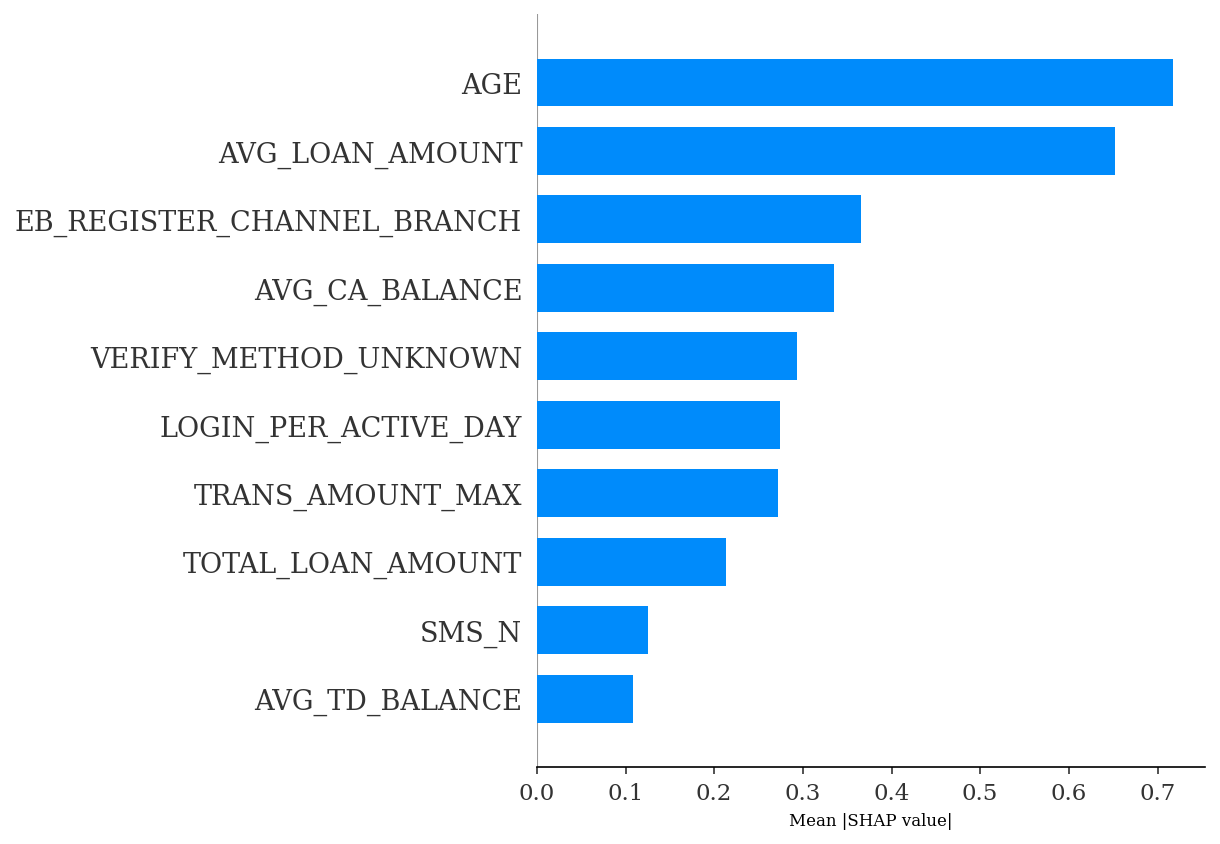

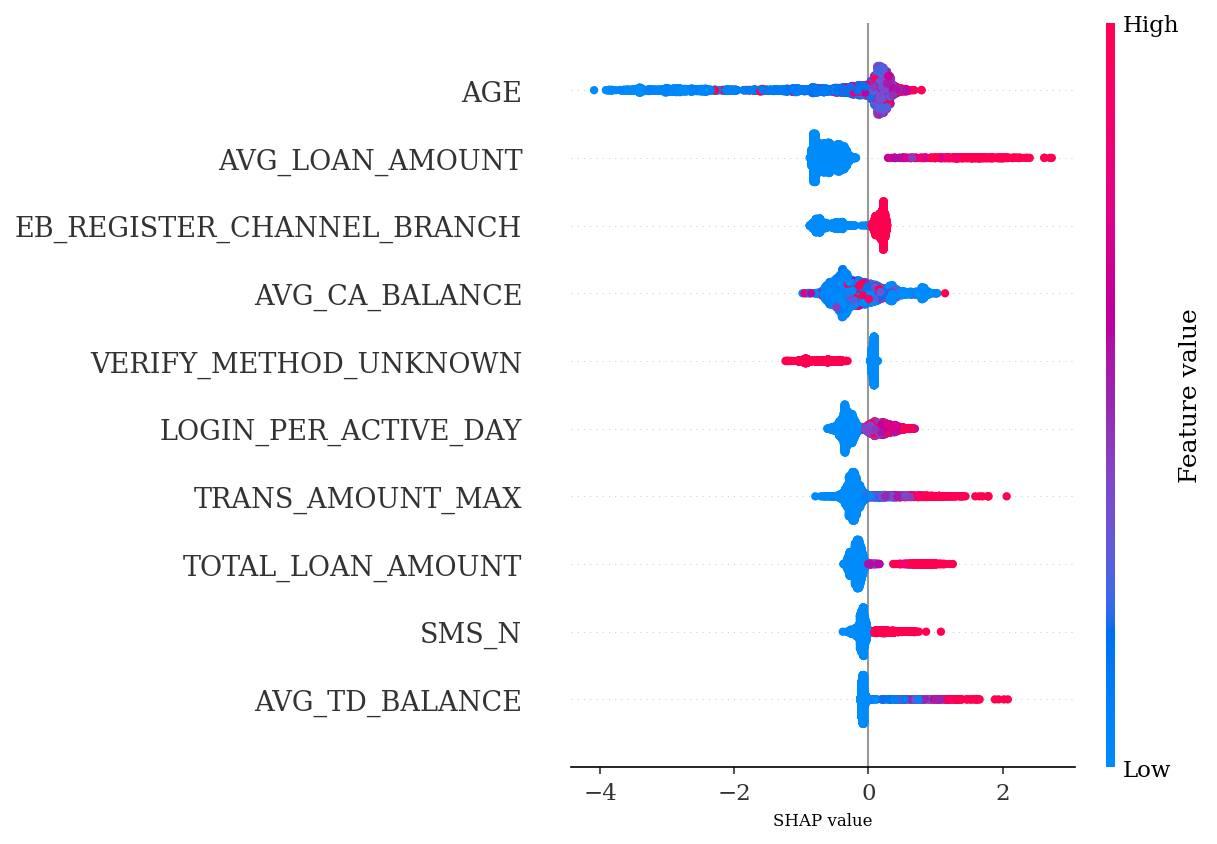

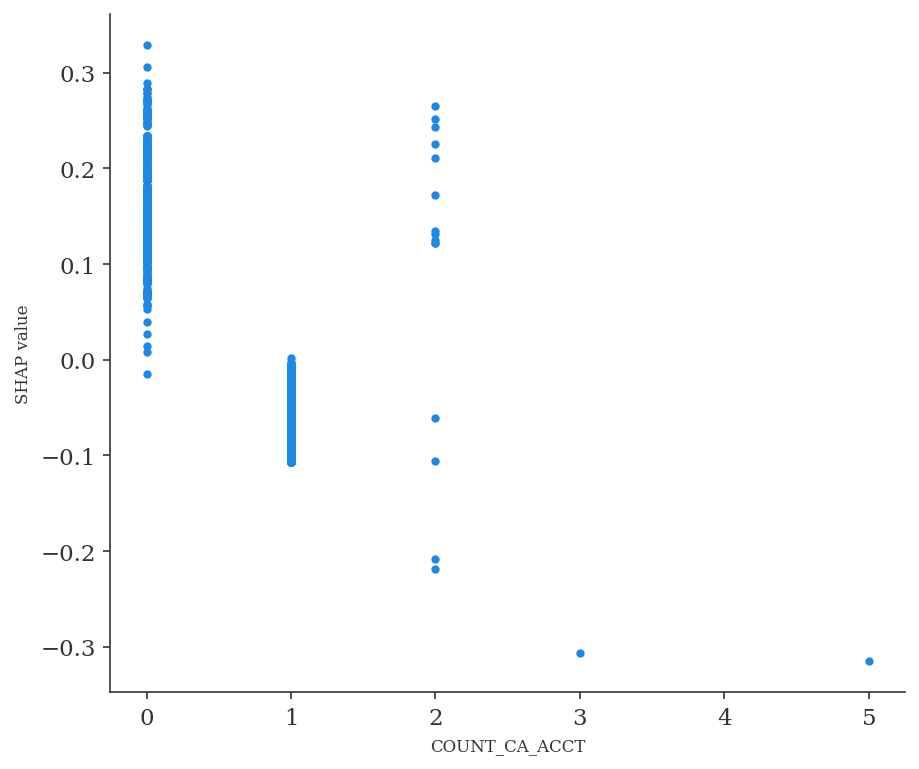


GOLDEN E2 REFERENCE CHECK
         METRIC  E2_REFERENCE  CURRENT  ABS_DIFFERENCE  PASS
         CV_AUC      0.909226 0.909226    2.680198e-07  True
      CV_AUC_SD      0.005908 0.005908    3.047777e-07  True
       TEST_AUC      0.910242 0.910242    3.735093e-07  True
        TEST_KS      0.673291 0.673291    4.011672e-07  True
    TEST_RECALL      0.168000 0.168000    0.000000e+00  True
PRECISION_AT_10      0.296825 0.296825    3.968254e-07  True
     LIFT_AT_10      6.408376 6.408376    4.897959e-07  True
  CAPTURE_AT_10      0.641143 0.641143    1.428571e-07  True

FLDC-60D — BRANCH A
XGBOOST + NO SAMPLING

Customers: 94,453
Train: 75,562
Test: 18,891

CV AUC: 0.909226 ± 0.005908
CV KS: 0.669079 ± 0.017811

Test AUC: 0.910241626
Test KS: 0.673290599
Recall: 0.168000000
Precision: 0.528776978
F1: 0.254986990
Accuracy: 0.954528612
Brier: 0.034617545
BSS: 0.216318241
ECE: 0.003910156
MCC: 0.280540793
Specificity: 0.992728686
NPV: 0.960887552

Confusion matrix:
[[17885   131]
 [  728 

In [ ]:
# ============================================================
# VIB FLDC-60D — BRANCH A
# XGBOOST + NO SAMPLING
# GOLDEN E2 EXACT REPRODUCTION
#
# PURPOSE
# -------
# Reproduce the previously confirmed Golden E2 Branch A
# configuration as closely as possible.
#
# IMPORTANT
# ---------
# 1. DO NOT add tree_method="hist"
# 2. DO NOT add max_bin=256
# 3. n_jobs = -1
# 4. DO NOT sort the original dataset before train_test_split
# 5. Train/test split = train_test_split + stratification
# 6. CV = StratifiedKFold(shuffle=True, random_state=42)
# 7. Exactly 18 predictors
# 8. No sampling
#
# OUTPUTS
# -------
# - Dataset verification
# - Train/test verification
# - 5-fold CV results
# - CV summary
# - Final test metrics
# - Confusion matrix
# - Classification report
# - Ranking metrics
# - Decile table
# - Test predictions
# - SHAP transformed features
# - SHAP original features
# - SHAP bar plot
# - SHAP beeswarm plot
# - COUNT_CA_ACCT dependence plot
# - Publication table
# - CSV outputs
# - Excel workbook
# - Golden E2 reference check
# ============================================================


# ============================================================
# 0. INSTALL / ENVIRONMENT
# ============================================================

!pip -q install \
    xgboost==3.4.0 \
    shap==0.52.0 \
    openpyxl


# ============================================================
# 1. IMPORTS
# ============================================================

import os
import gc
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import shap

from pathlib import Path

from google.colab import drive

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold
)

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    OneHotEncoder
)

from sklearn.compose import (
    ColumnTransformer
)

from sklearn.pipeline import (
    Pipeline
)

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    recall_score,
    precision_score,
    f1_score,
    accuracy_score,
    brier_score_loss,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier


warnings.filterwarnings("ignore")


# ============================================================
# 2. GLOBAL CONFIGURATION
# ============================================================

SEED = 42

TEST_SIZE = 0.20

N_SPLITS = 5

THRESHOLD = 0.50

SHAP_SAMPLE_SIZE = 5000

MAX_SHAP_DISPLAY = 10

MODEL_NAME = (
    "XGBoost + No Sampling"
)

LANDMARK_DAYS = 60

ID_COL = (
    "CUSTOMER_NUMBER"
)

TARGET_COL = (
    "TARGET_60D"
)


# ============================================================
# 3. EXACT BRANCH A FEATURES
# ============================================================
#
# Branch A = exactly 18 predictors.
#
# These are the 18 predictors used in the confirmed E2
# Branch A configuration.
# ============================================================

FEATURES = [

    "CLIENT_SEX",

    "EB_REGISTER_CHANNEL",

    "SMS",

    "VERIFY_METHOD",

    "AGE",

    "LOGIN_PER_ACTIVE_DAY",

    "INTEREST_RATE_RATIO",

    "TRANS_LV1_MODE",

    "TRANS_LV2_MODE",

    "TRANS_AMOUNT_MAX",

    "TRANS_AMOUNT_MEAN",

    "COUNT_CA_ACCT",

    "AVG_CA_BALANCE",

    "COUNT_TD_ACCT",

    "AVG_TD_BALANCE",

    "COUNT_OF_LOAN",

    "AVG_LOAN_AMOUNT",

    "TOTAL_LOAN_AMOUNT"
]


assert len(FEATURES) == 18


# ============================================================
# 4. FORBIDDEN FEATURES
# ============================================================
#
# These columns must NEVER enter the predictor matrix.
# ============================================================

FORBIDDEN_FEATURES = [

    ID_COL,

    TARGET_COL,

    "TRANS_LV1_MODE_CODE",

    "TRANS_LV2_MODE_CODE",

    "CLIENT_CREATE_DATE"
]


# ============================================================
# 5. XGBOOST CONFIGURATION
# ============================================================
#
# CRITICAL:
# This is the historical Golden E2 configuration.
#
# DO NOT add:
#   tree_method="hist"
#   max_bin=256
#
# n_jobs must remain -1.
# ============================================================

XGB_PARAMS = {

    "n_estimators":
        300,

    "max_depth":
        6,

    "learning_rate":
        0.05,

    "subsample":
        0.8,

    "colsample_bytree":
        0.8,

    "objective":
        "binary:logistic",

    "eval_metric":
        "logloss",

    "random_state":
        SEED,

    "n_jobs":
        -1
}


def get_model():

    return XGBClassifier(
        **XGB_PARAMS
    )


# ============================================================
# 6. MOUNT GOOGLE DRIVE
# ============================================================

print("=" * 110)
print("MOUNT GOOGLE DRIVE")
print("=" * 110)

drive.mount(
    "/content/drive",
    force_remount=False
)


MYDRIVE_ROOT = Path(
    "/content/drive/MyDrive"
)


if not MYDRIVE_ROOT.is_dir():

    raise RuntimeError(
        "Không truy cập được Google Drive:\n"
        f"{MYDRIVE_ROOT}"
    )


# ============================================================
# 7. PATH CONFIGURATION
# ============================================================

ROOT = (

    MYDRIVE_ROOT

    / "Fintect"
)


INPUT_FILE = (

    ROOT

    / "final_landmark_60d"

    / "final_dataset_landmark_60d_no_auto_job.csv"
)


OUTPUT_DIR = (

    ROOT

    / "landmark_60d_training_results"

    / "branch_A_xgboost_no_sampling_E2_exact"
)


OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# Optional reference files
# ------------------------------------------------------------

E2_SPLIT_FILE = (

    ROOT

    / "FINAL_ABC_MATCHED_E2"

    / "exact_E2_shared_train_test_split.csv"
)


E2_CV_FILE = (

    ROOT

    / "FINAL_ABC_MATCHED_E2"

    / "exact_E2_shared_CV_folds.csv"
)


# ============================================================
# 8. EXPECTED GOLDEN E2 POPULATION
# ============================================================

EXPECTED_CUSTOMERS = 94453

EXPECTED_TRAIN = 75562

EXPECTED_TEST = 18891


# ============================================================
# 9. GOLDEN E2 REFERENCE VALUES
# ============================================================
#
# These are the previously confirmed E2 values used for
# reproduction checking.
# ============================================================

E2_REFERENCE = {

    "CV_AUC":
        0.909226,

    "CV_AUC_SD":
        0.005908,

    "TEST_AUC":
        0.910242,

    "TEST_KS":
        0.673291,

    "TEST_RECALL":
        0.168000,

    "PRECISION_AT_10":
        0.296825,

    "LIFT_AT_10":
        6.408376,

    "CAPTURE_AT_10":
        0.641143
}


REFERENCE_TOLERANCE = 1e-5


# ============================================================
# 10. IEEE FIGURE SETTINGS
# ============================================================

mpl.rcParams.update({

    "font.family":
        "serif",

    "font.serif": [
        "Times New Roman",
        "Times",
        "DejaVu Serif"
    ],

    "font.size":
        8,

    "axes.labelsize":
        8,

    "axes.titlesize":
        8,

    "xtick.labelsize":
        7,

    "ytick.labelsize":
        7,

    "legend.fontsize":
        7,

    "axes.linewidth":
        0.8,

    "lines.linewidth":
        1.0,

    "figure.dpi":
        150,

    "savefig.dpi":
        600,

    "pdf.fonttype":
        42,

    "ps.fonttype":
        42
})


# ============================================================
# 11. ENVIRONMENT REPORT
# ============================================================

print("\n" + "=" * 110)
print("ENVIRONMENT")
print("=" * 110)

print(
    "Python   :",
    sys.version
)

print(
    "NumPy    :",
    np.__version__
)

print(
    "Pandas   :",
    pd.__version__
)

try:

    import sklearn

    print(
        "Sklearn  :",
        sklearn.__version__
    )

except Exception:

    print(
        "Sklearn  : unavailable"
    )


import xgboost

print(
    "XGBoost  :",
    xgboost.__version__
)

print(
    "SHAP     :",
    shap.__version__
)


# ============================================================
# 12. CONFIGURATION REPORT
# ============================================================

print("\n" + "=" * 110)
print("VIB FLDC-60D — BRANCH A")
print("XGBOOST + NO SAMPLING")
print("GOLDEN E2 EXACT REPRODUCTION")
print("=" * 110)

print("\nInput:")
print(
    INPUT_FILE
)

print("\nOutput:")
print(
    OUTPUT_DIR
)

print("\nPopulation:")
print(
    f"Expected customers : {EXPECTED_CUSTOMERS:,}"
)

print(
    f"Expected train     : {EXPECTED_TRAIN:,}"
)

print(
    f"Expected test      : {EXPECTED_TEST:,}"
)

print("\nFeatures:")
print(
    f"Number of predictors: {len(FEATURES)}"
)

for i, feature in enumerate(
    FEATURES,
    start=1
):

    print(
        f"  {i:02d}. {feature}"
    )

print("\nSampling:")
print(
    "RandomOverSampler : NO"
)

print(
    "SMOTE             : NO"
)

print(
    "ADASYN            : NO"
)

print(
    "scale_pos_weight  : NOT USED"
)

print(
    "class_weight      : NOT USED"
)

print("\nXGBoost:")

for key, value in XGB_PARAMS.items():

    print(
        f"{key:20s}: {value}"
    )

print("\nIMPORTANT:")
print(
    "tree_method is NOT explicitly specified."
)

print(
    "max_bin is NOT explicitly specified."
)

print(
    "n_jobs = -1."
)


# ============================================================
# 13. CHECK INPUT FILE
# ============================================================

if not INPUT_FILE.is_file():

    raise FileNotFoundError(
        f"Không tìm thấy input file:\n{INPUT_FILE}"
    )


# ============================================================
# 14. STANDARDIZE CUSTOMER ID
# ============================================================

def standardize_customer_id(
    series
):

    result = (

        series

        .astype("string")

        .str.strip()

        .str.replace(
            r"\.0$",
            "",
            regex=True
        )
    )

    invalid_values = [

        "",

        "NAN",

        "<NA>",

        "NONE",

        "NULL"
    ]

    result = (

        result

        .mask(

            result

            .str.upper()

            .isin(
                invalid_values
            ),

            pd.NA
        )
    )

    return result


# ============================================================
# 15. LOAD DATASET
# ============================================================

print("\n" + "=" * 110)
print("LOAD BRANCH A DATASET")
print("=" * 110)

df = pd.read_csv(
    INPUT_FILE,
    low_memory=False
)


print(
    "Dataset shape:",
    df.shape
)


# ============================================================
# 16. STANDARDIZE COLUMN NAMES
# ============================================================

df.columns = (

    df.columns

    .astype(str)

    .str.strip()

    .str.upper()
)


# ============================================================
# 17. REQUIRED COLUMN CHECK
# ============================================================

required_columns = (

    [
        ID_COL,
        TARGET_COL
    ]

    +

    FEATURES
)


missing_columns = [

    column

    for column
    in required_columns

    if column not in df.columns
]


if missing_columns:

    raise ValueError(

        "Thiếu các cột bắt buộc:\n"

        + "\n".join(
            missing_columns
        )

        + "\n\nColumns hiện có:\n"

        + "\n".join(
            df.columns.tolist()
        )
    )


# ============================================================
# 18. TARGET / ID STANDARDIZATION
# ============================================================

df[ID_COL] = (
    standardize_customer_id(
        df[ID_COL]
    )
)


df[TARGET_COL] = (
    pd.to_numeric(
        df[TARGET_COL],
        errors="coerce"
    )
)


df = (
    df
    .dropna(
        subset=[
            ID_COL,
            TARGET_COL
        ]
    )
    .copy()
)


df[TARGET_COL] = (

    df[TARGET_COL]

    .astype(int)
)


if not df[TARGET_COL].isin(
    [0, 1]
).all():

    raise ValueError(
        "TARGET_60D phải chỉ gồm 0 và 1."
    )


# ============================================================
# 19. DUPLICATE CUSTOMER CHECK
# ============================================================

duplicate_count = int(

    df[ID_COL]

    .duplicated()

    .sum()
)


if duplicate_count > 0:

    raise RuntimeError(

        f"Có {duplicate_count:,} "
        "duplicate CUSTOMER_NUMBER."
    )


# ============================================================
# 20. BASIC DATA REPORT
# ============================================================

positive_count = int(
    df[TARGET_COL].sum()
)

negative_count = (

    len(df)

    -
    positive_count
)


print(
    "Customers:",
    f"{len(df):,}"
)

print(
    "Positive:",
    f"{positive_count:,}"
)

print(
    "Negative:",
    f"{negative_count:,}"
)

print(
    "Positive rate:",
    f"{df[TARGET_COL].mean():.6%}"
)


# ============================================================
# 21. EXACT POPULATION CHECK
# ============================================================

if len(df) != EXPECTED_CUSTOMERS:

    raise RuntimeError(

        "Population không đúng Golden E2.\n"

        f"Expected: {EXPECTED_CUSTOMERS:,}\n"

        f"Actual:   {len(df):,}"
    )


# ============================================================
# 22. EXCLUDED A-ONLY CUSTOMER CHECK
# ============================================================

excluded_ids = {

    "375383",

    "475787"
}


remaining_excluded = (

    set(
        df[ID_COL]
    )

    &
    excluded_ids
)


if remaining_excluded:

    raise RuntimeError(

        "Branch A vẫn chứa customer A-only:\n"

        f"{sorted(remaining_excluded)}"
    )


# ============================================================
# 23. FEATURE CHECK
# ============================================================

assert len(FEATURES) == 18


for forbidden in FORBIDDEN_FEATURES:

    if forbidden in FEATURES:

        raise RuntimeError(

            f"Forbidden feature xuất hiện: "
            f"{forbidden}"
        )


print("\nFEATURE CHECK PASSED.")

print(
    "Branch A = exactly 18 predictors."
)


# ============================================================
# 24. BUILD X / y
# ============================================================
#
# IMPORTANT:
# Preserve the original CSV row order.
#
# DO NOT SORT.
# ============================================================

X = (
    df[
        FEATURES
    ]
    .copy()
)


y = (
    df[
        TARGET_COL
    ]
    .copy()
)


customer_ids = (
    df[
        ID_COL
    ]
    .copy()
)


# ============================================================
# 25. NUMERIC / CATEGORICAL FEATURES
# ============================================================

numeric_cols = (

    X

    .select_dtypes(
        include=np.number
    )

    .columns

    .tolist()
)


categorical_cols = (

    X

    .select_dtypes(
        exclude=np.number
    )

    .columns

    .tolist()
)


print("\nNumeric columns:")
print(
    numeric_cols
)

print("\nCategorical columns:")
print(
    categorical_cols
)


# ============================================================
# 26. EXACT E2 PREPROCESSING
# ============================================================

numeric_pipe = Pipeline([

    (
        "imputer",

        SimpleImputer(

            strategy="constant",

            fill_value=0
        )
    )
])


categorical_pipe = Pipeline([

    (
        "imputer",

        SimpleImputer(

            strategy="constant",

            fill_value="MISSING"
        )
    ),

    (
        "onehot",

        OneHotEncoder(

            handle_unknown="ignore",

            sparse_output=False
        )
    )
])


def build_preprocessor():

    return ColumnTransformer([

        (
            "num",

            numeric_pipe,

            numeric_cols
        ),

        (
            "cat",

            categorical_pipe,

            categorical_cols
        )
    ])


# ============================================================
# 27. METRIC FUNCTIONS
# ============================================================

def ks_score(
    y_true,
    probability
):

    fpr, tpr, _ = roc_curve(

        y_true,

        probability
    )

    return float(
        np.max(
            tpr - fpr
        )
    )


def bss_score(
    y_true,
    probability
):

    brier = brier_score_loss(

        y_true,

        probability
    )

    prevalence = float(
        np.mean(y_true)
    )

    reference = (

        prevalence

        *
        (1 - prevalence)
    )

    if reference <= 0:

        return np.nan

    return float(

        1

        -
        brier
        /
        reference
    )


def ece_score(
    y_true,
    probability,
    n_bins=10
):

    y_true = np.asarray(
        y_true
    )

    probability = np.asarray(
        probability
    )

    bins = np.linspace(
        0,
        1,
        n_bins + 1
    )

    ece = 0.0

    for i in range(
        n_bins
    ):

        if i == n_bins - 1:

            mask = (

                (probability >= bins[i])

                &
                (probability <= bins[i + 1])
            )

        else:

            mask = (

                (probability >= bins[i])

                &
                (probability < bins[i + 1])
            )

        if not mask.any():

            continue

        observed = (

            y_true[mask]

            .mean()
        )

        predicted = (

            probability[mask]

            .mean()
        )

        weight = (

            mask.sum()

            /
            len(y_true)
        )

        ece += (

            weight

            *
            abs(
                observed
                -
                predicted
            )
        )

    return float(
        ece
    )


def classification_metrics(
    y_true,
    probability
):

    prediction = (

        probability
        >=
        THRESHOLD

    ).astype(int)


    return {

        "AUC":

            roc_auc_score(
                y_true,
                probability
            ),

        "KS":

            ks_score(
                y_true,
                probability
            ),

        "RECALL":

            recall_score(
                y_true,
                prediction,
                zero_division=0
            ),

        "PRECISION":

            precision_score(
                y_true,
                prediction,
                zero_division=0
            ),

        "F1":

            f1_score(
                y_true,
                prediction,
                zero_division=0
            ),

        "ACCURACY":

            accuracy_score(
                y_true,
                prediction
            ),

        "BRIER":

            brier_score_loss(
                y_true,
                probability
            ),

        "BSS":

            bss_score(
                y_true,
                probability
            ),

        "ECE":

            ece_score(
                y_true,
                probability
            )
    }


# ============================================================
# 28. RANKING METRICS
# ============================================================

def ranking_metrics(
    y_true,
    probability
):

    temp = pd.DataFrame({

        "Y_TRUE":
            np.asarray(
                y_true
            ),

        "Y_PROB":
            np.asarray(
                probability
            )
    })


    temp = (

        temp

        .sort_values(
            "Y_PROB",
            ascending=False
        )

        .reset_index(
            drop=True
        )
    )


    base_rate = float(

        temp[
            "Y_TRUE"
        ]
        .mean()
    )


    total_positive = int(

        temp[
            "Y_TRUE"
        ]
        .sum()
    )


    rows = []


    for rate in [

        0.10,

        0.20,

        0.30
    ]:

        n = int(

            np.ceil(

                len(temp)

                *
                rate
            )
        )


        top_df = (

            temp

            .iloc[
                :n
            ]
        )


        precision = float(

            top_df[
                "Y_TRUE"
            ]
            .mean()
        )


        captured_positive = int(

            top_df[
                "Y_TRUE"
            ]
            .sum()
        )


        capture = (

            captured_positive

            /
            total_positive
        )


        lift = (

            precision

            /
            base_rate
        )


        rows.append({

            "TOP_K":
                f"Top {int(rate * 100)}%",

            "TOP_RATE":
                rate,

            "CUSTOMERS":
                n,

            "PRECISION":
                precision,

            "LIFT":
                lift,

            "CAPTURED_POSITIVES":
                captured_positive,

            "CAPTURE_RATE":
                capture
        })


    return pd.DataFrame(
        rows
    )


# ============================================================
# 29. DECILE TABLE
# ============================================================

def create_decile_table(
    y_true,
    probability
):

    temp = pd.DataFrame({

        "Y_TRUE":
            np.asarray(
                y_true
            ),

        "Y_PROB":
            np.asarray(
                probability
            )
    })


    temp = (

        temp

        .sort_values(
            "Y_PROB",
            ascending=False
        )

        .reset_index(
            drop=True
        )
    )


    temp["DECILE"] = pd.qcut(

        np.arange(
            len(temp)
        ),

        q=10,

        labels=[

            f"D{i}"

            for i
            in range(
                1,
                11
            )
        ]
    )


    base_rate = (

        temp[
            "Y_TRUE"
        ]
        .mean()
    )


    result = (

        temp

        .groupby(
            "DECILE",
            observed=False
        )

        .agg(

            CUSTOMERS=(
                "Y_TRUE",
                "count"
            ),

            POSITIVES=(
                "Y_TRUE",
                "sum"
            ),

            ADOPTION_RATE=(
                "Y_TRUE",
                "mean"
            ),

            AVG_PRED_PROB=(
                "Y_PROB",
                "mean"
            )
        )

        .reset_index()
    )


    result["LIFT"] = (

        result[
            "ADOPTION_RATE"
        ]

        /
        base_rate
    )


    return result


# ============================================================
# 30. EXACT GOLDEN-E2 TRAIN / TEST SPLIT
# ============================================================
#
# CRITICAL:
#
# This follows the previously used Golden E2 standalone code:
#
# train_test_split(
#     X,
#     y,
#     test_size=0.20,
#     stratify=y,
#     random_state=42
# )
#
# No sorting.
# No customer-ID reordering.
# ============================================================

print("\n" + "=" * 110)
print("TRAIN / TEST SPLIT — GOLDEN E2")
print("=" * 110)


X_train, X_test, y_train, y_test = (

    train_test_split(

        X,

        y,

        test_size=TEST_SIZE,

        stratify=y,

        random_state=SEED
    )
)


train_customer_ids = (
    customer_ids
    .loc[
        X_train.index
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


test_customer_ids = (
    customer_ids
    .loc[
        X_test.index
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


X_train = (
    X_train
    .reset_index(
        drop=True
    )
)

X_test = (
    X_test
    .reset_index(
        drop=True
    )
)

y_train = (
    y_train
    .reset_index(
        drop=True
    )
)

y_test = (
    y_test
    .reset_index(
        drop=True
    )
)


print(
    "Train:",
    f"{len(X_train):,}"
)

print(
    "Test :",
    f"{len(X_test):,}"
)

print(
    "Train base rate:",
    f"{y_train.mean():.6f}"
)

print(
    "Test base rate :",
    f"{y_test.mean():.6f}"
)


# ============================================================
# 31. TRAIN / TEST POPULATION CHECK
# ============================================================

if len(X_train) != EXPECTED_TRAIN:

    raise RuntimeError(

        "Train size không đúng Golden E2.\n"

        f"Expected: {EXPECTED_TRAIN:,}\n"

        f"Actual:   {len(X_train):,}"
    )


if len(X_test) != EXPECTED_TEST:

    raise RuntimeError(

        "Test size không đúng Golden E2.\n"

        f"Expected: {EXPECTED_TEST:,}\n"

        f"Actual:   {len(X_test):,}"
    )


if len(
    set(train_customer_ids)
    &
    set(test_customer_ids)
) > 0:

    raise RuntimeError(
        "TRAIN/TEST customer overlap."
    )


if (
    set(train_customer_ids)
    |
    set(test_customer_ids)
) != set(customer_ids):

    raise RuntimeError(
        "TRAIN + TEST không bao phủ đúng population."
    )


# ============================================================
# 32. 5-FOLD CV — EXACT E2
# ============================================================

print("\n" + "=" * 110)
print("5-FOLD CV — GOLDEN E2 — BRANCH A")
print("=" * 110)


cv = StratifiedKFold(

    n_splits=N_SPLITS,

    shuffle=True,

    random_state=SEED
)


cv_rows = []


for fold, (
    train_fold_idx,
    valid_fold_idx
) in enumerate(

    cv.split(
        X_train,
        y_train
    ),

    start=1
):

    print(
        f"\nRunning fold {fold}/{N_SPLITS}..."
    )


    X_fold_train = (

        X_train

        .iloc[
            train_fold_idx
        ]

        .copy()
    )


    X_fold_valid = (

        X_train

        .iloc[
            valid_fold_idx
        ]

        .copy()
    )


    y_fold_train = (

        y_train

        .iloc[
            train_fold_idx
        ]

        .copy()
    )


    y_fold_valid = (

        y_train

        .iloc[
            valid_fold_idx
        ]

        .copy()
    )


    # --------------------------------------------------------
    # Fit fold-specific preprocessor
    # --------------------------------------------------------

    fold_preprocessor = (
        build_preprocessor()
    )


    X_fold_train_p = (

        fold_preprocessor

        .fit_transform(
            X_fold_train
        )
    )


    X_fold_valid_p = (

        fold_preprocessor

        .transform(
            X_fold_valid
        )
    )


    # --------------------------------------------------------
    # Check transformed dimensions
    # --------------------------------------------------------

    if (
        X_fold_train_p.shape[1]
        !=
        X_fold_valid_p.shape[1]
    ):

        raise RuntimeError(

            f"Fold {fold}: transformed "
            "feature count mismatch."
        )


    # --------------------------------------------------------
    # Fit XGBoost
    # --------------------------------------------------------

    fold_model = (
        get_model()
    )


    fold_model.fit(

        X_fold_train_p,

        y_fold_train
    )


    # --------------------------------------------------------
    # Predict probability
    # --------------------------------------------------------

    fold_probability = (

        fold_model

        .predict_proba(
            X_fold_valid_p
        )

        [:, 1]
    )


    fold_prediction = (

        fold_probability

        >= THRESHOLD

    ).astype(
        np.int8
    )


    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    fold_auc = roc_auc_score(

        y_fold_valid,

        fold_probability
    )


    fold_ks = ks_score(

        y_fold_valid,

        fold_probability
    )


    fold_recall = recall_score(

        y_fold_valid,

        fold_prediction,

        zero_division=0
    )


    fold_precision = precision_score(

        y_fold_valid,

        fold_prediction,

        zero_division=0
    )


    fold_f1 = f1_score(

        y_fold_valid,

        fold_prediction,

        zero_division=0
    )


    fold_accuracy = accuracy_score(

        y_fold_valid,

        fold_prediction
    )


    fold_brier = brier_score_loss(

        y_fold_valid,

        fold_probability
    )


    fold_bss = bss_score(

        y_fold_valid,

        fold_probability
    )


    fold_ece = ece_score(

        y_fold_valid,

        fold_probability
    )


    cv_rows.append({

        "FOLD":
            fold,

        "AUC":
            fold_auc,

        "KS":
            fold_ks,

        "RECALL":
            fold_recall,

        "PRECISION":
            fold_precision,

        "F1":
            fold_f1,

        "ACCURACY":
            fold_accuracy,

        "BRIER":
            fold_brier,

        "BSS":
            fold_bss,

        "ECE":
            fold_ece
    })


    print(

        f"Fold {fold}: "

        f"AUC={fold_auc:.6f} | "

        f"KS={fold_ks:.6f} | "

        f"Recall={fold_recall:.6f} | "

        f"Precision={fold_precision:.6f} | "

        f"F1={fold_f1:.6f} | "

        f"Accuracy={fold_accuracy:.6f} | "

        f"Brier={fold_brier:.6f}"
    )


    del fold_model

    del fold_preprocessor

    del X_fold_train_p

    del X_fold_valid_p

    gc.collect()


cv_results = pd.DataFrame(
    cv_rows
)


# ============================================================
# 33. CV SUMMARY
# ============================================================

print("\n" + "=" * 110)
print("CV SUMMARY")
print("=" * 110)


CV_METRICS = [

    "AUC",

    "KS",

    "RECALL",

    "PRECISION",

    "F1",

    "ACCURACY",

    "BRIER",

    "BSS",

    "ECE"
]


cv_summary_rows = []


for metric in CV_METRICS:

    mean_value = float(

        cv_results[
            metric
        ]
        .mean()
    )


    sd_value = float(

        cv_results[
            metric
        ]
        .std(
            ddof=1
        )
    )


    cv_summary_rows.append({

        "METRIC":
            metric,

        "MEAN":
            mean_value,

        "STD":
            sd_value,

        "MEAN_PLUS_MINUS_SD":

            (
                f"{mean_value:.4f} ± "
                f"{sd_value:.4f}"
            )
    })


cv_summary = pd.DataFrame(
    cv_summary_rows
)


print(

    cv_summary[
        [
            "METRIC",

            "MEAN_PLUS_MINUS_SD"
        ]
    ]

    .to_string(
        index=False
    )
)


# ============================================================
# 34. FINAL PREPROCESSOR
# ============================================================

print("\n" + "=" * 110)
print("FINAL MODEL — BRANCH A")
print("XGBOOST + NO SAMPLING")
print("=" * 110)


final_preprocessor = (
    build_preprocessor()
)


X_train_processed = (

    final_preprocessor

    .fit_transform(
        X_train
    )
)


X_test_processed = (

    final_preprocessor

    .transform(
        X_test
    )
)


print(
    "Transformed train shape:",
    X_train_processed.shape
)

print(
    "Transformed test shape:",
    X_test_processed.shape
)


# ============================================================
# 35. EXPECTED TRANSFORMED FEATURE COUNT
# ============================================================

if X_train_processed.shape[1] != 45:

    raise RuntimeError(

        "Transformed feature count "
        "không đúng Golden E2.\n"

        f"Expected: 45\n"

        f"Actual: "
        f"{X_train_processed.shape[1]}"
    )


if X_test_processed.shape[1] != 45:

    raise RuntimeError(

        "Test transformed feature count "
        "không đúng Golden E2.\n"

        f"Expected: 45\n"

        f"Actual: "
        f"{X_test_processed.shape[1]}"
    )


# ============================================================
# 36. FINAL MODEL
# ============================================================

final_model = (
    get_model()
)


final_model.fit(

    X_train_processed,

    y_train
)


test_probability = (

    final_model

    .predict_proba(
        X_test_processed
    )

    [:, 1]
)


test_prediction = (

    test_probability

    >= THRESHOLD

).astype(
    np.int8
)


# ============================================================
# 37. TEST METRICS
# ============================================================

test_auc = roc_auc_score(

    y_test,

    test_probability
)


test_ks = ks_score(

    y_test,

    test_probability
)


test_recall = recall_score(

    y_test,

    test_prediction,

    zero_division=0
)


test_precision = precision_score(

    y_test,

    test_prediction,

    zero_division=0
)


test_f1 = f1_score(

    y_test,

    test_prediction,

    zero_division=0
)


test_accuracy = accuracy_score(

    y_test,

    test_prediction
)


test_brier = brier_score_loss(

    y_test,

    test_probability
)


test_bss = bss_score(

    y_test,

    test_probability
)


test_ece = ece_score(

    y_test,

    test_probability
)


# ============================================================
# 38. CONFUSION MATRIX
# ============================================================

tn, fp, fn, tp = (

    confusion_matrix(

        y_test,

        test_prediction,

        labels=[0, 1]
    )

    .ravel()
)


specificity = (

    tn /
    (tn + fp)

    if (tn + fp) > 0

    else np.nan
)


npv = (

    tn /
    (tn + fn)

    if (tn + fn) > 0

    else np.nan
)


mcc_denominator = np.sqrt(

    (tp + fp)

    *

    (tp + fn)

    *

    (tn + fp)

    *

    (tn + fn)
)


mcc = (

    (

        tp * tn

        -
        fp * fn

    )

    /

    mcc_denominator

    if mcc_denominator > 0

    else np.nan
)


# ============================================================
# 39. FINAL TEST REPORT
# ============================================================

print("\n" + "=" * 110)
print("FINAL TEST RESULTS — BRANCH A")
print("=" * 110)


print(
    f"AUC          = {test_auc:.9f}"
)

print(
    f"KS           = {test_ks:.9f}"
)

print(
    f"RECALL       = {test_recall:.9f}"
)

print(
    f"PRECISION    = {test_precision:.9f}"
)

print(
    f"F1           = {test_f1:.9f}"
)

print(
    f"ACCURACY     = {test_accuracy:.9f}"
)

print(
    f"BRIER        = {test_brier:.9f}"
)

print(
    f"BSS          = {test_bss:.9f}"
)

print(
    f"ECE          = {test_ece:.9f}"
)

print(
    f"MCC          = {mcc:.9f}"
)

print(
    f"Specificity   = {specificity:.9f}"
)

print(
    f"NPV           = {npv:.9f}"
)


print("\nConfusion matrix:")

print(
    np.array([

        [
            tn,
            fp
        ],

        [
            fn,
            tp
        ]

    ])
)


print("\nClassification report:")

print(

    classification_report(

        y_test,

        test_prediction,

        digits=4,

        zero_division=0
    )
)


# ============================================================
# 40. RANKING METRICS
# ============================================================

ranking = ranking_metrics(

    y_test,

    test_probability
)


print("\n" + "=" * 110)
print("RANKING METRICS")
print("=" * 110)


print(

    ranking

    .to_string(
        index=False
    )
)


top10 = ranking.iloc[0]

top20 = ranking.iloc[1]

top30 = ranking.iloc[2]


# ============================================================
# 41. DECILE TABLE
# ============================================================

deciles = create_decile_table(

    y_test,

    test_probability
)


print("\n" + "=" * 110)
print("DECILE TABLE")
print("=" * 110)


print(

    deciles

    .to_string(
        index=False
    )
)


# ============================================================
# 42. TEST PREDICTIONS
# ============================================================

predictions = pd.DataFrame({

    ID_COL:
        test_customer_ids.to_numpy(),

    "Y_TRUE":
        y_test.to_numpy(),

    "Y_PROB":
        test_probability,

    "Y_PRED":
        test_prediction
})


# Preserve original E2 test prediction ordering.
#
# We keep this dataframe in the order produced by
# train_test_split.
#
# A sorted copy will be created separately for convenience.
predictions_sorted = (

    predictions

    .sort_values(
        ID_COL
    )

    .reset_index(
        drop=True
    )
)


if len(predictions) != EXPECTED_TEST:

    raise RuntimeError(
        "Prediction row count mismatch."
    )


if (
    set(predictions[ID_COL])
    !=
    set(test_customer_ids)
):

    raise RuntimeError(
        "Prediction CUSTOMER_NUMBER set mismatch."
    )


# ============================================================
# 43. PUBLICATION TABLE
# ============================================================

def cv_text(
    metric
):

    mean_value = (

        cv_results[
            metric
        ]
        .mean()
    )


    sd_value = (

        cv_results[
            metric
        ]
        .std(
            ddof=1
        )
    )


    return (

        f"{mean_value:.4f} ± "
        f"{sd_value:.4f}"
    )


performance_table = pd.DataFrame(

    [

        [
            "AUC",

            f"{test_auc:.4f}",

            cv_text("AUC")
        ],

        [
            "KS statistic",

            f"{test_ks:.4f}",

            cv_text("KS")
        ],

        [
            "Recall",

            f"{test_recall:.4f}",

            cv_text("RECALL")
        ],

        [
            "Precision",

            f"{test_precision:.4f}",

            cv_text("PRECISION")
        ],

        [
            "F1-score",

            f"{test_f1:.4f}",

            cv_text("F1")
        ],

        [
            "Accuracy",

            f"{test_accuracy:.4f}",

            cv_text("ACCURACY")
        ],

        [
            "Brier score",

            f"{test_brier:.4f}",

            cv_text("BRIER")
        ],

        [
            "Brier skill score",

            f"{test_bss:.4f}",

            cv_text("BSS")
        ],

        [
            "ECE",

            f"{test_ece:.4f}",

            cv_text("ECE")
        ],

        [
            "Precision@10% / Lift@10%",

            (
                f"{top10['PRECISION']:.4f} / "
                f"{top10['LIFT']:.4f}"
            ),

            "—"
        ],

        [
            "Capture@10%",

            f"{top10['CAPTURE_RATE']:.4f}",

            "—"
        ],

        [
            "Precision@20% / Lift@20%",

            (
                f"{top20['PRECISION']:.4f} / "
                f"{top20['LIFT']:.4f}"
            ),

            "—"
        ],

        [
            "Capture@20%",

            f"{top20['CAPTURE_RATE']:.4f}",

            "—"
        ],

        [
            "Precision@30% / Lift@30%",

            (
                f"{top30['PRECISION']:.4f} / "
                f"{top30['LIFT']:.4f}"
            ),

            "—"
        ],

        [
            "Capture@30%",

            f"{top30['CAPTURE_RATE']:.4f}",

            "—"
        ]
    ],

    columns=[
        "Metric",

        "Test set",

        "5-fold CV (mean ± SD)"
    ]
)


print("\n" + "=" * 110)
print("PUBLICATION TABLE")
print("=" * 110)


print(

    performance_table

    .to_string(
        index=False
    )
)


# ============================================================
# 44. SHAP — FEATURE NAMES
# ============================================================

print("\n" + "=" * 110)
print("SHAP ANALYSIS")
print("=" * 110)


try:

    transformed_feature_names = (

        final_preprocessor

        .get_feature_names_out()
    )


except Exception:

    transformed_feature_names = np.array([

        f"FEATURE_{i}"

        for i
        in range(
            X_test_processed.shape[1]
        )
    ])


clean_feature_names = []


for name in transformed_feature_names:

    name = str(name)

    if "__" in name:

        name = name.split(
            "__",
            1
        )[1]

    clean_feature_names.append(
        name
    )


clean_feature_names = np.array(
    clean_feature_names
)


# ============================================================
# 45. SHAP SAMPLE
# ============================================================

n_shap = min(

    SHAP_SAMPLE_SIZE,

    len(X_test_processed)
)


rng = np.random.default_rng(
    SEED
)


shap_indices = (

    rng.choice(

        len(X_test_processed),

        size=n_shap,

        replace=False
    )
)


X_shap_array = (

    X_test_processed[
        shap_indices
    ]
)


X_shap_df = pd.DataFrame(

    X_shap_array,

    columns=clean_feature_names
)


print(
    "SHAP sample:",
    n_shap
)

print(
    "Transformed features:",
    X_shap_df.shape[1]
)


# ============================================================
# 46. TREE SHAP
# ============================================================

explainer = shap.TreeExplainer(
    final_model
)


shap_raw = (

    explainer

    .shap_values(
        X_shap_array
    )
)


if isinstance(
    shap_raw,
    list
):

    shap_values = np.asarray(
        shap_raw[-1]
    )

else:

    shap_values = np.asarray(
        shap_raw
    )


if shap_values.ndim == 3:

    shap_values = (

        shap_values[
            :,
            :,
            -1
        ]
    )


if shap_values.shape != X_shap_df.shape:

    raise RuntimeError(

        "SHAP shape không khớp."

        f"\nSHAP = {shap_values.shape}"

        f"\nX    = {X_shap_df.shape}"
    )


# ============================================================
# 47. SHAP TRANSFORMED FEATURE IMPORTANCE
# ============================================================

shap_transformed = pd.DataFrame({

    "FEATURE":
        clean_feature_names,

    "MEAN_ABS_SHAP":

        np.abs(
            shap_values
        )
        .mean(
            axis=0
        ),

    "MEAN_SIGNED_SHAP":

        shap_values
        .mean(
            axis=0
        )
})


shap_transformed = (

    shap_transformed

    .sort_values(

        "MEAN_ABS_SHAP",

        ascending=False
    )

    .reset_index(
        drop=True
    )
)


shap_transformed.insert(

    0,

    "RANK",

    np.arange(

        1,

        len(
            shap_transformed
        ) + 1
    )
)


print("\nTop 20 transformed SHAP features:")

print(

    shap_transformed

    .head(20)

    .to_string(
        index=False
    )
)


# ============================================================
# 48. MAP TRANSFORMED FEATURES BACK TO ORIGINAL FEATURES
# ============================================================

def map_to_original_feature(
    transformed_name
):

    # Direct numeric feature.
    if transformed_name in FEATURES:

        return transformed_name


    candidates = sorted(

        FEATURES,

        key=len,

        reverse=True
    )


    for feature in candidates:

        prefix = (
            feature
            +
            "_"
        )


        if transformed_name.startswith(
            prefix
        ):

            return feature


    return transformed_name


shap_original_source = (

    shap_transformed[

        [
            "FEATURE",

            "MEAN_ABS_SHAP",

            "MEAN_SIGNED_SHAP"
        ]
    ]

    .copy()
)


shap_original_source[
    "ORIGINAL_FEATURE"
] = (

    shap_original_source[
        "FEATURE"
    ]

    .apply(
        map_to_original_feature
    )
)


shap_original = (

    shap_original_source

    .groupby(

        "ORIGINAL_FEATURE",

        as_index=False
    )

    .agg(

        MEAN_ABS_SHAP=(

            "MEAN_ABS_SHAP",

            "sum"
        ),

        MEAN_SIGNED_SHAP=(

            "MEAN_SIGNED_SHAP",

            "sum"
        )
    )

    .sort_values(

        "MEAN_ABS_SHAP",

        ascending=False
    )

    .reset_index(
        drop=True
    )
)


shap_original.insert(

    0,

    "RANK",

    np.arange(

        1,

        len(
            shap_original
        ) + 1
    )
)


shap_original = (

    shap_original

    .rename(

        columns={

            "ORIGINAL_FEATURE":
                "FEATURE"
        }
    )
)


print("\nTop 10 original features by SHAP:")

print(

    shap_original

    .head(10)

    .to_string(
        index=False
    )
)


# ============================================================
# 49. FIGURE 8 — SHAP BAR
# ============================================================

SHAP_BAR_PNG = (

    OUTPUT_DIR

    / (
        "Fig_8_FLDC60_E2matched_"
        "XGB_NoSampling_SHAP_Bar_600dpi.png"
    )
)


SHAP_BAR_PDF = (

    OUTPUT_DIR

    / (
        "Fig_8_FLDC60_E2matched_"
        "XGB_NoSampling_SHAP_Bar.pdf"
    )
)


shap.summary_plot(

    shap_values,

    X_shap_df,

    plot_type="bar",

    max_display=MAX_SHAP_DISPLAY,

    show=False
)


plt.xlabel(

    "Mean |SHAP value|",

    fontsize=8
)


plt.tight_layout(
    pad=0.3
)


plt.savefig(

    SHAP_BAR_PNG,

    dpi=600,

    bbox_inches="tight",

    pad_inches=0.02
)


plt.savefig(

    SHAP_BAR_PDF,

    bbox_inches="tight",

    pad_inches=0.02
)


plt.show()

plt.close()


# ============================================================
# 50. FIGURE 8 — SHAP BEESWARM
# ============================================================

SHAP_BEESWARM_PNG = (

    OUTPUT_DIR

    / (
        "Fig_8_FLDC60_E2matched_"
        "XGB_NoSampling_SHAP_Beeswarm_600dpi.png"
    )
)


SHAP_BEESWARM_PDF = (

    OUTPUT_DIR

    / (
        "Fig_8_FLDC60_E2matched_"
        "XGB_NoSampling_SHAP_Beeswarm.pdf"
    )
)


shap.summary_plot(

    shap_values,

    X_shap_df,

    max_display=MAX_SHAP_DISPLAY,

    show=False
)


plt.xlabel(

    "SHAP value",

    fontsize=8
)


plt.tight_layout(
    pad=0.3
)


plt.savefig(

    SHAP_BEESWARM_PNG,

    dpi=600,

    bbox_inches="tight",

    pad_inches=0.02
)


plt.savefig(

    SHAP_BEESWARM_PDF,

    bbox_inches="tight",

    pad_inches=0.02
)


plt.show()

plt.close()


# ============================================================
# 51. COUNT_CA_ACCT DEPENDENCE
# ============================================================

count_ca_png = None

count_ca_pdf = None


if "COUNT_CA_ACCT" in FEATURES:

    count_feature_name = None


    for name in clean_feature_names:

        if name == "COUNT_CA_ACCT":

            count_feature_name = name

            break


    if count_feature_name is not None:

        count_ca_png = (

            OUTPUT_DIR

            / (
                "Fig_FLDC60_E2matched_"
                "COUNT_CA_ACCT_Dependence_600dpi.png"
            )
        )


        count_ca_pdf = (

            OUTPUT_DIR

            / (
                "Fig_FLDC60_E2matched_"
                "COUNT_CA_ACCT_Dependence.pdf"
            )
        )


        shap.dependence_plot(

            count_feature_name,

            shap_values,

            X_shap_df,

            interaction_index=None,

            show=False
        )


        plt.xlabel(

            "COUNT_CA_ACCT",

            fontsize=8
        )


        plt.ylabel(

            "SHAP value",

            fontsize=8
        )


        plt.tight_layout(
            pad=0.3
        )


        plt.savefig(

            count_ca_png,

            dpi=600,

            bbox_inches="tight",

            pad_inches=0.02
        )


        plt.savefig(

            count_ca_pdf,

            bbox_inches="tight",

            pad_inches=0.02
        )


        plt.show()

        plt.close()


# ============================================================
# 52. FINAL RESULTS TABLE
# ============================================================

final_results = pd.DataFrame([{

    "MODEL":
        MODEL_NAME,

    "LANDMARK_DAYS":
        LANDMARK_DAYS,

    "N_CUSTOMERS":
        len(df),

    "N_TRAIN":
        len(X_train),

    "N_TEST":
        len(X_test),

    "N_ORIGINAL_FEATURES":
        len(FEATURES),

    "N_TRANSFORMED_FEATURES":
        X_test_processed.shape[1],

    "BASE_RATE":
        float(
            y.mean()
        ),

    "TRAIN_BASE_RATE":
        float(
            y_train.mean()
        ),

    "TEST_BASE_RATE":
        float(
            y_test.mean()
        ),

    "CV_AUC_MEAN":
        float(
            cv_results[
                "AUC"
            ].mean()
        ),

    "CV_AUC_STD":
        float(
            cv_results[
                "AUC"
            ].std(
                ddof=1
            )
        ),

    "CV_KS_MEAN":
        float(
            cv_results[
                "KS"
            ].mean()
        ),

    "CV_KS_STD":
        float(
            cv_results[
                "KS"
            ].std(
                ddof=1
            )
        ),

    "CV_RECALL_MEAN":
        float(
            cv_results[
                "RECALL"
            ].mean()
        ),

    "CV_RECALL_STD":
        float(
            cv_results[
                "RECALL"
            ].std(
                ddof=1
            )
        ),

    "CV_PRECISION_MEAN":
        float(
            cv_results[
                "PRECISION"
            ].mean()
        ),

    "CV_PRECISION_STD":
        float(
            cv_results[
                "PRECISION"
            ].std(
                ddof=1
            )
        ),

    "CV_F1_MEAN":
        float(
            cv_results[
                "F1"
            ].mean()
        ),

    "CV_F1_STD":
        float(
            cv_results[
                "F1"
            ].std(
                ddof=1
            )
        ),

    "CV_ACCURACY_MEAN":
        float(
            cv_results[
                "ACCURACY"
            ].mean()
        ),

    "CV_ACCURACY_STD":
        float(
            cv_results[
                "ACCURACY"
            ].std(
                ddof=1
            )
        ),

    "CV_BRIER_MEAN":
        float(
            cv_results[
                "BRIER"
            ].mean()
        ),

    "CV_BRIER_STD":
        float(
            cv_results[
                "BRIER"
            ].std(
                ddof=1
            )
        ),

    "CV_BSS_MEAN":
        float(
            cv_results[
                "BSS"
            ].mean()
        ),

    "CV_BSS_STD":
        float(
            cv_results[
                "BSS"
            ].std(
                ddof=1
            )
        ),

    "CV_ECE_MEAN":
        float(
            cv_results[
                "ECE"
            ].mean()
        ),

    "CV_ECE_STD":
        float(
            cv_results[
                "ECE"
            ].std(
                ddof=1
            )
        ),

    "TEST_AUC":
        float(
            test_auc
        ),

    "TEST_KS":
        float(
            test_ks
        ),

    "TEST_RECALL":
        float(
            test_recall
        ),

    "TEST_PRECISION":
        float(
            test_precision
        ),

    "TEST_F1":
        float(
            test_f1
        ),

    "TEST_ACCURACY":
        float(
            test_accuracy
        ),

    "TEST_BRIER":
        float(
            test_brier
        ),

    "TEST_BSS":
        float(
            test_bss
        ),

    "TEST_ECE":
        float(
            test_ece
        ),

    "MCC":
        float(
            mcc
        ),

    "SPECIFICITY":
        float(
            specificity
        ),

    "NPV":
        float(
            npv
        ),

    "TN":
        int(tn),

    "FP":
        int(fp),

    "FN":
        int(fn),

    "TP":
        int(tp),

    "PRECISION_AT_10":
        float(
            top10[
                "PRECISION"
            ]
        ),

    "LIFT_AT_10":
        float(
            top10[
                "LIFT"
            ]
        ),

    "CAPTURE_AT_10":
        float(
            top10[
                "CAPTURE_RATE"
            ]
        ),

    "PRECISION_AT_20":
        float(
            top20[
                "PRECISION"
            ]
        ),

    "LIFT_AT_20":
        float(
            top20[
                "LIFT"
            ]
        ),

    "CAPTURE_AT_20":
        float(
            top20[
                "CAPTURE_RATE"
            ]
        ),

    "PRECISION_AT_30":
        float(
            top30[
                "PRECISION"
            ]
        ),

    "LIFT_AT_30":
        float(
            top30[
                "LIFT"
            ]
        ),

    "CAPTURE_AT_30":
        float(
            top30[
                "CAPTURE_RATE"
            ]
        ),

    "TOP_SHAP_FEATURE":

        str(
            shap_original.iloc[
                0
            ][
                "FEATURE"
            ]
        )
}])


# ============================================================
# 53. GOLDEN E2 REFERENCE CHECK
# ============================================================

current_values = {

    "CV_AUC":

        final_results.iloc[0][
            "CV_AUC_MEAN"
        ],

    "CV_AUC_SD":

        final_results.iloc[0][
            "CV_AUC_STD"
        ],

    "TEST_AUC":

        final_results.iloc[0][
            "TEST_AUC"
        ],

    "TEST_KS":

        final_results.iloc[0][
            "TEST_KS"
        ],

    "TEST_RECALL":

        final_results.iloc[0][
            "TEST_RECALL"
        ],

    "PRECISION_AT_10":

        final_results.iloc[0][
            "PRECISION_AT_10"
        ],

    "LIFT_AT_10":

        final_results.iloc[0][
            "LIFT_AT_10"
        ],

    "CAPTURE_AT_10":

        final_results.iloc[0][
            "CAPTURE_AT_10"
        ]
}


reference_rows = []


for metric in E2_REFERENCE:

    expected = float(

        E2_REFERENCE[
            metric
        ]
    )


    actual = float(

        current_values[
            metric
        ]
    )


    difference = abs(

        actual
        -
        expected
    )


    passed = (

        difference

        <=
        REFERENCE_TOLERANCE
    )


    reference_rows.append({

        "METRIC":
            metric,

        "E2_REFERENCE":
            expected,

        "CURRENT":
            actual,

        "ABS_DIFFERENCE":
            difference,

        "PASS":
            passed
    })


reference_check = pd.DataFrame(
    reference_rows
)


print("\n" + "=" * 110)
print("GOLDEN E2 REFERENCE CHECK")
print("=" * 110)


print(

    reference_check

    .to_string(
        index=False
    )
)


failed_metrics = (

    reference_check

    .loc[
        ~reference_check["PASS"],
        "METRIC"
    ]

    .tolist()
)


# ============================================================
# 54. SAVE CSV OUTPUTS
# ============================================================

final_results_file = (

    OUTPUT_DIR

    /
    "FLDC60_BranchA_E2_exact_final_results.csv"
)


performance_table_file = (

    OUTPUT_DIR

    /
    "FLDC60_BranchA_E2_exact_publication_table.csv"
)


cv_results_file = (

    OUTPUT_DIR

    /
    "FLDC60_BranchA_E2_exact_cv_results.csv"
)


cv_summary_file = (

    OUTPUT_DIR

    /
    "FLDC60_BranchA_E2_exact_cv_summary.csv"
)


ranking_file = (

    OUTPUT_DIR

    /
    "FLDC60_BranchA_E2_exact_ranking.csv"
)


deciles_file = (

    OUTPUT_DIR

    /
    "FLDC60_BranchA_E2_exact_deciles.csv"
)


predictions_file = (

    OUTPUT_DIR

    /
    "FLDC60_BranchA_E2_exact_test_predictions.csv"
)


predictions_sorted_file = (

    OUTPUT_DIR

    /
    "FLDC60_BranchA_E2_exact_test_predictions_sorted_by_customer.csv"
)


shap_transformed_file = (

    OUTPUT_DIR

    /
    "FLDC60_BranchA_E2_exact_SHAP_transformed.csv"
)


shap_original_file = (

    OUTPUT_DIR

    /
    "FLDC60_BranchA_E2_exact_SHAP_original_features.csv"
)


reference_check_file = (

    OUTPUT_DIR

    /
    "FLDC60_BranchA_E2_exact_reference_check.csv"
)


# ------------------------------------------------------------
# Write CSV
# ------------------------------------------------------------

final_results.to_csv(

    final_results_file,

    index=False,

    encoding="utf-8-sig"
)


performance_table.to_csv(

    performance_table_file,

    index=False,

    encoding="utf-8-sig"
)


cv_results.to_csv(

    cv_results_file,

    index=False,

    encoding="utf-8-sig"
)


cv_summary.to_csv(

    cv_summary_file,

    index=False,

    encoding="utf-8-sig"
)


ranking.to_csv(

    ranking_file,

    index=False,

    encoding="utf-8-sig"
)


deciles.to_csv(

    deciles_file,

    index=False,

    encoding="utf-8-sig"
)


predictions.to_csv(

    predictions_file,

    index=False,

    encoding="utf-8-sig"
)


predictions_sorted.to_csv(

    predictions_sorted_file,

    index=False,

    encoding="utf-8-sig"
)


shap_transformed.to_csv(

    shap_transformed_file,

    index=False,

    encoding="utf-8-sig"
)


shap_original.to_csv(

    shap_original_file,

    index=False,

    encoding="utf-8-sig"
)


reference_check.to_csv(

    reference_check_file,

    index=False,

    encoding="utf-8-sig"
)


# ============================================================
# 55. SAVE EXACT FEATURE LIST
# ============================================================

feature_config_file = (

    OUTPUT_DIR

    /
    "FLDC60_BranchA_E2_exact_feature_configuration.txt"
)


with open(
    feature_config_file,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "VIB FLDC-60D — BRANCH A\n"
    )

    f.write(
        "XGBOOST + NO SAMPLING\n"
    )

    f.write(
        "GOLDEN E2 EXACT REPRODUCTION\n\n"
    )

    f.write(
        "FEATURES\n"
    )

    for i, feature in enumerate(
        FEATURES,
        start=1
    ):

        f.write(
            f"{i:02d}. {feature}\n"
        )


    f.write(
        "\nXGBOOST PARAMETERS\n"
    )

    for key, value in XGB_PARAMS.items():

        f.write(
            f"{key} = {value}\n"
        )


    f.write(
        "\nTRAIN/TEST\n"
    )

    f.write(
        "test_size = 0.20\n"
    )

    f.write(
        "stratify = y\n"
    )

    f.write(
        "random_state = 42\n"
    )


    f.write(
        "\nCV\n"
    )

    f.write(
        "n_splits = 5\n"
    )

    f.write(
        "shuffle = True\n"
    )

    f.write(
        "random_state = 42\n"
    )


    f.write(
        "\nSAMPLING\n"
    )

    f.write(
        "No sampling\n"
    )


    f.write(
        "\nIMPORTANT\n"
    )

    f.write(
        'tree_method is NOT specified\n'
    )

    f.write(
        'max_bin is NOT specified\n'
    )

    f.write(
        'n_jobs = -1\n'
    )


# ============================================================
# 56. EXCEL WORKBOOK
# ============================================================

excel_file = (

    OUTPUT_DIR

    /
    "FLDC60_BranchA_E2_exact_full_results.xlsx"
)


with pd.ExcelWriter(

    excel_file,

    engine="openpyxl"

) as writer:

    final_results.to_excel(

        writer,

        sheet_name="Final results",

        index=False
    )


    performance_table.to_excel(

        writer,

        sheet_name="Publication table",

        index=False
    )


    cv_results.to_excel(

        writer,

        sheet_name="Cross validation",

        index=False
    )


    cv_summary.to_excel(

        writer,

        sheet_name="CV summary",

        index=False
    )


    ranking.to_excel(

        writer,

        sheet_name="Ranking",

        index=False
    )


    deciles.to_excel(

        writer,

        sheet_name="Deciles",

        index=False
    )


    predictions.to_excel(

        writer,

        sheet_name="Test predictions",

        index=False
    )


    predictions_sorted.to_excel(

        writer,

        sheet_name="Predictions sorted",

        index=False
    )


    shap_transformed.to_excel(

        writer,

        sheet_name="SHAP transformed",

        index=False
    )


    shap_original.to_excel(

        writer,

        sheet_name="SHAP original",

        index=False
    )


    reference_check.to_excel(

        writer,

        sheet_name="Golden E2 check",

        index=False
    )


# ============================================================
# 57. FINAL REPORT
# ============================================================

print("\n" + "=" * 110)
print("FLDC-60D — BRANCH A")
print("XGBOOST + NO SAMPLING")
print("=" * 110)


print(
    "\nCustomers:",
    f"{len(df):,}"
)

print(
    "Train:",
    f"{len(X_train):,}"
)

print(
    "Test:",
    f"{len(X_test):,}"
)


print(
    "\nCV AUC:",
    (
        f"{cv_results['AUC'].mean():.6f} ± "
        f"{cv_results['AUC'].std(ddof=1):.6f}"
    )
)


print(
    "CV KS:",
    (
        f"{cv_results['KS'].mean():.6f} ± "
        f"{cv_results['KS'].std(ddof=1):.6f}"
    )
)


print(
    "\nTest AUC:",
    f"{test_auc:.9f}"
)


print(
    "Test KS:",
    f"{test_ks:.9f}"
)


print(
    "Recall:",
    f"{test_recall:.9f}"
)


print(
    "Precision:",
    f"{test_precision:.9f}"
)


print(
    "F1:",
    f"{test_f1:.9f}"
)


print(
    "Accuracy:",
    f"{test_accuracy:.9f}"
)


print(
    "Brier:",
    f"{test_brier:.9f}"
)


print(
    "BSS:",
    f"{test_bss:.9f}"
)


print(
    "ECE:",
    f"{test_ece:.9f}"
)


print(
    "MCC:",
    f"{mcc:.9f}"
)


print(
    "Specificity:",
    f"{specificity:.9f}"
)


print(
    "NPV:",
    f"{npv:.9f}"
)


print("\nConfusion matrix:")

print(

    np.array([

        [
            tn,
            fp
        ],

        [
            fn,
            tp
        ]

    ])
)


print("\nRanking:")

print(

    ranking[
        [
            "TOP_K",

            "CUSTOMERS",

            "PRECISION",

            "LIFT",

            "CAPTURED_POSITIVES",

            "CAPTURE_RATE"
        ]
    ]

    .round(6)

    .to_string(
        index=False
    )
)


print("\nTop 10 SHAP — original features:")

print(

    shap_original

    .head(10)

    .to_string(
        index=False
    )
)


print(
    "\nTop SHAP feature:",
    shap_original.iloc[0]["FEATURE"]
)


print(
    "\nOutput directory:"
)

print(
    OUTPUT_DIR
)


print(
    "\nExcel:"
)

print(
    excel_file
)


print(
    "\nSHAP bar:"
)

print(
    SHAP_BAR_PNG
)


print(
    "\nSHAP beeswarm:"
)

print(
    SHAP_BEESWARM_PNG
)


if count_ca_png is not None:

    print(
        "\nCOUNT_CA_ACCT dependence:"
    )

    print(
        count_ca_png
    )


# ============================================================
# 58. GOLDEN E2 PASS / FAIL
# ============================================================

print("\n" + "=" * 110)
print("GOLDEN E2 FINAL STATUS")
print("=" * 110)


if len(failed_metrics) == 0:

    print(
        "\n"
        "SUCCESS: Branch A reproduces Golden E2 "
        "within the configured tolerance."
    )

    print(
        "\n"
        "Không có metric nào fail."
    )

else:

    print(
        "\n"
        "GOLDEN E2 MISMATCH."
    )

    print(
        "\nFailed metrics:"
    )

    print(
        failed_metrics
    )


    print(
        "\nCurrent result:"
    )

    print(
        final_results[
            [
                "CV_AUC_MEAN",

                "CV_AUC_STD",

                "TEST_AUC",

                "TEST_KS",

                "TEST_RECALL",

                "PRECISION_AT_10",

                "LIFT_AT_10",

                "CAPTURE_AT_10"
            ]
        ]

        .to_string(
            index=False
        )
    )


    raise RuntimeError(

        "\n"
        "Kết quả Branch A hiện tại "
        "chưa khớp Golden E2.\n"

        f"Failed metrics: {failed_metrics}\n"

        "Không nên sử dụng kết quả này "
        "để cập nhật V70."
    )


# ============================================================
# 59. DONE
# ============================================================

print("\n" + "=" * 110)
print("DONE")
print("=" * 110)

 PROBABILITY CALIBRATION AND CAPACITY-BASED OPERATING POINTS

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 86.5 MB/s eta 0:00:00
MOUNT GOOGLE DRIVE
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

E4 — FLDC-60D
BRANCH A
XGBOOST + NO SAMPLING
GOLDEN E2 CONFIGURATION

Input : /content/drive/MyDrive/Fintect/final_landmark_60d/final_dataset_landmark_60d_no_auto_job.csv
Split : /content/drive/MyDrive/Fintect/FINAL_ABC_MATCHED_E2/exact_E2_shared_train_test_split.csv
CV    : /content/drive/MyDrive/Fintect/FINAL_ABC_MATCHED_E2/exact_E2_shared_CV_folds.csv
Output: /content/drive/MyDrive/Fintect/landmark_60d_training_results/E4_XGB_NoSampling_GoldenE2_matched

XGBoost configuration:
  n_estimators        : 300
  max_depth           : 6
  learning_rate       : 0.05
  subsample           : 0.8
  colsample_bytree    : 0.8
  objective           : binary:logistic
  eval_metric         : logloss

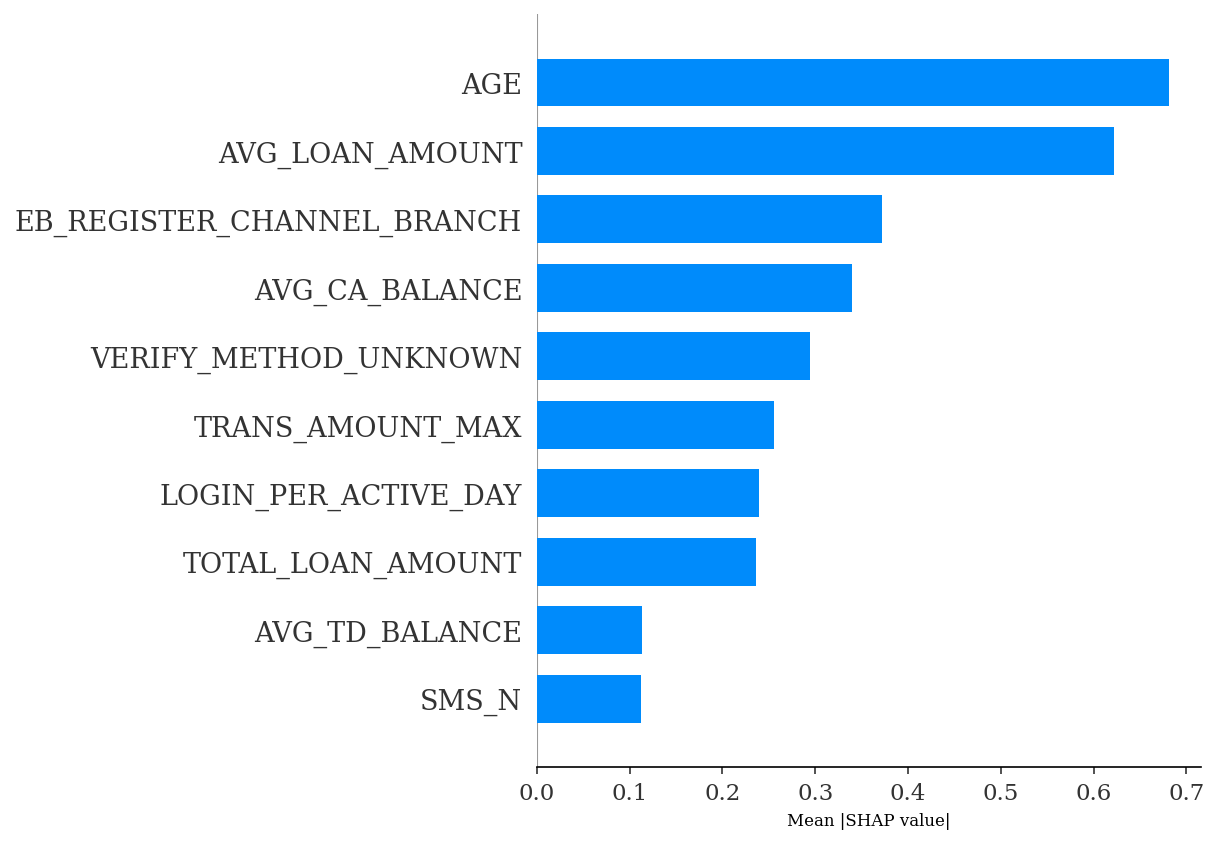

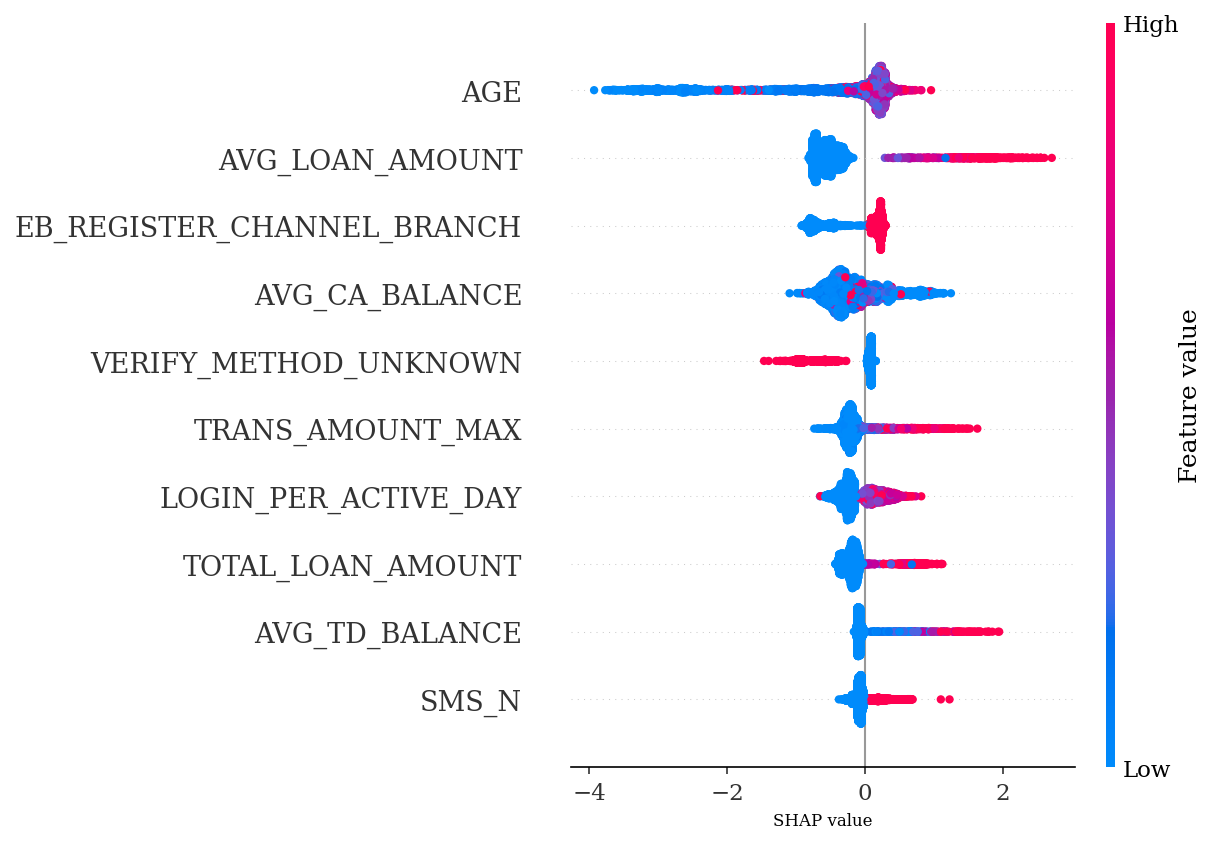

<Figure size 525x450 with 0 Axes>

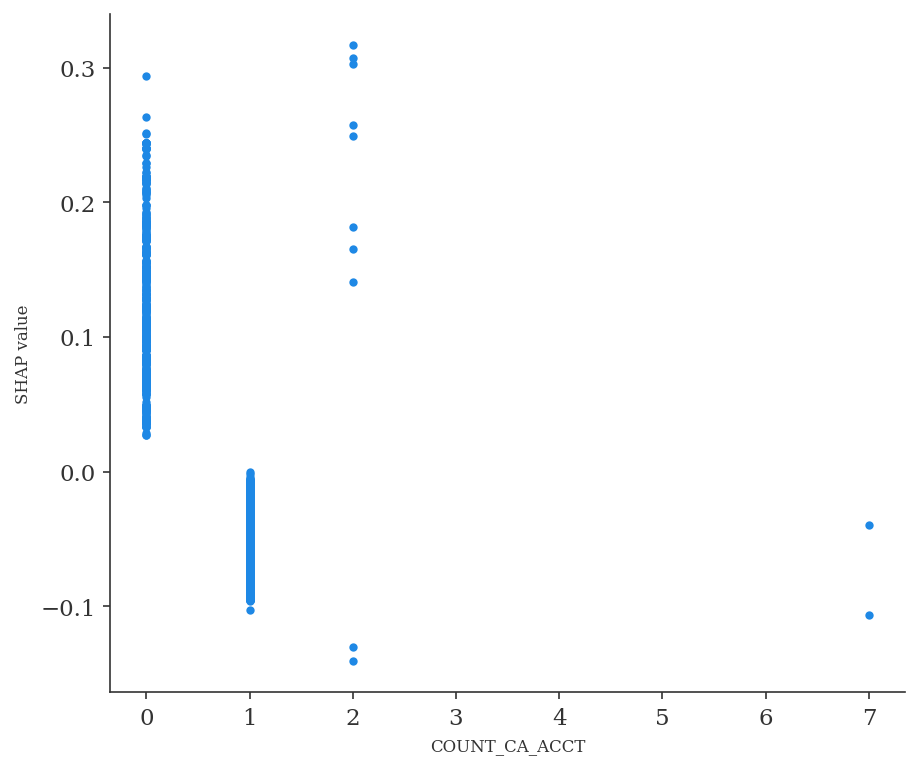


E4 — FLDC-60D
BRANCH A — XGBOOST + NO SAMPLING

Population: 94,453
Train: 75,562
Test: 18,891

CV AUC: 0.908922 ± 0.006680
Test AUC: 0.909824
Test KS: 0.665665
Recall: 0.166857
Precision: 0.532847
F1: 0.254134
Accuracy: 0.954634
Brier: 0.034601
BSS: 0.216693
ECE: 0.003435

Ranking:
  TOP_K  PRECISION     LIFT  CAPTURE_RATE
Top 10%   0.295767 6.385529      0.638857
Top 20%   0.192644 4.159119      0.832000
Top 30%   0.141320 3.051052      0.915429

Top 10 SHAP — original features:
 RANK              FEATURE  MEAN_ABS_SHAP  MEAN_SIGNED_SHAP
    1                  AGE       0.681795         -0.440248
    2      AVG_LOAN_AMOUNT       0.622509         -0.374835
    3  EB_REGISTER_CHANNEL       0.431844         -0.170648
    4        VERIFY_METHOD       0.380846         -0.225765
    5       AVG_CA_BALANCE       0.339534         -0.147427
    6     TRANS_AMOUNT_MAX       0.256058         -0.117954
    7 LOGIN_PER_ACTIVE_DAY       0.239362         -0.089242
    8    TOTAL_LOAN_AMOUNT       0

In [ ]:
# ============================================================
# E4 — FLDC-60D — BRANCH A
# XGBOOST + NO SAMPLING
# GOLDEN E2 CONFIGURATION
#
# PURPOSE
# -------
# Re-run Branch A using the exact Golden E2 population,
# exact Golden E2 train/test split, exact Golden E2 CV folds,
# exact 18 predictors and locked XGBoost configuration.
#
# LOCKED CONFIGURATION
# --------------------
# Population          = 94,453
# Train               = 75,562
# Test                = 18,891
# Predictors          = 18
# Sampling            = None
# random_state        = 42
# n_jobs              = 2
# tree_method         = hist
# max_bin             = 256
# n_estimators        = 300
# max_depth           = 6
# learning_rate       = 0.05
# subsample           = 0.80
# colsample_bytree    = 0.80
#
# OUTPUTS
# --------
# 1. Configuration
# 2. CV fold results
# 3. OOF predictions
# 4. CV summary
# 5. Raw test metrics
# 6. Ranking metrics
# 7. Decile table
# 8. Test predictions
# 9. Calibration diagnostics
# 10. SHAP transformed features
# 11. SHAP original features
# 12. SHAP figures
# 13. Publication table
# 14. Excel workbook
# 15. Golden E2 diagnostic
#
# IMPORTANT
# ---------
# This code DOES NOT alter results to force Golden E2 matching.
# If the installed XGBoost / sklearn environment produces a
# different result, the diagnostic reports the difference.
# ============================================================


# ============================================================
# 0. INSTALL
# ============================================================

!pip -q install -U xgboost openpyxl shap scikit-learn


# ============================================================
# 1. IMPORTS
# ============================================================

import os
import gc
import json
import platform
import sys
import warnings

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

import sklearn
import xgboost
import shap

from google.colab import drive

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    recall_score,
    precision_score,
    f1_score,
    accuracy_score,
    brier_score_loss,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier


warnings.filterwarnings("ignore")


# ============================================================
# 2. GLOBAL CONFIGURATION
# ============================================================

SEED = 42

TEST_SIZE = 0.20
N_SPLITS = 5

THRESHOLD = 0.50

SHAP_SAMPLE_SIZE = 5000
MAX_SHAP_DISPLAY = 10

MODEL_NAME = "XGBoost + No Sampling"

ID_COL = "CUSTOMER_NUMBER"
TARGET_COL = "TARGET_60D"


# ============================================================
# 3. LOCKED GOLDEN E2 XGBOOST CONFIGURATION
# ============================================================

XGB_CONFIG = {

    "n_estimators": 300,

    "max_depth": 6,

    "learning_rate": 0.05,

    "subsample": 0.80,

    "colsample_bytree": 0.80,

    "objective": "binary:logistic",

    "eval_metric": "logloss",

    "random_state": SEED,

    "n_jobs": 2,

    "tree_method": "hist",

    "max_bin": 256
}


# ============================================================
# 4. GOLDEN E2 REFERENCE VALUES
# ============================================================
#
# These values are used ONLY for diagnostic comparison.
# They are NOT used to modify the model.
# ============================================================

E2_REFERENCE = {

    "CV_AUC_MEAN":
        0.909226,

    "CV_AUC_SD":
        0.005908,

    "TEST_AUC":
        0.910242,

    "TEST_KS":
        0.673291,

    "TEST_RECALL":
        0.168000,

    "PRECISION_AT_10":
        0.296825,

    "LIFT_AT_10":
        6.408376,

    "CAPTURE_AT_10":
        0.641143
}

REFERENCE_TOLERANCE = 1e-5


# ============================================================
# 5. MOUNT GOOGLE DRIVE
# ============================================================

print("=" * 110)
print("MOUNT GOOGLE DRIVE")
print("=" * 110)

drive.mount(
    "/content/drive",
    force_remount=False
)

MYDRIVE_ROOT = Path(
    "/content/drive/MyDrive"
)

if not MYDRIVE_ROOT.is_dir():

    raise RuntimeError(
        f"Không truy cập được Google Drive:\n"
        f"{MYDRIVE_ROOT}"
    )


# ============================================================
# 6. PATH CONFIGURATION
# ============================================================

ROOT = (
    MYDRIVE_ROOT
    / "Fintect"
)

INPUT_FILE = (
    ROOT
    / "final_landmark_60d"
    / "final_dataset_landmark_60d_no_auto_job.csv"
)

E2_SPLIT_FILE = (
    ROOT
    / "FINAL_ABC_MATCHED_E2"
    / "exact_E2_shared_train_test_split.csv"
)

E2_CV_FILE = (
    ROOT
    / "FINAL_ABC_MATCHED_E2"
    / "exact_E2_shared_CV_folds.csv"
)

OUTPUT_DIR = (
    ROOT
    / "landmark_60d_training_results"
    / "E4_XGB_NoSampling_GoldenE2_matched"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 7. PRINT CONFIGURATION
# ============================================================

print("\n" + "=" * 110)
print("E4 — FLDC-60D")
print("BRANCH A")
print("XGBOOST + NO SAMPLING")
print("GOLDEN E2 CONFIGURATION")
print("=" * 110)

print(
    "\nInput :",
    INPUT_FILE
)

print(
    "Split :",
    E2_SPLIT_FILE
)

print(
    "CV    :",
    E2_CV_FILE
)

print(
    "Output:",
    OUTPUT_DIR
)

print("\nXGBoost configuration:")

for key, value in XGB_CONFIG.items():

    print(
        f"  {key:20s}: {value}"
    )


# ============================================================
# 8. ENVIRONMENT DIAGNOSTIC
# ============================================================

environment_info = {

    "Python":
        sys.version,

    "Platform":
        platform.platform(),

    "Python executable":
        sys.executable,

    "pandas":
        pd.__version__,

    "numpy":
        np.__version__,

    "sklearn":
        sklearn.__version__,

    "xgboost":
        xgboost.__version__,

    "shap":
        shap.__version__
}

print(
    "\n" + "=" * 110
)

print(
    "ENVIRONMENT"
)

print(
    "=" * 110
)

for key, value in environment_info.items():

    print(
        f"{key}: {value}"
    )


environment_file = (
    OUTPUT_DIR
    / "environment.txt"
)

with open(
    environment_file,
    "w",
    encoding="utf-8"
) as f:

    for key, value in environment_info.items():

        f.write(
            f"{key}: {value}\n"
        )


# ============================================================
# 9. EXACT 18 BRANCH A PREDICTORS
# ============================================================

FEATURES = [

    "CLIENT_SEX",

    "EB_REGISTER_CHANNEL",

    "SMS",

    "VERIFY_METHOD",

    "AGE",

    "LOGIN_PER_ACTIVE_DAY",

    "INTEREST_RATE_RATIO",

    "TRANS_LV1_MODE",

    "TRANS_LV2_MODE",

    "TRANS_AMOUNT_MAX",

    "TRANS_AMOUNT_MEAN",

    "COUNT_CA_ACCT",

    "AVG_CA_BALANCE",

    "COUNT_TD_ACCT",

    "AVG_TD_BALANCE",

    "COUNT_OF_LOAN",

    "AVG_LOAN_AMOUNT",

    "TOTAL_LOAN_AMOUNT"
]

assert len(FEATURES) == 18


# ============================================================
# 10. FIGURE SETTINGS
# ============================================================

mpl.rcParams.update({

    "font.family":
        "serif",

    "font.serif":
        [
            "Times New Roman",
            "Times",
            "DejaVu Serif"
        ],

    "font.size":
        8,

    "axes.labelsize":
        8,

    "axes.titlesize":
        8,

    "xtick.labelsize":
        7,

    "ytick.labelsize":
        7,

    "legend.fontsize":
        7,

    "axes.linewidth":
        0.8,

    "lines.linewidth":
        1.0,

    "figure.dpi":
        150,

    "savefig.dpi":
        600,

    "pdf.fonttype":
        42,

    "ps.fonttype":
        42
})


# ============================================================
# 11. FILE CHECK
# ============================================================

for file_path in [

    INPUT_FILE,
    E2_SPLIT_FILE,
    E2_CV_FILE

]:

    if not file_path.is_file():

        raise FileNotFoundError(
            f"Không tìm thấy file:\n"
            f"{file_path}"
        )


# ============================================================
# 12. MODEL FACTORY
# ============================================================

def get_model():

    return XGBClassifier(
        **XGB_CONFIG
    )


# ============================================================
# 13. CUSTOMER ID STANDARDIZATION
# ============================================================

def standardize_customer_id(series):

    result = (
        series
        .astype("string")
        .str.strip()
        .str.replace(
            r"\.0$",
            "",
            regex=True
        )
    )

    invalid_values = [

        "",

        "NAN",

        "<NA>",

        "NONE",

        "NULL"
    ]

    result = result.mask(
        result.str.upper().isin(
            invalid_values
        ),
        pd.NA
    )

    return result


# ============================================================
# 14. LOAD DATASET
# ============================================================

print(
    "\n" + "=" * 110
)

print(
    "LOAD BRANCH A DATASET"
)

print(
    "=" * 110
)

df = pd.read_csv(
    INPUT_FILE,
    low_memory=False
)

df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.upper()
)


required_columns = [
    ID_COL,
    TARGET_COL
] + FEATURES


missing_columns = [
    col
    for col in required_columns
    if col not in df.columns
]


if missing_columns:

    raise ValueError(
        "Thiếu các cột:\n"
        f"{missing_columns}\n\n"
        "Các cột hiện có:\n"
        f"{df.columns.tolist()}"
    )


# ============================================================
# 15. STANDARDIZE DATA
# ============================================================

df[ID_COL] = standardize_customer_id(
    df[ID_COL]
)


df[TARGET_COL] = pd.to_numeric(
    df[TARGET_COL],
    errors="coerce"
)


df = df.dropna(
    subset=[
        ID_COL,
        TARGET_COL
    ]
).copy()


df[TARGET_COL] = (
    df[TARGET_COL]
    .astype(int)
)


if not df[TARGET_COL].isin(
    [0, 1]
).all():

    raise ValueError(
        "TARGET_60D phải chỉ gồm 0 và 1."
    )


# ============================================================
# 16. DUPLICATE CHECK
# ============================================================

duplicate_count = int(
    df[ID_COL]
    .duplicated()
    .sum()
)


if duplicate_count > 0:

    raise RuntimeError(
        f"Có {duplicate_count:,} "
        f"duplicate CUSTOMER_NUMBER."
    )


print(
    "Dataset shape:",
    df.shape
)

print(
    "Customers:",
    f"{df[ID_COL].nunique():,}"
)

print(
    "Positive:",
    f"{df[TARGET_COL].sum():,}"
)

print(
    "Positive rate:",
    f"{df[TARGET_COL].mean():.6%}"
)


# ============================================================
# 17. EXACT POPULATION CHECK
# ============================================================

EXPECTED_CUSTOMERS = 94453

if len(df) != EXPECTED_CUSTOMERS:

    raise RuntimeError(

        "Số khách hàng không đúng Golden E2.\n"

        f"Expected: "
        f"{EXPECTED_CUSTOMERS:,}\n"

        f"Actual:   "
        f"{len(df):,}"
    )


# ============================================================
# 18. EXCLUDED A-ONLY CUSTOMERS
# ============================================================

excluded_ids = {

    "375383",

    "475787"
}


remaining_excluded = (

    set(
        df[ID_COL]
    )
    &
    excluded_ids
)


if remaining_excluded:

    raise RuntimeError(

        "Branch A vẫn chứa customer A-only:\n"
        f"{sorted(remaining_excluded)}"
    )


# ============================================================
# 19. LOAD GOLDEN E2 TRAIN/TEST SPLIT
# ============================================================

print(
    "\n" + "=" * 110
)

print(
    "LOAD GOLDEN E2 TRAIN / TEST SPLIT"
)

print(
    "=" * 110
)


split_df = pd.read_csv(
    E2_SPLIT_FILE,
    low_memory=False
)


split_df.columns = (
    split_df.columns
    .astype(str)
    .str.strip()
    .str.upper()
)


required_split_columns = [

    ID_COL,

    "TARGET",

    "SPLIT"
]


missing_split = [

    col
    for col in required_split_columns
    if col not in split_df.columns
]


if missing_split:

    raise ValueError(
        f"Golden split thiếu:\n"
        f"{missing_split}"
    )


split_df[ID_COL] = standardize_customer_id(
    split_df[ID_COL]
)


split_df["TARGET"] = pd.to_numeric(
    split_df["TARGET"],
    errors="coerce"
)


split_df["SPLIT"] = (
    split_df["SPLIT"]
    .astype("string")
    .str.strip()
    .str.upper()
)


split_df = split_df.dropna(
    subset=[
        ID_COL,
        "TARGET",
        "SPLIT"
    ]
).copy()


split_df["TARGET"] = (
    split_df["TARGET"]
    .astype(int)
)


# ============================================================
# 20. SPLIT POPULATION CHECK
# ============================================================

data_ids = set(
    df[ID_COL]
)


split_ids = set(
    split_df[ID_COL]
)


print(
    "Dataset customers:",
    f"{len(data_ids):,}"
)

print(
    "Split customers:",
    f"{len(split_ids):,}"
)


if data_ids != split_ids:

    missing = (
        data_ids
        -
        split_ids
    )

    extra = (
        split_ids
        -
        data_ids
    )

    raise RuntimeError(

        "Population không khớp Golden E2.\n"

        f"Missing: "
        f"{sorted(missing)[:20]}\n"

        f"Extra: "
        f"{sorted(extra)[:20]}"
    )


# ============================================================
# 21. TARGET CHECK
# ============================================================

target_check = (

    df[
        [
            ID_COL,
            TARGET_COL
        ]
    ]

    .rename(
        columns={
            TARGET_COL:
                "TARGET_DATA"
        }
    )

    .merge(
        split_df[
            [
                ID_COL,
                "TARGET"
            ]
        ],

        on=ID_COL,

        how="inner",

        validate="one_to_one"
    )
)


target_mismatch = (

    target_check[
        "TARGET_DATA"
    ]
    !=
    target_check[
        "TARGET"
    ]
)


if target_mismatch.any():

    mismatch_rows = (
        target_check.loc[
            target_mismatch
        ]
        .head(20)
    )

    raise RuntimeError(
        "TARGET_DATA khác TARGET trong "
        "Golden E2.\n"
        f"{mismatch_rows}"
    )


# ============================================================
# 22. EXACT TRAIN / TEST IDs
# ============================================================

train_ids = set(

    split_df.loc[
        split_df["SPLIT"] == "TRAIN",
        ID_COL
    ]
)


test_ids = set(

    split_df.loc[
        split_df["SPLIT"] == "TEST",
        ID_COL
    ]
)


if train_ids & test_ids:

    raise RuntimeError(
        "TRAIN/TEST customer overlap."
    )


if (
    len(train_ids)
    +
    len(test_ids)
    !=
    EXPECTED_CUSTOMERS
):

    raise RuntimeError(
        "TRAIN + TEST != 94,453."
    )


print(
    "\nGolden E2 Train:",
    f"{len(train_ids):,}"
)

print(
    "Golden E2 Test :",
    f"{len(test_ids):,}"
)


# ============================================================
# 23. LOAD GOLDEN E2 CV
# ============================================================

print(
    "\n" + "=" * 110
)

print(
    "LOAD GOLDEN E2 CV"
)

print(
    "=" * 110
)


cv_df = pd.read_csv(
    E2_CV_FILE,
    low_memory=False
)


cv_df.columns = (
    cv_df.columns
    .astype(str)
    .str.strip()
    .str.upper()
)


required_cv_columns = [

    ID_COL,

    "TARGET",

    "CV_FOLD"
]


missing_cv = [

    col
    for col in required_cv_columns
    if col not in cv_df.columns
]


if missing_cv:

    raise ValueError(
        f"Golden CV thiếu:\n"
        f"{missing_cv}"
    )


cv_df[ID_COL] = standardize_customer_id(
    cv_df[ID_COL]
)


cv_df["TARGET"] = pd.to_numeric(
    cv_df["TARGET"],
    errors="coerce"
)


cv_df["CV_FOLD"] = pd.to_numeric(
    cv_df["CV_FOLD"],
    errors="coerce"
)


cv_df = cv_df.dropna(
    subset=[
        ID_COL,
        "TARGET",
        "CV_FOLD"
    ]
).copy()


cv_df["TARGET"] = (
    cv_df["TARGET"]
    .astype(int)
)


cv_df["CV_FOLD"] = (
    cv_df["CV_FOLD"]
    .astype(int)
)


# ============================================================
# 24. VERIFY GOLDEN CV
# ============================================================

train_cv = cv_df[
    cv_df[ID_COL].isin(
        train_ids
    )
].copy()


if len(train_cv) != len(train_ids):

    raise RuntimeError(
        "Golden CV không có đủ "
        "75,562 TRAIN customers."
    )


if (
    train_cv[ID_COL]
    .duplicated()
    .any()
):

    raise RuntimeError(
        "Golden CV có duplicate customers."
    )


valid_folds = set(
    train_cv["CV_FOLD"]
)


if valid_folds != {

    1,
    2,
    3,
    4,
    5

}:

    raise RuntimeError(
        f"CV folds không đúng 1-5: "
        f"{valid_folds}"
    )


print(
    "\nGolden CV fold counts:"
)

print(
    train_cv[
        "CV_FOLD"
    ]
    .value_counts()
    .sort_index()
)


# ============================================================
# 25. BUILD FEATURE MATRIX
# ============================================================

X = df[
    FEATURES
].copy()


y = df[
    TARGET_COL
].copy()


customer_ids = (
    df[ID_COL]
    .copy()
)


# ============================================================
# 26. IDENTIFY NUMERIC / CATEGORICAL
# ============================================================

numeric_cols = (

    X
    .select_dtypes(
        include=np.number
    )
    .columns
    .tolist()
)


categorical_cols = (

    X
    .select_dtypes(
        exclude=np.number
    )
    .columns
    .tolist()
)


print(
    "\nNumeric columns:"
)

print(
    numeric_cols
)


print(
    "\nCategorical columns:"
)

print(
    categorical_cols
)


# ============================================================
# 27. PREPROCESSING
# ============================================================

numeric_pipe = Pipeline([

    (
        "imputer",

        SimpleImputer(
            strategy="constant",
            fill_value=0
        )
    )
])


categorical_pipe = Pipeline([

    (
        "imputer",

        SimpleImputer(
            strategy="constant",
            fill_value="MISSING"
        )
    ),

    (
        "onehot",

        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])


def build_preprocessor():

    return ColumnTransformer([

        (
            "num",
            numeric_pipe,
            numeric_cols
        ),

        (
            "cat",
            categorical_pipe,
            categorical_cols
        )
    ])


# ============================================================
# 28. EXACT TRAIN / TEST DATA
# ============================================================

train_mask = (
    customer_ids.isin(
        train_ids
    )
)


test_mask = (
    customer_ids.isin(
        test_ids
    )
)


X_train = (

    X.loc[
        train_mask
    ]
    .reset_index(
        drop=True
    )
)


X_test = (

    X.loc[
        test_mask
    ]
    .reset_index(
        drop=True
    )
)


y_train = (

    y.loc[
        train_mask
    ]
    .reset_index(
        drop=True
    )
)


y_test = (

    y.loc[
        test_mask
    ]
    .reset_index(
        drop=True
    )
)


train_customer_ids = (

    customer_ids
    .loc[
        train_mask
    ]
    .reset_index(
        drop=True
    )
)


test_customer_ids = (

    customer_ids
    .loc[
        test_mask
    ]
    .reset_index(
        drop=True
    )
)


# ============================================================
# 29. TRAIN / TEST VALIDATION
# ============================================================

if len(X_train) != len(train_ids):

    raise RuntimeError(
        "X_train length mismatch."
    )


if len(X_test) != len(test_ids):

    raise RuntimeError(
        "X_test length mismatch."
    )


if (
    set(train_customer_ids)
    !=
    train_ids
):

    raise RuntimeError(
        "TRAIN customer set mismatch."
    )


if (
    set(test_customer_ids)
    !=
    test_ids
):

    raise RuntimeError(
        "TEST customer set mismatch."
    )


if (
    set(train_customer_ids)
    &
    set(test_customer_ids)
):

    raise RuntimeError(
        "TRAIN/TEST overlap."
    )


print(
    "\n" + "=" * 110
)

print(
    "EXACT E2 TRAIN / TEST"
)

print(
    "=" * 110
)

print(
    "Train:",
    f"{len(X_train):,}"
)

print(
    "Test :",
    f"{len(X_test):,}"
)

print(
    "Train base rate:",
    f"{y_train.mean():.6%}"
)

print(
    "Test base rate :",
    f"{y_test.mean():.6%}"
)


# ============================================================
# 30. METRIC FUNCTIONS
# ============================================================

def ks_score(
    y_true,
    probability
):

    fpr, tpr, _ = roc_curve(
        y_true,
        probability
    )

    return float(
        np.max(
            tpr - fpr
        )
    )


def bss_score(
    y_true,
    probability
):

    brier = brier_score_loss(
        y_true,
        probability
    )

    prevalence = float(
        np.mean(
            y_true
        )
    )

    reference = (
        prevalence
        *
        (1 - prevalence)
    )

    if reference <= 0:

        return np.nan

    return float(
        1
        -
        brier
        /
        reference
    )


def ece_score(
    y_true,
    probability,
    n_bins=10
):

    y_true = np.asarray(
        y_true
    )

    probability = np.asarray(
        probability
    )

    bins = np.linspace(
        0,
        1,
        n_bins + 1
    )

    ece = 0.0

    for i in range(
        n_bins
    ):

        if i == n_bins - 1:

            mask = (

                (probability >= bins[i])
                &
                (probability <= bins[i + 1])
            )

        else:

            mask = (

                (probability >= bins[i])
                &
                (probability < bins[i + 1])
            )


        if not mask.any():

            continue


        observed = (
            y_true[mask]
            .mean()
        )


        predicted = (
            probability[mask]
            .mean()
        )


        weight = (
            mask.sum()
            /
            len(y_true)
        )


        ece += (
            weight
            *
            abs(
                observed
                -
                predicted
            )
        )


    return float(
        ece
    )


# ============================================================
# 31. RANKING METRICS
# ============================================================

def ranking_metrics(
    y_true,
    probability
):

    ranking = pd.DataFrame({

        "Y_TRUE":
            np.asarray(
                y_true,
                dtype=int
            ),

        "Y_PROB":
            np.asarray(
                probability,
                dtype=float
            )
    })


    ranking = (

        ranking
        .sort_values(
            "Y_PROB",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )


    base_rate = float(
        ranking[
            "Y_TRUE"
        ].mean()
    )


    total_positive = int(
        ranking[
            "Y_TRUE"
        ].sum()
    )


    rows = []


    for rate in [

        0.10,

        0.20,

        0.30

    ]:


        top_n = max(

            1,

            int(
                np.ceil(
                    len(ranking)
                    *
                    rate
                )
            )
        )


        top_df = (
            ranking
            .iloc[
                :top_n
            ]
        )


        precision = float(
            top_df[
                "Y_TRUE"
            ].mean()
        )


        captured_positive = int(
            top_df[
                "Y_TRUE"
            ].sum()
        )


        capture_rate = (

            captured_positive
            /
            total_positive
        )


        lift = (

            precision
            /
            base_rate
        )


        rows.append({

            "TOP_K":
                f"Top {int(rate * 100)}%",

            "TOP_RATE":
                rate,

            "CUSTOMERS":
                top_n,

            "PRECISION":
                precision,

            "LIFT":
                lift,

            "CAPTURED_POSITIVES":
                captured_positive,

            "CAPTURE_RATE":
                capture_rate
        })


    return pd.DataFrame(
        rows
    )


# ============================================================
# 32. DECILE TABLE
# ============================================================

def create_decile_table(
    y_true,
    probability
):

    ranking = pd.DataFrame({

        "Y_TRUE":
            np.asarray(
                y_true
            ),

        "Y_PROB":
            np.asarray(
                probability
            )
    })


    ranking = (

        ranking
        .sort_values(
            "Y_PROB",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )


    ranking["DECILE"] = pd.qcut(

        np.arange(
            len(ranking)
        ),

        q=10,

        labels=[
            f"D{i}"
            for i in range(
                1,
                11
            )
        ]
    )


    base_rate = (

        ranking[
            "Y_TRUE"
        ]
        .mean()
    )


    result = (

        ranking
        .groupby(
            "DECILE",
            observed=False
        )
        .agg(

            CUSTOMERS=(
                "Y_TRUE",
                "count"
            ),

            POSITIVES=(
                "Y_TRUE",
                "sum"
            ),

            ADOPTION_RATE=(
                "Y_TRUE",
                "mean"
            ),

            AVG_PRED_PROB=(
                "Y_PROB",
                "mean"
            )
        )
        .reset_index()
    )


    result["LIFT"] = (

        result[
            "ADOPTION_RATE"
        ]
        /
        base_rate
    )


    return result


# ============================================================
# 33. GOLDEN E2 OOF CV
# ============================================================

print(
    "\n" + "=" * 110
)

print(
    "GENERATING EXACT GOLDEN E2 OOF PROBABILITIES"
)

print(
    "=" * 110
)


cv_rows = []


oof_predictions = pd.DataFrame({

    ID_COL:
        train_customer_ids,

    "Y_TRUE":
        y_train,

    "OOF_PROB":
        np.nan,

    "CV_FOLD":
        np.nan
})


train_id_series = (
    train_customer_ids.copy()
)


for fold in range(
    1,
    N_SPLITS + 1
):

    print(
        f"\nRunning Golden E2 fold "
        f"{fold}/{N_SPLITS}..."
    )


    valid_ids = set(

        train_cv.loc[
            train_cv["CV_FOLD"] == fold,
            ID_COL
        ]
    )


    fold_train_ids = (

        train_ids
        -
        valid_ids
    )


    fold_train_mask = (

        train_id_series
        .isin(
            fold_train_ids
        )
        .to_numpy()
    )


    fold_valid_mask = (

        train_id_series
        .isin(
            valid_ids
        )
        .to_numpy()
    )


    X_fold_train = (

        X_train
        .loc[
            fold_train_mask
        ]
        .copy()
    )


    X_fold_valid = (

        X_train
        .loc[
            fold_valid_mask
        ]
        .copy()
    )


    y_fold_train = (

        y_train
        .loc[
            fold_train_mask
        ]
    )


    y_fold_valid = (

        y_train
        .loc[
            fold_valid_mask
        ]
    )


    fold_preprocessor = (
        build_preprocessor()
    )


    X_fold_train_p = (

        fold_preprocessor
        .fit_transform(
            X_fold_train
        )
    )


    X_fold_valid_p = (

        fold_preprocessor
        .transform(
            X_fold_valid
        )
    )


    fold_model = get_model()


    fold_model.fit(

        X_fold_train_p,

        y_fold_train
    )


    fold_probability = (

        fold_model
        .predict_proba(
            X_fold_valid_p
        )[:, 1]
    )


    fold_prediction = (

        fold_probability
        >= THRESHOLD
    ).astype(
        np.int8
    )


    fold_auc = roc_auc_score(

        y_fold_valid,

        fold_probability
    )


    fold_ks = ks_score(

        y_fold_valid,

        fold_probability
    )


    fold_recall = recall_score(

        y_fold_valid,

        fold_prediction,

        zero_division=0
    )


    fold_precision = precision_score(

        y_fold_valid,

        fold_prediction,

        zero_division=0
    )


    fold_f1 = f1_score(

        y_fold_valid,

        fold_prediction,

        zero_division=0
    )


    fold_accuracy = accuracy_score(

        y_fold_valid,

        fold_prediction
    )


    fold_brier = brier_score_loss(

        y_fold_valid,

        fold_probability
    )


    fold_bss = bss_score(

        y_fold_valid,

        fold_probability
    )


    fold_ece = ece_score(

        y_fold_valid,

        fold_probability
    )


    cv_rows.append({

        "FOLD":
            fold,

        "N_VALID":
            int(
                fold_valid_mask.sum()
            ),

        "AUC":
            fold_auc,

        "KS":
            fold_ks,

        "RECALL":
            fold_recall,

        "PRECISION":
            fold_precision,

        "F1":
            fold_f1,

        "ACCURACY":
            fold_accuracy,

        "BRIER":
            fold_brier,

        "BSS":
            fold_bss,

        "ECE":
            fold_ece
    })


    valid_positions = np.where(
        fold_valid_mask
    )[0]


    oof_predictions.loc[
        valid_positions,
        "OOF_PROB"
    ] = fold_probability


    oof_predictions.loc[
        valid_positions,
        "CV_FOLD"
    ] = fold


    print(

        f"Fold {fold}: "

        f"AUC={fold_auc:.6f} | "

        f"KS={fold_ks:.6f} | "

        f"Brier={fold_brier:.6f}"
    )


    del fold_model
    del fold_preprocessor
    del X_fold_train_p
    del X_fold_valid_p

    gc.collect()


# ============================================================
# 34. VERIFY OOF COMPLETENESS
# ============================================================

if (
    oof_predictions[
        "OOF_PROB"
    ]
    .isna()
    .any()
):

    raise RuntimeError(
        "OOF probabilities không đầy đủ."
    )


# ============================================================
# 35. CV RESULTS
# ============================================================

cv_results = pd.DataFrame(
    cv_rows
)


print(
    "\n" + "=" * 110
)

print(
    "GOLDEN E2 CV RESULTS"
)

print(
    "=" * 110
)

print(
    cv_results.to_string(
        index=False
    )
)


# ============================================================
# 36. CV SUMMARY
# ============================================================

cv_metric_columns = [

    "AUC",

    "KS",

    "RECALL",

    "PRECISION",

    "F1",

    "ACCURACY",

    "BRIER",

    "BSS",

    "ECE"
]


cv_summary_rows = []


for metric in cv_metric_columns:

    mean_value = float(

        cv_results[
            metric
        ].mean()
    )


    sd_value = float(

        cv_results[
            metric
        ].std(
            ddof=1
        )
    )


    cv_summary_rows.append({

        "METRIC":
            metric,

        "MEAN":
            mean_value,

        "STD":
            sd_value,

        "MEAN_PLUS_MINUS_SD":
            (
                f"{mean_value:.6f} ± "
                f"{sd_value:.6f}"
            )
    })


cv_summary = pd.DataFrame(
    cv_summary_rows
)


print(
    "\nCV SUMMARY"
)


print(
    cv_summary[
        [
            "METRIC",
            "MEAN_PLUS_MINUS_SD"
        ]
    ]
    .to_string(
        index=False
    )
)


# ============================================================
# 37. OOF OVERALL METRICS
# ============================================================

oof_auc = roc_auc_score(

    oof_predictions[
        "Y_TRUE"
    ],

    oof_predictions[
        "OOF_PROB"
    ]
)


oof_ks = ks_score(

    oof_predictions[
        "Y_TRUE"
    ],

    oof_predictions[
        "OOF_PROB"
    ]
)


print(
    "\nOOF AUC:",
    f"{oof_auc:.6f}"
)

print(
    "OOF KS :",
    f"{oof_ks:.6f}"
)


# ============================================================
# 38. FINAL MODEL
# ============================================================

print(
    "\n" + "=" * 110
)

print(
    "FINAL MODEL — FULL GOLDEN E2 TRAIN"
)

print(
    "=" * 110
)


final_preprocessor = (
    build_preprocessor()
)


X_train_processed = (

    final_preprocessor
    .fit_transform(
        X_train
    )
)


X_test_processed = (

    final_preprocessor
    .transform(
        X_test
    )
)


print(
    "Processed train shape:",
    X_train_processed.shape
)

print(
    "Processed test shape :",
    X_test_processed.shape
)


final_model = get_model()


final_model.fit(

    X_train_processed,

    y_train
)


# ============================================================
# 39. RAW TEST PROBABILITIES
# ============================================================

prob_test_raw = (

    final_model
    .predict_proba(
        X_test_processed
    )[:, 1]
)


pred_test_raw = (

    prob_test_raw
    >= THRESHOLD
).astype(
    np.int8
)


# ============================================================
# 40. TEST METRICS
# ============================================================

test_auc = roc_auc_score(

    y_test,

    prob_test_raw
)


test_ks = ks_score(

    y_test,

    prob_test_raw
)


test_recall = recall_score(

    y_test,

    pred_test_raw,

    zero_division=0
)


test_precision = precision_score(

    y_test,

    pred_test_raw,

    zero_division=0
)


test_f1 = f1_score(

    y_test,

    pred_test_raw,

    zero_division=0
)


test_accuracy = accuracy_score(

    y_test,

    pred_test_raw
)


test_brier = brier_score_loss(

    y_test,

    prob_test_raw
)


test_bss = bss_score(

    y_test,

    prob_test_raw
)


test_ece = ece_score(

    y_test,

    prob_test_raw
)


tn, fp, fn, tp = (

    confusion_matrix(

        y_test,

        pred_test_raw,

        labels=[
            0,
            1
        ]
    )
    .ravel()
)


specificity = (

    tn
    /
    (tn + fp)

    if (
        tn + fp
    ) > 0

    else np.nan
)


npv = (

    tn
    /
    (tn + fn)

    if (
        tn + fn
    ) > 0

    else np.nan
)


mcc_denominator = np.sqrt(

    (tp + fp)
    *
    (tp + fn)
    *
    (tn + fp)
    *
    (tn + fn)
)


mcc = (

    (
        tp * tn
        -
        fp * fn
    )
    /
    mcc_denominator

    if mcc_denominator > 0

    else np.nan
)


# ============================================================
# 41. TEST REPORT
# ============================================================

print(
    "\n" + "=" * 110
)

print(
    "RAW TEST RESULTS"
)

print(
    "=" * 110
)


print(
    f"AUC         = {test_auc:.6f}"
)

print(
    f"KS          = {test_ks:.6f}"
)

print(
    f"Recall      = {test_recall:.6f}"
)

print(
    f"Precision   = {test_precision:.6f}"
)

print(
    f"F1          = {test_f1:.6f}"
)

print(
    f"Accuracy    = {test_accuracy:.6f}"
)

print(
    f"Brier       = {test_brier:.6f}"
)

print(
    f"BSS         = {test_bss:.6f}"
)

print(
    f"ECE         = {test_ece:.6f}"
)

print(
    f"MCC         = {mcc:.6f}"
)

print(
    f"Specificity = {specificity:.6f}"
)

print(
    f"NPV         = {npv:.6f}"
)


print(
    "\nConfusion matrix:"
)


print(
    np.array([
        [
            tn,
            fp
        ],
        [
            fn,
            tp
        ]
    ])
)


print(
    "\nClassification report:"
)


print(
    classification_report(

        y_test,

        pred_test_raw,

        digits=4,

        zero_division=0
    )
)


# ============================================================
# 42. RANKING METRICS
# ============================================================

ranking = ranking_metrics(

    y_test,

    prob_test_raw
)


print(
    "\n" + "=" * 110
)

print(
    "RANKING METRICS"
)

print(
    "=" * 110
)


print(
    ranking.to_string(
        index=False
    )
)


top10 = ranking.iloc[0]

top20 = ranking.iloc[1]

top30 = ranking.iloc[2]


# ============================================================
# 43. DECILE TABLE
# ============================================================

deciles = create_decile_table(

    y_test,

    prob_test_raw
)


print(
    "\n" + "=" * 110
)

print(
    "DECILE TABLE"
)

print(
    "=" * 110
)


print(
    deciles.to_string(
        index=False
    )
)


# ============================================================
# 44. TEST PREDICTIONS
# ============================================================

predictions = pd.DataFrame({

    ID_COL:
        test_customer_ids.to_numpy(),

    "Y_TRUE":
        y_test.to_numpy(),

    "Y_PROB":
        prob_test_raw,

    "Y_PRED":
        pred_test_raw
})


predictions = (

    predictions
    .sort_values(
        ID_COL
    )
    .reset_index(
        drop=True
    )
)


if (
    set(
        predictions[ID_COL]
    )
    !=
    test_ids
):

    raise RuntimeError(
        "Test predictions không chứa đúng "
        "18,891 customer IDs."
    )


if len(
    predictions
) != len(test_ids):

    raise RuntimeError(
        "Số dòng predictions không đúng "
        "test population."
    )


# ============================================================
# 45. GOLDEN E2 REFERENCE CHECK
# ============================================================
#
# IMPORTANT:
# Ranking values are now explicitly included.
# This fixes the previous:
#
# KeyError: 'PRECISION_AT_10'
# ============================================================

reference_current_values = {

    "CV_AUC_MEAN":
        float(
            cv_results[
                "AUC"
            ].mean()
        ),

    "CV_AUC_SD":
        float(
            cv_results[
                "AUC"
            ].std(
                ddof=1
            )
        ),

    "TEST_AUC":
        float(
            test_auc
        ),

    "TEST_KS":
        float(
            test_ks
        ),

    "TEST_RECALL":
        float(
            test_recall
        ),

    "PRECISION_AT_10":
        float(
            top10[
                "PRECISION"
            ]
        ),

    "LIFT_AT_10":
        float(
            top10[
                "LIFT"
            ]
        ),

    "CAPTURE_AT_10":
        float(
            top10[
                "CAPTURE_RATE"
            ]
        )
}


reference_rows = []


for metric, expected in E2_REFERENCE.items():

    if metric not in reference_current_values:

        reference_rows.append({

            "METRIC":
                metric,

            "E2_REFERENCE":
                float(expected),

            "CURRENT":
                np.nan,

            "ABS_DIFFERENCE":
                np.nan,

            "PASS":
                False,

            "STATUS":
                "MISSING CURRENT VALUE"
        })

        continue


    actual = float(

        reference_current_values[
            metric
        ]
    )


    difference = abs(

        actual
        -
        float(expected)
    )


    reference_rows.append({

        "METRIC":
            metric,

        "E2_REFERENCE":
            float(expected),

        "CURRENT":
            actual,

        "ABS_DIFFERENCE":
            difference,

        "PASS":
            (
                difference
                <=
                REFERENCE_TOLERANCE
            ),

        "STATUS":
            (
                "PASS"
                if (
                    difference
                    <=
                    REFERENCE_TOLERANCE
                )
                else
                "MISMATCH"
            )
    })


reference_check = pd.DataFrame(
    reference_rows
)


print(
    "\n" + "=" * 110
)

print(
    "GOLDEN E2 REFERENCE CHECK"
)

print(
    "=" * 110
)


print(
    reference_check.to_string(
        index=False
    )
)


golden_e2_pass = bool(

    reference_check[
        "PASS"
    ].all()
)


if golden_e2_pass:

    print(
        "\nSUCCESS:"
    )

    print(
        "Current Branch A reproduces "
        "all configured Golden E2 references."
    )

else:

    print(
        "\nWARNING:"
    )

    print(
        "Current Branch A DOES NOT reproduce "
        "all configured Golden E2 references."
    )

    print(
        "Do not change the model parameters merely "
        "to force agreement."
    )


# ============================================================
# 46. CALIBRATION DIAGNOSTIC
# ============================================================
#
# Calibration should be treated separately from the raw
# Golden E2 reproduction.
#
# This section does NOT modify raw probabilities.
# ============================================================

calibration_bins = np.linspace(
    0,
    1,
    11
)


calibration_rows = []


for i in range(10):

    if i == 9:

        mask = (

            (prob_test_raw >= calibration_bins[i])
            &
            (prob_test_raw <= calibration_bins[i + 1])
        )

    else:

        mask = (

            (prob_test_raw >= calibration_bins[i])
            &
            (prob_test_raw < calibration_bins[i + 1])
        )


    if not mask.any():

        calibration_rows.append({

            "BIN":
                f"{calibration_bins[i]:.1f}-"
                f"{calibration_bins[i + 1]:.1f}",

            "N":
                0,

            "MEAN_PRED":
                np.nan,

            "OBSERVED_RATE":
                np.nan
        })

        continue


    calibration_rows.append({

        "BIN":
            f"{calibration_bins[i]:.1f}-"
            f"{calibration_bins[i + 1]:.1f}",

        "N":
            int(mask.sum()),

        "MEAN_PRED":
            float(
                prob_test_raw[mask].mean()
            ),

        "OBSERVED_RATE":
            float(
                y_test.to_numpy()[mask].mean()
            )
    })


calibration_table = pd.DataFrame(
    calibration_rows
)


print(
    "\n" + "=" * 110
)

print(
    "RAW MODEL CALIBRATION DIAGNOSTIC"
)

print(
    "=" * 110
)


print(
    calibration_table.to_string(
        index=False
    )
)


# ============================================================
# 47. SHAP
# ============================================================

print(
    "\n" + "=" * 110
)

print(
    "SHAP ANALYSIS"
)

print(
    "=" * 110
)


try:

    transformed_feature_names = (

        final_preprocessor
        .get_feature_names_out()
    )

except Exception:

    transformed_feature_names = np.array([

        f"FEATURE_{i}"

        for i in range(
            X_test_processed.shape[1]
        )
    ])


clean_feature_names = []


for name in transformed_feature_names:

    name = str(name)

    if "__" in name:

        name = name.split(
            "__",
            1
        )[1]

    clean_feature_names.append(
        name
    )


clean_feature_names = np.array(
    clean_feature_names
)


# ============================================================
# 48. SHAP SAMPLE
# ============================================================

n_shap = min(

    SHAP_SAMPLE_SIZE,

    len(
        X_test_processed
    )
)


rng = np.random.default_rng(
    SEED
)


shap_indices = (

    rng.choice(

        len(
            X_test_processed
        ),

        size=n_shap,

        replace=False
    )
)


X_shap_array = (

    X_test_processed[
        shap_indices
    ]
)


X_shap_df = pd.DataFrame(

    X_shap_array,

    columns=clean_feature_names
)


print(
    "SHAP sample:",
    n_shap
)


print(
    "Transformed features:",
    X_shap_df.shape[1]
)


# ============================================================
# 49. TREE SHAP
# ============================================================

explainer = shap.TreeExplainer(
    final_model
)


shap_raw = (

    explainer
    .shap_values(
        X_shap_array
    )
)


if isinstance(
    shap_raw,
    list
):

    shap_values = np.asarray(
        shap_raw[-1]
    )

else:

    shap_values = np.asarray(
        shap_raw
    )


if shap_values.ndim == 3:

    shap_values = (
        shap_values[:, :, -1]
    )


if (

    shap_values.shape
    !=
    X_shap_df.shape

):

    raise RuntimeError(

        "SHAP shape không khớp."

        f"\nSHAP = "
        f"{shap_values.shape}"

        f"\nX    = "
        f"{X_shap_df.shape}"
    )


# ============================================================
# 50. SHAP TRANSFORMED
# ============================================================

shap_transformed = pd.DataFrame({

    "FEATURE":
        clean_feature_names,

    "MEAN_ABS_SHAP":
        np.abs(
            shap_values
        ).mean(
            axis=0
        ),

    "MEAN_SIGNED_SHAP":
        shap_values.mean(
            axis=0
        )
})


shap_transformed = (

    shap_transformed
    .sort_values(
        "MEAN_ABS_SHAP",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


shap_transformed.insert(

    0,

    "RANK",

    np.arange(

        1,

        len(
            shap_transformed
        )
        +
        1
    )
)


print(
    "\nTop transformed SHAP features:"
)


print(

    shap_transformed
    .head(20)
    .to_string(
        index=False
    )
)


# ============================================================
# 51. MAP SHAP TO ORIGINAL FEATURES
# ============================================================

def map_to_original_feature(
    transformed_name
):

    if transformed_name in FEATURES:

        return transformed_name


    candidates = sorted(

        FEATURES,

        key=len,

        reverse=True
    )


    for feature in candidates:

        prefix = (
            feature
            +
            "_"
        )


        if transformed_name.startswith(
            prefix
        ):

            return feature


    return transformed_name


shap_original_source = (

    shap_transformed[
        [
            "FEATURE",
            "MEAN_ABS_SHAP",
            "MEAN_SIGNED_SHAP"
        ]
    ]
    .copy()
)


shap_original_source[
    "ORIGINAL_FEATURE"
] = (

    shap_original_source[
        "FEATURE"
    ]
    .apply(
        map_to_original_feature
    )
)


shap_original = (

    shap_original_source
    .groupby(
        "ORIGINAL_FEATURE",
        as_index=False
    )
    .agg(

        MEAN_ABS_SHAP=(
            "MEAN_ABS_SHAP",
            "sum"
        ),

        MEAN_SIGNED_SHAP=(
            "MEAN_SIGNED_SHAP",
            "sum"
        )
    )
    .sort_values(
        "MEAN_ABS_SHAP",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


shap_original.insert(

    0,

    "RANK",

    np.arange(

        1,

        len(
            shap_original
        )
        +
        1
    )
)


shap_original = (

    shap_original
    .rename(
        columns={

            "ORIGINAL_FEATURE":
                "FEATURE"
        }
    )
)


print(
    "\nTop original features by SHAP:"
)


print(

    shap_original
    .head(10)
    .to_string(
        index=False
    )
)


# ============================================================
# 52. SHAP BAR FIGURE
# ============================================================

SHAP_BAR_PNG = (

    OUTPUT_DIR
    /
    "Fig_8_FLDC60_E2matched_XGB_NoSampling_SHAP_Bar_600dpi.png"
)


SHAP_BAR_PDF = (

    OUTPUT_DIR
    /
    "Fig_8_FLDC60_E2matched_XGB_NoSampling_SHAP_Bar.pdf"
)


plt.figure(

    figsize=(
        3.5,
        3.2
    )
)


shap.summary_plot(

    shap_values,

    X_shap_df,

    plot_type="bar",

    max_display=MAX_SHAP_DISPLAY,

    show=False
)


plt.xlabel(

    "Mean |SHAP value|",

    fontsize=8
)


plt.tight_layout(
    pad=0.3
)


plt.savefig(

    SHAP_BAR_PNG,

    dpi=600,

    bbox_inches="tight",

    pad_inches=0.02
)


plt.savefig(

    SHAP_BAR_PDF,

    bbox_inches="tight",

    pad_inches=0.02
)


plt.show()

plt.close()


# ============================================================
# 53. SHAP BEESWARM
# ============================================================

SHAP_BEESWARM_PNG = (

    OUTPUT_DIR
    /
    "Fig_8_FLDC60_E2matched_XGB_NoSampling_SHAP_Beeswarm_600dpi.png"
)


SHAP_BEESWARM_PDF = (

    OUTPUT_DIR
    /
    "Fig_8_FLDC60_E2matched_XGB_NoSampling_SHAP_Beeswarm.pdf"
)


plt.figure(

    figsize=(
        4.0,
        4.0
    )
)


shap.summary_plot(

    shap_values,

    X_shap_df,

    max_display=MAX_SHAP_DISPLAY,

    show=False
)


plt.xlabel(

    "SHAP value",

    fontsize=8
)


plt.tight_layout(
    pad=0.3
)


plt.savefig(

    SHAP_BEESWARM_PNG,

    dpi=600,

    bbox_inches="tight",

    pad_inches=0.02
)


plt.savefig(

    SHAP_BEESWARM_PDF,

    bbox_inches="tight",

    pad_inches=0.02
)


plt.show()

plt.close()


# ============================================================
# 54. COUNT_CA_ACCT DEPENDENCE
# ============================================================

count_ca_png = None

count_ca_pdf = None


if "COUNT_CA_ACCT" in FEATURES:

    count_feature_name = None


    for name in clean_feature_names:

        if name == "COUNT_CA_ACCT":

            count_feature_name = name

            break


    if count_feature_name is not None:

        count_ca_png = (

            OUTPUT_DIR
            /
            "Fig_FLDC60_E2matched_COUNT_CA_ACCT_Dependence_600dpi.png"
        )


        count_ca_pdf = (

            OUTPUT_DIR
            /
            "Fig_FLDC60_E2matched_COUNT_CA_ACCT_Dependence.pdf"
        )


        plt.figure(

            figsize=(
                3.5,
                3.0
            )
        )


        shap.dependence_plot(

            count_feature_name,

            shap_values,

            X_shap_df,

            interaction_index=None,

            show=False
        )


        plt.xlabel(
            "COUNT_CA_ACCT",
            fontsize=8
        )


        plt.ylabel(
            "SHAP value",
            fontsize=8
        )


        plt.tight_layout(
            pad=0.3
        )


        plt.savefig(

            count_ca_png,

            dpi=600,

            bbox_inches="tight",

            pad_inches=0.02
        )


        plt.savefig(

            count_ca_pdf,

            bbox_inches="tight",

            pad_inches=0.02
        )


        plt.show()

        plt.close()


# ============================================================
# 55. PUBLICATION TABLE
# ============================================================

def cv_text(
    metric
):

    mean_value = (

        cv_results[
            metric
        ].mean()
    )


    sd_value = (

        cv_results[
            metric
        ].std(
            ddof=1
        )
    )


    return (

        f"{mean_value:.4f} ± "
        f"{sd_value:.4f}"
    )


performance_table = pd.DataFrame(

    [

        [
            "AUC",
            f"{test_auc:.4f}",
            cv_text("AUC")
        ],

        [
            "KS statistic",
            f"{test_ks:.4f}",
            cv_text("KS")
        ],

        [
            "Recall",
            f"{test_recall:.4f}",
            cv_text("RECALL")
        ],

        [
            "Precision",
            f"{test_precision:.4f}",
            cv_text("PRECISION")
        ],

        [
            "F1-score",
            f"{test_f1:.4f}",
            cv_text("F1")
        ],

        [
            "Accuracy",
            f"{test_accuracy:.4f}",
            cv_text("ACCURACY")
        ],

        [
            "Brier score",
            f"{test_brier:.4f}",
            cv_text("BRIER")
        ],

        [
            "Precision@10% / Lift@10%",
            (
                f"{top10['PRECISION']:.4f} / "
                f"{top10['LIFT']:.4f}"
            ),
            "—"
        ],

        [
            "Capture@10%",
            f"{top10['CAPTURE_RATE']:.4f}",
            "—"
        ],

        [
            "Precision@20% / Lift@20%",
            (
                f"{top20['PRECISION']:.4f} / "
                f"{top20['LIFT']:.4f}"
            ),
            "—"
        ],

        [
            "Capture@20%",
            f"{top20['CAPTURE_RATE']:.4f}",
            "—"
        ],

        [
            "Precision@30% / Lift@30%",
            (
                f"{top30['PRECISION']:.4f} / "
                f"{top30['LIFT']:.4f}"
            ),
            "—"
        ],

        [
            "Capture@30%",
            f"{top30['CAPTURE_RATE']:.4f}",
            "—"
        ]
    ],

    columns=[

        "Metric",

        "Test set",

        "5-fold CV (mean ± SD)"
    ]
)


# ============================================================
# 56. FINAL RESULTS
# ============================================================

final_results = pd.DataFrame([{

    "MODEL":
        MODEL_NAME,

    "LANDMARK_DAYS":
        60,

    "N_CUSTOMERS":
        len(df),

    "N_TRAIN":
        len(X_train),

    "N_TEST":
        len(X_test),

    "N_ORIGINAL_FEATURES":
        len(FEATURES),

    "N_TRANSFORMED_FEATURES":
        X_test_processed.shape[1],

    "BASE_RATE":
        float(
            y.mean()
        ),

    "CV_AUC_MEAN":
        float(
            cv_results[
                "AUC"
            ].mean()
        ),

    "CV_AUC_STD":
        float(
            cv_results[
                "AUC"
            ].std(
                ddof=1
            )
        ),

    "CV_KS_MEAN":
        float(
            cv_results[
                "KS"
            ].mean()
        ),

    "CV_KS_STD":
        float(
            cv_results[
                "KS"
            ].std(
                ddof=1
            )
        ),

    "TEST_AUC":
        float(
            test_auc
        ),

    "TEST_KS":
        float(
            test_ks
        ),

    "TEST_RECALL":
        float(
            test_recall
        ),

    "TEST_PRECISION":
        float(
            test_precision
        ),

    "TEST_F1":
        float(
            test_f1
        ),

    "TEST_ACCURACY":
        float(
            test_accuracy
        ),

    "TEST_BRIER":
        float(
            test_brier
        ),

    "TEST_BSS":
        float(
            test_bss
        ),

    "TEST_ECE":
        float(
            test_ece
        ),

    "MCC":
        float(
            mcc
        ),

    "SPECIFICITY":
        float(
            specificity
        ),

    "NPV":
        float(
            npv
        ),

    "TN":
        int(
            tn
        ),

    "FP":
        int(
            fp
        ),

    "FN":
        int(
            fn
        ),

    "TP":
        int(
            tp
        ),

    "PRECISION_AT_10":
        float(
            top10[
                "PRECISION"
            ]
        ),

    "LIFT_AT_10":
        float(
            top10[
                "LIFT"
            ]
        ),

    "CAPTURE_AT_10":
        float(
            top10[
                "CAPTURE_RATE"
            ]
        ),

    "PRECISION_AT_20":
        float(
            top20[
                "PRECISION"
            ]
        ),

    "LIFT_AT_20":
        float(
            top20[
                "LIFT"
            ]
        ),

    "CAPTURE_AT_20":
        float(
            top20[
                "CAPTURE_RATE"
            ]
        ),

    "PRECISION_AT_30":
        float(
            top30[
                "PRECISION"
            ]
        ),

    "LIFT_AT_30":
        float(
            top30[
                "LIFT"
            ]
        ),

    "CAPTURE_AT_30":
        float(
            top30[
                "CAPTURE_RATE"
            ]
        ),

    "TOP_SHAP_FEATURE":
        str(
            shap_original.iloc[0][
                "FEATURE"
            ]
        )
}])


# ============================================================
# 57. SAVE OUTPUT FILES
# ============================================================

files_to_save = {

    "final_results":
        OUTPUT_DIR
        /
        "FLDC60_E2matched_XGB_NoSampling_final_results.csv",

    "publication_table":
        OUTPUT_DIR
        /
        "FLDC60_E2matched_XGB_NoSampling_publication_table.csv",

    "cv_results":
        OUTPUT_DIR
        /
        "FLDC60_E2matched_XGB_NoSampling_cv_results.csv",

    "cv_summary":
        OUTPUT_DIR
        /
        "FLDC60_E2matched_XGB_NoSampling_cv_summary.csv",

    "oof_predictions":
        OUTPUT_DIR
        /
        "FLDC60_E2matched_XGB_NoSampling_OOF_predictions.csv",

    "ranking":
        OUTPUT_DIR
        /
        "FLDC60_E2matched_XGB_NoSampling_ranking.csv",

    "deciles":
        OUTPUT_DIR
        /
        "FLDC60_E2matched_XGB_NoSampling_deciles.csv",

    "predictions":
        OUTPUT_DIR
        /
        "FLDC60_E2matched_XGB_NoSampling_test_predictions.csv",

    "calibration":
        OUTPUT_DIR
        /
        "FLDC60_E2matched_XGB_NoSampling_calibration.csv",

    "shap_transformed":
        OUTPUT_DIR
        /
        "FLDC60_E2matched_XGB_NoSampling_SHAP_transformed.csv",

    "shap_original":
        OUTPUT_DIR
        /
        "FLDC60_E2matched_XGB_NoSampling_SHAP_original_features.csv",

    "reference_check":
        OUTPUT_DIR
        /
        "FLDC60_E2matched_XGB_NoSampling_GoldenE2_reference_check.csv",

    "golden_split":
        OUTPUT_DIR
        /
        "Golden_E2_train_test_split_used.csv",

    "golden_cv":
        OUTPUT_DIR
        /
        "Golden_E2_CV_folds_used.csv"
}


final_results.to_csv(
    files_to_save["final_results"],
    index=False,
    encoding="utf-8-sig"
)


performance_table.to_csv(
    files_to_save["publication_table"],
    index=False,
    encoding="utf-8-sig"
)


cv_results.to_csv(
    files_to_save["cv_results"],
    index=False,
    encoding="utf-8-sig"
)


cv_summary.to_csv(
    files_to_save["cv_summary"],
    index=False,
    encoding="utf-8-sig"
)


oof_predictions.to_csv(
    files_to_save["oof_predictions"],
    index=False,
    encoding="utf-8-sig"
)


ranking.to_csv(
    files_to_save["ranking"],
    index=False,
    encoding="utf-8-sig"
)


deciles.to_csv(
    files_to_save["deciles"],
    index=False,
    encoding="utf-8-sig"
)


predictions.to_csv(
    files_to_save["predictions"],
    index=False,
    encoding="utf-8-sig"
)


calibration_table.to_csv(
    files_to_save["calibration"],
    index=False,
    encoding="utf-8-sig"
)


shap_transformed.to_csv(
    files_to_save["shap_transformed"],
    index=False,
    encoding="utf-8-sig"
)


shap_original.to_csv(
    files_to_save["shap_original"],
    index=False,
    encoding="utf-8-sig"
)


reference_check.to_csv(
    files_to_save["reference_check"],
    index=False,
    encoding="utf-8-sig"
)


split_df.to_csv(
    files_to_save["golden_split"],
    index=False,
    encoding="utf-8-sig"
)


cv_df.to_csv(
    files_to_save["golden_cv"],
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 58. CONFIGURATION FILE
# ============================================================

configuration = {

    "MODEL_NAME":
        MODEL_NAME,

    "SEED":
        SEED,

    "SAMPLING":
        "None",

    "N_CUSTOMERS":
        EXPECTED_CUSTOMERS,

    "N_TRAIN":
        len(train_ids),

    "N_TEST":
        len(test_ids),

    "N_FEATURES":
        len(FEATURES),

    "FEATURES":
        FEATURES,

    "XGB_CONFIG":
        XGB_CONFIG,

    "THRESHOLD":
        THRESHOLD,

    "SHAP_SAMPLE_SIZE":
        SHAP_SAMPLE_SIZE,

    "REFERENCE_TOLERANCE":
        REFERENCE_TOLERANCE,

    "GOLDEN_E2_REFERENCE":
        E2_REFERENCE
}


configuration_file = (

    OUTPUT_DIR
    /
    "E4_GoldenE2_configuration.json"
)


with open(

    configuration_file,

    "w",

    encoding="utf-8"

) as f:

    json.dump(

        configuration,

        f,

        indent=2,

        ensure_ascii=False
    )


# ============================================================
# 59. EXCEL WORKBOOK
# ============================================================

excel_file = (

    OUTPUT_DIR
    /
    "FLDC60_E2matched_XGB_NoSampling_full_results.xlsx"
)


with pd.ExcelWriter(

    excel_file,

    engine="openpyxl"

) as writer:


    final_results.to_excel(

        writer,

        sheet_name="Final results",

        index=False
    )


    performance_table.to_excel(

        writer,

        sheet_name="Publication table",

        index=False
    )


    cv_results.to_excel(

        writer,

        sheet_name="Cross validation",

        index=False
    )


    cv_summary.to_excel(

        writer,

        sheet_name="CV summary",

        index=False
    )


    oof_predictions.to_excel(

        writer,

        sheet_name="OOF predictions",

        index=False
    )


    ranking.to_excel(

        writer,

        sheet_name="Ranking",

        index=False
    )


    deciles.to_excel(

        writer,

        sheet_name="Deciles",

        index=False
    )


    predictions.to_excel(

        writer,

        sheet_name="Test predictions",

        index=False
    )


    calibration_table.to_excel(

        writer,

        sheet_name="Calibration",

        index=False
    )


    shap_transformed.to_excel(

        writer,

        sheet_name="SHAP transformed",

        index=False
    )


    shap_original.to_excel(

        writer,

        sheet_name="SHAP original",

        index=False
    )


    reference_check.to_excel(

        writer,

        sheet_name="Golden E2 check",

        index=False
    )


    split_df.to_excel(

        writer,

        sheet_name="Golden E2 split",

        index=False
    )


    cv_df.to_excel(

        writer,

        sheet_name="Golden E2 CV",

        index=False
    )


# ============================================================
# 60. FINAL REPORT
# ============================================================

print(
    "\n" + "=" * 110
)

print(
    "E4 — FLDC-60D"
)

print(
    "BRANCH A — XGBOOST + NO SAMPLING"
)

print(
    "=" * 110
)


print(
    "\nPopulation:",
    f"{len(df):,}"
)


print(
    "Train:",
    f"{len(X_train):,}"
)


print(
    "Test:",
    f"{len(X_test):,}"
)


print(
    "\nCV AUC:",
    f"{cv_results['AUC'].mean():.6f} "
    f"± "
    f"{cv_results['AUC'].std(ddof=1):.6f}"
)


print(
    "Test AUC:",
    f"{test_auc:.6f}"
)


print(
    "Test KS:",
    f"{test_ks:.6f}"
)


print(
    "Recall:",
    f"{test_recall:.6f}"
)


print(
    "Precision:",
    f"{test_precision:.6f}"
)


print(
    "F1:",
    f"{test_f1:.6f}"
)


print(
    "Accuracy:",
    f"{test_accuracy:.6f}"
)


print(
    "Brier:",
    f"{test_brier:.6f}"
)


print(
    "BSS:",
    f"{test_bss:.6f}"
)


print(
    "ECE:",
    f"{test_ece:.6f}"
)


print(
    "\nRanking:"
)


print(

    ranking[
        [
            "TOP_K",
            "PRECISION",
            "LIFT",
            "CAPTURE_RATE"
        ]
    ]
    .round(6)
    .to_string(
        index=False
    )
)


print(
    "\nTop 10 SHAP — original features:"
)


print(

    shap_original
    .head(10)
    .to_string(
        index=False
    )
)


print(
    "\nTop SHAP feature:",
    shap_original.iloc[0][
        "FEATURE"
    ]
)


print(
    "\nGolden E2 exact reference match:"
)

print(
    "PASS"
    if golden_e2_pass
    else
    "NOT REPRODUCED"
)


print(
    "\nOutput directory:"
)

print(
    OUTPUT_DIR
)


print(
    "\nExcel:"
)

print(
    excel_file
)


print(
    "\nGolden E2 diagnostic:"
)

print(
    files_to_save[
        "reference_check"
    ]
)


print(
    "\nDONE."
)

Relationship-start cohort (robustness check)

In [ ]:
# ============================================================
# E6a — RELATIONSHIP-START COHORT ROBUSTNESS CHECK
# VIB FLDC-60D — BRANCH A
# XGBOOST + NO SAMPLING
#
# CONFIGURATION MATCHED TO PREVIOUS GOLDEN E2 / BRANCH A
#
# DESIGN
# ------------------------------------------------------------
# E2 primary evaluation:
#   Golden train/test split
#
# E6a robustness evaluation:
#   80% earliest relationship-start customers -> TRAIN
#   20% latest relationship-start customers   -> TEST
#
# IMPORTANT:
#   CLIENT_CREATE_DATE is used ONLY for chronological
#   train/test partitioning.
#
#   CLIENT_CREATE_DATE is NEVER used as a predictor.
#
#
# LOCKED MODEL CONFIGURATION
# ------------------------------------------------------------
# Population reference       = 94,453
# Predictors                 = exact 18 Branch A features
# Sampling                   = None
# random_state               = 42
# n_jobs                     = 2
# tree_method                = hist
# max_bin                    = 256
# n_estimators               = 300
# max_depth                  = 6
# learning_rate              = 0.05
# subsample                  = 0.80
# colsample_bytree            = 0.80
# objective                  = binary:logistic
# eval_metric                = logloss
#
#
# PREPROCESSING
# ------------------------------------------------------------
# Numerical missing -> 0
# Categorical missing -> "MISSING"
# OneHotEncoder(handle_unknown="ignore")
#
#
# OUTPUTS
# ------------------------------------------------------------
# - Configuration
# - Environment
# - Cohort split information
# - Test metrics
# - Bootstrap AUC CI
# - Ranking metrics
# - Table F1
# - Test predictions
# - Full result
# - Excel workbook
#
# ============================================================


# ============================================================
# 0. INSTALL
# ============================================================

!pip -q install -U xgboost openpyxl scikit-learn


# ============================================================
# 1. IMPORTS
# ============================================================

import os
import gc
import json
import sys
import platform
import warnings

from pathlib import Path

import numpy as np
import pandas as pd

from google.colab import drive

import sklearn
import xgboost

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    brier_score_loss
)

from xgboost import XGBClassifier


warnings.filterwarnings("ignore")


# ============================================================
# 2. GLOBAL CONFIGURATION
# ============================================================

SEED = 42

TRAIN_FRACTION = 0.80

N_BOOTSTRAP = 1000

MIN_TEST_POSITIVES_WARNING = 100

THRESHOLD = 0.50


ID_COL = "CUSTOMER_NUMBER"

TARGET_COL = "TARGET_60D"

RELATIONSHIP_DATE_COL = "CLIENT_CREATE_DATE"


EXPECTED_POPULATION = 94453

EXPECTED_TRAIN = 75562

EXPECTED_TEST = 18891


MODEL_NAME = (
    "XGBoost + No Sampling"
)


# ============================================================
# 3. EXACT BRANCH A FEATURES
# ============================================================
#
# DO NOT infer predictors from dataframe columns.
# Keep the exact 18 predictors used previously.
# ============================================================

FEATURES = [

    "CLIENT_SEX",

    "EB_REGISTER_CHANNEL",

    "SMS",

    "VERIFY_METHOD",

    "AGE",

    "LOGIN_PER_ACTIVE_DAY",

    "INTEREST_RATE_RATIO",

    "TRANS_LV1_MODE",

    "TRANS_LV2_MODE",

    "TRANS_AMOUNT_MAX",

    "TRANS_AMOUNT_MEAN",

    "COUNT_CA_ACCT",

    "AVG_CA_BALANCE",

    "COUNT_TD_ACCT",

    "AVG_TD_BALANCE",

    "COUNT_OF_LOAN",

    "AVG_LOAN_AMOUNT",

    "TOTAL_LOAN_AMOUNT"
]


if len(FEATURES) != 18:

    raise RuntimeError(
        "Branch A phải có đúng 18 predictors."
    )


# ============================================================
# 4. LOCKED XGBOOST CONFIGURATION
# ============================================================
#
# This is the configuration used in the previous locked
# Golden E2 reproduction attempts.
#
# IMPORTANT:
#   n_jobs is intentionally 2.
#   tree_method is intentionally hist.
#   max_bin is intentionally 256.
# ============================================================

XGB_CONFIG = {

    "n_estimators": 300,

    "max_depth": 6,

    "learning_rate": 0.05,

    "subsample": 0.80,

    "colsample_bytree": 0.80,

    "objective": "binary:logistic",

    "eval_metric": "logloss",

    "random_state": SEED,

    "n_jobs": 2,

    "tree_method": "hist",

    "max_bin": 256
}


# ============================================================
# 5. DRIVE
# ============================================================

print("=" * 110)

print(
    "MOUNT GOOGLE DRIVE"
)

print("=" * 110)


drive.mount(
    "/content/drive",
    force_remount=False
)


ROOT = (
    Path("/content/drive/MyDrive")
)


# ============================================================
# 6. PATHS
# ============================================================

FINTECT_ROOT = (
    ROOT /
    "Fintect"
)


FLDC_FILE = (

    FINTECT_ROOT
    /
    "final_landmark_60d"
    /
    "final_dataset_landmark_60d_no_auto_job.csv"
)


OUTPUT_DIR = (

    FINTECT_ROOT
    /
    "landmark_60d_training_results"
    /
    "E6a_relationship_start_80_20"
)


OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 7. CUSTOMER FILE SEARCH
# ============================================================

def find_customer_file(
    root_folder
):

    patterns = [

        "**/1.Data_Customer.csv",

        "**/1.Data_Customer.xlsx",

        "**/1.Data_Customer.xls",

        "**/*1.Data_Customer*.csv",

        "**/*1.Data_Customer*.xlsx",

        "**/*1.Data_Customer*.xls",

        "**/*Data_Customer*.csv",

        "**/*Data_Customer*.xlsx",

        "**/*Data_Customer*.xls"
    ]


    candidates = []


    for pattern in patterns:

        candidates.extend(
            Path(root_folder).glob(
                pattern
            )
        )


    unique_candidates = []

    seen = set()


    for path in candidates:

        path_string = str(path)

        if path_string not in seen:

            unique_candidates.append(
                path
            )

            seen.add(
                path_string
            )


    if not unique_candidates:

        return None


    # Strong preference for exact 1.Data_Customer naming
    exact_candidates = [

        p

        for p in unique_candidates

        if "1.Data_Customer" in p.name
    ]


    if exact_candidates:

        # Deterministic ordering
        exact_candidates = sorted(
            exact_candidates,
            key=lambda p: str(p).lower()
        )

        return str(
            exact_candidates[0]
        )


    unique_candidates = sorted(
        unique_candidates,
        key=lambda p: str(p).lower()
    )


    return str(
        unique_candidates[0]
    )


CUSTOMER_FILE = find_customer_file(
    FINTECT_ROOT
)


# ============================================================
# 8. FILE VALIDATION
# ============================================================

if not FLDC_FILE.is_file():

    raise FileNotFoundError(
        "Không tìm thấy FLDC dataset:\n"
        f"{FLDC_FILE}"
    )


if CUSTOMER_FILE is None:

    raise FileNotFoundError(
        "Không tìm thấy file 1.Data_Customer "
        "trong /MyDrive/Fintect."
    )


print(
    "\nFLDC file:"
)

print(
    FLDC_FILE
)


print(
    "\nCustomer file:"
)

print(
    CUSTOMER_FILE
)


print(
    "\nOutput directory:"
)

print(
    OUTPUT_DIR
)


# ============================================================
# 9. ENVIRONMENT
# ============================================================

environment_info = {

    "python":
        sys.version,

    "python_executable":
        sys.executable,

    "platform":
        platform.platform(),

    "pandas":
        pd.__version__,

    "numpy":
        np.__version__,

    "sklearn":
        sklearn.__version__,

    "xgboost":
        xgboost.__version__
}


print(
    "\n" + "=" * 110
)

print(
    "ENVIRONMENT"
)

print(
    "=" * 110
)


for key, value in environment_info.items():

    print(
        f"{key}: {value}"
    )


environment_file = (

    OUTPUT_DIR
    /
    "E6a_environment.txt"
)


with open(
    environment_file,
    "w",
    encoding="utf-8"
) as f:

    for key, value in environment_info.items():

        f.write(
            f"{key}: {value}\n"
        )


# ============================================================
# 10. CONFIGURATION SUMMARY
# ============================================================

configuration = {

    "MODEL_NAME":
        MODEL_NAME,

    "SEED":
        SEED,

    "TRAIN_FRACTION":
        TRAIN_FRACTION,

    "N_BOOTSTRAP":
        N_BOOTSTRAP,

    "THRESHOLD":
        THRESHOLD,

    "EXPECTED_POPULATION":
        EXPECTED_POPULATION,

    "EXPECTED_TRAIN":
        EXPECTED_TRAIN,

    "EXPECTED_TEST":
        EXPECTED_TEST,

    "ID_COL":
        ID_COL,

    "TARGET_COL":
        TARGET_COL,

    "RELATIONSHIP_DATE_COL":
        RELATIONSHIP_DATE_COL,

    "N_FEATURES":
        len(FEATURES),

    "FEATURES":
        FEATURES,

    "XGB_CONFIG":
        XGB_CONFIG,

    "SAMPLING":
        "None"
}


configuration_file = (

    OUTPUT_DIR
    /
    "E6a_configuration.json"
)


with open(
    configuration_file,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        configuration,
        f,
        indent=2,
        ensure_ascii=False
    )


# ============================================================
# 11. STANDARDIZE CUSTOMER ID
# ============================================================

def standardize_customer_id(
    series
):

    result = (

        series
        .astype("string")
        .str.strip()
        .str.replace(
            r"\.0$",
            "",
            regex=True
        )
    )


    invalid_values = [

        "",

        "NAN",

        "<NA>",

        "NONE",

        "NULL"
    ]


    result = result.mask(

        result
        .str.upper()
        .isin(
            invalid_values
        ),

        pd.NA
    )


    return result


# ============================================================
# 12. LOAD FLDC DATASET
# ============================================================

print(
    "\n" + "=" * 110
)

print(
    "LOAD FLDC-60D DATASET"
)

print(
    "=" * 110
)


df_fldc = pd.read_csv(

    FLDC_FILE,

    low_memory=False
)


df_fldc.columns = (

    df_fldc.columns
    .astype(str)
    .str.strip()
    .str.upper()
)


print(
    "Original shape:",
    df_fldc.shape
)


# ============================================================
# 13. REQUIRED COLUMNS
# ============================================================

required_fldc_columns = [

    ID_COL,

    TARGET_COL

] + FEATURES


missing_fldc = [

    col

    for col
    in required_fldc_columns

    if col not in df_fldc.columns
]


if missing_fldc:

    raise ValueError(

        "FLDC dataset thiếu các cột:\n"
        f"{missing_fldc}"
    )


# ============================================================
# 14. STANDARDIZE FLDC
# ============================================================

df_fldc[ID_COL] = (
    standardize_customer_id(
        df_fldc[ID_COL]
    )
)


df_fldc[TARGET_COL] = pd.to_numeric(

    df_fldc[TARGET_COL],

    errors="coerce"
)


df_fldc = (

    df_fldc
    .dropna(
        subset=[
            ID_COL,
            TARGET_COL
        ]
    )
    .copy()
)


df_fldc[TARGET_COL] = (

    df_fldc[TARGET_COL]
    .astype(int)
)


if not df_fldc[TARGET_COL].isin(
    [0, 1]
).all():

    raise ValueError(
        "TARGET_60D phải chỉ gồm 0 và 1."
    )


# ============================================================
# 15. DUPLICATE CHECK
# ============================================================

duplicate_ids = int(

    df_fldc[
        ID_COL
    ]
    .duplicated()
    .sum()
)


if duplicate_ids > 0:

    raise RuntimeError(

        f"FLDC có {duplicate_ids:,} "
        f"duplicate CUSTOMER_NUMBER."
    )


print(
    "Customers:",
    f"{len(df_fldc):,}"
)


print(
    "Positive:",
    f"{df_fldc[TARGET_COL].sum():,}"
)


print(
    "Positive rate:",
    f"{df_fldc[TARGET_COL].mean():.6%}"
)


# ============================================================
# 16. EXPECTED POPULATION CHECK
# ============================================================
#
# E6a must start from the same 94,453 FLDC population.
#
# The chronological test split may become smaller ONLY if
# some customers cannot be assigned a CLIENT_CREATE_DATE.
# This is explicitly reported below.
# ============================================================

if len(df_fldc) != EXPECTED_POPULATION:

    raise RuntimeError(

        "FLDC population không khớp Branch A.\n"

        f"Expected: {EXPECTED_POPULATION:,}\n"

        f"Actual:   {len(df_fldc):,}"
    )


# ============================================================
# 17. LOAD CUSTOMER FILE
# ============================================================

print(
    "\n" + "=" * 110
)

print(
    "LOAD 1.Data_Customer"
)

print(
    "=" * 110
)


customer_extension = (

    Path(
        CUSTOMER_FILE
    )
    .suffix
    .lower()
)


if customer_extension == ".csv":

    df_customer = pd.read_csv(

        CUSTOMER_FILE,

        low_memory=False
    )


elif customer_extension in [

    ".xlsx",

    ".xls"

]:

    df_customer = pd.read_excel(

        CUSTOMER_FILE
    )


else:

    raise ValueError(

        f"Unsupported customer file type: "
        f"{customer_extension}"
    )


df_customer.columns = (

    df_customer.columns
    .astype(str)
    .str.strip()
)


print(
    "Customer file shape:",
    df_customer.shape
)


# ============================================================
# 18. CUSTOMER DATE COLUMN CHECK
# ============================================================

if ID_COL not in df_customer.columns:

    raise ValueError(

        f"{ID_COL} không có trong "
        f"1.Data_Customer."
    )


if RELATIONSHIP_DATE_COL not in df_customer.columns:

    raise ValueError(

        f"{RELATIONSHIP_DATE_COL} không có "
        f"trong 1.Data_Customer."
    )


# ============================================================
# 19. STANDARDIZE CUSTOMER TABLE
# ============================================================

df_customer[ID_COL] = (

    standardize_customer_id(

        df_customer[
            ID_COL
        ]
    )
)


df_customer[RELATIONSHIP_DATE_COL] = (

    pd.to_datetime(

        df_customer[
            RELATIONSHIP_DATE_COL
        ],

        errors="coerce"
    )
)


print(
    "\nValid CLIENT_CREATE_DATE:",
    int(
        df_customer[
            RELATIONSHIP_DATE_COL
        ].notna().sum()
    )
)


print(
    "Missing CLIENT_CREATE_DATE:",
    int(
        df_customer[
            RELATIONSHIP_DATE_COL
        ].isna().sum()
    )
)


# ============================================================
# 20. CUSTOMER DATE TABLE
# ============================================================
#
# When the customer master contains multiple records per
# customer, retain the earliest relationship-start date.
# ============================================================

customer_dates = (

    df_customer[
        [
            ID_COL,
            RELATIONSHIP_DATE_COL
        ]
    ]

    .dropna(
        subset=[
            ID_COL,
            RELATIONSHIP_DATE_COL
        ]
    )

    .groupby(
        ID_COL,
        as_index=False
    )

    .agg(
        {
            RELATIONSHIP_DATE_COL:
                "min"
        }
    )
)


print(
    "\nUnique customers in date table:",
    f"{len(customer_dates):,}"
)


# ============================================================
# 21. MERGE DATE INTO FLDC
# ============================================================

df = (

    df_fldc

    .merge(

        customer_dates,

        on=ID_COL,

        how="left",

        validate="one_to_one"
    )
)


print(
    "\nMerged shape:",
    df.shape
)


missing_date_count = int(

    df[
        RELATIONSHIP_DATE_COL
    ]
    .isna()
    .sum()
)


date_coverage = (

    1.0

    -
    (
        missing_date_count
        /
        len(df)
    )
)


print(
    "\nMissing CLIENT_CREATE_DATE in FLDC:",
    f"{missing_date_count:,}"
)


print(
    "Date coverage:",
    f"{date_coverage:.6%}"
)


# ============================================================
# 22. EXACT E6a ELIGIBLE POPULATION
# ============================================================
#
# Customers without a relationship-start date cannot be
# assigned to chronological cohorts.
#
# They are excluded ONLY from the E6a chronological
# robustness analysis.
#
# They are NOT removed from the original FLDC dataset.
# ============================================================

df_e6 = (

    df
    .dropna(
        subset=[
            RELATIONSHIP_DATE_COL
        ]
    )
    .copy()
)


print(
    "\nE6a eligible population:",
    f"{len(df_e6):,}"
)


print(
    "E6a excluded because date missing:",
    f"{missing_date_count:,}"
)


# ============================================================
# 23. VERIFY TARGET
# ============================================================

df_e6[TARGET_COL] = (

    pd.to_numeric(
        df_e6[TARGET_COL],
        errors="coerce"
    )
    .astype(int)
)


if not df_e6[TARGET_COL].isin(
    [0, 1]
).all():

    raise ValueError(
        "E6a TARGET_60D phải chỉ gồm 0 và 1."
    )


if df_e6[TARGET_COL].sum() == 0:

    raise RuntimeError(
        "E6a eligible population không có positive."
    )


# ============================================================
# 24. CRITICAL FEATURE PROTECTION
# ============================================================

if RELATIONSHIP_DATE_COL in FEATURES:

    raise RuntimeError(

        "CLIENT_CREATE_DATE không được nằm trong "
        "18 model predictors."
    )


print(
    "\nCHECK PASSED:"
)

print(
    "CLIENT_CREATE_DATE is NOT a predictor."
)


# ============================================================
# 25. SORT CHRONOLOGICALLY
# ============================================================
#
# Deterministic tie-breaker:
#   CLIENT_CREATE_DATE ascending
#   CUSTOMER_NUMBER ascending
#
# This is important whenever several customers share the
# exact same relationship-start date.
# ============================================================

df_e6 = (

    df_e6

    .sort_values(

        [
            RELATIONSHIP_DATE_COL,
            ID_COL
        ],

        ascending=[
            True,
            True
        ]
    )

    .reset_index(
        drop=True
    )
)


# ============================================================
# 26. EXACT 80/20 CHRONOLOGICAL SPLIT
# ============================================================

split_position = int(

    np.floor(

        len(df_e6)
        *
        TRAIN_FRACTION
    )
)


df_train = (

    df_e6

    .iloc[
        :split_position
    ]

    .copy()
)


df_test = (

    df_e6

    .iloc[
        split_position:
    ]

    .copy()
)


# ============================================================
# 27. SPLIT COUNTS
# ============================================================

train_n = len(df_train)

test_n = len(df_test)


if train_n <= 0:

    raise RuntimeError(
        "Chronological training set is empty."
    )


if test_n <= 0:

    raise RuntimeError(
        "Chronological test set is empty."
    )


# ============================================================
# 28. TEMPORAL BOUNDARY
# ============================================================

train_min_date = (

    df_train[
        RELATIONSHIP_DATE_COL
    ].min()
)


train_max_date = (

    df_train[
        RELATIONSHIP_DATE_COL
    ].max()
)


test_min_date = (

    df_test[
        RELATIONSHIP_DATE_COL
    ].min()
)


test_max_date = (

    df_test[
        RELATIONSHIP_DATE_COL
    ].max()
)


if train_max_date > test_min_date:

    print(
        "\nWARNING:"
    )

    print(
        "Train/test relationship-start dates overlap "
        "at the boundary."
    )

    print(
        "This is possible because multiple customers "
        "can share the same date."
    )

else:

    print(
        "\nTemporal order check: PASSED"
    )


# ============================================================
# 29. SPLIT TARGET DISTRIBUTION
# ============================================================

train_positive_count = int(

    df_train[
        TARGET_COL
    ].sum()
)


test_positive_count = int(

    df_test[
        TARGET_COL
    ].sum()
)


train_prevalence = (

    float(
        df_train[
            TARGET_COL
        ].mean()
    )
)


test_prevalence = (

    float(
        df_test[
            TARGET_COL
        ].mean()
    )
)


if train_positive_count == 0:

    raise RuntimeError(
        "Training cohort contains no positive."
    )


if test_positive_count == 0:

    raise RuntimeError(
        "Test cohort contains no positive."
    )


if (
    test_positive_count
    <
    MIN_TEST_POSITIVES_WARNING
):

    print(
        "\nWARNING:"
    )

    print(
        "Test cohort has only "
        f"{test_positive_count} positives."
    )


# ============================================================
# 30. PRINT PARTITION
# ============================================================

print(
    "\n" + "=" * 110
)

print(
    "E6a RELATIONSHIP-START COHORT PARTITION"
)

print(
    "=" * 110
)


print(
    "\nOriginal FLDC population:",
    f"{len(df_fldc):,}"
)


print(
    "E6a eligible population:",
    f"{len(df_e6):,}"
)


print(
    "Missing relationship date:",
    f"{missing_date_count:,}"
)


print(
    "\nTrain:",
    f"{train_n:,}"
)


print(
    "Test :",
    f"{test_n:,}"
)


print(
    "\nTrain relationship-start:"
)


print(
    train_min_date,
    "to",
    train_max_date
)


print(
    "\nTest relationship-start:"
)


print(
    test_min_date,
    "to",
    test_max_date
)


print(
    "\nTrain positives:",
    f"{train_positive_count:,}"
)


print(
    "Test positives:",
    f"{test_positive_count:,}"
)


print(
    "\nTrain prevalence:",
    f"{train_prevalence:.6%}"
)


print(
    "Test prevalence :",
    f"{test_prevalence:.6%}"
)


# ============================================================
# 31. MODEL MATRICES
# ============================================================

X_train = (

    df_train[
        FEATURES
    ]
    .copy()
)


X_test = (

    df_test[
        FEATURES
    ]
    .copy()
)


y_train = (

    df_train[
        TARGET_COL
    ]
    .astype(int)
    .copy()
)


y_test = (

    df_test[
        TARGET_COL
    ]
    .astype(int)
    .copy()
)


# ============================================================
# 32. VERIFY MODEL FEATURES
# ============================================================

if list(X_train.columns) != FEATURES:

    raise RuntimeError(
        "X_train predictors không đúng "
        "18 Branch A features."
    )


if list(X_test.columns) != FEATURES:

    raise RuntimeError(
        "X_test predictors không đúng "
        "18 Branch A features."
    )


# ============================================================
# 33. NUMERIC / CATEGORICAL
# ============================================================

numeric_cols = (

    X_train
    .select_dtypes(
        include=np.number
    )
    .columns
    .tolist()
)


categorical_cols = (

    X_train
    .select_dtypes(
        exclude=np.number
    )
    .columns
    .tolist()
)


print(
    "\nNumeric columns:"
)

print(
    numeric_cols
)


print(
    "\nCategorical columns:"
)

print(
    categorical_cols
)


# ============================================================
# 34. EXACT PREPROCESSING
# ============================================================

numeric_pipe = Pipeline([

    (
        "imputer",

        SimpleImputer(

            strategy="constant",

            fill_value=0
        )
    )
])


categorical_pipe = Pipeline([

    (
        "imputer",

        SimpleImputer(

            strategy="constant",

            fill_value="MISSING"
        )
    ),

    (
        "onehot",

        OneHotEncoder(

            handle_unknown="ignore",

            sparse_output=False
        )
    )
])


preprocessor = ColumnTransformer([

    (
        "num",

        numeric_pipe,

        numeric_cols
    ),

    (
        "cat",

        categorical_pipe,

        categorical_cols
    )
])


# ============================================================
# 35. EXACT XGBOOST FACTORY
# ============================================================

def get_model():

    return XGBClassifier(
        **XGB_CONFIG
    )


# ============================================================
# 36. FIT PREPROCESSOR + MODEL
# ============================================================

print(
    "\n" + "=" * 110
)

print(
    "TRAINING E6a"
)

print(
    "XGBOOST + NO SAMPLING"
)

print(
    "=" * 110
)


X_train_processed = (

    preprocessor
    .fit_transform(
        X_train
    )
)


X_test_processed = (

    preprocessor
    .transform(
        X_test
    )
)


print(
    "\nProcessed train shape:",
    X_train_processed.shape
)


print(
    "Processed test shape :",
    X_test_processed.shape
)


final_model = get_model()


final_model.fit(

    X_train_processed,

    y_train
)


# ============================================================
# 37. TEST PROBABILITY
# ============================================================

prob_test = (

    final_model
    .predict_proba(
        X_test_processed
    )[:, 1]
)


# ============================================================
# 38. KS
# ============================================================

def ks_score(
    y_true,
    probability
):

    fpr, tpr, _ = roc_curve(

        y_true,

        probability
    )


    return float(

        np.max(
            tpr - fpr
        )
    )


# ============================================================
# 39. RANKING METRICS
# ============================================================

def ranking_metrics(
    y_true,
    probability
):

    ranking_df = pd.DataFrame({

        "Y_TRUE":
            np.asarray(
                y_true,
                dtype=int
            ),

        "Y_PROB":
            np.asarray(
                probability,
                dtype=float
            )
    })


    ranking_df = (

        ranking_df

        .sort_values(

            "Y_PROB",

            ascending=False
        )

        .reset_index(
            drop=True
        )
    )


    base_rate = float(

        ranking_df[
            "Y_TRUE"
        ].mean()
    )


    total_positives = int(

        ranking_df[
            "Y_TRUE"
        ].sum()
    )


    rows = []


    for rate in [

        0.10,

        0.20,

        0.30

    ]:


        top_n = max(

            1,

            int(

                np.ceil(

                    len(
                        ranking_df
                    )
                    *
                    rate
                )
            )
        )


        top_df = (

            ranking_df

            .iloc[
                :top_n
            ]
        )


        true_positives = int(

            top_df[
                "Y_TRUE"
            ].sum()
        )


        precision = float(

            top_df[
                "Y_TRUE"
            ].mean()
        )


        capture_rate = (

            true_positives
            /
            total_positives
        )


        lift = (

            precision
            /
            base_rate
        )


        rows.append({

            "TOP_K":
                f"Top {int(rate * 100)}%",

            "TOP_RATE":
                rate,

            "CUSTOMERS":
                top_n,

            "TRUE_POSITIVES":
                true_positives,

            "PRECISION":
                precision,

            "LIFT":
                lift,

            "CAPTURE_RATE":
                capture_rate
        })


    return pd.DataFrame(
        rows
    )


# ============================================================
# 40. BRIER / BSS
# ============================================================

def calculate_bss(
    y_true,
    probability
):

    y_array = np.asarray(

        y_true,

        dtype=int
    )


    p_array = np.asarray(

        probability,

        dtype=float
    )


    brier = brier_score_loss(

        y_array,

        p_array
    )


    prevalence = float(

        y_array.mean()
    )


    reference_brier = (

        prevalence
        *
        (
            1.0
            -
            prevalence
        )
    )


    if reference_brier <= 0:

        bss = np.nan

    else:

        bss = (

            1.0
            -
            (
                brier
                /
                reference_brier
            )
        )


    return (

        float(
            brier
        ),

        float(
            reference_brier
        ),

        float(
            bss
        )
    )


# ============================================================
# 41. TEST METRICS
# ============================================================

test_auc = roc_auc_score(

    y_test,

    prob_test
)


test_ks = ks_score(

    y_test,

    prob_test
)


(
    test_brier,
    reference_brier,
    test_bss
) = calculate_bss(

    y_test,

    prob_test
)


ranking = ranking_metrics(

    y_test,

    prob_test
)


top10 = ranking.iloc[0]

top20 = ranking.iloc[1]

top30 = ranking.iloc[2]


# ============================================================
# 42. BOOTSTRAP AUC 95% CI
# ============================================================

print(
    "\n" + "=" * 110
)

print(
    "BOOTSTRAP AUC 95% CI"
)

print(
    "=" * 110
)


rng = np.random.default_rng(
    SEED
)


y_test_array = np.asarray(
    y_test,
    dtype=int
)


prob_test_array = np.asarray(
    prob_test,
    dtype=float
)


n_test = len(
    y_test_array
)


bootstrap_auc = []


for iteration in range(
    N_BOOTSTRAP
):

    bootstrap_indices = (

        rng.integers(

            0,

            n_test,

            size=n_test
        )
    )


    y_boot = (

        y_test_array[
            bootstrap_indices
        ]
    )


    prob_boot = (

        prob_test_array[
            bootstrap_indices
        ]
    )


    if np.unique(
        y_boot
    ).size < 2:

        continue


    bootstrap_auc.append(

        roc_auc_score(

            y_boot,

            prob_boot
        )
    )


if not bootstrap_auc:

    raise RuntimeError(
        "Bootstrap không tạo được "
        "bất kỳ AUC hợp lệ nào."
    )


auc_ci_lower = float(

    np.percentile(

        bootstrap_auc,

        2.5
    )
)


auc_ci_upper = float(

    np.percentile(

        bootstrap_auc,

        97.5
    )
)


# ============================================================
# 43. TEST PREDICTIONS
# ============================================================

test_predictions = pd.DataFrame({

    ID_COL:

        df_test[
            ID_COL
        ]
        .reset_index(
            drop=True
        ),

    RELATIONSHIP_DATE_COL:

        df_test[
            RELATIONSHIP_DATE_COL
        ]
        .reset_index(
            drop=True
        ),

    "Y_TRUE":

        y_test
        .reset_index(
            drop=True
        ),

    "Y_PROB":

        prob_test
})


test_predictions = (

    test_predictions
    .sort_values(
        [
            RELATIONSHIP_DATE_COL,
            ID_COL
        ]
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 44. TABLE F1
# ============================================================

table_f1_row = pd.DataFrame([{

    "Partitioning protocol":
        "Relationship-start cohort (80/20)",

    "Train n":
        train_n,

    "Test n":
        test_n,

    "AUC (95% CI)":
        (
            f"{test_auc:.4f} "
            f"[{auc_ci_lower:.4f}, "
            f"{auc_ci_upper:.4f}]"
        ),

    "KS":
        f"{test_ks:.4f}",

    "Precision@10%":
        f"{top10['PRECISION']:.4f}",

    "Lift@D1":
        f"{top10['LIFT']:.4f}",

    "Capture@10%":
        f"{top10['CAPTURE_RATE']:.4f}",

    "Capture@20%":
        f"{top20['CAPTURE_RATE']:.4f}",

    "Capture@30%":
        f"{top30['CAPTURE_RATE']:.4f}",

    "Brier":
        f"{test_brier:.4f}",

    "BSS":
        f"{test_bss:.4f}"
}])


# ============================================================
# 45. FULL RESULT
# ============================================================

full_result = pd.DataFrame([{

    "MODEL":
        MODEL_NAME,

    "PARTITIONING_PROTOCOL":
        (
            "Chronological relationship-start "
            "80/20"
        ),

    "SAMPLING":
        "None",

    "SEED":
        SEED,

    "N_FEATURES":
        len(FEATURES),

    "TOTAL_FLDC_ORIGINAL_N":
        len(df_fldc),

    "TOTAL_E6_ELIGIBLE_N":
        len(df_e6),

    "MISSING_CLIENT_CREATE_DATE":
        missing_date_count,

    "DATE_COVERAGE":
        date_coverage,

    "TRAIN_FRACTION":
        TRAIN_FRACTION,

    "TRAIN_N":
        train_n,

    "TEST_N":
        test_n,

    "TRAIN_POSITIVES":
        train_positive_count,

    "TEST_POSITIVES":
        test_positive_count,

    "TRAIN_BASE_RATE":
        train_prevalence,

    "TEST_BASE_RATE":
        test_prevalence,

    "TRAIN_DATE_MIN":
        train_min_date,

    "TRAIN_DATE_MAX":
        train_max_date,

    "TEST_DATE_MIN":
        test_min_date,

    "TEST_DATE_MAX":
        test_max_date,

    "TEST_AUC":
        test_auc,

    "AUC_CI_LOWER":
        auc_ci_lower,

    "AUC_CI_UPPER":
        auc_ci_upper,

    "TEST_KS":
        test_ks,

    "PRECISION_AT_10":
        float(
            top10["PRECISION"]
        ),

    "LIFT_AT_D1":
        float(
            top10["LIFT"]
        ),

    "CAPTURE_AT_10":
        float(
            top10["CAPTURE_RATE"]
        ),

    "CAPTURE_AT_20":
        float(
            top20["CAPTURE_RATE"]
        ),

    "CAPTURE_AT_30":
        float(
            top30["CAPTURE_RATE"]
        ),

    "TEST_BRIER":
        test_brier,

    "REFERENCE_BRIER":
        reference_brier,

    "TEST_BSS":
        test_bss
}])


# ============================================================
# 46. PRINT FINAL RESULTS
# ============================================================

print(
    "\n" + "=" * 110
)

print(
    "E6a FINAL RESULTS"
)

print(
    "=" * 110
)


print(
    "\nPartitioning:"
)

print(
    "80% earliest relationship-start customers -> TRAIN"
)

print(
    "20% latest relationship-start customers   -> TEST"
)


print(
    "\nTrain n:",
    f"{train_n:,}"
)


print(
    "Test n:",
    f"{test_n:,}"
)


print(
    "\nTrain date:"
)

print(
    train_min_date,
    "to",
    train_max_date
)


print(
    "\nTest date:"
)

print(
    test_min_date,
    "to",
    test_max_date
)


print(
    "\nTrain positives:",
    f"{train_positive_count:,}"
)


print(
    "Test positives:",
    f"{test_positive_count:,}"
)


print(
    "\nTrain prevalence:",
    f"{train_prevalence:.6%}"
)


print(
    "Test prevalence:",
    f"{test_prevalence:.6%}"
)


print(
    "\nAUC:",
    f"{test_auc:.6f}"
)


print(
    "AUC 95% CI:",
    f"[{auc_ci_lower:.6f}, "
    f"{auc_ci_upper:.6f}]"
)


print(
    "KS:",
    f"{test_ks:.6f}"
)


print(
    "Precision@10%:",
    f"{top10['PRECISION']:.6f}"
)


print(
    "Lift@D1:",
    f"{top10['LIFT']:.6f}"
)


print(
    "Capture@10%:",
    f"{top10['CAPTURE_RATE']:.6f}"
)


print(
    "Capture@20%:",
    f"{top20['CAPTURE_RATE']:.6f}"
)


print(
    "Capture@30%:",
    f"{top30['CAPTURE_RATE']:.6f}"
)


print(
    "Brier:",
    f"{test_brier:.6f}"
)


print(
    "Reference Brier:",
    f"{reference_brier:.6f}"
)


print(
    "BSS:",
    f"{test_bss:.6f}"
)


print(
    "\nRanking:"
)


print(

    ranking[
        [
            "TOP_K",
            "CUSTOMERS",
            "TRUE_POSITIVES",
            "PRECISION",
            "LIFT",
            "CAPTURE_RATE"
        ]
    ]
    .round(6)
    .to_string(
        index=False
    )
)


print(
    "\nTABLE F1:"
)


print(
    table_f1_row.to_string(
        index=False
    )
)


# ============================================================
# 47. SAVE CSV OUTPUTS
# ============================================================

FULL_RESULT_CSV = (

    OUTPUT_DIR
    /
    "E6a_80_20_full_result.csv"
)


TABLE_F1_CSV = (

    OUTPUT_DIR
    /
    "E6a_80_20_Table_F1.csv"
)


RANKING_CSV = (

    OUTPUT_DIR
    /
    "E6a_80_20_ranking.csv"
)


PREDICTIONS_CSV = (

    OUTPUT_DIR
    /
    "E6a_80_20_test_predictions.csv"
)


COHORT_CSV = (

    OUTPUT_DIR
    /
    "E6a_80_20_cohort_partition.csv"
)


BOOTSTRAP_CSV = (

    OUTPUT_DIR
    /
    "E6a_80_20_bootstrap_auc.csv"
)


FULL_RESULT_CSV = Path(
    FULL_RESULT_CSV
)


TABLE_F1_CSV = Path(
    TABLE_F1_CSV
)


RANKING_CSV = Path(
    RANKING_CSV
)


PREDICTIONS_CSV = Path(
    PREDICTIONS_CSV
)


COHORT_CSV = Path(
    COHORT_CSV
)


BOOTSTRAP_CSV = Path(
    BOOTSTRAP_CSV
)


full_result.to_csv(

    FULL_RESULT_CSV,

    index=False,

    encoding="utf-8-sig"
)


table_f1_row.to_csv(

    TABLE_F1_CSV,

    index=False,

    encoding="utf-8-sig"
)


ranking.to_csv(

    RANKING_CSV,

    index=False,

    encoding="utf-8-sig"
)


test_predictions.to_csv(

    PREDICTIONS_CSV,

    index=False,

    encoding="utf-8-sig"
)


# ============================================================
# 48. SAVE COHORT INFORMATION
# ============================================================

cohort_partition = df_e6[

    [
        ID_COL,
        TARGET_COL,
        RELATIONSHIP_DATE_COL
    ]

].copy()


cohort_partition["COHORT"] = np.where(

    cohort_partition[ID_COL]
    .isin(
        set(
            df_train[ID_COL]
        )
    ),

    "TRAIN",

    "TEST"
)


cohort_partition = (

    cohort_partition

    .sort_values(
        [
            RELATIONSHIP_DATE_COL,
            ID_COL
        ]
    )

    .reset_index(
        drop=True
    )
)


cohort_partition.to_csv(

    COHORT_CSV,

    index=False,

    encoding="utf-8-sig"
)


# ============================================================
# 49. SAVE BOOTSTRAP DISTRIBUTION
# ============================================================

bootstrap_auc_df = pd.DataFrame({

    "BOOTSTRAP_ITERATION":
        np.arange(
            1,
            len(bootstrap_auc) + 1
        ),

    "AUC":
        bootstrap_auc
})


bootstrap_auc_df.to_csv(

    BOOTSTRAP_CSV,

    index=False,

    encoding="utf-8-sig"
)


# ============================================================
# 50. EXCEL WORKBOOK
# ============================================================

EXCEL_FILE = (

    OUTPUT_DIR
    /
    "E6a_80_20_relationship_start_results.xlsx"
)


with pd.ExcelWriter(

    EXCEL_FILE,

    engine="openpyxl"

) as writer:


    table_f1_row.to_excel(

        writer,

        sheet_name="Table F1",

        index=False
    )


    full_result.to_excel(

        writer,

        sheet_name="Full result",

        index=False
    )


    ranking.to_excel(

        writer,

        sheet_name="Ranking",

        index=False
    )


    test_predictions.to_excel(

        writer,

        sheet_name="Test predictions",

        index=False
    )


    cohort_partition.to_excel(

        writer,

        sheet_name="Cohort partition",

        index=False
    )


    bootstrap_auc_df.to_excel(

        writer,

        sheet_name="Bootstrap AUC",

        index=False
    )


# ============================================================
# 51. SAVE MODEL CONFIG CSV
# ============================================================

config_rows = []


for key, value in configuration.items():

    if isinstance(
        value,
        dict
    ):

        value = json.dumps(
            value,
            ensure_ascii=False
        )


    elif isinstance(
        value,
        list
    ):

        value = json.dumps(
            value,
            ensure_ascii=False
        )


    config_rows.append({

        "PARAMETER":
            key,

        "VALUE":
            value
    })


config_df = pd.DataFrame(
    config_rows
)


CONFIG_CSV = (

    OUTPUT_DIR
    /
    "E6a_configuration.csv"
)


config_df.to_csv(

    CONFIG_CSV,

    index=False,

    encoding="utf-8-sig"
)


# ============================================================
# 52. FINAL INTERPRETATION DIAGNOSTIC
# ============================================================
#
# The comparison below is only a diagnostic against the
# previously reported random-split reference.
#
# It is NOT used to modify the model.
# ============================================================

RANDOM_SPLIT_REFERENCE_AUC = 0.909476

RANDOM_SPLIT_REFERENCE_KS = 0.6642

RANDOM_SPLIT_REFERENCE_LIFT_D1 = 6.50

RANDOM_SPLIT_REFERENCE_CAPTURE_10 = 0.650

RANDOM_SPLIT_REFERENCE_BSS = 0.210


delta_auc = (

    test_auc
    -
    RANDOM_SPLIT_REFERENCE_AUC
)


delta_ks = (

    test_ks
    -
    RANDOM_SPLIT_REFERENCE_KS
)


delta_lift = (

    float(
        top10["LIFT"]
    )
    -
    RANDOM_SPLIT_REFERENCE_LIFT_D1
)


delta_capture10 = (

    float(
        top10["CAPTURE_RATE"]
    )
    -
    RANDOM_SPLIT_REFERENCE_CAPTURE_10
)


delta_bss = (

    test_bss
    -
    RANDOM_SPLIT_REFERENCE_BSS
)


comparison_result = pd.DataFrame([{

    "METRIC":
        "AUC",

    "E6A":
        test_auc,

    "RANDOM_SPLIT_REFERENCE":
        RANDOM_SPLIT_REFERENCE_AUC,

    "DELTA":
        delta_auc
}, {

    "METRIC":
        "KS",

    "E6A":
        test_ks,

    "RANDOM_SPLIT_REFERENCE":
        RANDOM_SPLIT_REFERENCE_KS,

    "DELTA":
        delta_ks
}, {

    "METRIC":
        "Lift@D1",

    "E6A":
        float(
            top10["LIFT"]
        ),

    "RANDOM_SPLIT_REFERENCE":
        RANDOM_SPLIT_REFERENCE_LIFT_D1,

    "DELTA":
        delta_lift
}, {

    "METRIC":
        "Capture@10%",

    "E6A":
        float(
            top10["CAPTURE_RATE"]
        ),

    "RANDOM_SPLIT_REFERENCE":
        RANDOM_SPLIT_REFERENCE_CAPTURE_10,

    "DELTA":
        delta_capture10
}, {

    "METRIC":
        "BSS",

    "E6A":
        test_bss,

    "RANDOM_SPLIT_REFERENCE":
        RANDOM_SPLIT_REFERENCE_BSS,

    "DELTA":
        delta_bss
}])


COMPARISON_CSV = (

    OUTPUT_DIR
    /
    "E6a_vs_random_split_reference.csv"
)


comparison_result.to_csv(

    COMPARISON_CSV,

    index=False,

    encoding="utf-8-sig"
)


# ============================================================
# 53. INTERPRETATION
# ============================================================

print(
    "\n" + "=" * 110
)

print(
    "E6a INTERPRETATION DIAGNOSTIC"
)

print(
    "=" * 110
)


print(
    "\nRandom-split reference AUC:",
    f"{RANDOM_SPLIT_REFERENCE_AUC:.6f}"
)


print(
    "E6a chronological AUC:",
    f"{test_auc:.6f}"
)


print(
    "Delta AUC:",
    f"{delta_auc:+.6f}"
)


if abs(delta_auc) <= 0.02:

    print(
        "Interpretation: discrimination is "
        "relatively stable under the chronological "
        "relationship-start cohort split."
    )


elif delta_auc < -0.02:

    print(
        "Interpretation: material deterioration "
        "under chronological cohort splitting."
    )


else:

    print(
        "Interpretation: chronological cohort AUC "
        "is higher than the random-split reference; "
        "inspect cohort composition before interpreting "
        "this as improvement."
    )


# ============================================================
# 54. FINAL REPORT
# ============================================================

print(
    "\n" + "=" * 110
)

print(
    "E6a — RELATIONSHIP-START COHORT ROBUSTNESS CHECK"
)

print(
    "BRANCH A — XGBOOST + NO SAMPLING"
)

print(
    "=" * 110
)


print(
    "\nModel configuration:"
)


for key, value in XGB_CONFIG.items():

    print(
        f"{key:20s}: {value}"
    )


print(
    "\nPredictors:",
    len(FEATURES)
)


print(
    "Sampling:",
    "None"
)


print(
    "\nOriginal population:",
    f"{len(df_fldc):,}"
)


print(
    "E6a eligible population:",
    f"{len(df_e6):,}"
)


print(
    "Train:",
    f"{train_n:,}"
)


print(
    "Test:",
    f"{test_n:,}"
)


print(
    "\nAUC:",
    f"{test_auc:.6f}"
)


print(
    "AUC 95% CI:",
    f"[{auc_ci_lower:.6f}, "
    f"{auc_ci_upper:.6f}]"
)


print(
    "KS:",
    f"{test_ks:.6f}"
)


print(
    "Precision@10%:",
    f"{top10['PRECISION']:.6f}"
)


print(
    "Lift@D1:",
    f"{top10['LIFT']:.6f}"
)


print(
    "Capture@10%:",
    f"{top10['CAPTURE_RATE']:.6f}"
)


print(
    "Capture@20%:",
    f"{top20['CAPTURE_RATE']:.6f}"
)


print(
    "Capture@30%:",
    f"{top30['CAPTURE_RATE']:.6f}"
)


print(
    "Brier:",
    f"{test_brier:.6f}"
)


print(
    "BSS:",
    f"{test_bss:.6f}"
)


print(
    "\nCLIENT_CREATE_DATE:"
)


print(
    "USED ONLY FOR CHRONOLOGICAL PARTITIONING"
)


print(
    "NOT USED AS A MODEL PREDICTOR"
)


print(
    "\nTrain date range:"
)


print(
    train_min_date,
    "to",
    train_max_date
)


print(
    "\nTest date range:"
)


print(
    test_min_date,
    "to",
    test_max_date
)


print(
    "\nExcel:"
)


print(
    EXCEL_FILE
)


print(
    "\nOutput directory:"
)


print(
    OUTPUT_DIR
)


print(
    "\nDONE."
)


# ============================================================
# 55. MEMORY CLEANUP
# ============================================================

gc.collect()

MOUNT GOOGLE DRIVE
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

FLDC file:
/content/drive/MyDrive/Fintect/final_landmark_60d/final_dataset_landmark_60d_no_auto_job.csv

Customer file:
/content/drive/MyDrive/Fintect/1.Data_Customer.csv

Output directory:
/content/drive/MyDrive/Fintect/landmark_60d_training_results/E6a_relationship_start_80_20

ENVIRONMENT
python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
python_executable: /usr/bin/python3
platform: Linux-6.6.122+-x86_64-with-glibc2.35
pandas: 2.2.3
numpy: 2.0.2
sklearn: 1.6.1
xgboost: 3.4.0

LOAD FLDC-60D DATASET
Original shape: (94453, 20)
Customers: 94,453
Positive: 4,374
Positive rate: 4.630875%

LOAD 1.Data_Customer
Customer file shape: (290223, 9)

Valid CLIENT_CREATE_DATE: 290223
Missing CLIENT_CREATE_DATE: 0

Unique customers in date table: 290,223

Merged shape: (94453, 21)

Missing CLIENT_CREATE_DATE in FLDC: 0
Date coverage: 100.0000

0